In [1]:
pip install pyproj

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install geopandas matplotlib
!pip install geodatasets
!pip install rioxarray
!pip install openpyxl
!pip install selenium webdriver-manager
!pip install fiona

!pip install netCDF4
!pip install seaborn
!pip install scipy
!pip install pygam
!pip install mplcursors


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


...


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import copernicusmarine
from netCDF4 import Dataset, num2date
import pandas as pd
import matplotlib
import mplcursors
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.ticker import FixedLocator
from matplotlib.lines import Line2D
import os
import xarray as xr
import rioxarray as rxr
import seaborn as sns
import seaborn.objects as so
import numpy as np
import gc
from datetime import datetime
import glob
from scipy import stats
from scipy.stats import linregress
import geopandas as gpd
import geodatasets
from shapely.geometry import Point
from shapely.geometry import MultiPolygon
from shapely import wkb
import pandas as pd
import re
import time
import json
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from scipy import stats
from statsmodels.tsa.seasonal import STL
import geopandas as gpd
import rioxarray
import fiona
from pygam import LinearGAM, s, f
import numpy as np

# Rrs Validation, Take 2!
This includes:
1. Original Insitu Samples on Station (1 dataframe)
2. Convolved In-Situ Data for 3A and 3B (2 dataframes) - See CruiseSamples.ipynb for how made
3. OLCI Data for Galway Bay from April 26 to May 11th (2 dataframes) - see OLCI_Download.ipynb for how made

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as pltimport
from pyproj import Transformer
from scipy.spatial import KDTree

In [5]:
#1
site_means = pd.read_csv("insitu_hyperspectral_withtimestamps.csv", index_col=0)
#2
site_means_conv_3a = pd.read_csv("convolved_insitu_hyperspectral_S3A.csv", index_col=0)
site_means_conv_3b = pd.read_csv("convolved_insitu_hyperspectral_S3B.csv", index_col=0)

df_s3a = pd.read_csv("Sentinel3A_GalwayBay_Pixels.csv")
df_s3b = pd.read_csv("Sentinel3B_GalwayBay_Pixels.csv")



In [6]:
site_means_conv_3a

,Site,Date,Timestamp_Start,Timestamp_End,Latitude,Longitude,Rrs_srf_400.0,Rrs_srf_412.5,Rrs_srf_442.5,Rrs_srf_490.0,...,Rrs_srf_753.8,Rrs_srf_761.2,Rrs_srf_764.4,Rrs_srf_767.5,Rrs_srf_778.8,Rrs_srf_865.0,Rrs_srf_885.0,Rrs_srf_900.0,Rrs_srf_940.0,Rrs_srf_1020.0
0,ISO-01,2026-04-28,2026-04-28 11:28:00,2026-04-28 11:38:00,53.263103,-9.039540,0.000497,0.000562,0.000781,0.001509,...,0.000077,0.000101,0.000095,0.000077,0.000059,0.000006,0.000003,0.000021,0.000194,NaN
1,ISO-02,2026-04-28,2026-04-28 11:43:00,2026-04-28 11:50:00,53.260653,-9.037058,0.000533,0.000610,0.000884,0.001660,...,0.000083,0.000106,0.000100,0.000082,0.000065,0.000007,0.000003,0.000019,0.000186,NaN
2,ISO-03,2026-04-28,2026-04-28 12:02:00,2026-04-28 12:09:00,53.250777,-9.036935,0.000322,0.000423,0.000743,0.001453,...,0.000070,0.000092,0.000087,0.000071,0.000056,0.000006,0.000002,0.000017,0.000162,NaN
3,ISO-04,2026-04-28,2026-04-28 12:18:00,2026-04-28 12:26:00,53.244920,-9.041622,0.000273,0.000400,0.000766,0.001465,...,0.000067,0.000108,0.000101,0.000075,0.000053,0.000010,0.000008,0.000029,0.000204,NaN
4,ISO-08A,2026-04-28,2026-04-28 15:18:00,2026-04-28 15:25:00,53.141730,-8.936175,0.000322,0.000385,0.000520,0.000796,...,0.000131,0.000180,0.000170,0.000137,0.000112,0.000019,0.000007,0.000019,0.000165,NaN
5,ISO-08B,2026-04-28,2026-04-28 15:41:00,2026-04-28 15:47:00,53.158338,-8.948395,0.000163,0.000268,0.000557,0.001154,...,0.000081,0.000110,0.000105,0.000086,0.000071,0.000013,0.000005,0.000008,0.000114,NaN
6,ISO-09,2026-04-28,2026-04-28 15:58:00,2026-04-28 16:02:00,53.167728,-8.955467,0.000404,0.000529,0.000875,0.001574,...,0.000061,0.000097,0.000092,0.000069,0.000051,0.000014,0.000010,0.000015,0.000143,NaN
7,ISO-10,2026-04-28,2026-04-28 16:13:00,2026-04-28 16:15:00,53.175897,-8.962217,0.000934,0.001044,0.001295,0.001798,...,0.000102,0.000235,0.000216,0.000137,0.000068,0.000018,0.000017,0.000079,0.000449,NaN
8,ISO-11,2026-04-28,2026-04-28 16:24:00,2026-04-28 16:34:00,53.180213,-8.970387,0.000776,0.000860,0.001040,0.001423,...,0.000083,0.000183,0.000165,0.000105,0.000063,0.000030,0.000026,0.000038,0.000247,NaN
9,ISO-12,2026-04-28,2026-04-28 16:43:00,2026-04-28 16:48:00,53.179393,-8.979265,0.000870,0.000984,0.001255,0.001860,...,0.000086,0.000188,0.000166,0.000104,0.000060,0.000019,0.000016,0.000041,0.000308,NaN


In [7]:
df_s3a.rename(columns={'satellite':'Satellite','datetime':'Timestamp','latitude':'Latitude','longitude':'Longitude'}, inplace=True)
df_s3b.rename(columns={'satellite':'Satellite','datetime':'Timestamp','latitude':'Latitude','longitude':'Longitude'}, inplace=True)

In [8]:
df_s3a.head(3)

,Satellite,Timestamp,Latitude,Longitude,pixel_row,pixel_col,Rrs_400.0,Rrs_412.5,Rrs_442.5,Rrs_490.0,...,flag_COSMETIC,flag_SUSPECT,flag_HISOLZEN,flag_SATURATED,flag_HIGHGLINT,flag_CLOUD_AMBIGUOUS,flag_CLOUD_MARGIN,flag_AC_FAIL,flag_OC4ME_FAIL,flag_OCNN_FAIL
0,S3A,2026-04-26 11:36:24,53.399379,-8.811249,2788,4554,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
1,S3A,2026-04-26 11:36:24,53.398443,-8.806941,2788,4555,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
2,S3A,2026-04-26 11:36:24,53.397514,-8.802663,2788,4556,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False


In [9]:
site_means_conv_3a

,Site,Date,Timestamp_Start,Timestamp_End,Latitude,Longitude,Rrs_srf_400.0,Rrs_srf_412.5,Rrs_srf_442.5,Rrs_srf_490.0,...,Rrs_srf_753.8,Rrs_srf_761.2,Rrs_srf_764.4,Rrs_srf_767.5,Rrs_srf_778.8,Rrs_srf_865.0,Rrs_srf_885.0,Rrs_srf_900.0,Rrs_srf_940.0,Rrs_srf_1020.0
0,ISO-01,2026-04-28,2026-04-28 11:28:00,2026-04-28 11:38:00,53.263103,-9.039540,0.000497,0.000562,0.000781,0.001509,...,0.000077,0.000101,0.000095,0.000077,0.000059,0.000006,0.000003,0.000021,0.000194,NaN
1,ISO-02,2026-04-28,2026-04-28 11:43:00,2026-04-28 11:50:00,53.260653,-9.037058,0.000533,0.000610,0.000884,0.001660,...,0.000083,0.000106,0.000100,0.000082,0.000065,0.000007,0.000003,0.000019,0.000186,NaN
2,ISO-03,2026-04-28,2026-04-28 12:02:00,2026-04-28 12:09:00,53.250777,-9.036935,0.000322,0.000423,0.000743,0.001453,...,0.000070,0.000092,0.000087,0.000071,0.000056,0.000006,0.000002,0.000017,0.000162,NaN
3,ISO-04,2026-04-28,2026-04-28 12:18:00,2026-04-28 12:26:00,53.244920,-9.041622,0.000273,0.000400,0.000766,0.001465,...,0.000067,0.000108,0.000101,0.000075,0.000053,0.000010,0.000008,0.000029,0.000204,NaN
4,ISO-08A,2026-04-28,2026-04-28 15:18:00,2026-04-28 15:25:00,53.141730,-8.936175,0.000322,0.000385,0.000520,0.000796,...,0.000131,0.000180,0.000170,0.000137,0.000112,0.000019,0.000007,0.000019,0.000165,NaN
5,ISO-08B,2026-04-28,2026-04-28 15:41:00,2026-04-28 15:47:00,53.158338,-8.948395,0.000163,0.000268,0.000557,0.001154,...,0.000081,0.000110,0.000105,0.000086,0.000071,0.000013,0.000005,0.000008,0.000114,NaN
6,ISO-09,2026-04-28,2026-04-28 15:58:00,2026-04-28 16:02:00,53.167728,-8.955467,0.000404,0.000529,0.000875,0.001574,...,0.000061,0.000097,0.000092,0.000069,0.000051,0.000014,0.000010,0.000015,0.000143,NaN
7,ISO-10,2026-04-28,2026-04-28 16:13:00,2026-04-28 16:15:00,53.175897,-8.962217,0.000934,0.001044,0.001295,0.001798,...,0.000102,0.000235,0.000216,0.000137,0.000068,0.000018,0.000017,0.000079,0.000449,NaN
8,ISO-11,2026-04-28,2026-04-28 16:24:00,2026-04-28 16:34:00,53.180213,-8.970387,0.000776,0.000860,0.001040,0.001423,...,0.000083,0.000183,0.000165,0.000105,0.000063,0.000030,0.000026,0.000038,0.000247,NaN
9,ISO-12,2026-04-28,2026-04-28 16:43:00,2026-04-28 16:48:00,53.179393,-8.979265,0.000870,0.000984,0.001255,0.001860,...,0.000086,0.000188,0.000166,0.000104,0.000060,0.000019,0.000016,0.000041,0.000308,NaN


**Looks all over the place, going to filter for more flags and see if that improves anything**

**It did not improve, df_filtered_matchups has lost way to many pixels, and the nearest pixels were kilometers away. need to audit to see what is wrong, and how many pixels were lost to what flag after cloud, land, and invalid**

In [10]:
import pandas as pd


def audit_satellite_pixel_loss(
    sat_df, primary_band="Rrs_560.0", flag_prefix="flag_"
):
    """Audits row/pixel loss in df_s3a between basic cloud/land filtering

    vs. strict OLCI quality flag filtering, pinpointing which flags cause pixel drops.
    """
    df = sat_df.copy()
    total_raw_pixels = len(df)

    # 1. Base Valid Water Mask (Basic filtering: valid band, water == True, cloud == False, invalid == False)
    base_water_mask = (
        df[primary_band].notna()
        & (df["flag_WATER"] == True if "flag_WATER" in df.columns else True)
        & (df["flag_CLOUD"] == False if "flag_CLOUD" in df.columns else True)
        & (
            df["flag_INVALID"] == False
            if "flag_INVALID" in df.columns
            else True
        )
    )

    df_base_water = df[base_water_mask]
    n_base = len(df_base_water)

    # 2. Strict Exclusions (The extra scientific flags causing pixels to be discarded)
    strict_flag_candidates = [
        "flag_SATURATED",
        "flag_HIGHGLINT",
        "flag_AC_FAIL",
        "flag_CLOUD_AMBIGUOUS",
        "flag_CLOUD_MARGIN",
        "flag_HISOLZEN",
        "flag_TURBID_ATM",
        "flag_WHITECAPS",
    ]

    active_strict_flags = [f for f in strict_flag_candidates if f in df.columns]

    # Calculate boolean mask for strict flags ONLY within the base valid water pixels
    strict_bad_mask = (
        df_base_water[active_strict_flags].any(axis=1)
        if active_strict_flags
        else pd.Series(False, index=df_base_water.index)
    )

    df_strict_water = df_base_water[~strict_bad_mask]
    n_strict = len(df_strict_water)

    pixels_lost = n_base - n_strict
    percent_lost = (pixels_lost / n_base * 100) if n_base > 0 else 0.0

    # Print Summary Report
    print("=" * 65)
    print("        RAW SATELLITE PIXEL FILTERING AUDIT        ")
    print("=" * 65)
    print(f"Total Raw Satellite Pixels in Dataset  : {total_raw_pixels:,}")
    print(f"Pixels Remaining after BASIC Mask      : {n_base:,}")
    print(f"Pixels Remaining after STRICT Mask     : {n_strict:,}")
    print("-" * 65)
    print(
        f"❌ PIXELS LOST TO STRICT FILTERING      : {pixels_lost:,} ({percent_lost:.2f}% of water pixels)"
    )
    print("=" * 65)

    # 3. Individual Breakdown: Which strict flag is eliminating the most water pixels?
    print("\n--- Breakdown of Pixel Loss by Individual Flag ---")
    flag_impacts = []

    for flag in active_strict_flags:
        # Count how many valid base water pixels had this specific flag set to True
        dropped_by_flag = df_base_water[flag].sum()
        pct_of_water = (dropped_by_flag / n_base * 100) if n_base > 0 else 0.0
        flag_impacts.append(
            {
                "Flag Name": flag,
                "Pixels Dropped": dropped_by_flag,
                "% of Base Water Pixels": round(pct_of_water, 2),
            }
        )

    impact_df = pd.DataFrame(flag_impacts).sort_values(
        by="Pixels Dropped", ascending=False
    )
    print(impact_df.to_string(index=False))
    print("-" * 65)

    return impact_df


# Run the audit on your satellite dataframe:
flag_loss_summary_a = audit_satellite_pixel_loss(df_s3a)

        RAW SATELLITE PIXEL FILTERING AUDIT        
Total Raw Satellite Pixels in Dataset  : 373,014
Pixels Remaining after BASIC Mask      : 64,331
Pixels Remaining after STRICT Mask     : 37,892
-----------------------------------------------------------------
❌ PIXELS LOST TO STRICT FILTERING      : 26,439 (41.10% of water pixels)

--- Breakdown of Pixel Loss by Individual Flag ---
           Flag Name  Pixels Dropped  % of Base Water Pixels
   flag_CLOUD_MARGIN           18034                   28.03
flag_CLOUD_AMBIGUOUS            7249                   11.27
      flag_HIGHGLINT            4441                    6.90
       flag_HISOLZEN              25                    0.04
      flag_SATURATED               0                    0.00
        flag_AC_FAIL               0                    0.00
-----------------------------------------------------------------


In [11]:
flag_loss_summary_b = audit_satellite_pixel_loss(df_s3b)

        RAW SATELLITE PIXEL FILTERING AUDIT        
Total Raw Satellite Pixels in Dataset  : 422,706
Pixels Remaining after BASIC Mask      : 46,585
Pixels Remaining after STRICT Mask     : 19,063
-----------------------------------------------------------------
❌ PIXELS LOST TO STRICT FILTERING      : 27,522 (59.08% of water pixels)

--- Breakdown of Pixel Loss by Individual Flag ---
           Flag Name  Pixels Dropped  % of Base Water Pixels
      flag_HIGHGLINT           16197                   34.77
   flag_CLOUD_MARGIN           12578                   27.00
flag_CLOUD_AMBIGUOUS            5304                   11.39
      flag_SATURATED               0                    0.00
        flag_AC_FAIL               0                    0.00
       flag_HISOLZEN               0                    0.00
-----------------------------------------------------------------


**Need to try again, but this time not filter for cloud_margin and cloud_ambiguous, and see if that helps anything.**

**Trying to figure out why Sentinel 3B is so much higher sometimes**

**So the reason is that Sentinel 3B was having much more issues with cloud ambiguous, getting rid of this would remove half of 3B Data, so going to keep on rocking it with the analysis?**

In [12]:
## THIS IS THE ONE THAT I AM USING FOR ANALYSIS

# Setup coordinate transformer: EPSG:4326 (WGS84 lat/lon) -> EPSG:3035 (LAEA Europe in meters)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3035", always_xy=True)


def merge_insitu_satellite_exact_pixel_only(
    sat_df,
    stations_df,
    sat_prefix="Rrs_",
    flag_prefix="flag_",
    insitu_prefix="Rrs_srf_",
    max_distance_m=300,
):
    """Matches each in-situ station to its nearest satellite pixel centroid within 300m.

    Evaluates flags and valid Rrs data strictly at that specific pixel location.
    """
    sat_df = sat_df.copy()

    rrs_cols = [
        c
        for c in sat_df.columns
        if c.startswith(sat_prefix) and not c.endswith("_unc")
    ]
    flag_cols = [c for c in sat_df.columns if c.startswith(flag_prefix)]

    primary_band = (
        "Rrs_560.0" if "Rrs_560.0" in rrs_cols else rrs_cols[0]
    )  # Reference band

    critical_flags = [
        "flag_CLOUD",
        "flag_INVALID",
        "flag_SATURATED",
        "flag_HIGHGLINT",
        "flag_AC_FAIL",
        "flag_CLOUD_AMBIGUOUS",
    ]

    active_exclude_flags = [f for f in critical_flags if f in sat_df.columns]

    sat_df["datetime_dt"] = pd.to_datetime(sat_df["Timestamp"])
    sat_df["date_str"] = sat_df["datetime_dt"].dt.strftime("%Y-%m-%d")

    sat_east, sat_north = transformer.transform(
        sat_df["Longitude"].values, sat_df["Latitude"].values
    )
    sat_df["easting"] = sat_east
    sat_df["northing"] = sat_north

    matched_sat_records = []

    for idx, row in stations_df.iterrows():
        stn_lat = row["Latitude"]
        stn_lon = row["Longitude"]
        target_date = pd.to_datetime(row["Date"]).strftime("%Y-%m-%d")

        stn_start = pd.to_datetime(row["Timestamp_Start"])
        stn_end = pd.to_datetime(row["Timestamp_End"])
        stn_midpoint = stn_start + (stn_end - stn_start) / 2.0

        stn_east, stn_north = transformer.transform(stn_lon, stn_lat)

        day_sat = sat_df[sat_df["date_str"] == target_date].copy()

        def build_empty_record(dist=np.nan, outside=np.nan):
            rec = {
                "insitu_midpoint": stn_midpoint,
                "snapped_pixel_lat": np.nan,
                "snapped_pixel_lon": np.nan,
                "exact_distance_m": dist,
                "Time_Delta": pd.NaT,
                "Time_Delta_mins": np.nan,
                "outside_original_pixel": outside,
            }
            for band in rrs_cols:
                rec[f"sat_{band}"] = np.nan
            for flag in flag_cols:
                rec[f"sat_{flag}"] = np.nan
            return rec

        if day_sat.empty:
            matched_sat_records.append(build_empty_record())
            continue

        # Find nearest pixel centroid on target date
        day_coords_m = day_sat[["easting", "northing"]].values
        spatial_tree = KDTree(day_coords_m)
        exact_dist_m, nearest_idx = spatial_tree.query([stn_east, stn_north])

        # Enforce radial distance limit (300m)
        if exact_dist_m > max_distance_m:
            matched_sat_records.append(
                build_empty_record(dist=exact_dist_m, outside=True)
            )
            continue

        exact_pixel = day_sat.iloc[nearest_idx]

        # Strict flag and NaN check on exact pixel (Define them here)
        is_flagged = False
        if active_exclude_flags:
            is_flagged = bool(exact_pixel[active_exclude_flags].any())

        has_nan_data = pd.isna(exact_pixel[primary_band])

        # Now the if statement can see them properly
        if is_flagged or has_nan_data:
            sat_time = exact_pixel["datetime_dt"]
            time_delta = sat_time - stn_midpoint
            time_delta_mins = time_delta.total_seconds() / 60.0

            total_seconds = int(abs(time_delta.total_seconds()))
            hours, remainder = divmod(total_seconds, 3600)
            minutes, seconds = divmod(remainder, 60)
            sign = "-" if time_delta.total_seconds() < 0 else "+"
            formatted_delta = f"{sign}{hours:02d}:{minutes:02d}:{seconds:02d}"

            rec = {
                "insitu_midpoint": stn_midpoint,
                "snapped_pixel_lat": exact_pixel["Latitude"],
                "snapped_pixel_lon": exact_pixel["Longitude"],
                "exact_distance_m": exact_dist_m,
                "Time_Delta": formatted_delta,
                "Time_Delta_mins": round(time_delta_mins, 2),
                "outside_original_pixel": False,
            }

            for band in rrs_cols:
                rec[f"sat_{band}"] = exact_pixel[band]

            for flag in flag_cols:
                rec[f"sat_{flag}"] = exact_pixel[flag]

            matched_sat_records.append(rec)
            continue

        # Record valid match
        sat_time = exact_pixel["datetime_dt"]
        time_delta = sat_time - stn_midpoint
        time_delta_mins = time_delta.total_seconds() / 60.0

        total_seconds = int(abs(time_delta.total_seconds()))
        hours, remainder = divmod(total_seconds, 3600)
        minutes, seconds = divmod(remainder, 60)
        sign = "-" if time_delta.total_seconds() < 0 else "+"
        formatted_delta = f"{sign}{hours:02d}:{minutes:02d}:{seconds:02d}"

        record = {
            "insitu_midpoint": stn_midpoint,
            "snapped_pixel_lat": exact_pixel["Latitude"],
            "snapped_pixel_lon": exact_pixel["Longitude"],
            "exact_distance_m": exact_dist_m,
            "Time_Delta": formatted_delta,
            "Time_Delta_mins": round(time_delta_mins, 2),
            "outside_original_pixel": False,
        }

        for band in rrs_cols:
            record[f"sat_{band}"] = exact_pixel[band]

        for flag in flag_cols:
            record[f"sat_{flag}"] = exact_pixel[flag]

        matched_sat_records.append(record)

    sat_matchup_df = pd.DataFrame(matched_sat_records)
    merged_df = pd.concat([stations_df.reset_index(drop=True), sat_matchup_df], axis=1)

    matched_count = merged_df[f"sat_{primary_band}"].notna().sum()
    print(
        f"Matchup Complete! Retained {matched_count} / {len(stations_df)} exact pixel matches."
    )

    return merged_df

In [13]:
df_filtered_exact_pixel_only_matchups_3b = merge_insitu_satellite_exact_pixel_only(
    sat_df=df_s3b,
    stations_df=site_means_conv_3b,
    sat_prefix="Rrs_",
    insitu_prefix="Rrs_srf_",
)
df_filtered_exact_pixel_only_matchups_3a = merge_insitu_satellite_exact_pixel_only(
    sat_df=df_s3a,
    stations_df=site_means_conv_3a,
    sat_prefix="Rrs_",
    insitu_prefix="Rrs_srf_",
)

Matchup Complete! Retained 15 / 33 exact pixel matches.
Matchup Complete! Retained 24 / 33 exact pixel matches.


In [14]:
df_s3a_matched = df_filtered_exact_pixel_only_matchups_3a[~(
    (
        (df_filtered_exact_pixel_only_matchups_3a["sat_flag_CLOUD"] == True)
        | (df_filtered_exact_pixel_only_matchups_3a["sat_flag_INVALID"] == True)
        | (df_filtered_exact_pixel_only_matchups_3a["sat_flag_SATURATED"] == True)
        | (df_filtered_exact_pixel_only_matchups_3a["sat_flag_HIGHGLINT"] == True)
        | (df_filtered_exact_pixel_only_matchups_3a["sat_flag_AC_FAIL"] == True)
        | (
            df_filtered_exact_pixel_only_matchups_3a["sat_flag_CLOUD_AMBIGUOUS"]
            == True
        )
    )
    | df_filtered_exact_pixel_only_matchups_3a["sat_Rrs_560.0"].isna())
]
df_s3a_matched

,Site,Date,Timestamp_Start,Timestamp_End,Latitude,Longitude,Rrs_srf_400.0,Rrs_srf_412.5,Rrs_srf_442.5,Rrs_srf_490.0,...,sat_flag_COSMETIC,sat_flag_SUSPECT,sat_flag_HISOLZEN,sat_flag_SATURATED,sat_flag_HIGHGLINT,sat_flag_CLOUD_AMBIGUOUS,sat_flag_CLOUD_MARGIN,sat_flag_AC_FAIL,sat_flag_OC4ME_FAIL,sat_flag_OCNN_FAIL
0,ISO-01,2026-04-28,2026-04-28 11:28:00,2026-04-28 11:38:00,53.263103,-9.039540,0.000497,0.000562,0.000781,0.001509,...,True,False,False,False,False,False,True,False,False,True
1,ISO-02,2026-04-28,2026-04-28 11:43:00,2026-04-28 11:50:00,53.260653,-9.037058,0.000533,0.000610,0.000884,0.001660,...,True,False,False,False,False,False,True,False,False,True
2,ISO-03,2026-04-28,2026-04-28 12:02:00,2026-04-28 12:09:00,53.250777,-9.036935,0.000322,0.000423,0.000743,0.001453,...,True,False,False,False,False,False,True,False,False,True
3,ISO-04,2026-04-28,2026-04-28 12:18:00,2026-04-28 12:26:00,53.244920,-9.041622,0.000273,0.000400,0.000766,0.001465,...,True,False,False,False,False,False,True,False,False,False
4,ISO-08A,2026-04-28,2026-04-28 15:18:00,2026-04-28 15:25:00,53.141730,-8.936175,0.000322,0.000385,0.000520,0.000796,...,True,False,False,False,False,False,False,False,False,False
5,ISO-08B,2026-04-28,2026-04-28 15:41:00,2026-04-28 15:47:00,53.158338,-8.948395,0.000163,0.000268,0.000557,0.001154,...,True,False,False,False,False,False,False,False,True,False
6,ISO-09,2026-04-28,2026-04-28 15:58:00,2026-04-28 16:02:00,53.167728,-8.955467,0.000404,0.000529,0.000875,0.001574,...,True,False,False,False,False,False,False,False,True,False
7,ISO-10,2026-04-28,2026-04-28 16:13:00,2026-04-28 16:15:00,53.175897,-8.962217,0.000934,0.001044,0.001295,0.001798,...,True,False,False,False,False,False,False,False,True,False
8,ISO-11,2026-04-28,2026-04-28 16:24:00,2026-04-28 16:34:00,53.180213,-8.970387,0.000776,0.000860,0.001040,0.001423,...,True,False,False,False,False,False,False,False,False,False
9,ISO-12,2026-04-28,2026-04-28 16:43:00,2026-04-28 16:48:00,53.179393,-8.979265,0.000870,0.000984,0.001255,0.001860,...,True,False,False,False,False,False,False,False,True,False


In [15]:
df_s3b_matched = df_filtered_exact_pixel_only_matchups_3b[~(
    (
        (df_filtered_exact_pixel_only_matchups_3b["sat_flag_CLOUD"] == True)
        | (df_filtered_exact_pixel_only_matchups_3b["sat_flag_INVALID"] == True)
        | (df_filtered_exact_pixel_only_matchups_3b["sat_flag_SATURATED"] == True)
        | (df_filtered_exact_pixel_only_matchups_3b["sat_flag_HIGHGLINT"] == True)
        | (df_filtered_exact_pixel_only_matchups_3b["sat_flag_AC_FAIL"] == True)
        | (
            df_filtered_exact_pixel_only_matchups_3b["sat_flag_CLOUD_AMBIGUOUS"]
            == True
        )
    )
    | df_filtered_exact_pixel_only_matchups_3b["sat_Rrs_560.0"].isna())
]
df_s3b_matched

,Site,Date,Timestamp_Start,Timestamp_End,Latitude,Longitude,Rrs_srf_400.0,Rrs_srf_412.5,Rrs_srf_442.5,Rrs_srf_490.0,...,sat_flag_COSMETIC,sat_flag_SUSPECT,sat_flag_HISOLZEN,sat_flag_SATURATED,sat_flag_HIGHGLINT,sat_flag_CLOUD_AMBIGUOUS,sat_flag_CLOUD_MARGIN,sat_flag_AC_FAIL,sat_flag_OC4ME_FAIL,sat_flag_OCNN_FAIL
12,ISO-07,2026-04-29,2026-04-29 11:15:00,2026-04-29 11:24:00,53.242872,-8.996783,0.001687,0.001736,0.001918,0.002511,...,True,False,False,False,False,False,True,False,False,False
22,ISO-25,2026-05-01,2026-05-01 13:23:00,2026-05-01 13:30:00,53.270480,-9.631842,0.002421,0.002401,0.002429,0.002767,...,True,False,False,False,False,False,True,False,True,False
27,ISO-30,2026-05-06,2026-05-06 11:30:00,2026-05-06 11:38:00,53.303853,-9.733772,0.001886,0.001875,0.001933,0.002198,...,True,False,False,False,False,False,False,False,False,False
30,ISO-18,2026-05-10,2026-05-10 13:36:00,2026-05-10 13:42:00,53.242418,-9.570228,0.001621,0.001701,0.001882,0.002130,...,True,False,False,False,False,False,True,False,False,True


**How many pixels are removed with this filter?**

In [16]:
import numpy as np
import pandas as pd
from pyproj import Transformer
from scipy.spatial import KDTree

# Setup coordinate transformer to metric grid (LAEA Europe)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3035", always_xy=True)


def audit_matchup_rejections(
    sat_df,
    stations_df,
    platform_name="Sentinel-3",
    sat_prefix="Rrs_",
    flag_prefix="flag_",
):
    """Audits exact pixel intersections by mapping each station to its enclosing grid cell

    and evaluating flags/coverage without applying spatial distance cutoffs.
    """
    sat_df = sat_df.copy()

    # Identify spectral bands and primary reference band
    rrs_cols = [
        c
        for c in sat_df.columns
        if c.startswith(sat_prefix) and not c.endswith("_unc")
    ]
    primary_band = (
        "Rrs_560.0" if "Rrs_560.0" in rrs_cols else rrs_cols[0]
    )

    # Core quality flags
    critical_flags = [
        "flag_CLOUD",
        "flag_CLOUD_AMBIGUOUS",
        "flag_HIGHGLINT",
        "flag_INVALID",
        "flag_SATURATED",
        "flag_AC_FAIL",
    ]
    active_flags = [f for f in critical_flags if f in sat_df.columns]

    # Pre-process dates and metric coordinates
    sat_df["datetime_dt"] = pd.to_datetime(sat_df["Timestamp"])
    sat_df["date_str"] = sat_df["datetime_dt"].dt.strftime("%Y-%m-%d")

    sat_east, sat_north = transformer.transform(
        sat_df["Longitude"].values, sat_df["Latitude"].values
    )
    sat_df["easting"] = sat_east
    sat_df["northing"] = sat_north

    counts = {
        "Total In-Situ Samples": len(stations_df),
        "Retained Matches": 0,
        "Dropped: No Satellite Overpass": 0,
        "Dropped: flag_CLOUD": 0,
        "Dropped: flag_CLOUD_AMBIGUOUS": 0,
        "Dropped: flag_HIGHGLINT": 0,
        "Dropped: flag_INVALID": 0,
        "Dropped: flag_SATURATED": 0,
        "Dropped: flag_AC_FAIL": 0,
        "Dropped: Unflagged NaN": 0,
    }

    audit_logs = []

    for idx, row in stations_df.iterrows():
        stn_lat = row["Latitude"]
        stn_lon = row["Longitude"]
        target_date = pd.to_datetime(row["Date"]).strftime("%Y-%m-%d")
        stn_east, stn_north = transformer.transform(stn_lon, stn_lat)

        day_sat = sat_df[sat_df["date_str"] == target_date].copy()

        # 1. Overpass Check: Date availability in scene extract
        if day_sat.empty:
            counts["Dropped: No Satellite Overpass"] += 1
            audit_logs.append(
                {
                    "Station_Idx": idx,
                    "Date": target_date,
                    "Status": "NO_OVERPASS",
                    "Reason": "No scene data extracted for date",
                }
            )
            continue

        # 2. Find exact pixel grid cell containing station coordinates
        day_coords_m = day_sat[["easting", "northing"]].values
        spatial_tree = KDTree(day_coords_m)
        _, nearest_idx = spatial_tree.query([stn_east, stn_north])

        exact_pixel = day_sat.iloc[nearest_idx]

        # 3. Quality flag & NaN evaluations on the exact intersecting pixel
        triggered_flags = [
            f for f in active_flags if bool(exact_pixel.get(f, False))
        ]
        has_nan = pd.isna(exact_pixel[primary_band])

        if triggered_flags or has_nan:
            if triggered_flags:
                for flag in triggered_flags:
                    counts[f"Dropped: {flag}"] += 1
            if has_nan and not triggered_flags:
                counts["Dropped: Unflagged NaN"] += 1

            audit_logs.append(
                {
                    "Station_Idx": idx,
                    "Date": target_date,
                    "Status": "REJECTED",
                    "Flags": triggered_flags,
                    "Reason": (
                        f"Flags: {triggered_flags}"
                        if triggered_flags
                        else f"{primary_band} is NaN"
                    ),
                }
            )
        else:
            counts["Retained Matches"] += 1
            audit_logs.append(
                {
                    "Station_Idx": idx,
                    "Date": target_date,
                    "Status": "MATCHED",
                    "Reason": "Valid exact pixel match",
                }
            )

    # Print clean summary breakdown
    print("\n" + "=" * 60)
    print(f"Platform: {platform_name}")
    print("-" * 60)
    print(f"{'Category':<45} {'Count':>10}")
    print("-" * 60)
    for category, count in counts.items():
        print(f"{category:<45} {count:>10}")
    print("=" * 60 + "\n")

    return pd.DataFrame(audit_logs)
# Run audit for Sentinel-3A and 3B
audit_s3a = audit_matchup_rejections(df_s3a, site_means_conv_3a)
audit_s3b = audit_matchup_rejections(df_s3b, site_means_conv_3b)


Platform: Sentinel-3
------------------------------------------------------------
Category                                           Count
------------------------------------------------------------
Total In-Situ Samples                                 33
Retained Matches                                      24
Dropped: No Satellite Overpass                         7
Dropped: flag_CLOUD                                    1
Dropped: flag_CLOUD_AMBIGUOUS                          0
Dropped: flag_HIGHGLINT                                0
Dropped: flag_INVALID                                  0
Dropped: flag_SATURATED                                0
Dropped: flag_AC_FAIL                                  0
Dropped: Unflagged NaN                                 1


Platform: Sentinel-3
------------------------------------------------------------
Category                                           Count
------------------------------------------------------------
Total In-Situ Samples      

**Okay, have the audit of what flags are triggered that filtered out the matched site.**

In [17]:
from collections import Counter
import numpy as np
import pandas as pd
from pyproj import Transformer
from scipy.spatial import KDTree

transformer = Transformer.from_crs("EPSG:4326", "EPSG:3035", always_xy=True)


def audit_matchup_rejections(
    sat_df,
    stations_df,
    platform_name="Sentinel-3",
    sat_prefix="Rrs_",
    flag_prefix="flag_",
):
    """Audits exact pixel matchups and logs flag occurrences and multi-flag combinations."""
    sat_df = sat_df.copy()

    rrs_cols = [
        c
        for c in sat_df.columns
        if c.startswith(sat_prefix) and not c.endswith("_unc")
    ]

    critical_flags = [
        "flag_CLOUD",
        "flag_CLOUD_AMBIGUOUS",
        "flag_HIGHGLINT",
        "flag_INVALID",
        "flag_SATURATED",
        "flag_AC_FAIL",
    ]
    active_flags = [f for f in critical_flags if f in sat_df.columns]

    sat_df["datetime_dt"] = pd.to_datetime(sat_df["Timestamp"])
    sat_df["date_str"] = sat_df["datetime_dt"].dt.strftime("%Y-%m-%d")

    sat_east, sat_north = transformer.transform(
        sat_df["Longitude"].values, sat_df["Latitude"].values
    )
    sat_df["easting"] = sat_east
    sat_df["northing"] = sat_north

    total_samples = len(stations_df)
    retained_matches = 0
    no_overpass_count = 0
    unflagged_nan_count = 0

    individual_flag_counts = Counter()
    flag_combination_counts = Counter()

    audit_logs = []

    for idx, row in stations_df.iterrows():
        stn_lat = row["Latitude"]
        stn_lon = row["Longitude"]
        target_date = pd.to_datetime(row["Date"]).strftime("%Y-%m-%d")
        stn_east, stn_north = transformer.transform(stn_lon, stn_lat)

        day_sat = sat_df[sat_df["date_str"] == target_date].copy()

        # 1. Overpass Check
        if day_sat.empty:
            no_overpass_count += 1
            audit_logs.append(
                {
                    "Station_Idx": idx,
                    "Date": target_date,
                    "Status": "NO_OVERPASS",
                    "Flags_Triggered": [],
                    "Flag_Combo_String": "NO_OVERPASS",
                }
            )
            continue

        # 2. Match exact raster pixel cell via spatial index
        day_coords_m = day_sat[["easting", "northing"]].values
        spatial_tree = KDTree(day_coords_m)
        _, nearest_idx = spatial_tree.query([stn_east, stn_north])
        exact_pixel = day_sat.iloc[nearest_idx]

        # 3. Check flags and NaN presence
        triggered_flags = sorted(
            [f for f in active_flags if bool(exact_pixel.get(f, False))]
        )
        has_spectral_nan = exact_pixel[rrs_cols].isna().any()

        if triggered_flags or has_spectral_nan:
            if triggered_flags:
                for f in triggered_flags:
                    individual_flag_counts[f] += 1
                combo_str = " + ".join(triggered_flags)
            else:
                unflagged_nan_count += 1
                combo_str = "Unflagged NaN"

            flag_combination_counts[combo_str] += 1

            audit_logs.append(
                {
                    "Station_Idx": idx,
                    "Date": target_date,
                    "Status": "REJECTED",
                    "Flags_Triggered": triggered_flags,
                    "Flag_Combo_String": combo_str,
                }
            )
        else:
            retained_matches += 1
            audit_logs.append(
                {
                    "Station_Idx": idx,
                    "Date": target_date,
                    "Status": "MATCHED",
                    "Flags_Triggered": [],
                    "Flag_Combo_String": "NONE",
                }
            )

    # Print clean summary report
    print("\n" + "=" * 65)
    print(f"Platform: {platform_name}")
    print("-" * 65)
    print(f"{'Category':<45} {'Count':>18}")
    print("-" * 65)
    print(f"{'Total In-Situ Samples':<45} {total_samples:>18}")
    print(f"{'Retained Matches':<45} {retained_matches:>18}")
    print(f"{'Dropped: No Satellite Overpass':<45} {no_overpass_count:>18}")
    print(f"{'Dropped: Unflagged NaN':<45} {unflagged_nan_count:>18}")

    print("\n--- INDIVIDUAL FLAG FREQUENCIES ---")
    for flag in critical_flags:
        cnt = individual_flag_counts.get(flag, 0)
        print(f"{'  Dropped: ' + flag:<45} {cnt:>18}")

    print("\n--- EXACT REJECTION CAUSES (Unique Stations) ---")
    if flag_combination_counts:
        for combo, count in flag_combination_counts.most_common():
            print(f"  {combo:<43} : {count:>2} station(s)")
    else:
        print("  None")

    print("=" * 65 + "\n")

    return pd.DataFrame(audit_logs)

In [18]:
audit_s3a = audit_matchup_rejections(df_s3a, site_means_conv_3a)
audit_s3b = audit_matchup_rejections(df_s3b, site_means_conv_3b)


Platform: Sentinel-3
-----------------------------------------------------------------
Category                                                   Count
-----------------------------------------------------------------
Total In-Situ Samples                                         33
Retained Matches                                              24
Dropped: No Satellite Overpass                                 7
Dropped: Unflagged NaN                                         1

--- INDIVIDUAL FLAG FREQUENCIES ---
  Dropped: flag_CLOUD                                          1
  Dropped: flag_CLOUD_AMBIGUOUS                                0
  Dropped: flag_HIGHGLINT                                      0
  Dropped: flag_INVALID                                        0
  Dropped: flag_SATURATED                                      0
  Dropped: flag_AC_FAIL                                        0

--- EXACT REJECTION CAUSES (Unique Stations) ---
  Unflagged NaN                             

**No overlapping flags being called on pixels**

**printable figure**

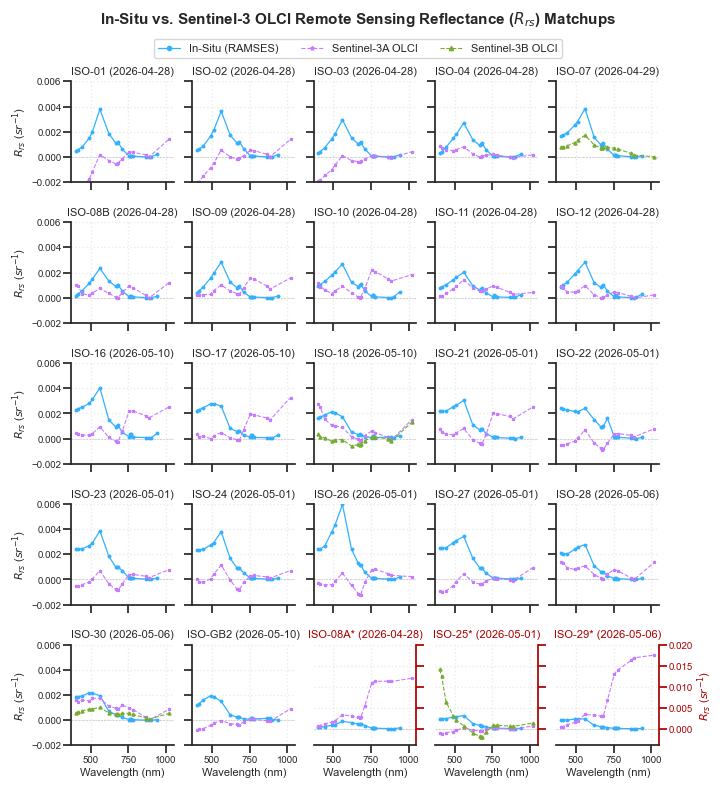

In [232]:
## KEEP THIS ONE
import math
import re
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import seaborn as sns


def plot_insitu_s3a_s3b_matchups_a4(
        df_3a,
        df_3b,
        insitu_prefix="Rrs_srf_",
        sat_prefix="sat_Rrs_",
        station_id_col="Site",
        outlier_sites=["ISO-08A", "ISO-25", "ISO-29"],
        main_ylim=(-0.002, 0.006),
        outlier_ylim=(-0.004, 0.020),
):
    sns.set_theme(style="ticks")

    def parse_wavelengths(df, prefix):
        cols = [c for c in df.columns if c.startswith(prefix)]

        def get_wl(col):
            match = re.search(r"\d+(\.\d+)?", col)
            return float(match.group()) if match else None

        mapped = sorted(
            [(get_wl(c), c) for c in cols if get_wl(c) is not None],
            key=lambda x: x[0],
        )
        if not mapped:
            return [], []
        wls, sorted_cols = zip(*mapped)
        return list(wls), list(sorted_cols)

    insitu_wl, insitu_cols = parse_wavelengths(df_3a, insitu_prefix)
    sat_3a_wl, sat_3a_cols = parse_wavelengths(df_3a, sat_prefix)
    sat_3b_wl, sat_3b_cols = parse_wavelengths(df_3b, sat_prefix)

    critical_flags = [
        "sat_flag_CLOUD",
        "sat_flag_INVALID",
        "sat_flag_SATURATED",
        "sat_flag_HIGHGLINT",
        "sat_flag_AC_FAIL",
        "sat_flag_CLOUD_AMBIGUOUS",
    ]

    s3a_560_idx = sat_3a_wl.index(560.0) if 560.0 in sat_3a_wl else None
    s3b_560_idx = sat_3b_wl.index(560.0) if 560.0 in sat_3b_wl else None

    all_indices = df_3a.index.union(df_3b.index)
    valid_indices = []

    for idx in all_indices:
        row_3a = df_3a.loc[idx] if idx in df_3a.index else None
        row_3b = df_3b.loc[idx] if idx in df_3b.index else None

        insitu_ok = False
        if row_3a is not None and insitu_cols:
            insitu_vals = row_3a[insitu_cols].values.astype(float)
            insitu_ok = not np.isnan(insitu_vals).all()
        elif row_3b is not None and insitu_cols:
            insitu_vals = row_3b[insitu_cols].values.astype(float)
            insitu_ok = not np.isnan(insitu_vals).all()

        s3a_ok = False
        if row_3a is not None and sat_3a_cols:
            s3a_vals = row_3a[sat_3a_cols].values.astype(float)
            s3a_flagged = any(f in df_3a.columns and bool(row_3a[f]) for f in critical_flags)
            s3a_all_nan = np.isnan(s3a_vals).all()
            s3a_560_ok = (s3a_560_idx is None) or (not np.isnan(s3a_vals[s3a_560_idx]))
            if not s3a_all_nan and not s3a_flagged and s3a_560_ok:
                s3a_ok = True

        s3b_ok = False
        if row_3b is not None and sat_3b_cols:
            s3b_vals = row_3b[sat_3b_cols].values.astype(float)
            s3b_flagged = any(f in df_3b.columns and bool(row_3b[f]) for f in critical_flags)
            s3b_all_nan = np.isnan(s3b_vals).all()
            s3b_560_ok = (s3b_560_idx is None) or (not np.isnan(s3b_vals[s3b_560_idx]))
            if not s3b_all_nan and not s3b_flagged and s3b_560_ok:
                s3b_ok = True

        if insitu_ok and (s3a_ok or s3b_ok):
            valid_indices.append(idx)

    def alphanum_key(idx):
        ref_row = df_3a.loc[idx] if idx in df_3a.index else df_3b.loc[idx]
        val = str(ref_row.get(station_id_col, str(idx)))
        return [
            int(c) if c.isdigit() else c.lower()
            for c in re.split(r"(\d+)", val)
        ]

    regular_indices = []
    outlier_indices = []

    for idx in sorted(valid_indices, key=alphanum_key):
        ref_row = df_3a.loc[idx] if idx in df_3a.index else df_3b.loc[idx]
        site_name = str(ref_row.get(station_id_col, ""))
        if site_name in outlier_sites:
            outlier_indices.append(idx)
        else:
            regular_indices.append(idx)

    cols_per_page = 5
    slot_mapping = {}

    # Rows 0 to 3 (4 rows * 5 cols = 20 items)
    reg_idx_counter = 0
    for r in range(4):
        for c in range(cols_per_page):
            if reg_idx_counter < len(regular_indices):
                flat_idx = r * cols_per_page + c
                slot_mapping[flat_idx] = regular_indices[reg_idx_counter]
                reg_idx_counter += 1

    # Row 4: Combine the remaining 2 regular items (cols 0, 1) and 3 outliers (cols 2, 3, 4) into a single full row
    row4_start = 4 * cols_per_page

    reg_cols_to_use = [0, 1]
    for c_target in reg_cols_to_use:
        if reg_idx_counter < len(regular_indices):
            flat_idx = row4_start + c_target
            slot_mapping[flat_idx] = regular_indices[reg_idx_counter]
            reg_idx_counter += 1

    outlier_cols_to_use = [2, 3, 4]
    for i, idx in enumerate(outlier_indices):
        flat_idx = row4_start + outlier_cols_to_use[i]
        slot_mapping[flat_idx] = idx

    total_rows = 5
    total_slots = total_rows * cols_per_page

    c_insitu = "#33B1FF"  # Lighter Blue
    c_s3a = "#C77CFF"  # Magenta
    c_s3b = "#77AC30"  # Lighter Green

    fig_width_in = 7.0
    fig_height_in = 8.0

    fig, axes = plt.subplots(
        total_rows,
        cols_per_page,
        figsize=(fig_width_in, fig_height_in),
        sharex=True,
        sharey=False,
    )
    axes_flat = axes.flatten()

    for slot_idx in range(total_slots):
        ax = axes_flat[slot_idx]
        col_idx = slot_idx % cols_per_page
        row_idx = slot_idx // cols_per_page

        if slot_idx not in slot_mapping:
            fig.delaxes(ax)
            continue

        idx = slot_mapping[slot_idx]
        row_3a = df_3a.loc[idx] if idx in df_3a.index else None
        row_3b = df_3b.loc[idx] if idx in df_3b.index else None
        ref_row = row_3a if row_3a is not None else row_3b
        stn_name = str(ref_row.get(station_id_col, f"Stn {idx}"))

        # Plot In-Situ
        if row_3a is not None and insitu_cols:
            insitu_vals = row_3a[insitu_cols].values.astype(float)
            ax.plot(
                insitu_wl,
                insitu_vals,
                "o-",
                color=c_insitu,
                linewidth=0.9,
                markersize=1.8,
            )
        elif row_3b is not None and insitu_cols:
            insitu_vals = row_3b[insitu_cols].values.astype(float)
            ax.plot(
                insitu_wl,
                insitu_vals,
                "o-",
                color=c_insitu,
                linewidth=0.9,
                markersize=1.8,
            )

        # Plot S3A if valid
        if row_3a is not None and sat_3a_cols:
            s3a_vals = row_3a[sat_3a_cols].values.astype(float)
            s3a_flagged = any(f in df_3a.columns and bool(row_3a[f]) for f in critical_flags)
            s3a_all_nan = np.isnan(s3a_vals).all()
            s3a_560_ok = (s3a_560_idx is None) or (not np.isnan(s3a_vals[s3a_560_idx]))
            if not s3a_all_nan and not s3a_flagged and s3a_560_ok:
                ax.plot(
                    sat_3a_wl,
                    s3a_vals,
                    "*--",
                    color=c_s3a,
                    linewidth=0.8,
                    markersize=2.2,
                )

        # Plot S3B if valid
        if row_3b is not None and sat_3b_cols:
            s3b_vals = row_3b[sat_3b_cols].values.astype(float)
            s3b_flagged = any(f in df_3b.columns and bool(row_3b[f]) for f in critical_flags)
            s3b_all_nan = np.isnan(s3b_vals).all()
            s3b_560_ok = (s3b_560_idx is None) or (not np.isnan(s3b_vals[s3b_560_idx]))
            if not s3b_all_nan and not s3b_flagged and s3b_560_ok:
                ax.plot(
                    sat_3b_wl,
                    s3b_vals,
                    "^--",
                    color=c_s3b,
                    linewidth=0.8,
                    markersize=2.2,
                )

        date_str = ref_row.get("Date", "")
        ax.axhline(0, color="gray", linestyle="--", linewidth=0.4, alpha=0.5)
        ax.grid(True, linestyle=":", alpha=0.4)
        ax.tick_params(axis="both", which="major", labelsize=7.0, pad=1)

        # Clean base spine visibility for all plots
        ax.spines['top'].set_visible(False)

        if stn_name in outlier_sites:
            ax.set_ylim(outlier_ylim)
            ax.set_title(
                f"{stn_name}* ({date_str})",
                fontsize=8.0,
                fontweight="normal",
                color="#AA0000",
                pad=5,
            )
            # Outlier configuration: hide left spine, show right spine in red
            ax.spines['left'].set_visible(False)
            ax.spines['right'].set_visible(True)
            ax.spines['right'].set_color("#AA0000")
            ax.yaxis.tick_right()
            ax.yaxis.set_label_position("right")

            if stn_name == "ISO-29":
                ax.tick_params(axis="y", labelcolor="#AA0000", colors="#AA0000", left=False, right=True,
                               labelleft=False, labelright=True)
                ax.set_ylabel(r"$R_{rs}$ ($sr^{-1}$)", fontsize=8.0, labelpad=2, color="#AA0000")
            else:
                ax.tick_params(axis="y", labelcolor="#AA0000", colors="#AA0000", left=False, right=True,
                               labelleft=False, labelright=False)
                ax.set_ylabel("")
        else:
            ax.set_ylim(main_ylim)
            ax.set_title(
                f"{stn_name} ({date_str})",
                fontsize=8.0,
                fontweight="normal",
                pad=5,
            )
            # Normal plot configuration: show left spine, hide right spine
            ax.spines['left'].set_visible(True)
            ax.spines['right'].set_visible(False)

            if col_idx == 0:
                ax.set_ylabel(r"$R_{rs}$ ($sr^{-1}$)", fontsize=8.0, labelpad=2)
            else:
                ax.set_yticklabels([])

        # X-axis labels on the bottom row only (Row 4)
        if row_idx == 4:
            ax.set_xlabel("Wavelength (nm)", fontsize=8.0, labelpad=2)
            ax.tick_params(axis="x", which="both", labelbottom=True)
        else:
            ax.set_xlabel("")
            ax.tick_params(axis="x", which="both", labelbottom=False)

    for j in range(total_slots):
        if j not in slot_mapping and j < len(axes_flat):
            if axes_flat[j] in fig.axes:
                fig.delaxes(axes_flat[j])

    legend_elements = [
        Line2D(
            [0],
            [0],
            marker="o",
            color=c_insitu,
            label="In-Situ (RAMSES)",
            linewidth=0.9,
            markersize=3,
        ),
        Line2D(
            [0],
            [0],
            marker="*",
            color=c_s3a,
            linestyle="--",
            label="Sentinel-3A OLCI",
            linewidth=0.8,
            markersize=3,
        ),
        Line2D(
            [0],
            [0],
            marker="^",
            color=c_s3b,
            linestyle="--",
            label="Sentinel-3B OLCI",
            linewidth=0.8,
            markersize=3,
        ),
    ]

    fig.suptitle(
        "In-Situ vs. Sentinel-3 OLCI Remote Sensing Reflectance ($R_{rs}$) Matchups",
        fontsize=11.0,
        fontweight="bold",
    )

    fig.legend(
        handles=legend_elements,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.95),
        ncol=3,
        fontsize=8.0,
        frameon=True,
    )

    plt.subplots_adjust(
        left=0.09, right=0.93, top=0.89, bottom=0.06, hspace=0.40, wspace=0.18
    )

    plt.savefig("C:/Users/25298423/PycharmProjects/FinalFigures/Insitu_S3A_S3B_valid_Rrs_Spectra_Comparison.png",
                dpi=1200, bbox_inches="tight")

plot_insitu_s3a_s3b_matchups_a4(
    df_filtered_exact_pixel_only_matchups_3a,
    df_filtered_exact_pixel_only_matchups_3b,
)

**Want to make a plot that shows where the flags were on the days of sampling for 3a and 3b**

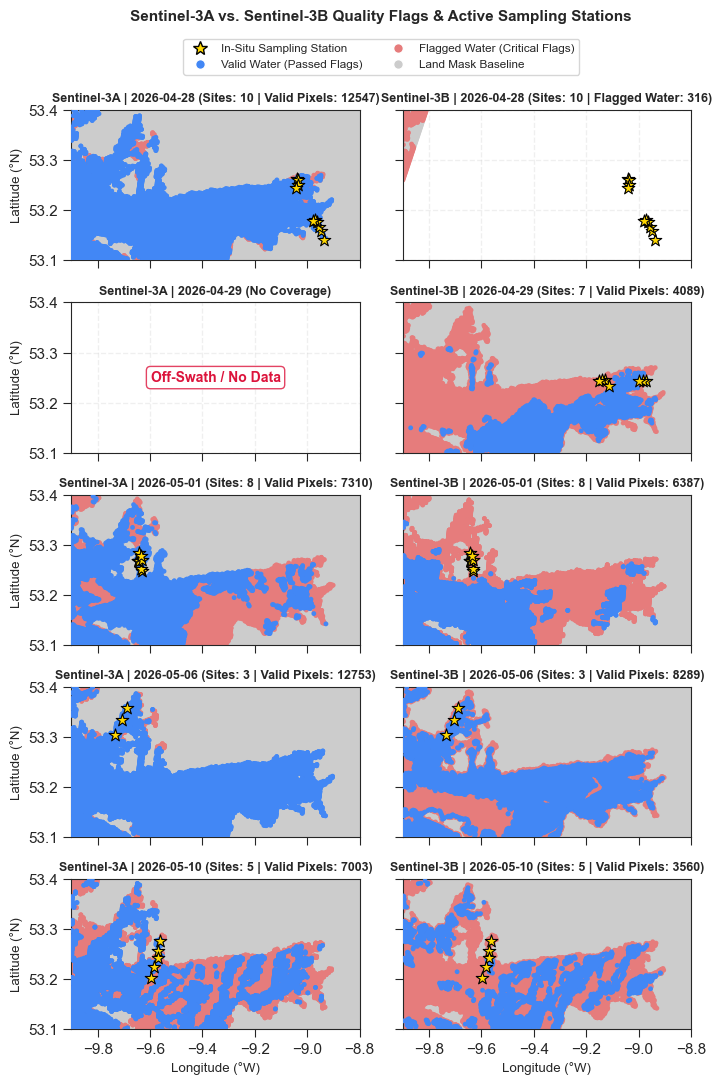

In [20]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

# Explicit list of critical flags causing matchup rejection
critical_flags = [
    "flag_CLOUD",
    "flag_INVALID",
    "flag_SATURATED",
    "flag_HIGHGLINT",
    "flag_AC_FAIL",
    "flag_CLOUD_AMBIGUOUS",
]

dates = ["2026-04-28", "2026-04-29", "2026-05-01", "2026-05-06", "2026-05-10"]
platforms = [("Sentinel-3A", df_s3a), ("Sentinel-3B", df_s3b)]

lon_min, lat_min, lon_max, lat_max = -9.9, 53.1, -8.8, 53.4

# A4 dimensions in inches with 4 cm left margin and bottom room for caption
fig_width = 8.27
fig_height = 11.69

left_inch = 4.0 / 2.54  # 4 cm converted to inches
right_inch = 0.5
top_inch = 1.3  # Room for suptitle and legend
bottom_inch = 1.2  # Room for future caption

left_frac = left_inch / fig_width
right_frac = 1.0 - (right_inch / fig_width)
top_frac = 1.0 - (top_inch / fig_height)
bottom_frac = bottom_inch / fig_height
grid_center_x = (left_frac + right_frac) / 2
# Thin out axes borders and ticks globally for a cleaner look
plt.rcParams["axes.linewidth"] = 0.8
plt.rcParams["xtick.major.width"] = 0.8
plt.rcParams["ytick.major.width"] = 0.8

fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(fig_width, fig_height),
    sharex=True,
    sharey=True,
)

# Use the precise calculated A4 fractions here so it doesn't get overridden
fig.subplots_adjust(
    left=left_frac,
    right=right_frac,
    top=top_frac,
    bottom=bottom_frac,
    hspace=0.28,
    wspace=0.15,
)

for row_idx, date_str in enumerate(dates):
    target_dt = pd.to_datetime(date_str).date()

    # Filter in-situ sampling stations active on this specific date
    if "Date" in site_means.columns:
        sites_day = site_means[
            pd.to_datetime(site_means["Date"]).dt.date == target_dt
            ].copy()
    else:
        sites_day = pd.DataFrame()

    for col_idx, (p_name, df_plat) in enumerate(platforms):
        ax = axes[row_idx, col_idx]

        # Filter satellite dataframe using the exact column name 'Timestamp'
        if "Timestamp" in df_plat.columns:
            df_day = df_plat[
                pd.to_datetime(df_plat["Timestamp"]).dt.date == target_dt
                ].copy()
        else:
            df_day = pd.DataFrame()

        if not df_day.empty and "flag_WATER" in df_day.columns:
            # 1. Base Land Mask (Grey)
            if "flag_LAND" in df_day.columns:
                land_mask = df_day["flag_LAND"] == True
            else:
                land_mask = df_day["flag_WATER"] == False

            # 2. Critical flag checking
            existing_critical_flags = [
                col for col in critical_flags if col in df_day.columns
            ]
            if existing_critical_flags:
                any_critical_flagged = df_day[existing_critical_flags].any(axis=1)
            else:
                any_critical_flagged = pd.Series(False, index=df_day.index)

            # 3. Valid Marine Water (Blue)
            valid_mask = (
                    ~land_mask
                    & (df_day["flag_WATER"] == True)
                    & (~any_critical_flagged)
                    & df_day["Rrs_560.0"].notna()
            )

            # 4. Flagged Marine Pixels (Red)
            flagged_mask = ~land_mask & ~valid_mask

            pts_land = df_day[land_mask]
            pts_flagged = df_day[flagged_mask]
            pts_valid = df_day[valid_mask]
        else:
            pts_land = pd.DataFrame()
            pts_flagged = pd.DataFrame()
            pts_valid = pd.DataFrame()

        # LAYER 1: Land Baseline (Grey)
        if not pts_land.empty:
            ax.scatter(
                pts_land["Longitude"],
                pts_land["Latitude"],
                c="#CCCCCC",
                s=12,
                edgecolors="none",
                zorder=1,
                rasterized=True,
            )

        # LAYER 2: Rejected/Flagged Marine Pixels (Red)
        if not pts_flagged.empty:
            ax.scatter(
                pts_flagged["Longitude"],
                pts_flagged["Latitude"],
                c="#e67c7c",
                s=12,
                edgecolors="none",
                zorder=2,
                rasterized=True,
            )

        # LAYER 3: Valid Marine Water Pixels (Blue)
        if not pts_valid.empty:
            ax.scatter(
                pts_valid["Longitude"],
                pts_valid["Latitude"],
                c="#4287f5",
                s=12,
                edgecolors="none",
                zorder=3,
                rasterized=True,
            )

        # LAYER 4: In-Situ Sampling Stations for the Day (Gold Stars) - ONLY if coverage exists
        has_coverage = (not pts_valid.empty) or (not pts_flagged.empty)

        if not sites_day.empty and has_coverage:
            ax.scatter(
                sites_day["Longitude"],
                sites_day["Latitude"],
                c="#FFD700",
                marker="*",
                s=90,
                edgecolors="black",
                linewidth=0.8,
                zorder=4,
            )

        # Title and Off-Swath Handling
        n_sites = len(sites_day) if has_coverage else 0
        if not pts_valid.empty:
            ax.set_title(
                f"{p_name} | {date_str} (Sites: {len(sites_day)} | Valid Pixels: {len(pts_valid)})",
                fontsize=9,
                fontweight="bold",
            )
        elif not pts_flagged.empty:
            ax.set_title(
                f"{p_name} | {date_str} (Sites: {len(sites_day)} | Flagged Water: {len(pts_flagged)})",
                fontsize=9,
                fontweight="bold",
            )
        else:
            ax.text(
                0.5,
                0.5,
                "Off-Swath / No Data",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=10,
                color="crimson",
                fontweight="bold",
                bbox=dict(
                    boxstyle="round,pad=0.3",
                    facecolor="white",
                    edgecolor="crimson",
                    alpha=0.8,
                ),
            )
            ax.set_title(
                f"{p_name} | {date_str} (No Coverage)",
                fontsize=9,
                fontweight="bold",
            )

        ax.set_xlim(lon_min, lon_max)
        ax.set_ylim(lat_min, lat_max)
        ax.grid(True, linestyle="--", alpha=0.3)

        if row_idx == 4:
            ax.set_xlabel("Longitude (°W)", fontsize=9.5)
        if col_idx == 0:
            ax.set_ylabel("Latitude (°N)", fontsize=9.5)

# Legend Setup
legend_elements = [
    Line2D(
        [0],
        [0],
        marker="*",
        color="w",
        label="In-Situ Sampling Station",
        markerfacecolor="#FFD700",
        markeredgecolor="black",
        markersize=10,
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="Valid Water (Passed Flags)",
        markerfacecolor="#4287f5",
        markersize=7,
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="Flagged Water (Critical Flags)",
        markerfacecolor="#e67c7c",
        markersize=7,
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="Land Mask Baseline",
        markerfacecolor="#CCCCCC",
        markersize=7,
    ),
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(grid_center_x, 0.955),
    ncol=2,
    fontsize=8.5,
    frameon=True,
)

plt.suptitle(
    "Sentinel-3A vs. Sentinel-3B Quality Flags & Active Sampling Stations",
    x=grid_center_x,
    ha='center',
    fontsize=11,
    fontweight="bold",
    y=0.975,
)

plt.savefig(
    "C:/Users/25298423/PycharmProjects/FinalFigures/3Av3BCoverageComparison.png",
    dpi=1200,
    bbox_inches="tight",
)
plt.show()

# Next: Statistics - Follow Glerrati et al

    critical_flags = [
        "flag_CLOUD",
        "flag_INVALID",
        "flag_SATURATED",
        "flag_HIGHGLINT",
        "flag_AC_FAIL",
        "flag_CLOUD_AMBIGUOUS",
    ]

With only 4 viable S3B sites, not going to include it in statistical analysis

In [21]:
print(df_s3a_matched.head())

      Site        Date      Timestamp_Start        Timestamp_End   Latitude  \
0   ISO-01  2026-04-28  2026-04-28 11:28:00  2026-04-28 11:38:00  53.263103   
1   ISO-02  2026-04-28  2026-04-28 11:43:00  2026-04-28 11:50:00  53.260653   
2   ISO-03  2026-04-28  2026-04-28 12:02:00  2026-04-28 12:09:00  53.250777   
3   ISO-04  2026-04-28  2026-04-28 12:18:00  2026-04-28 12:26:00  53.244920   
4  ISO-08A  2026-04-28  2026-04-28 15:18:00  2026-04-28 15:25:00  53.141730   

   Longitude  Rrs_srf_400.0  Rrs_srf_412.5  Rrs_srf_442.5  Rrs_srf_490.0  ...  \
0  -9.039540       0.000497       0.000562       0.000781       0.001509  ...   
1  -9.037058       0.000533       0.000610       0.000884       0.001660  ...   
2  -9.036935       0.000322       0.000423       0.000743       0.001453  ...   
3  -9.041622       0.000273       0.000400       0.000766       0.001465  ...   
4  -8.936175       0.000322       0.000385       0.000520       0.000796  ...   

   sat_flag_COSMETIC  sat_flag_SUSPECT

### All Sites

In [22]:
import re
import numpy as np
import pandas as pd

def calculate_band_rmsd(df, insitu_prefix="Rrs_srf_", sat_prefix="sat_Rrs_"):
    insitu_cols = [c for c in df.columns if c.startswith(insitu_prefix)]
    results = {}

    for insitu_col in insitu_cols:
        match = re.search(r"\d+(\.\d+)?", insitu_col)
        if not match:
            continue
        wl = match.group()
        sat_col = f"{sat_prefix}{wl}"

        if sat_col in df.columns:
            subset = df[[insitu_col, sat_col]].dropna()
            if len(subset) > 0:
                sat_vals = subset[sat_col].values.astype(float)
                insitu_vals = subset[insitu_col].values.astype(float)
                rmsd = np.sqrt(np.mean((sat_vals - insitu_vals) ** 2)) ## the actual calculation
                results[float(wl)] = rmsd

    return pd.DataFrame(list(results.items()), columns=["Wavelength", "RMSD"]).sort_values("Wavelength").reset_index(drop=True)

rmsd_df = calculate_band_rmsd(df_s3a_matched)
print(rmsd_df)

    Wavelength      RMSD
0        400.0  0.002038
1        412.5  0.002071
2        442.5  0.002045
3        490.0  0.002270
4        510.0  0.002249
5        560.0  0.002435
6        620.0  0.001504
7        665.0  0.001295
8        673.8  0.001325
9        708.8  0.001767
10       753.8  0.003565
11       778.8  0.003772
12       865.0  0.004106
13       885.0  0.004191


In [23]:
rmsd_df

,Wavelength,RMSD
0,400.0,0.002038
1,412.5,0.002071
2,442.5,0.002045
3,490.0,0.002270
4,510.0,0.002249
5,560.0,0.002435
6,620.0,0.001504
7,665.0,0.001295
8,673.8,0.001325
9,708.8,0.001767


In [24]:
import re
import numpy as np
import pandas as pd

def calculate_band_mdapd(df, insitu_prefix="Rrs_srf_", sat_prefix="sat_Rrs_"):
    insitu_cols = [c for c in df.columns if c.startswith(insitu_prefix)]
    results = {}

    for insitu_col in insitu_cols:
        match = re.search(r"\d+(\.\d+)?", insitu_col)
        if not match:
            continue
        wl = match.group()
        sat_col = f"{sat_prefix}{wl}"

        if sat_col in df.columns:
            subset = df[[insitu_col, sat_col]].dropna()
            if len(subset) > 0:
                sat_vals = subset[sat_col].values.astype(float)
                insitu_vals = subset[insitu_col].values.astype(float)

                # Filter out zero in-situ values to avoid division by zero
                valid_mask = insitu_vals != 0
                if valid_mask.sum() > 0:
                    s_vals = sat_vals[valid_mask]
                    i_vals = insitu_vals[valid_mask]

                    abs_pct_diffs = np.abs((s_vals - i_vals) / i_vals) * 100
                    mdapd = np.median(abs_pct_diffs)
                    results[float(wl)] = mdapd

    res_df = pd.DataFrame(list(results.items()), columns=["Wavelength", "MdAPD"]).sort_values("Wavelength").reset_index(drop=True)
    return res_df

mdapd_df = calculate_band_mdapd(df_s3a_matched)
print(mdapd_df)

    Wavelength        MdAPD
0        400.0    97.093921
1        412.5    93.014218
2        442.5    90.511383
3        490.0    92.081440
4        510.0    86.818818
5        560.0    72.081690
6        620.0   101.417965
7        665.0   131.340224
8        673.8   136.521707
9        708.8   122.546273
10       753.8   605.934213
11       778.8   768.504967
12       865.0  1345.926004
13       885.0   753.469395


In [25]:
mdapd_df

,Wavelength,MdAPD
0,400.0,97.093921
1,412.5,93.014218
2,442.5,90.511383
3,490.0,92.081440
4,510.0,86.818818
5,560.0,72.081690
6,620.0,101.417965
7,665.0,131.340224
8,673.8,136.521707
9,708.8,122.546273


In [26]:
import re
import numpy as np
import pandas as pd

def calculate_band_mdpd(df, insitu_prefix="Rrs_srf_", sat_prefix="sat_Rrs_"):
    insitu_cols = [c for c in df.columns if c.startswith(insitu_prefix)]
    results = {}

    for insitu_col in insitu_cols:
        match = re.search(r"\d+(\.\d+)?", insitu_col)
        if not match:
            continue
        wl = match.group()
        sat_col = f"{sat_prefix}{wl}"

        if sat_col in df.columns:
            subset = df[[insitu_col, sat_col]].dropna()
            if len(subset) > 0:
                sat_vals = subset[sat_col].values.astype(float)
                insitu_vals = subset[insitu_col].values.astype(float)

                # Filter out zero in-situ values to avoid division by zero
                valid_mask = insitu_vals != 0
                if valid_mask.sum() > 0:
                    s_vals = sat_vals[valid_mask]
                    i_vals = insitu_vals[valid_mask]

                    pct_diffs = ((s_vals - i_vals) / i_vals) * 100
                    mdpd = np.median(pct_diffs)
                    results[float(wl)] = mdpd

    res_df = pd.DataFrame(list(results.items()), columns=["Wavelength", "MdPD"]).sort_values("Wavelength").reset_index(drop=True)
    return res_df

mdpd_df = calculate_band_mdpd(df_s3a_matched)
print(mdpd_df)

    Wavelength         MdPD
0        400.0   -84.665685
1        412.5   -85.768199
2        442.5   -86.451264
3        490.0   -88.815762
4        510.0   -84.645094
5        560.0   -70.717484
6        620.0   -93.107634
7        665.0  -117.907155
8        673.8  -122.742741
9        708.8   -42.966104
10       753.8   605.934213
11       778.8   768.504967
12       865.0  1345.926004
13       885.0   501.256943


In [27]:
mdpd_df

,Wavelength,MdPD
0,400.0,-84.665685
1,412.5,-85.768199
2,442.5,-86.451264
3,490.0,-88.815762
4,510.0,-84.645094
5,560.0,-70.717484
6,620.0,-93.107634
7,665.0,-117.907155
8,673.8,-122.742741
9,708.8,-42.966104


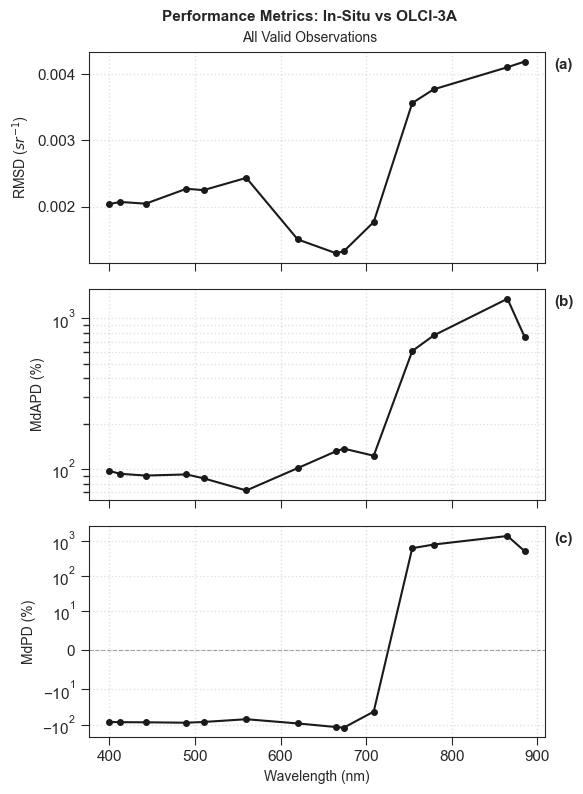

In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(6, 8), sharex=True)

# 1. RMSD plot
axes[0].plot(rmsd_df["Wavelength"], rmsd_df["RMSD"], marker="o", color="k", linewidth=1.5, markersize=4)
axes[0].set_ylabel("RMSD ($sr^{-1}$)", fontsize=10)

axes[0].grid(True, linestyle=":", alpha=0.6)
axes[0].text(1.02, 0.92, "(a)", transform=axes[0].transAxes, fontsize=11, fontweight="bold")

# 2. MdAPD plot (log scale)
axes[1].plot(mdapd_df["Wavelength"], mdapd_df["MdAPD"], marker="o", color="k", linewidth=1.5, markersize=4)
axes[1].set_yscale("log")
axes[1].set_ylabel("MdAPD (%)", fontsize=10)

axes[1].grid(True, linestyle=":", alpha=0.6, which="both")
axes[1].text(1.02, 0.92, "(b)", transform=axes[1].transAxes, fontsize=11, fontweight="bold")

# 3. MdPD plot (symlog scale)
axes[2].plot(mdpd_df["Wavelength"], mdpd_df["MdPD"], marker="o", color="k", linewidth=1.5, markersize=4)
axes[2].set_yscale("symlog", linthresh=10)
axes[2].set_ylabel("MdPD (%)", fontsize=10)
axes[2].set_xlabel("Wavelength (nm)", fontsize=10)

axes[2].grid(True, linestyle=":", alpha=0.6, which="both")
axes[2].text(1.02, 0.92, "(c)", transform=axes[2].transAxes, fontsize=11, fontweight="bold")

# Add a horizontal zero line for MdPD
axes[2].axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
fig.suptitle("Performance Metrics: In-Situ vs OLCI-3A", fontsize=11, fontweight="bold", x=0.53, y=0.99)
fig.text(0.53, 0.95, "All Valid Observations", ha="center", fontsize=10, style="normal")
plt.tight_layout()
plt.savefig("C:/Users/25298423/PycharmProjects/FinalFigures/PerformanceMetrics_insitu_3A.png",
    dpi=1200,
    bbox_inches="tight",
)
plt.show()

## Distance to Shore

<Axes: >

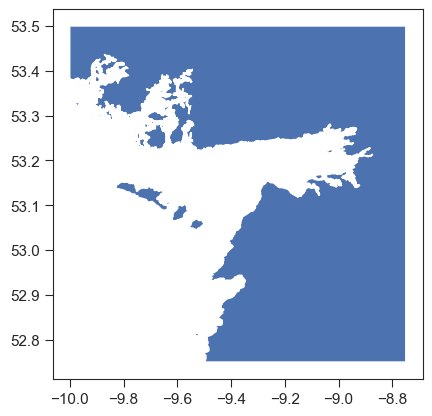

In [29]:
## try to get this onto a map of Ireland using geopandas
import geopandas as gpd
url = "https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_IRL_shp.zip"
uk_url = "https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_GBR_shp.zip"

ireland = gpd.read_file(url, layer="gadm41_IRL_0")

uk = gpd.read_file(uk_url, layer="gadm41_GBR_0")
uk_regions = gpd.read_file(uk_url, layer="gadm41_GBR_1")
northern_ireland = uk_regions[uk_regions["NAME_1"] == "Northern Ireland"]
island = gpd.GeoDataFrame(pd.concat([ireland, northern_ireland], ignore_index=True), crs="EPSG:4326")
## adding in france for the large satellite plots
#fra_url = "https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_FRA_shp.zip"
#france = gpd.read_file(fra_url, layer="gadm41_FRA_0")
#all_land = gpd.GeoDataFrame(pd.concat([ireland, uk_regions, france], ignore_index=True), crs="EPSG:4326")
landmass = island.clip([-10, 52.75, -8.75, 53.5])
landmass.plot()

In [30]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
df_s3a_matched = df_s3a_matched.copy()
# 1. Convert your DataFrame into a GeoDataFrame using WGS84 (Lat/Lon)
gdf_points = gpd.GeoDataFrame(
    df_s3a_matched,
    geometry=gpd.points_from_xy(
        df_s3a_matched["Longitude"], df_s3a_matched["Latitude"]
    ),
    crs="EPSG:4326",
)

# 2. Project both the landmass and points to EPSG:3035 (LAEA Europe in meters)
landmass_proj = island.to_crs(epsg=3035)
gdf_points_proj = gdf_points.to_crs(epsg=3035)

# 3. Combine land polygons into a single geometry for efficient distance calculation
land_union = landmass_proj.union_all()

# 4. Calculate distance to the shoreline in kilometers
df_s3a_matched["dist_to_shore_m"] = (
    gdf_points_proj.geometry.distance(land_union))

In [31]:
df_s3a_matched[df_s3a_matched['dist_to_shore_m']<420]

,Site,Date,Timestamp_Start,Timestamp_End,Latitude,Longitude,Rrs_srf_400.0,Rrs_srf_412.5,Rrs_srf_442.5,Rrs_srf_490.0,...,sat_flag_SUSPECT,sat_flag_HISOLZEN,sat_flag_SATURATED,sat_flag_HIGHGLINT,sat_flag_CLOUD_AMBIGUOUS,sat_flag_CLOUD_MARGIN,sat_flag_AC_FAIL,sat_flag_OC4ME_FAIL,sat_flag_OCNN_FAIL,dist_to_shore_m
4,ISO-08A,2026-04-28,2026-04-28 15:18:00,2026-04-28 15:25:00,53.141730,-8.936175,0.000322,0.000385,0.000520,0.000796,...,False,False,False,False,False,False,False,False,False,147.016236
5,ISO-08B,2026-04-28,2026-04-28 15:41:00,2026-04-28 15:47:00,53.158338,-8.948395,0.000163,0.000268,0.000557,0.001154,...,False,False,False,False,False,False,False,True,False,371.573331
6,ISO-09,2026-04-28,2026-04-28 15:58:00,2026-04-28 16:02:00,53.167728,-8.955467,0.000404,0.000529,0.000875,0.001574,...,False,False,False,False,False,False,False,True,False,417.247590
7,ISO-10,2026-04-28,2026-04-28 16:13:00,2026-04-28 16:15:00,53.175897,-8.962217,0.000934,0.001044,0.001295,0.001798,...,False,False,False,False,False,False,False,True,False,299.621937
8,ISO-11,2026-04-28,2026-04-28 16:24:00,2026-04-28 16:34:00,53.180213,-8.970387,0.000776,0.000860,0.001040,0.001423,...,False,False,False,False,False,False,False,False,False,416.585852
18,ISO-21,2026-05-01,2026-05-01 11:38:00,2026-05-01 11:47:00,53.252010,-9.633478,0.002174,0.002166,0.002199,0.002532,...,False,False,False,False,False,False,False,False,False,184.609741
19,ISO-22,2026-05-01,2026-05-01 12:27:00,2026-05-01 12:36:00,53.268393,-9.645207,0.002439,0.002392,0.002276,0.002163,...,False,False,False,False,False,False,False,False,True,385.859988
20,ISO-23,2026-05-01,2026-05-01 12:14:00,2026-05-01 12:24:00,53.268062,-9.645077,0.002453,0.002428,0.002439,0.002689,...,False,False,False,False,False,False,False,False,True,357.059883
23,ISO-26,2026-05-01,2026-05-01 12:58:00,2026-05-01 13:08:00,53.282925,-9.642953,0.002405,0.002413,0.002665,0.003806,...,False,False,False,False,False,False,False,False,True,361.866825
25,ISO-28,2026-05-06,2026-05-06 10:37:00,2026-05-06 10:40:00,53.358697,-9.689728,0.002078,0.002036,0.002026,0.002386,...,False,False,False,False,False,False,False,True,False,325.408743


#### Distance to Shore - Statistics

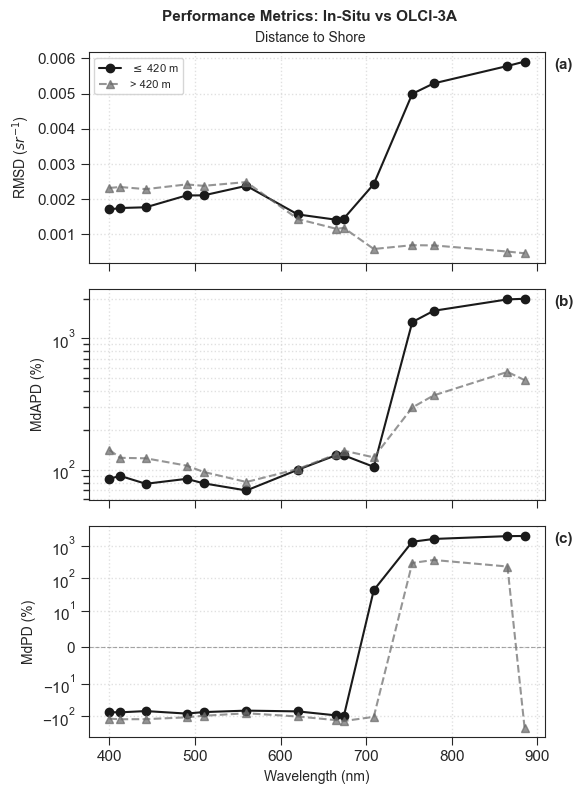

In [32]:
import matplotlib.pyplot as plt

# 1. Split the dataframe into two groups based on distance to shore
df_near = df_s3a_matched[df_s3a_matched["dist_to_shore_m"] <= 420]
df_far = df_s3a_matched[df_s3a_matched["dist_to_shore_m"] > 420]

# 2. Calculate metrics for both groups
rmsd_near = calculate_band_rmsd(df_near)
rmsd_far = calculate_band_rmsd(df_far)

mdapd_near = calculate_band_mdapd(df_near)
mdapd_far = calculate_band_mdapd(df_far)

mdpd_near = calculate_band_mdpd(df_near)
mdpd_far = calculate_band_mdpd(df_far)

# 3. Plot comparison figures
fig, axes = plt.subplots(3, 1, figsize=(6, 8), sharex=True)

# RMSD
axes[0].plot(rmsd_near["Wavelength"], rmsd_near["RMSD"], marker="o", color="k", linestyle="-", label=r"$\leq$ 420 m")
axes[0].plot(rmsd_far["Wavelength"], rmsd_far["RMSD"], marker="^", color="dimgrey", linestyle="--", alpha=0.7, label="> 420 m")
axes[0].set_ylabel("RMSD ($sr^{-1}$)", fontsize=10)

axes[0].grid(True, linestyle=":", alpha=0.6)
axes[0].legend(fontsize=8, loc="upper left")
axes[0].text(1.02, 0.92, "(a)", transform=axes[0].transAxes, fontsize=11, fontweight="bold")

# MdAPD (log scale)
axes[1].plot(mdapd_near["Wavelength"], mdapd_near["MdAPD"], marker="o", color="k", linestyle="-", label=r"$\leq$ 420 m")
axes[1].plot(mdapd_far["Wavelength"], mdapd_far["MdAPD"], marker="^", color="dimgrey", linestyle="--", alpha=0.7, label="> 420 m")
axes[1].set_yscale("log")
axes[1].set_ylabel("MdAPD (%)", fontsize=10)

axes[1].grid(True, linestyle=":", alpha=0.6, which="both")
axes[1].text(1.02, 0.92, "(b)", transform=axes[1].transAxes, fontsize=11, fontweight="bold")

# MdPD (symlog scale)
axes[2].plot(mdpd_near["Wavelength"], mdpd_near["MdPD"], marker="o", color="k", linestyle="-", label=r"$\leq$ 420 m")
axes[2].plot(mdpd_far["Wavelength"], mdpd_far["MdPD"], marker="^", color="dimgrey", linestyle="--", alpha=0.7, label="> 420 m")
axes[2].set_yscale("symlog", linthresh=10)
axes[2].set_ylabel("MdPD (%)", fontsize=10)
axes[2].set_xlabel("Wavelength (nm)", fontsize=10)

axes[2].grid(True, linestyle=":", alpha=0.6, which="both")
axes[2].axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
axes[2].text(1.02, 0.92, "(c)", transform=axes[2].transAxes, fontsize=11, fontweight="bold")
fig.suptitle("Performance Metrics: In-Situ vs OLCI-3A", fontsize=11, fontweight="bold", x=0.53, y=0.99)
fig.text(0.53, 0.95, "Distance to Shore", ha="center", fontsize=10, style="normal")
plt.tight_layout()
plt.savefig("C:/Users/25298423/PycharmProjects/FinalFigures/PerformanceMetrics_DistancetoShore_insitu_3A.png",
    dpi=1200,
    bbox_inches="tight",
)
plt.show()

In [33]:
import pandas as pd

def get_counts(df_sub, wavelengths):
    n_list = []
    for wl in wavelengths:
        col_insitu = f"Rrs_srf_{wl}"
        matching_sat_cols = [
            c for c in df_sub.columns
            if c.startswith('sat_Rrs_') and abs(float(c.replace('sat_Rrs_', '')) - wl) < 0.3
        ]
        if matching_sat_cols and col_insitu in df_sub.columns:
            valid_mask = df_sub[col_insitu].notna() & df_sub[matching_sat_cols[0]].notna()
            n_list.append(int(valid_mask.sum()))
        else:
            n_list.append(0)
    return n_list

wavelengths = rmsd_near["Wavelength"].values

table_near = pd.DataFrame({"Wavelength": wavelengths})
table_near["N (<=420m)"] = get_counts(df_near, wavelengths)
table_near["RMSE (<=420m)"] = rmsd_near["RMSD"].values
table_near["MdAPD (<=420m)"] = mdapd_near["MdAPD"].values
table_near["MdPD (<=420m)"] = mdpd_near["MdPD"].values

table_far = pd.DataFrame({"Wavelength": wavelengths})
table_far["N (>420m)"] = get_counts(df_far, wavelengths)
table_far["RMSE (>420m)"] = rmsd_far["RMSD"].values
table_far["MdAPD (>420m)"] = mdapd_far["MdAPD"].values
table_far["MdPD (>420m)"] = mdpd_far["MdPD"].values

final_table = pd.merge(table_near, table_far, on="Wavelength")

# Format RMSE columns to 3 significant figures
rmse_cols = [c for c in final_table.columns if "RMSE" in c]
for col in rmse_cols:
    final_table[col] = final_table[col].apply(lambda x: f"{x:.3g}" if pd.notnull(x) else x)

# Round percentage metrics (MdAPD, MdPD) to 2 decimal places
pct_cols = [c for c in final_table.columns if c != "Wavelength" and not c.startswith("N") and c not in rmse_cols]
for col in pct_cols:
    final_table[col] = final_table[col].round(2)



final_table

,Wavelength,N (<=420m),RMSE (<=420m),MdAPD (<=420m),MdPD (<=420m),N (>420m),RMSE (>420m),MdAPD (>420m),MdPD (>420m)
0,400.0,12,0.00171,85.55,-74.83,12,0.00232,141.64,-118.02
1,412.5,12,0.00175,89.87,-75.64,12,0.00235,123.37,-123.37
2,442.5,12,0.00177,78.27,-69.18,12,0.00229,122.32,-122.32
3,490.0,12,0.00211,85.35,-82.57,12,0.00242,107.66,-107.66
4,510.0,12,0.00211,78.92,-74.31,12,0.00238,96.36,-96.36
5,560.0,12,0.00238,69.63,-67.03,12,0.00249,80.77,-80.77
6,620.0,12,0.00157,100.06,-70.74,12,0.00144,101.42,-101.42
7,665.0,12,0.00142,129.30,-93.92,12,0.00116,131.34,-131.34
8,673.8,12,0.00145,128.89,-99.09,12,0.00119,139.87,-139.87
9,708.8,12,0.00243,105.33,43.78,12,0.000587,124.40,-103.96


### Timing with Satellite

In [34]:
df_s3a_matched['Time_Delta_mins'].median()

-109.52

In [35]:
## use 120 minutes - an even 2 hours

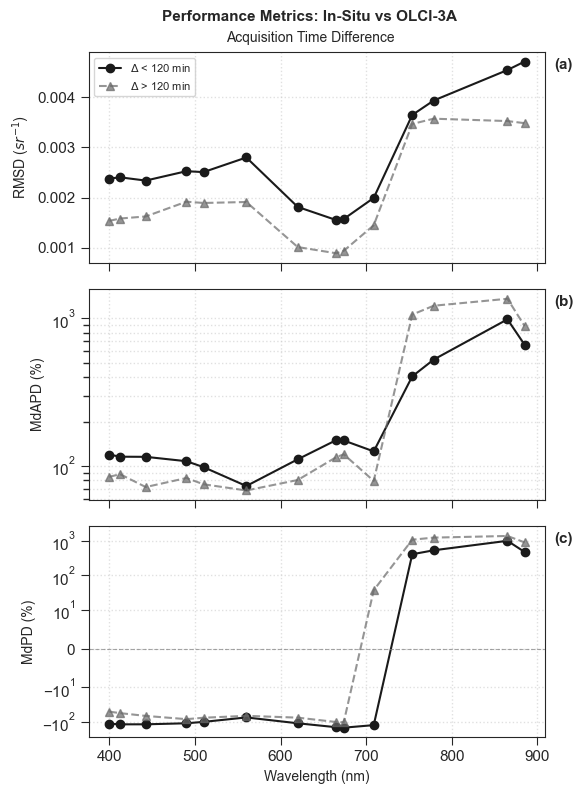

In [36]:
import matplotlib.pyplot as plt

# 1. Split the dataframe into two groups based on distance to shore
df_soon = df_s3a_matched[df_s3a_matched["Time_Delta_mins"] >= -120]
df_later = df_s3a_matched[df_s3a_matched["Time_Delta_mins"] < -120]

# 2. Calculate metrics for both groups
rmsd_soon = calculate_band_rmsd(df_soon)
rmsd_later = calculate_band_rmsd(df_later)

mdapd_soon = calculate_band_mdapd(df_soon)
mdapd_later = calculate_band_mdapd(df_later)

mdpd_soon = calculate_band_mdpd(df_soon)
mdpd_later = calculate_band_mdpd(df_later)

# 3. Plot comparison figures
fig, axes = plt.subplots(3, 1, figsize=(6, 8), sharex=True)

# RMSD
axes[0].plot(rmsd_soon["Wavelength"], rmsd_soon["RMSD"], marker="o", color="k", linestyle="-", label=r'$\Delta$ < 120 min')
axes[0].plot(rmsd_later["Wavelength"], rmsd_later["RMSD"], marker="^", color="dimgrey", linestyle="--", alpha=0.7, label=r'$\Delta$ > 120 min')
axes[0].set_ylabel("RMSD ($sr^{-1}$)", fontsize=10)

axes[0].grid(True, linestyle=":", alpha=0.6)
axes[0].legend(fontsize=8, loc="upper left")
axes[0].text(1.02, 0.92, "(a)", transform=axes[0].transAxes, fontsize=11, fontweight="bold")

# MdAPD (log scale)
axes[1].plot(mdapd_soon["Wavelength"], mdapd_soon["MdAPD"], marker="o", color="k", linestyle="-", label=r'$\Delta$ < 120 min')
axes[1].plot(mdapd_later["Wavelength"], mdapd_later["MdAPD"], marker="^", color="dimgrey", linestyle="--", alpha=0.7, label=r'$\Delta$ > 120 min')
axes[1].set_yscale("log")
axes[1].set_ylabel("MdAPD (%)", fontsize=10)

axes[1].grid(True, linestyle=":", alpha=0.6, which="both")
axes[1].text(1.02, 0.92, "(b)", transform=axes[1].transAxes, fontsize=11, fontweight="bold")

# MdPD (symlog scale)
axes[2].plot(mdpd_soon["Wavelength"], mdpd_soon["MdPD"], marker="o", color="k", linestyle="-", label=r'$\Delta$ < 120 min')
axes[2].plot(mdpd_later["Wavelength"], mdpd_later["MdPD"], marker="^", color="dimgrey", linestyle="--", alpha=0.7, label=r'$\Delta$ > 120 min')
axes[2].set_yscale("symlog", linthresh=10)
axes[2].set_ylabel("MdPD (%)", fontsize=10)
axes[2].set_xlabel("Wavelength (nm)", fontsize=10)

axes[2].grid(True, linestyle=":", alpha=0.6, which="both")
axes[2].axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
axes[2].text(1.02, 0.92, "(c)", transform=axes[2].transAxes, fontsize=11, fontweight="bold")
fig.suptitle("Performance Metrics: In-Situ vs OLCI-3A", fontsize=11, fontweight="bold", x=0.53, y=0.99)
fig.text(0.53, 0.95, "Acquisition Time Difference", ha="center", fontsize=10, style="normal")
plt.tight_layout()
plt.savefig("C:/Users/25298423/PycharmProjects/FinalFigures/PerformanceMetrics_TimingwithSat_insitu_3A.png",
    dpi=1200,
    bbox_inches="tight",
)
plt.show()

In [37]:
import pandas as pd

def get_counts(df_sub, wavelengths):
    n_list = []
    for wl in wavelengths:
        col_insitu = f"Rrs_srf_{wl}"
        matching_sat_cols = [
            c for c in df_sub.columns
            if c.startswith('sat_Rrs_') and abs(float(c.replace('sat_Rrs_', '')) - wl) < 0.3
        ]
        if matching_sat_cols and col_insitu in df_sub.columns:
            valid_mask = df_sub[col_insitu].notna() & df_sub[matching_sat_cols[0]].notna()
            n_list.append(int(valid_mask.sum()))
        else:
            n_list.append(0)
    return n_list

wavelengths = rmsd_soon["Wavelength"].values

# Build soon table safely
table_soon = pd.DataFrame({"Wavelength": wavelengths})
table_soon["N (>= -120m)"] = get_counts(df_soon, wavelengths)
table_soon["RMSE (>= -120m)"] = rmsd_soon["RMSD"].values
table_soon["MdAPD (>= -120m)"] = mdapd_soon["MdAPD"].values
table_soon["MdPD (>= -120m)"] = mdpd_soon["MdPD"].values

# Build later table safely
table_later = pd.DataFrame({"Wavelength": wavelengths})
table_later["N (< -120m)"] = get_counts(df_later, wavelengths)
table_later["RMSE (< -120m)"] = rmsd_later["RMSD"].values
table_later["MdAPD (< -120m)"] = mdapd_later["MdAPD"].values
table_later["MdPD (< -120m)"] = mdpd_later["MdPD"].values

# Merge side-by-side
final_table_time = pd.merge(table_soon, table_later, on="Wavelength")

# Format RMSE columns to 3 significant figures
rmse_cols = [c for c in final_table_time.columns if "RMSE" in c]
for col in rmse_cols:
    final_table_time[col] = final_table_time[col].apply(lambda x: f"{x:.3g}" if pd.notnull(x) else x)

# Round percentage metrics (MdAPD, MdPD) to 2 decimal places
pct_cols = [c for c in final_table_time.columns if c != "Wavelength" and not c.startswith("N") and c not in rmse_cols]
for col in pct_cols:
    final_table_time[col] = final_table_time[col].round(2)

final_table_time

,Wavelength,N (>= -120m),RMSE (>= -120m),MdAPD (>= -120m),MdPD (>= -120m),N (< -120m),RMSE (< -120m),MdAPD (< -120m),MdPD (< -120m)
0,400.0,13,0.00238,119.63,-110.48,11,0.00154,84.60,-49.93
1,412.5,13,0.00241,115.79,-115.79,11,0.00159,88.13,-55.09
2,442.5,13,0.00234,115.53,-115.53,11,0.00163,72.11,-66.25
3,490.0,13,0.00253,107.91,-107.91,11,0.00192,83.02,-82.13
4,510.0,13,0.00251,98.40,-98.40,11,0.0019,75.30,-74.81
5,560.0,13,0.0028,73.28,-73.28,11,0.00191,68.37,-65.89
6,620.0,13,0.00182,111.12,-107.87,11,0.00102,80.47,-74.28
7,665.0,13,0.00156,149.93,-140.10,11,0.000895,114.94,-99.30
8,673.8,13,0.00158,149.11,-144.31,11,0.000944,120.16,-100.54
9,708.8,13,0.002,125.77,-122.06,11,0.00145,79.36,37.37


### Secchi Hit Bottom

In [39]:
stations = pd.read_excel(
    "C:/Users/25298423/OneDrive - National University of Ireland, Galway/date_station_secchi_Plan2.xlsx")
stations['Time_Start_delta'] = pd.to_timedelta(stations['Time_Start'].astype(str))
stations['Time_End_delta'] = pd.to_timedelta(stations['Time_End'].astype(str))
stations['Timestamp_Start'] = stations['Date'] + stations['Time_Start_delta']
stations['Timestamp_End'] = stations['Date'] + stations['Time_End_delta']
stations = stations.drop(columns=['Time_Start_delta', 'Time_End_delta'])
stations
decimal_degrees_lon = []
for lon in stations['Longitude']:
    degree = float(re.findall(r'^\d{1,2}(?=\°\s)', lon)[0])
    dec_minute = float(re.findall(r'\d{1,2}\.\d{3,4}', lon)[0])
    dec_deg = degree + (dec_minute / 60)
    if 'W' in lon:
        dec_deg = -dec_deg
    dec_deg = round(dec_deg, 6)
    decimal_degrees_lon.append(dec_deg)

decimal_degrees_lat = []
for lat in stations['Latitude']:
    degree = float(re.findall(r'^\d{1,2}(?=\°\s)', lat)[0])
    dec_minute = float(re.findall(r'\d{1,2}\.\d{3,4}', lat)[0])
    dec_deg = degree + (dec_minute / 60)
    dec_deg = round(dec_deg, 6)
    decimal_degrees_lat.append(dec_deg)

stations['latitude_dec'] = decimal_degrees_lat
stations['longitude_dec'] = decimal_degrees_lon

In [40]:
secchi = stations[['Site','Secchi_Depth(m)','Notes']]

In [41]:
print(secchi.head(3))

     Site  Secchi_Depth(m) Notes
0  ISO-01             3.36   NaN
1  ISO-02             4.06   NaN
2  ISO-03             4.13   NaN


In [42]:
secchi

,Site,Secchi_Depth(m),Notes
0,ISO-01,3.36,NaN
1,ISO-02,4.06,NaN
2,ISO-03,4.13,NaN
3,ISO-04,NaN,NaN
4,ISO-08A,2.53,NaN
5,ISO-08B,4.88,NaN
6,ISO-09,4.25,NaN
7,ISO-10,4.39,NaN
8,ISO-11,4.59,NaN
9,ISO-12,5.05,NaN


In [43]:
# Merge the Secchi notes into your matched dataframe based on 'Site'
df_s3a_matched = df_s3a_matched.merge(
    secchi[["Site", "Notes"]],
    on="Site",
    how="left"
)

In [44]:
# 1. Split the dataframe into groups based on whether Secchi hit the bottom ('B' in Notes)
has_b = df_s3a_matched["Notes"].str.contains("B", na=False)
df_water = df_s3a_matched[~has_b]
df_bottom = df_s3a_matched[has_b]

In [45]:
df_water

,Site,Date,Timestamp_Start,Timestamp_End,Latitude,Longitude,Rrs_srf_400.0,Rrs_srf_412.5,Rrs_srf_442.5,Rrs_srf_490.0,...,sat_flag_HISOLZEN,sat_flag_SATURATED,sat_flag_HIGHGLINT,sat_flag_CLOUD_AMBIGUOUS,sat_flag_CLOUD_MARGIN,sat_flag_AC_FAIL,sat_flag_OC4ME_FAIL,sat_flag_OCNN_FAIL,dist_to_shore_m,Notes
0,ISO-01,2026-04-28,2026-04-28 11:28:00,2026-04-28 11:38:00,53.263103,-9.039540,0.000497,0.000562,0.000781,0.001509,...,False,False,False,False,True,False,False,True,486.397123,NaN
1,ISO-02,2026-04-28,2026-04-28 11:43:00,2026-04-28 11:50:00,53.260653,-9.037058,0.000533,0.000610,0.000884,0.001660,...,False,False,False,False,True,False,False,True,673.060186,NaN
2,ISO-03,2026-04-28,2026-04-28 12:02:00,2026-04-28 12:09:00,53.250777,-9.036935,0.000322,0.000423,0.000743,0.001453,...,False,False,False,False,True,False,False,True,991.930008,NaN
3,ISO-04,2026-04-28,2026-04-28 12:18:00,2026-04-28 12:26:00,53.244920,-9.041622,0.000273,0.000400,0.000766,0.001465,...,False,False,False,False,True,False,False,False,1148.408817,NaN
4,ISO-08A,2026-04-28,2026-04-28 15:18:00,2026-04-28 15:25:00,53.141730,-8.936175,0.000322,0.000385,0.000520,0.000796,...,False,False,False,False,False,False,False,False,147.016236,NaN
5,ISO-08B,2026-04-28,2026-04-28 15:41:00,2026-04-28 15:47:00,53.158338,-8.948395,0.000163,0.000268,0.000557,0.001154,...,False,False,False,False,False,False,True,False,371.573331,NaN
6,ISO-09,2026-04-28,2026-04-28 15:58:00,2026-04-28 16:02:00,53.167728,-8.955467,0.000404,0.000529,0.000875,0.001574,...,False,False,False,False,False,False,True,False,417.247590,NaN
7,ISO-10,2026-04-28,2026-04-28 16:13:00,2026-04-28 16:15:00,53.175897,-8.962217,0.000934,0.001044,0.001295,0.001798,...,False,False,False,False,False,False,True,False,299.621937,NaN
8,ISO-11,2026-04-28,2026-04-28 16:24:00,2026-04-28 16:34:00,53.180213,-8.970387,0.000776,0.000860,0.001040,0.001423,...,False,False,False,False,False,False,False,False,416.585852,NaN
9,ISO-12,2026-04-28,2026-04-28 16:43:00,2026-04-28 16:48:00,53.179393,-8.979265,0.000870,0.000984,0.001255,0.001860,...,False,False,False,False,False,False,True,False,570.727729,NaN


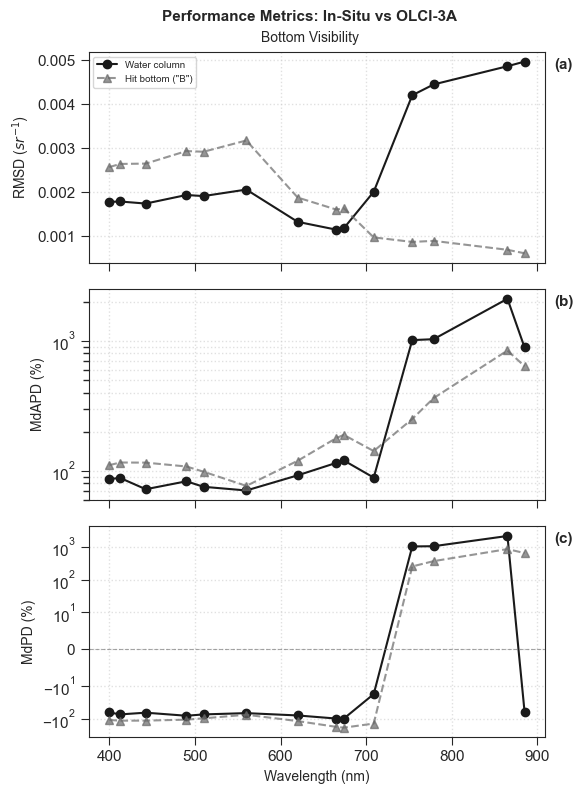

In [46]:

# 2. Calculate metrics for both groups
rmsd_water = calculate_band_rmsd(df_water)
rmsd_bottom = calculate_band_rmsd(df_bottom)

mdapd_water = calculate_band_mdapd(df_water)
mdapd_bottom = calculate_band_mdapd(df_bottom)

mdpd_water = calculate_band_mdpd(df_water)
mdpd_bottom = calculate_band_mdpd(df_bottom)

# 3. Plot comparison figures (Water Column vs. Bottom Hit)
fig, axes = plt.subplots(3, 1, figsize=(6, 8), sharex=True)

# RMSD
axes[0].plot(rmsd_water["Wavelength"], rmsd_water["RMSD"], marker="o", color="k", linestyle="-", label="Water column")
axes[0].plot(rmsd_bottom["Wavelength"], rmsd_bottom["RMSD"], marker="^", color="dimgrey", linestyle="--", alpha=0.7, label='Hit bottom ("B")')
axes[0].set_ylabel("RMSD ($sr^{-1}$)", fontsize=10)
axes[0].grid(True, linestyle=":", alpha=0.6)
axes[0].legend(fontsize=7, loc="upper left")
axes[0].text(1.02, 0.92, "(a)", transform=axes[0].transAxes, fontsize=11, fontweight="bold")

# MdAPD (log scale)
axes[1].plot(mdapd_water["Wavelength"], mdapd_water["MdAPD"], marker="o", color="k", linestyle="-", label="Water column")
axes[1].plot(mdapd_bottom["Wavelength"], mdapd_bottom["MdAPD"], marker="^", color="dimgrey", linestyle="--", alpha=0.7, label='Hit bottom ("B")')
axes[1].set_yscale("log")
axes[1].set_ylabel("MdAPD (%)", fontsize=10)
axes[1].grid(True, linestyle=":", alpha=0.6, which="both")
axes[1].text(1.02, 0.92, "(b)", transform=axes[1].transAxes, fontsize=11, fontweight="bold")

# MdPD (symlog scale)
axes[2].plot(mdpd_water["Wavelength"], mdpd_water["MdPD"], marker="o", color="k", linestyle="-", label="Water column")
axes[2].plot(mdpd_bottom["Wavelength"], mdpd_bottom["MdPD"], marker="^", color="dimgrey", linestyle="--", alpha=0.7, label='Hit bottom ("B")')
axes[2].set_yscale("symlog", linthresh=10)
axes[2].set_ylabel("MdPD (%)", fontsize=10)
axes[2].set_xlabel("Wavelength (nm)", fontsize=10)
axes[2].grid(True, linestyle=":", alpha=0.6, which="both")
axes[2].axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
axes[2].text(1.02, 0.92, "(c)", transform=axes[2].transAxes, fontsize=11, fontweight="bold")

fig.suptitle("Performance Metrics: In-Situ vs OLCI-3A", fontsize=11, fontweight="bold", x=0.53, y=0.99)
fig.text(0.53, 0.95, "Bottom Visibility", ha="center", fontsize=10, style="normal")
plt.tight_layout()
plt.savefig("C:/Users/25298423/PycharmProjects/FinalFigures/PerformanceMetrics_BottomHit_insitu_3A.png", dpi=1200, bbox_inches="tight")
plt.show()

In [47]:
import pandas as pd

def get_counts(df_sub, wavelengths):
    n_list = []
    for wl in wavelengths:
        col_insitu = f"Rrs_srf_{wl}"
        matching_sat_cols = [
            c for c in df_sub.columns
            if c.startswith('sat_Rrs_') and abs(float(c.replace('sat_Rrs_', '')) - wl) < 0.3
        ]
        if matching_sat_cols and col_insitu in df_sub.columns:
            valid_mask = df_sub[col_insitu].notna() & df_sub[matching_sat_cols[0]].notna()
            n_list.append(int(valid_mask.sum()))
        else:
            n_list.append(0)
    return n_list

wavelengths = rmsd_water["Wavelength"].values

# Build water column table safely
table_water = pd.DataFrame({"Wavelength": wavelengths})
table_water["N (Water Column)"] = get_counts(df_water, wavelengths)
table_water["RMSE (Water Column)"] = rmsd_water["RMSD"].values
table_water["MdAPD (Water Column)"] = mdapd_water["MdAPD"].values
table_water["MdPD (Water Column)"] = mdpd_water["MdPD"].values

# Build bottom hit table safely
table_bottom = pd.DataFrame({"Wavelength": wavelengths})
table_bottom["N (Hit Bottom \"B\")"] = get_counts(df_bottom, wavelengths)
table_bottom["RMSE (Hit Bottom \"B\")"] = rmsd_bottom["RMSD"].values
table_bottom["MdAPD (Hit Bottom \"B\")"] = mdapd_bottom["MdAPD"].values
table_bottom["MdPD (Hit Bottom \"B\")"] = mdpd_bottom["MdPD"].values

# Merge side-by-side
final_table_secchi = pd.merge(table_water, table_bottom, on="Wavelength")

# Format RMSE columns to 3 significant figures
rmse_cols = [c for c in final_table_secchi.columns if "RMSE" in c]
for col in rmse_cols:
    final_table_secchi[col] = final_table_secchi[col].apply(lambda x: f"{x:.3g}" if pd.notnull(x) else x)

# Round percentage metrics (MdAPD, MdPD) to 2 decimal places
pct_cols = [c for c in final_table_secchi.columns if c != "Wavelength" and not c.startswith("N") and c not in rmse_cols]
for col in pct_cols:
    final_table_secchi[col] = final_table_secchi[col].round(2)

final_table_secchi

,Wavelength,N (Water Column),RMSE (Water Column),MdAPD (Water Column),MdPD (Water Column),"N (Hit Bottom ""B"")","RMSE (Hit Bottom ""B"")","MdAPD (Hit Bottom ""B"")","MdPD (Hit Bottom ""B"")"
0,400.0,17,0.00178,86.37,-65.05,7,0.00257,110.48,-110.48
1,412.5,17,0.00178,88.13,-74.81,7,0.00264,115.79,-115.79
2,442.5,17,0.00174,72.11,-66.25,7,0.00265,115.53,-115.53
3,490.0,17,0.00193,83.02,-82.13,7,0.00293,107.91,-107.91
4,510.0,17,0.00191,75.30,-74.81,7,0.00292,98.40,-98.40
5,560.0,17,0.00206,70.55,-68.37,7,0.00317,76.51,-76.51
6,620.0,17,0.00132,92.25,-80.47,7,0.00187,119.40,-119.40
7,665.0,17,0.00115,115.01,-99.84,7,0.0016,178.37,-178.37
8,673.8,17,0.00118,120.16,-100.54,7,0.00163,188.99,-188.99
9,708.8,17,0.00201,88.60,-18.07,7,0.000969,141.85,-141.85


## Data without Anomalous Values (NO ISO-08 and ISO-29)

### All Non Anomalous Values (no partitioning)

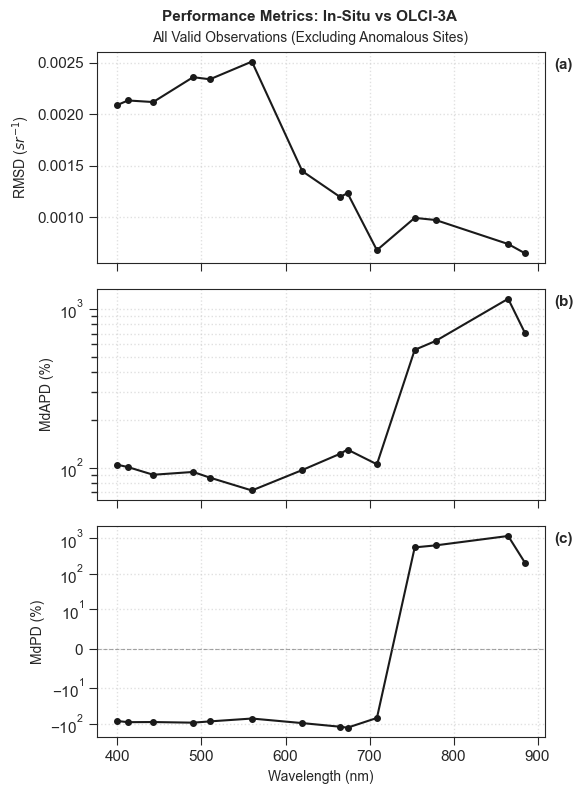


--- Overall Performance Metrics Table (Cleaned) ---
 Wavelength  N     RMSE   MdAPD    MdPD
      400.0 22  0.00209  104.61  -84.67
      412.5 22  0.00213  101.18  -91.28
      442.5 22  0.00212   90.51  -90.51
      490.0 22  0.00236   94.27  -94.27
      510.0 22  0.00234   86.82  -86.82
      560.0 22  0.00251   72.08  -72.08
      620.0 22  0.00145   96.94  -96.94
      665.0 22   0.0012  122.69 -122.69
      673.8 22  0.00123  130.37 -130.37
      708.8 22 0.000681  105.33  -69.48
      753.8 22 0.000994  553.10  553.10
      778.8 22 0.000973  629.66  629.66
      865.0 22  0.00074 1159.57 1159.57
      885.0 22  0.00065  706.80  204.68


In [48]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 0. Filter out anomalous sites ISO-08A and ISO-29 completely from the dataframe
exclude_sites = ['ISO-08A*', 'ISO-08A', 'ISO-29*', 'ISO-29']
drop_mask = df_s3a_matched['Site'].isin(exclude_sites) | df_s3a_matched['Site'].str.contains(r'ISO-(?:08A|29)', regex=True, na=False)
df_clean = df_s3a_matched[~drop_mask].copy()

# Metric calculation functions
def calculate_band_rmsd(df, insitu_prefix="Rrs_srf_", sat_prefix="sat_Rrs_"):
    insitu_cols = [c for c in df.columns if c.startswith(insitu_prefix)]
    results = {}
    for insitu_col in insitu_cols:
        match = re.search(r"\d+(\.\d+)?", insitu_col)
        if not match:
            continue
        wl = match.group()
        sat_col = f"{sat_prefix}{wl}"
        if sat_col in df.columns:
            subset = df[[insitu_col, sat_col]].dropna()
            if len(subset) > 0:
                sat_vals = subset[sat_col].values.astype(float)
                insitu_vals = subset[insitu_col].values.astype(float)
                rmsd = np.sqrt(np.mean((sat_vals - insitu_vals) ** 2))
                results[float(wl)] = rmsd
    return pd.DataFrame(list(results.items()), columns=["Wavelength", "RMSD"]).sort_values("Wavelength").reset_index(drop=True)

def calculate_band_mdapd(df, insitu_prefix="Rrs_srf_", sat_prefix="sat_Rrs_"):
    insitu_cols = [c for c in df.columns if c.startswith(insitu_prefix)]
    results = {}
    for insitu_col in insitu_cols:
        match = re.search(r"\d+(\.\d+)?", insitu_col)
        if not match:
            continue
        wl = match.group()
        sat_col = f"{sat_prefix}{wl}"
        if sat_col in df.columns:
            subset = df[[insitu_col, sat_col]].dropna()
            if len(subset) > 0:
                sat_vals = subset[sat_col].values.astype(float)
                insitu_vals = subset[insitu_col].values.astype(float)
                valid_mask = insitu_vals != 0
                if valid_mask.sum() > 0:
                    s_vals = sat_vals[valid_mask]
                    i_vals = insitu_vals[valid_mask]
                    abs_pct_diffs = np.abs((s_vals - i_vals) / i_vals) * 100
                    results[float(wl)] = np.median(abs_pct_diffs)
    return pd.DataFrame(list(results.items()), columns=["Wavelength", "MdAPD"]).sort_values("Wavelength").reset_index(drop=True)

def calculate_band_mdpd(df, insitu_prefix="Rrs_srf_", sat_prefix="sat_Rrs_"):
    insitu_cols = [c for c in df.columns if c.startswith(insitu_prefix)]
    results = {}
    for insitu_col in insitu_cols:
        match = re.search(r"\d+(\.\d+)?", insitu_col)
        if not match:
            continue
        wl = match.group()
        sat_col = f"{sat_prefix}{wl}"
        if sat_col in df.columns:
            subset = df[[insitu_col, sat_col]].dropna()
            if len(subset) > 0:
                sat_vals = subset[sat_col].values.astype(float)
                insitu_vals = subset[insitu_col].values.astype(float)
                valid_mask = insitu_vals != 0
                if valid_mask.sum() > 0:
                    s_vals = sat_vals[valid_mask]
                    i_vals = insitu_vals[valid_mask]
                    pct_diffs = ((s_vals - i_vals) / i_vals) * 100
                    results[float(wl)] = np.median(pct_diffs)
    return pd.DataFrame(list(results.items()), columns=["Wavelength", "MdPD"]).sort_values("Wavelength").reset_index(drop=True)

# Compute metrics on the cleaned dataframe
rmsd_df = calculate_band_rmsd(df_clean)
mdapd_df = calculate_band_mdapd(df_clean)
mdpd_df = calculate_band_mdpd(df_clean)

# 1. Plotting Code
fig, axes = plt.subplots(3, 1, figsize=(6, 8), sharex=True)

axes[0].plot(rmsd_df["Wavelength"], rmsd_df["RMSD"], marker="o", color="k", linewidth=1.5, markersize=4)
axes[0].set_ylabel("RMSD ($sr^{-1}$)", fontsize=10)
axes[0].grid(True, linestyle=":", alpha=0.6)
axes[0].text(1.02, 0.92, "(a)", transform=axes[0].transAxes, fontsize=11, fontweight="bold")

axes[1].plot(mdapd_df["Wavelength"], mdapd_df["MdAPD"], marker="o", color="k", linewidth=1.5, markersize=4)
axes[1].set_yscale("log")
axes[1].set_ylabel("MdAPD (%)", fontsize=10)
axes[1].grid(True, linestyle=":", alpha=0.6, which="both")
axes[1].text(1.02, 0.92, "(b)", transform=axes[1].transAxes, fontsize=11, fontweight="bold")

axes[2].plot(mdpd_df["Wavelength"], mdpd_df["MdPD"], marker="o", color="k", linewidth=1.5, markersize=4)
axes[2].set_yscale("symlog", linthresh=10)
axes[2].set_ylabel("MdPD (%)", fontsize=10)
axes[2].set_xlabel("Wavelength (nm)", fontsize=10)
axes[2].grid(True, linestyle=":", alpha=0.6, which="both")
axes[2].text(1.02, 0.92, "(c)", transform=axes[2].transAxes, fontsize=11, fontweight="bold")

axes[2].axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
fig.suptitle("Performance Metrics: In-Situ vs OLCI-3A", fontsize=11, fontweight="bold", x=0.53, y=0.99)
fig.text(0.53, 0.95, "All Valid Observations (Excluding Anomalous Sites)", ha="center", fontsize=10, style="normal")
plt.tight_layout()
plt.savefig("C:/Users/25298423/PycharmProjects/FinalFigures/PerformanceMetrics_insitu_3A_Clean.png",
    dpi=1200,
    bbox_inches="tight",
)
plt.show()

# 2. Build and format summary table with N, 3 sig fig RMSE, and 2 decimal place percentages
def get_counts(df_sub, wavelengths):
    n_list = []
    for wl in wavelengths:
        col_insitu = f"Rrs_srf_{wl}"
        matching_sat_cols = [
            c for c in df_sub.columns
            if c.startswith('sat_Rrs_') and abs(float(c.replace('sat_Rrs_', '')) - wl) < 0.3
        ]
        if matching_sat_cols and col_insitu in df_sub.columns:
            valid_mask = df_sub[col_insitu].notna() & df_sub[matching_sat_cols[0]].notna()
            n_list.append(int(valid_mask.sum()))
        else:
            n_list.append(0)
    return n_list

wavelengths = rmsd_df["Wavelength"].values

summary_table = pd.DataFrame({"Wavelength": wavelengths})
summary_table["N"] = get_counts(df_clean, wavelengths)
summary_table["RMSE"] = rmsd_df["RMSD"].values
summary_table["MdAPD"] = mdapd_df["MdAPD"].values
summary_table["MdPD"] = mdpd_df["MdPD"].values

# Format RMSE to 3 significant figures and percentages to 2 decimal places
summary_table["RMSE"] = summary_table["RMSE"].apply(lambda x: f"{x:.3g}" if pd.notnull(x) else x)
summary_table["MdAPD"] = summary_table["MdAPD"].round(2)
summary_table["MdPD"] = summary_table["MdPD"].round(2)

print("\n--- Overall Performance Metrics Table (Cleaned) ---")
print(summary_table.to_string(index=False))

In [49]:
summary_table

,Wavelength,N,RMSE,MdAPD,MdPD
0,400.0,22,0.00209,104.61,-84.67
1,412.5,22,0.00213,101.18,-91.28
2,442.5,22,0.00212,90.51,-90.51
3,490.0,22,0.00236,94.27,-94.27
4,510.0,22,0.00234,86.82,-86.82
5,560.0,22,0.00251,72.08,-72.08
6,620.0,22,0.00145,96.94,-96.94
7,665.0,22,0.0012,122.69,-122.69
8,673.8,22,0.00123,130.37,-130.37
9,708.8,22,0.000681,105.33,-69.48


### Distance to Shore, No Anomalies

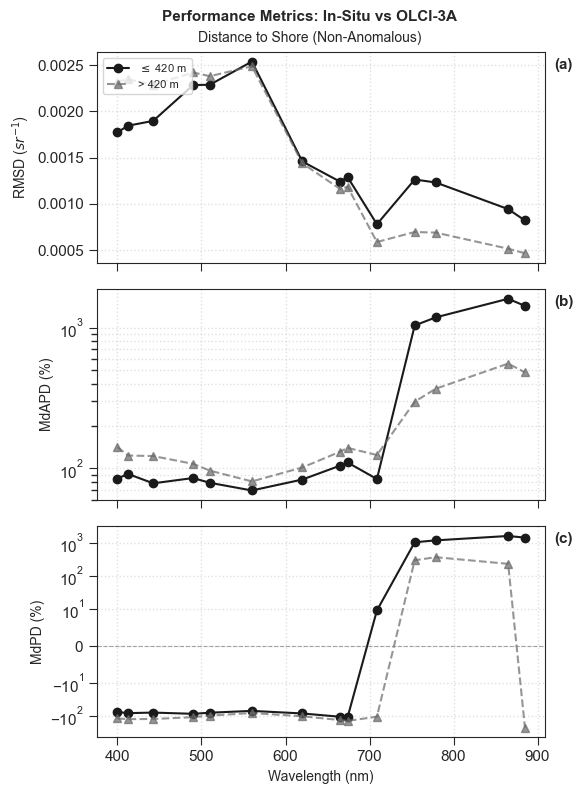

,Wavelength,N (<=420m),RMSE (<=420m),MdAPD (<=420m),MdPD (<=420m),N (>420m),RMSE (>420m),MdAPD (>420m),MdPD (>420m)
0,400.0,10,0.00177,84.67,-74.83,12,0.00232,141.64,-118.02
1,412.5,10,0.00184,91.28,-81.47,12,0.00235,123.37,-123.37
2,442.5,10,0.0019,78.27,-78.27,12,0.00229,122.32,-122.32
3,490.0,10,0.00228,85.35,-85.35,12,0.00242,107.66,-107.66
4,510.0,10,0.00229,78.92,-78.92,12,0.00238,96.36,-96.36
5,560.0,10,0.00254,69.63,-69.63,12,0.00249,80.77,-80.77
6,620.0,10,0.00146,83.26,-83.26,12,0.00144,101.42,-101.42
7,665.0,10,0.00124,104.56,-104.56,12,0.00116,131.34,-131.34
8,673.8,10,0.00129,110.12,-110.12,12,0.00119,139.87,-139.87
9,708.8,10,0.000779,83.98,9.65,12,0.000587,124.40,-103.96


In [50]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 0. Filter out anomalous sites ISO-08A and ISO-29 completely (na = non-anomalous)
exclude_sites = ['ISO-08A*', 'ISO-08A', 'ISO-29*', 'ISO-29']
drop_mask = df_s3a_matched['Site'].isin(exclude_sites) | df_s3a_matched['Site'].str.contains(r'ISO-(?:08A|29)', regex=True, na=False)
df_clean_na = df_s3a_matched[~drop_mask].copy()

# 1. Split the cleaned dataframe into two groups based on distance to shore
df_near_na = df_clean_na[df_clean_na["dist_to_shore_m"] <= 420]
df_far_na = df_clean_na[df_clean_na["dist_to_shore_m"] > 420]

# 2. Calculate metrics for both groups
rmsd_near_na = calculate_band_rmsd(df_near_na)
rmsd_far_na = calculate_band_rmsd(df_far_na)

mdapd_near_na = calculate_band_mdapd(df_near_na)
mdapd_far_na = calculate_band_mdapd(df_far_na)

mdpd_near_na = calculate_band_mdpd(df_near_na)
mdpd_far_na = calculate_band_mdpd(df_far_na)

# 3. Plot comparison figures
fig, axes = plt.subplots(3, 1, figsize=(6, 8), sharex=True)

# RMSD
axes[0].plot(rmsd_near_na["Wavelength"], rmsd_near_na["RMSD"], marker="o", color="k", linestyle="-", label=r"$\leq$ 420 m")
axes[0].plot(rmsd_far_na["Wavelength"], rmsd_far_na["RMSD"], marker="^", color="dimgrey", linestyle="--", alpha=0.7, label="> 420 m")
axes[0].set_ylabel("RMSD ($sr^{-1}$)", fontsize=10)

axes[0].grid(True, linestyle=":", alpha=0.6)
axes[0].legend(fontsize=8, loc="upper left")
axes[0].text(1.02, 0.92, "(a)", transform=axes[0].transAxes, fontsize=11, fontweight="bold")

# MdAPD (log scale)
axes[1].plot(mdapd_near_na["Wavelength"], mdapd_near_na["MdAPD"], marker="o", color="k", linestyle="-", label=r"$\leq$ 420 m")
axes[1].plot(mdapd_far_na["Wavelength"], mdapd_far_na["MdAPD"], marker="^", color="dimgrey", linestyle="--", alpha=0.7, label="> 420 m")
axes[1].set_yscale("log")
axes[1].set_ylabel("MdAPD (%)", fontsize=10)

axes[1].grid(True, linestyle=":", alpha=0.6, which="both")
axes[1].text(1.02, 0.92, "(b)", transform=axes[1].transAxes, fontsize=11, fontweight="bold")

# MdPD (symlog scale)
axes[2].plot(mdpd_near_na["Wavelength"], mdpd_near_na["MdPD"], marker="o", color="k", linestyle="-", label=r"$\leq$ 420 m")
axes[2].plot(mdpd_far_na["Wavelength"], mdpd_far_na["MdPD"], marker="^", color="dimgrey", linestyle="--", alpha=0.7, label="> 420 m")
axes[2].set_yscale("symlog", linthresh=10)
axes[2].set_ylabel("MdPD (%)", fontsize=10)
axes[2].set_xlabel("Wavelength (nm)", fontsize=10)

axes[2].grid(True, linestyle=":", alpha=0.6, which="both")
axes[2].axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
axes[2].text(1.02, 0.92, "(c)", transform=axes[2].transAxes, fontsize=11, fontweight="bold")
fig.suptitle("Performance Metrics: In-Situ vs OLCI-3A", fontsize=11, fontweight="bold", x=0.53, y=0.99)
fig.text(0.53, 0.95, "Distance to Shore (Non-Anomalous)", ha="center", fontsize=10, style="normal")
plt.tight_layout()
plt.savefig("C:/Users/25298423/PycharmProjects/FinalFigures/PerformanceMetrics_DistancetoShore_insitu_3A_Clean.png",
    dpi=1200,
    bbox_inches="tight",
)
plt.show()

# 4. Build Table
def get_counts(df_sub, wavelengths):
    n_list = []
    for wl in wavelengths:
        col_insitu = f"Rrs_srf_{wl}"
        matching_sat_cols = [
            c for c in df_sub.columns
            if c.startswith('sat_Rrs_') and abs(float(c.replace('sat_Rrs_', '')) - wl) < 0.3
        ]
        if matching_sat_cols and col_insitu in df_sub.columns:
            valid_mask = df_sub[col_insitu].notna() & df_sub[matching_sat_cols[0]].notna()
            n_list.append(int(valid_mask.sum()))
        else:
            n_list.append(0)
    return n_list

wavelengths = rmsd_near_na["Wavelength"].values

table_near_na = pd.DataFrame({"Wavelength": wavelengths})
table_near_na["N (<=420m)"] = get_counts(df_near_na, wavelengths)
table_near_na["RMSE (<=420m)"] = rmsd_near_na["RMSD"].values
table_near_na["MdAPD (<=420m)"] = mdapd_near_na["MdAPD"].values
table_near_na["MdPD (<=420m)"] = mdpd_near_na["MdPD"].values

table_far_na = pd.DataFrame({"Wavelength": wavelengths})
table_far_na["N (>420m)"] = get_counts(df_far_na, wavelengths)
table_far_na["RMSE (>420m)"] = rmsd_far_na["RMSD"].values
table_far_na["MdAPD (>420m)"] = mdapd_far_na["MdAPD"].values
table_far_na["MdPD (>420m)"] = mdpd_far_na["MdPD"].values

final_table_na = pd.merge(table_near_na, table_far_na, on="Wavelength")

# Format RMSE columns to 3 significant figures
rmse_cols = [c for c in final_table_na.columns if "RMSE" in c]
for col in rmse_cols:
    final_table_na[col] = final_table_na[col].apply(lambda x: f"{x:.3g}" if pd.notnull(x) else x)

# Round percentage metrics (MdAPD, MdPD) to 2 decimal places
pct_cols = [c for c in final_table_na.columns if c != "Wavelength" and not c.startswith("N") and c not in rmse_cols]
for col in pct_cols:
    final_table_na[col] = final_table_na[col].round(2)

final_table_na

### Acquisition Time

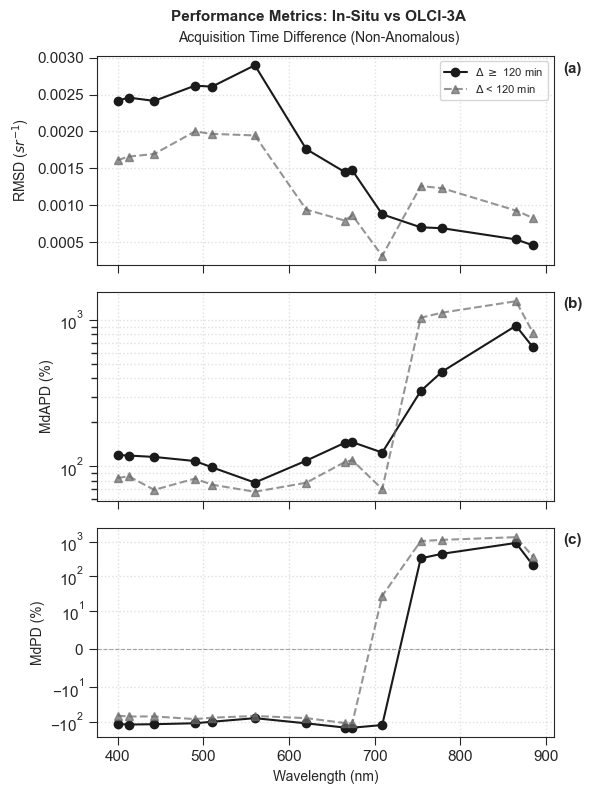

,Wavelength,N (>= -120m),RMSE (>= -120m),MdAPD (>= -120m),MdPD (>= -120m),N (< -120m),RMSE (< -120m),MdAPD (< -120m),MdPD (< -120m)
0,400.0,12,0.00242,119.69,-115.06,10,0.00161,83.31,-65.98
1,412.5,12,0.00246,118.71,-118.71,10,0.00166,85.77,-69.25
2,442.5,12,0.00242,116.12,-116.12,10,0.00169,69.18,-69.18
3,490.0,12,0.00262,108.87,-108.87,10,0.002,82.57,-82.57
4,510.0,12,0.00261,98.60,-98.60,10,0.00197,75.05,-75.05
5,560.0,12,0.0029,77.57,-77.57,10,0.00195,67.13,-67.13
6,620.0,12,0.00176,109.50,-109.50,10,0.000941,77.38,-77.38
7,665.0,12,0.00145,145.02,-145.02,10,0.000791,107.12,-107.12
8,673.8,12,0.00147,146.71,-146.71,10,0.000864,110.35,-110.35
9,708.8,12,0.000876,124.40,-122.55,10,0.000313,70.00,26.92


In [51]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 0. Filter out anomalous sites ISO-08A and ISO-29 completely (na = non-anomalous)
exclude_sites = ['ISO-08A*', 'ISO-08A', 'ISO-29*', 'ISO-29']
drop_mask = df_s3a_matched['Site'].isin(exclude_sites) | df_s3a_matched['Site'].str.contains(r'ISO-(?:08A|29)', regex=True, na=False)
df_clean_na = df_s3a_matched[~drop_mask].copy()

# 1. Split the cleaned dataframe into two groups based on acquisition time difference
df_soon_na = df_clean_na[df_clean_na["Time_Delta_mins"] >= -120]
df_later_na = df_clean_na[df_clean_na["Time_Delta_mins"] < -120]

# 2. Calculate metrics for both groups
rmsd_soon_na = calculate_band_rmsd(df_soon_na)
rmsd_later_na = calculate_band_rmsd(df_later_na)

mdapd_soon_na = calculate_band_mdapd(df_soon_na)
mdapd_later_na = calculate_band_mdapd(df_later_na)

mdpd_soon_na = calculate_band_mdpd(df_soon_na)
mdpd_later_na = calculate_band_mdpd(df_later_na)

# 3. Plot comparison figures
fig, axes = plt.subplots(3, 1, figsize=(6, 8), sharex=True)

# RMSD
axes[0].plot(rmsd_soon_na["Wavelength"], rmsd_soon_na["RMSD"], marker="o", color="k", linestyle="-", label=r'$\Delta$ $\geq$ 120 min')
axes[0].plot(rmsd_later_na["Wavelength"], rmsd_later_na["RMSD"], marker="^", color="dimgrey", linestyle="--", alpha=0.7, label=r'$\Delta$ < 120 min')
axes[0].set_ylabel("RMSD ($sr^{-1}$)", fontsize=10)

axes[0].grid(True, linestyle=":", alpha=0.6)
axes[0].legend(fontsize=8, loc="upper right")
axes[0].text(1.02, 0.92, "(a)", transform=axes[0].transAxes, fontsize=11, fontweight="bold")

# MdAPD (log scale)
axes[1].plot(mdapd_soon_na["Wavelength"], mdapd_soon_na["MdAPD"], marker="o", color="k", linestyle="-", label=r'$\Delta$ $\geq$ 120 min')
axes[1].plot(mdapd_later_na["Wavelength"], mdapd_later_na["MdAPD"], marker="^", color="dimgrey", linestyle="--", alpha=0.7, label=r'$\Delta$ < 120 min')
axes[1].set_yscale("log")
axes[1].set_ylabel("MdAPD (%)", fontsize=10)

axes[1].grid(True, linestyle=":", alpha=0.6, which="both")
axes[1].text(1.02, 0.92, "(b)", transform=axes[1].transAxes, fontsize=11, fontweight="bold")

# MdPD (symlog scale)
axes[2].plot(mdpd_soon_na["Wavelength"], mdpd_soon_na["MdPD"], marker="o", color="k", linestyle="-", label=r'$\Delta$ $\geq$ 120 min')
axes[2].plot(mdpd_later_na["Wavelength"], mdpd_later_na["MdPD"], marker="^", color="dimgrey", linestyle="--", alpha=0.7, label=r'$\Delta$ < 120 min')
axes[2].set_yscale("symlog", linthresh=10)
axes[2].set_ylabel("MdPD (%)", fontsize=10)
axes[2].set_xlabel("Wavelength (nm)", fontsize=10)

axes[2].grid(True, linestyle=":", alpha=0.6, which="both")
axes[2].axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
axes[2].text(1.02, 0.92, "(c)", transform=axes[2].transAxes, fontsize=11, fontweight="bold")
fig.suptitle("Performance Metrics: In-Situ vs OLCI-3A", fontsize=11, fontweight="bold", x=0.53, y=0.99)
fig.text(0.53, 0.95, "Acquisition Time Difference (Non-Anomalous)", ha="center", fontsize=10, style="normal")
plt.tight_layout()
plt.savefig("C:/Users/25298423/PycharmProjects/FinalFigures/PerformanceMetrics_TimingwithSat_insitu_3A_Clean.png",
    dpi=1200,
    bbox_inches="tight",
)
plt.show()

# 4. Build Table
def get_counts(df_sub, wavelengths):
    n_list = []
    for wl in wavelengths:
        col_insitu = f"Rrs_srf_{wl}"
        matching_sat_cols = [
            c for c in df_sub.columns
            if c.startswith('sat_Rrs_') and abs(float(c.replace('sat_Rrs_', '')) - wl) < 0.3
        ]
        if matching_sat_cols and col_insitu in df_sub.columns:
            valid_mask = df_sub[col_insitu].notna() & df_sub[matching_sat_cols[0]].notna()
            n_list.append(int(valid_mask.sum()))
        else:
            n_list.append(0)
    return n_list

wavelengths = rmsd_soon_na["Wavelength"].values

table_soon_na = pd.DataFrame({"Wavelength": wavelengths})
table_soon_na["N (>= -120m)"] = get_counts(df_soon_na, wavelengths)
table_soon_na["RMSE (>= -120m)"] = rmsd_soon_na["RMSD"].values
table_soon_na["MdAPD (>= -120m)"] = mdapd_soon_na["MdAPD"].values
table_soon_na["MdPD (>= -120m)"] = mdpd_soon_na["MdPD"].values

table_later_na = pd.DataFrame({"Wavelength": wavelengths})
table_later_na["N (< -120m)"] = get_counts(df_later_na, wavelengths)
table_later_na["RMSE (< -120m)"] = rmsd_later_na["RMSD"].values
table_later_na["MdAPD (< -120m)"] = mdapd_later_na["MdAPD"].values
table_later_na["MdPD (< -120m)"] = mdpd_later_na["MdPD"].values

final_table_time_na = pd.merge(table_soon_na, table_later_na, on="Wavelength")

# Format RMSE columns to 3 significant figures
rmse_cols = [c for c in final_table_time_na.columns if "RMSE" in c]
for col in rmse_cols:
    final_table_time_na[col] = final_table_time_na[col].apply(lambda x: f"{x:.3g}" if pd.notnull(x) else x)

# Round percentage metrics (MdAPD, MdPD) to 2 decimal places
pct_cols = [c for c in final_table_time_na.columns if c != "Wavelength" and not c.startswith("N") and c not in rmse_cols]
for col in pct_cols:
    final_table_time_na[col] = final_table_time_na[col].round(2)

final_table_time_na

### Bottom Visibility (Secchi)

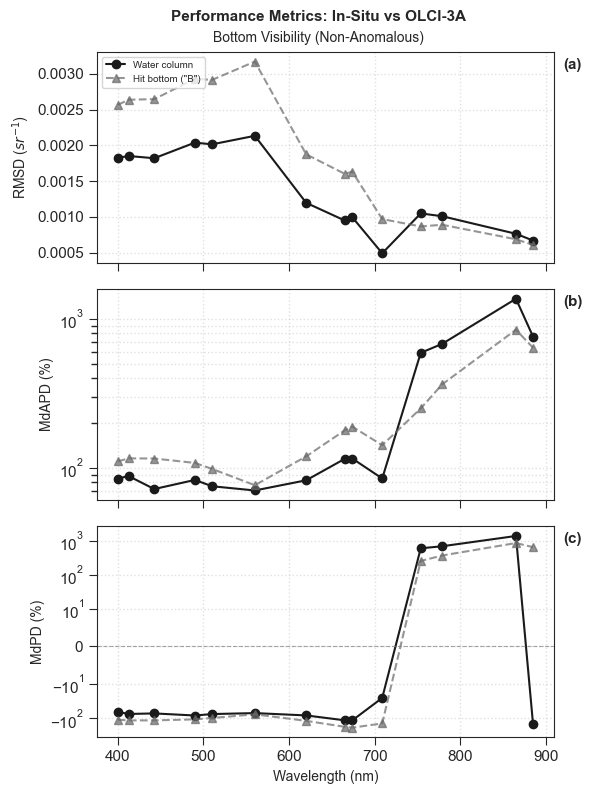

,Wavelength,N (Water Column),RMSE (Water Column),MdAPD (Water Column),MdPD (Water Column),"N (Hit Bottom ""B"")","RMSE (Hit Bottom ""B"")","MdAPD (Hit Bottom ""B"")","MdPD (Hit Bottom ""B"")"
0,400.0,15,0.00183,84.73,-65.05,7,0.00257,110.48,-110.48
1,412.5,15,0.00185,88.13,-74.81,7,0.00264,115.79,-115.79
2,442.5,15,0.00182,72.11,-72.11,7,0.00265,115.53,-115.53
3,490.0,15,0.00204,83.02,-83.02,7,0.00293,107.91,-107.91
4,510.0,15,0.00201,75.30,-75.30,7,0.00292,98.40,-98.40
5,560.0,15,0.00213,70.55,-70.55,7,0.00317,76.51,-76.51
6,620.0,15,0.0012,82.56,-82.56,7,0.00187,119.40,-119.40
7,665.0,15,0.00095,114.94,-114.94,7,0.0016,178.37,-178.37
8,673.8,15,0.000995,115.54,-115.54,7,0.00163,188.99,-188.99
9,708.8,15,0.000491,84.88,-25.28,7,0.000969,141.85,-141.85


In [52]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 0. Filter out anomalous sites ISO-08A and ISO-29 completely (na = non-anomalous)
exclude_sites = ['ISO-08A*', 'ISO-08A', 'ISO-29*', 'ISO-29']
drop_mask = df_s3a_matched['Site'].isin(exclude_sites) | df_s3a_matched['Site'].str.contains(r'ISO-(?:08A|29)', regex=True, na=False)
df_clean_na = df_s3a_matched[~drop_mask].copy()

# 1. Split the cleaned dataframe into groups based on whether Secchi hit the bottom ('B' in Notes)
has_b = df_clean_na["Notes"].str.contains("B", na=False)
df_water_na = df_clean_na[~has_b]
df_bottom_na = df_clean_na[has_b]

# 2. Calculate metrics for both groups
rmsd_water_na = calculate_band_rmsd(df_water_na)
rmsd_bottom_na = calculate_band_rmsd(df_bottom_na)

mdapd_water_na = calculate_band_mdapd(df_water_na)
mdapd_bottom_na = calculate_band_mdapd(df_bottom_na)

mdpd_water_na = calculate_band_mdpd(df_water_na)
mdpd_bottom_na = calculate_band_mdpd(df_bottom_na)

# 3. Plot comparison figures (Water Column vs. Bottom Hit)
fig, axes = plt.subplots(3, 1, figsize=(6, 8), sharex=True)

# RMSD
axes[0].plot(rmsd_water_na["Wavelength"], rmsd_water_na["RMSD"], marker="o", color="k", linestyle="-", label="Water column")
axes[0].plot(rmsd_bottom_na["Wavelength"], rmsd_bottom_na["RMSD"], marker="^", color="dimgrey", linestyle="--", alpha=0.7, label='Hit bottom ("B")')
axes[0].set_ylabel("RMSD ($sr^{-1}$)", fontsize=10)
axes[0].grid(True, linestyle=":", alpha=0.6)
axes[0].legend(fontsize=7, loc="upper left")
axes[0].text(1.02, 0.92, "(a)", transform=axes[0].transAxes, fontsize=11, fontweight="bold")

# MdAPD (log scale)
axes[1].plot(mdapd_water_na["Wavelength"], mdapd_water_na["MdAPD"], marker="o", color="k", linestyle="-", label="Water column")
axes[1].plot(mdapd_bottom_na["Wavelength"], mdapd_bottom_na["MdAPD"], marker="^", color="dimgrey", linestyle="--", alpha=0.7, label='Hit bottom ("B")')
axes[1].set_yscale("log")
axes[1].set_ylabel("MdAPD (%)", fontsize=10)
axes[1].grid(True, linestyle=":", alpha=0.6, which="both")
axes[1].text(1.02, 0.92, "(b)", transform=axes[1].transAxes, fontsize=11, fontweight="bold")

# MdPD (symlog scale)
axes[2].plot(mdpd_water_na["Wavelength"], mdpd_water_na["MdPD"], marker="o", color="k", linestyle="-", label="Water column")
axes[2].plot(mdpd_bottom_na["Wavelength"], mdpd_bottom_na["MdPD"], marker="^", color="dimgrey", linestyle="--", alpha=0.7, label='Hit bottom ("B")')
axes[2].set_yscale("symlog", linthresh=10)
axes[2].set_ylabel("MdPD (%)", fontsize=10)
axes[2].set_xlabel("Wavelength (nm)", fontsize=10)
axes[2].grid(True, linestyle=":", alpha=0.6, which="both")
axes[2].axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
axes[2].text(1.02, 0.92, "(c)", transform=axes[2].transAxes, fontsize=11, fontweight="bold")

fig.suptitle("Performance Metrics: In-Situ vs OLCI-3A", fontsize=11, fontweight="bold", x=0.53, y=0.99)
fig.text(0.53, 0.95, "Bottom Visibility (Non-Anomalous)", ha="center", fontsize=10, style="normal")
plt.tight_layout()
plt.savefig("C:/Users/25298423/PycharmProjects/FinalFigures/PerformanceMetrics_BottomHit_insitu_3A_Clean.png", dpi=1200, bbox_inches="tight")
plt.show()

# 4. Build Table
def get_counts(df_sub, wavelengths):
    n_list = []
    for wl in wavelengths:
        col_insitu = f"Rrs_srf_{wl}"
        matching_sat_cols = [
            c for c in df_sub.columns
            if c.startswith('sat_Rrs_') and abs(float(c.replace('sat_Rrs_', '')) - wl) < 0.3
        ]
        if matching_sat_cols and col_insitu in df_sub.columns:
            valid_mask = df_sub[col_insitu].notna() & df_sub[matching_sat_cols[0]].notna()
            n_list.append(int(valid_mask.sum()))
        else:
            n_list.append(0)
    return n_list

wavelengths = rmsd_water_na["Wavelength"].values

# Build water column table safely
table_water_na = pd.DataFrame({"Wavelength": wavelengths})
table_water_na["N (Water Column)"] = get_counts(df_water_na, wavelengths)
table_water_na["RMSE (Water Column)"] = rmsd_water_na["RMSD"].values
table_water_na["MdAPD (Water Column)"] = mdapd_water_na["MdAPD"].values
table_water_na["MdPD (Water Column)"] = mdpd_water_na["MdPD"].values

# Build bottom hit table safely
table_bottom_na = pd.DataFrame({"Wavelength": wavelengths})
table_bottom_na["N (Hit Bottom \"B\")"] = get_counts(df_bottom_na, wavelengths)
table_bottom_na["RMSE (Hit Bottom \"B\")"] = rmsd_bottom_na["RMSD"].values
table_bottom_na["MdAPD (Hit Bottom \"B\")"] = mdapd_bottom_na["MdAPD"].values
table_bottom_na["MdPD (Hit Bottom \"B\")"] = mdpd_bottom_na["MdPD"].values

# Merge side-by-side
final_table_secchi_na = pd.merge(table_water_na, table_bottom_na, on="Wavelength")

# Format RMSE columns to 3 significant figures
rmse_cols = [c for c in final_table_secchi_na.columns if "RMSE" in c]
for col in rmse_cols:
    final_table_secchi_na[col] = final_table_secchi_na[col].apply(lambda x: f"{x:.3g}" if pd.notnull(x) else x)

# Round percentage metrics (MdAPD, MdPD) to 2 decimal places
pct_cols = [c for c in final_table_secchi_na.columns if c != "Wavelength" and not c.startswith("N") and c not in rmse_cols]
for col in pct_cols:
    final_table_secchi_na[col] = final_table_secchi_na[col].round(2)

final_table_secchi_na

### Band by Band Regression Plot

In [53]:
## this first one (below) includes all sites that passed through the checks earlier

Valid plotted wavelengths (15): [400.0, 412.5, 442.5, 490.0, 510.0, 560.0, 620.0, 665.0, 673.8, 681.2, 708.8, 753.8, 778.8, 865.0, 885.0]


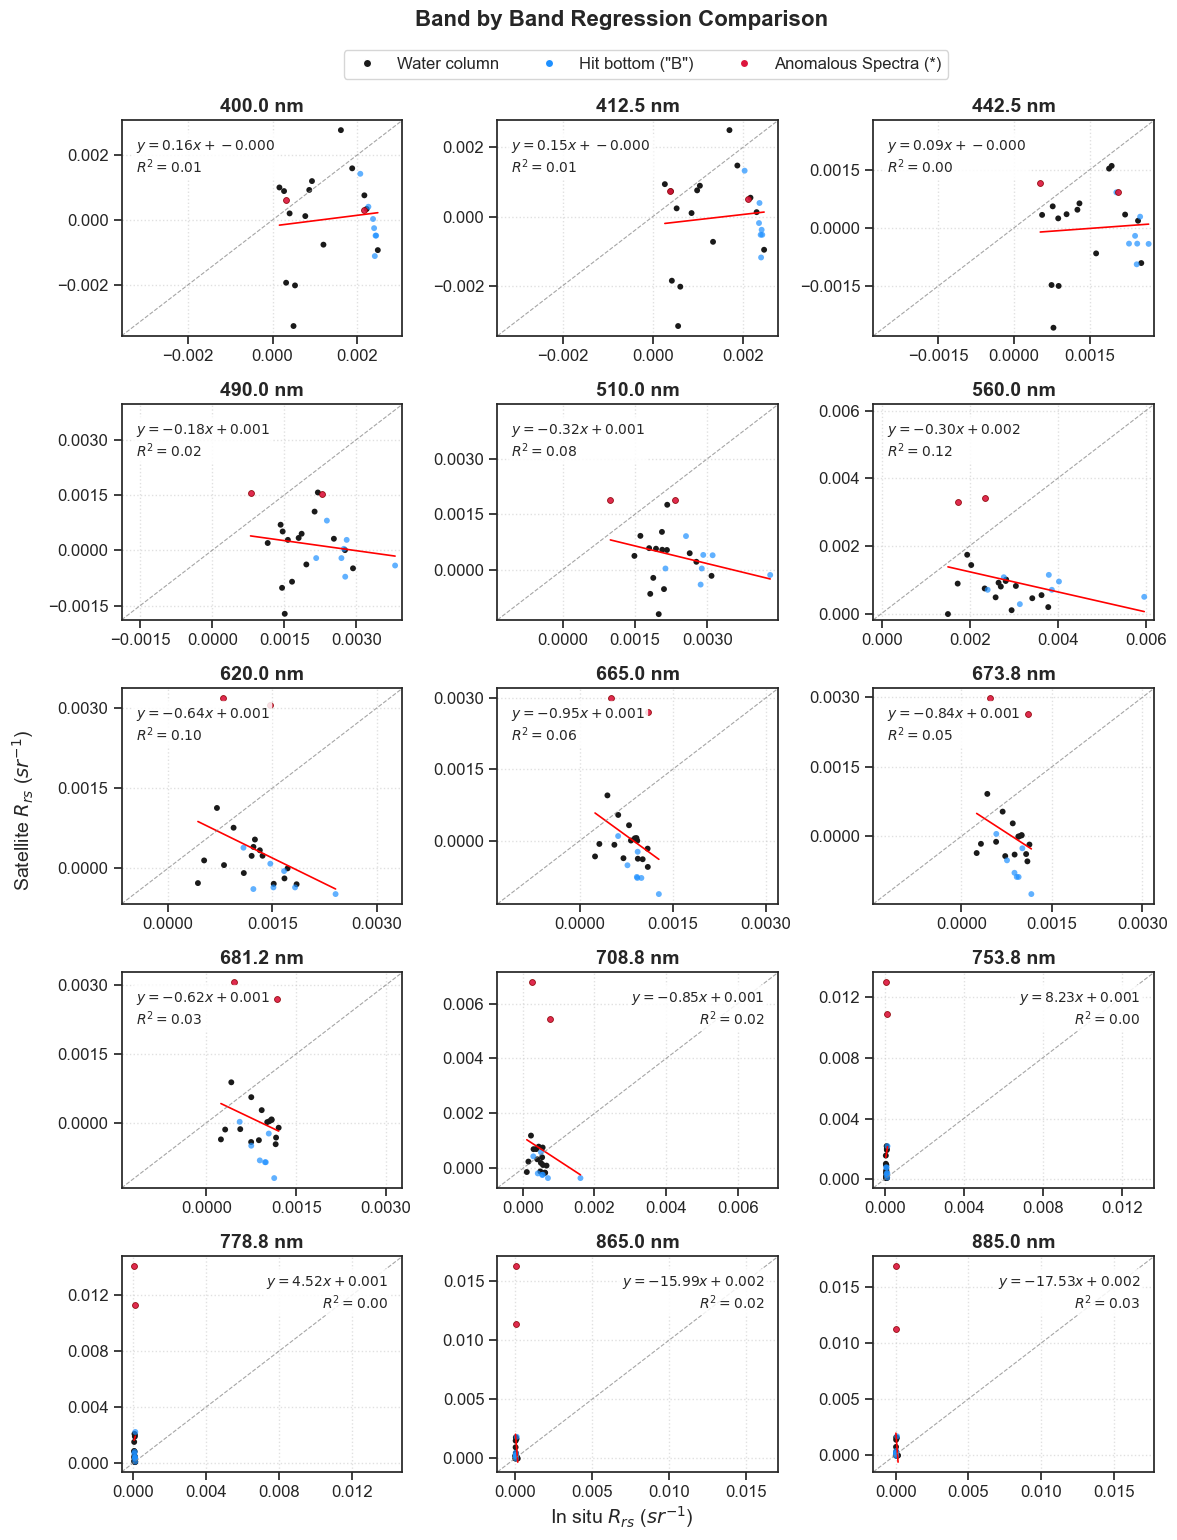

In [242]:
import re
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

# 0. Ensure Secchi notes are merged into the dataframe
if "Notes" not in df_s3a_matched.columns:
    df_s3a_matched = df_s3a_matched.merge(
        secchi[["Site", "Notes"]],
        on="Site",
        how="left"
    )

# 1. Dynamically extract and filter wavelengths that actually have matching satellite data
raw_wavelengths = []
for col in df_s3a_matched.columns:
    match = re.search(r'^Rrs_srf_([0-9.]+)$', col)
    if match:
        wl_val = float(match.group(1))
        if wl_val < 1000:
            raw_wavelengths.append(wl_val)

raw_wavelengths = sorted(raw_wavelengths)

valid_wavelengths = []
for wl in raw_wavelengths:
    matching_sat_cols = [c for c in df_s3a_matched.columns if c.startswith('sat_Rrs_') and abs(float(c.replace('sat_Rrs_', '')) - wl) < 0.3]
    if matching_sat_cols:
        valid_wavelengths.append((wl, matching_sat_cols[0]))

print(f"Valid plotted wavelengths ({len(valid_wavelengths)}): {[w[0] for w in valid_wavelengths]}")

# 2. Set up a regular, well-proportioned grid based strictly on valid wavelengths
n_bands = len(valid_wavelengths)
n_cols = 3
n_rows = (n_bands + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3.2 * n_rows))
axes = axes.flatten()

# Explicit list of outlier sites
outlier_sites = ['ISO-08A*', 'ISO-08A', 'ISO-29*', 'ISO-29']

for i, (wl, col_sat) in enumerate(valid_wavelengths):
    ax = axes[i]
    col_insitu = f"Rrs_srf_{wl}"

    x = df_s3a_matched[col_insitu]
    y = df_s3a_matched[col_sat]

    valid_mask = ~x.isna() & ~y.isna()
    x_v, y_v = x[valid_mask], y[valid_mask]

    site_series = df_s3a_matched.loc[valid_mask, "Site"]
    notes_series = df_s3a_matched.loc[valid_mask, "Notes"]

    is_outlier = site_series.isin(outlier_sites) | site_series.str.contains(r'ISO-(?:08A|29)', regex=True, na=False)
    mask_bottom = notes_series.str.contains("B", na=False) & ~is_outlier
    mask_water = ~is_outlier & ~mask_bottom

    # Scatter plots (solid black for water column)
    ax.scatter(x_v[mask_water], y_v[mask_water], color="k", marker="o", s=18, edgecolor="none")
    ax.scatter(x_v[mask_bottom], y_v[mask_bottom], color="dodgerblue", marker="o", s=18, alpha=0.7, edgecolor="none")
    ax.scatter(x_v[is_outlier], y_v[is_outlier], color="crimson", marker="o", s=18, alpha=0.9, edgecolor="darkred", linewidth=0.6)

    # Linear regression
    slope, intercept, r_value, _, _ = linregress(x_v, y_v)
    r2 = r_value ** 2

    x_line = np.linspace(x_v.min(), x_v.max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color="red", linewidth=1.2)

    # 1:1 Reference line
    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])
    ]
    ax.plot(lims, lims, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    # Restrict ticks to 3-4 per axis using MaxNLocator
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

    # Annotations: Top-right corner for >= 708.8 nm, default top-left otherwise
    if wl >= 708.8:
        eq_loc = (0.95, 0.92)
        eq_ha = 'right'
        eq_va = 'top'
    else:
        eq_loc = (0.05, 0.92)
        eq_ha = 'left'
        eq_va = 'top'

    eq_text = f"$y = {slope:.2f}x + {intercept:.3f}$\n$R^2 = {r2:.2f}$"
    ax.text(eq_loc[0], eq_loc[1], eq_text, transform=ax.transAxes, fontsize=10,
            ha=eq_ha, va=eq_va,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85))

    ax.set_title(f"{wl} nm", fontsize=14, fontweight="bold")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.tick_params(axis='both', which='major', labelsize=12)

# Clean up any leftover empty subplots if the grid has extra slots
for j in range(len(valid_wavelengths), len(axes)):
    fig.delaxes(axes[j])

# Global Legend placed safely above the top row with extra breathing room
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='k', markersize=6, label='Water column'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='dodgerblue', markersize=6, label='Hit bottom ("B")'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='crimson', markersize=6, label='Anomalous Spectra (*)')
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.55, 0.98), ncol=3, frameon=True, fontsize=12)

fig.supxlabel(r"In situ $R_{rs}$ ($sr^{-1}$)", fontsize=14, fontweight="normal", y=0.05, x=0.53)
fig.supylabel(r"Satellite $R_{rs}$ ($sr^{-1}$)", fontsize=14, fontweight="normal", x=0.02)
fig.suptitle(r"Band by Band Regression Comparison", fontsize=16, fontweight="bold", y=1.0, x=0.53)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.savefig("C:/Users/25298423/PycharmProjects/FinalFigures/Bandwise_Scatter_Regression_withAnamolous.png", dpi=1200, bbox_inches="tight")
plt.show()

In [55]:
import re
import numpy as np
import pandas as pd
from scipy.stats import linregress

# 0. Ensure Secchi notes are merged into the dataframe
if "Notes" not in df_s3a_matched.columns and 'secchi' in globals():
    df_s3a_matched = df_s3a_matched.merge(
        secchi[["Site", "Notes"]],
        on="Site",
        how="left"
    )

# 1. Dynamically extract and filter wavelengths that actually have matching satellite data
raw_wavelengths = []
for col in df_s3a_matched.columns:
    match = re.search(r'^Rrs_srf_([0-9.]+)$', col)
    if match:
        wl_val = float(match.group(1))
        if wl_val < 1000:
            raw_wavelengths.append(wl_val)

raw_wavelengths = sorted(raw_wavelengths)

valid_wavelengths = []
for wl in raw_wavelengths:
    matching_sat_cols = [c for c in df_s3a_matched.columns if c.startswith('sat_Rrs_') and abs(float(c.replace('sat_Rrs_', '')) - wl) < 0.3]
    if matching_sat_cols:
        valid_wavelengths.append((wl, matching_sat_cols[0]))

# 2. Calculate band-by-band regression metrics
regression_results = []

for wl, col_sat in valid_wavelengths:
    col_insitu = f"Rrs_srf_{wl}"

    x = df_s3a_matched[col_insitu]
    y = df_s3a_matched[col_sat]

    valid_mask = ~x.isna() & ~y.isna()
    x_v, y_v = x[valid_mask], y[valid_mask]

    if len(x_v) > 1:
        slope, intercept, r_value, _, _ = linregress(x_v, y_v)
        r2 = r_value ** 2
        n_matchups = len(x_v)
    else:
        slope, intercept, r2, n_matchups = np.nan, np.nan, np.nan, len(x_v)

    regression_results.append({
        'Wavelength (nm)': wl,
        'Slope': slope,
        'Intercept': intercept,
        'R2': r2,
        'N': n_matchups
    })

# 3. Create DataFrame and round numerical metrics
reg_metrics_df = pd.DataFrame(regression_results)
reg_metrics_df[['Slope', 'Intercept', 'R2']] = reg_metrics_df[['Slope', 'Intercept', 'R2']].round(4)

# Print to console and copy straight to clipboard for Word/Excel
print(reg_metrics_df.to_string(index=False))
reg_metrics_df.to_clipboard(excel=True, index=False)

 Wavelength (nm)    Slope  Intercept     R2  N
           400.0   0.1647    -0.0002 0.0126 24
           412.5   0.1492    -0.0002 0.0103 24
           442.5   0.0948    -0.0002 0.0049 24
           490.0  -0.1819     0.0005 0.0230 24
           510.0  -0.3182     0.0011 0.0791 24
           560.0  -0.2968     0.0018 0.1170 24
           620.0  -0.6387     0.0012 0.0962 24
           665.0  -0.9453     0.0008 0.0644 24
           673.8  -0.8447     0.0007 0.0511 24
           681.2  -0.6212     0.0006 0.0337 24
           708.8  -0.8520     0.0011 0.0203 24
           753.8   8.2274     0.0009 0.0041 24
           778.8   4.5197     0.0014 0.0008 24
           865.0 -15.9851     0.0021 0.0230 24
           885.0 -17.5299     0.0020 0.0269 24


In [56]:
## This one (below) excludes the anomalous data from the regression (ISO-08A and ISO-29)

Valid plotted wavelengths (15): [400.0, 412.5, 442.5, 490.0, 510.0, 560.0, 620.0, 665.0, 673.8, 681.2, 708.8, 753.8, 778.8, 865.0, 885.0]


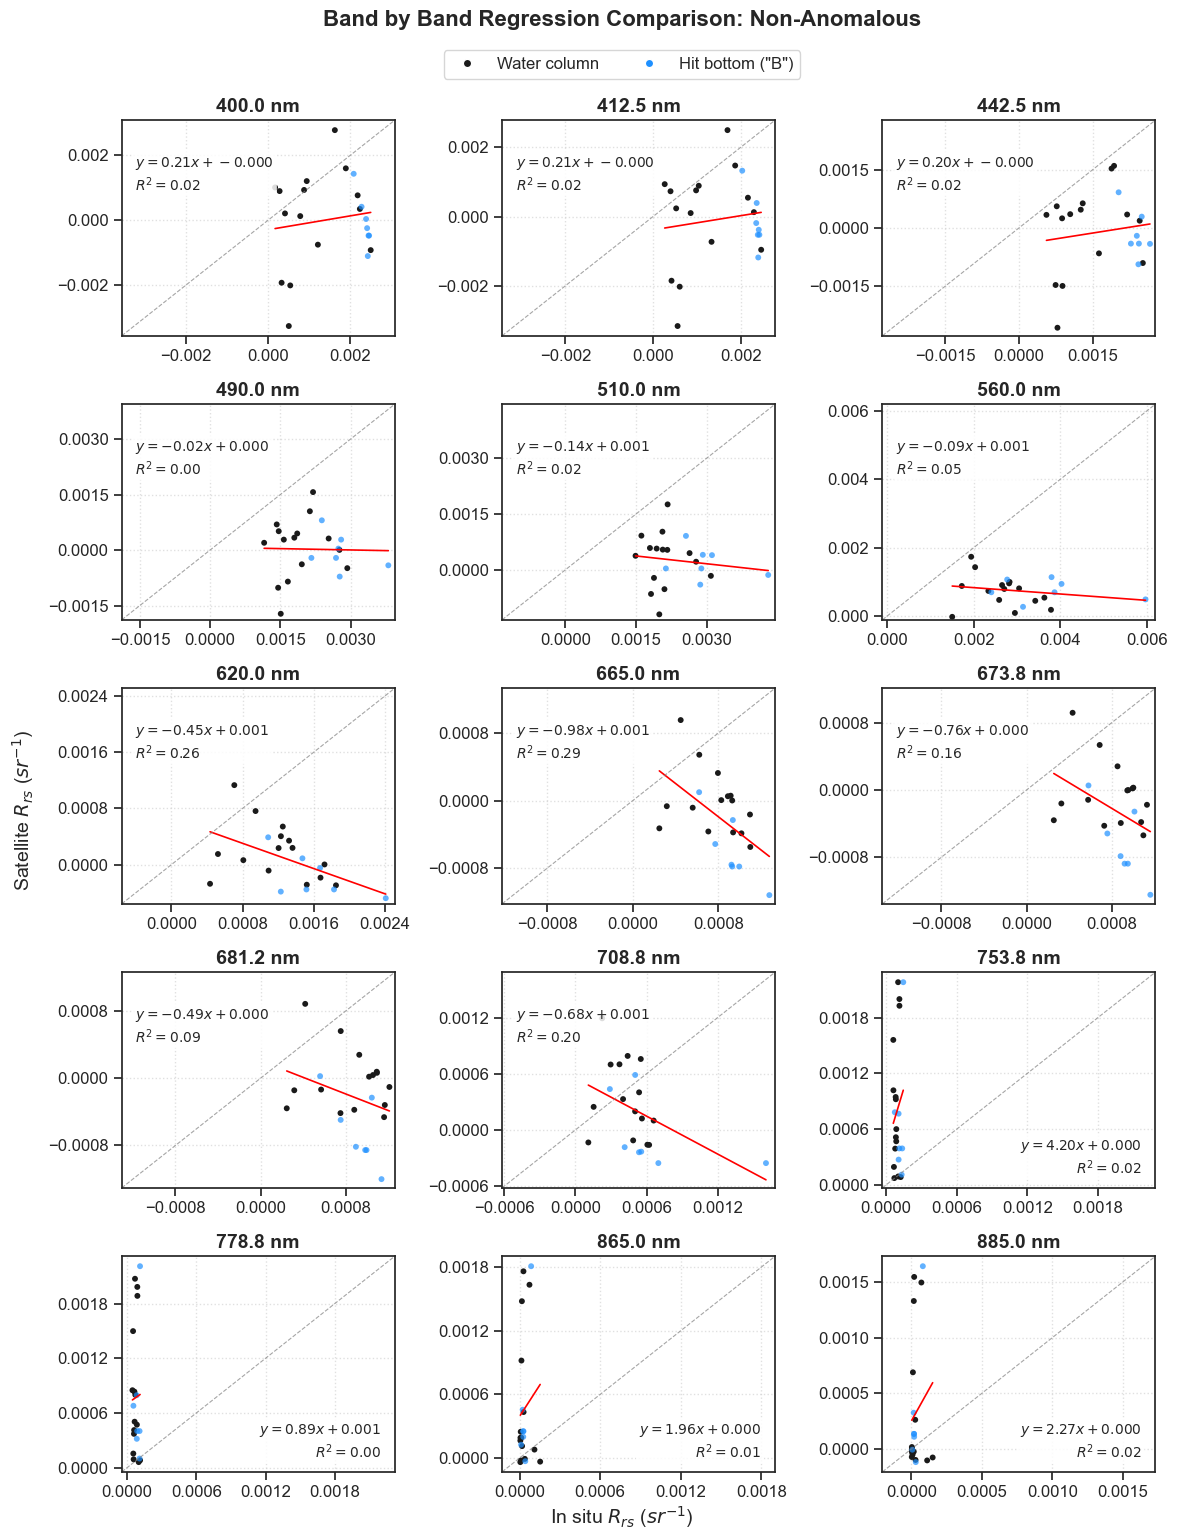

In [244]:
import re
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

# 0. Ensure Secchi notes are merged into the dataframe
if "Notes" not in df_s3a_matched.columns:
    df_s3a_matched = df_s3a_matched.merge(
        secchi[["Site", "Notes"]],
        on="Site",
        how="left"
    )

# Filter out ISO-08A and ISO-29 completely from the dataframe so they are neither plotted nor used in regressions
exclude_sites = ['ISO-08A*', 'ISO-08A', 'ISO-29*', 'ISO-29']
drop_mask = df_s3a_matched['Site'].isin(exclude_sites) | df_s3a_matched['Site'].str.contains(r'ISO-(?:08A|29)', regex=True, na=False)
df_s3a_clean = df_s3a_matched[~drop_mask].copy()

# 1. Dynamically extract and filter wavelengths that actually have matching satellite data
raw_wavelengths = []
for col in df_s3a_clean.columns:
    match = re.search(r'^Rrs_srf_([0-9.]+)$', col)
    if match:
        wl_val = float(match.group(1))
        if wl_val < 1000:
            raw_wavelengths.append(wl_val)

raw_wavelengths = sorted(raw_wavelengths)

valid_wavelengths = []
for wl in raw_wavelengths:
    matching_sat_cols = [c for c in df_s3a_clean.columns if c.startswith('sat_Rrs_') and abs(float(c.replace('sat_Rrs_', '')) - wl) < 0.3]
    if matching_sat_cols:
        valid_wavelengths.append((wl, matching_sat_cols[0]))

print(f"Valid plotted wavelengths ({len(valid_wavelengths)}): {[w[0] for w in valid_wavelengths]}")

# 2. Set up a regular, well-proportioned grid based strictly on valid wavelengths
n_bands = len(valid_wavelengths)
n_cols = 3
n_rows = (n_bands + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3.2 * n_rows))
axes = axes.flatten()

for i, (wl, col_sat) in enumerate(valid_wavelengths):
    ax = axes[i]
    col_insitu = f"Rrs_srf_{wl}"

    x = df_s3a_clean[col_insitu]
    y = df_s3a_clean[col_sat]

    valid_mask = ~x.isna() & ~y.isna()
    x_v, y_v = x[valid_mask], y[valid_mask]

    notes_series = df_s3a_clean.loc[valid_mask, "Notes"]

    # Plotting masks (water column vs bottom hit)
    mask_bottom = notes_series.str.contains("B", na=False)
    mask_water = ~mask_bottom

    # Scatter plots
    ax.scatter(x_v[mask_water], y_v[mask_water], color="k", marker="o", s=18, edgecolor="none")
    ax.scatter(x_v[mask_bottom], y_v[mask_bottom], color="dodgerblue", marker="o", s=18, alpha=0.7, edgecolor="none")

    # Linear regression on the cleaned dataset
    slope, intercept, r_value, _, _ = linregress(x_v, y_v)
    r2 = r_value ** 2

    x_line = np.linspace(x_v.min(), x_v.max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color="red", linewidth=1.2)

    # 1:1 Reference line
    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])
    ]
    ax.plot(lims, lims, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    # Restrict ticks to 3-4 per axis using MaxNLocator
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

    # Annotations (Equation box position: bottom-right for >= 753.8 nm, top-left otherwise)
    if wl >= 753.8:
        eq_loc = (0.95, 0.05)
        eq_ha = 'right'
        eq_va = 'bottom'
    else:
        eq_loc = (0.05, 0.75)
        eq_ha = 'left'
        eq_va = 'center'

    eq_text = f"$y = {slope:.2f}x + {intercept:.3f}$\n$R^2 = {r2:.2f}$"
    ax.text(eq_loc[0], eq_loc[1], eq_text, transform=ax.transAxes, fontsize=10,
            ha=eq_ha, va=eq_va,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85))

    ax.set_title(f"{wl} nm", fontsize=14, fontweight="bold")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.tick_params(axis='both', which='major', labelsize=12)

# Clean up any leftover empty subplots if the grid has extra slots
for j in range(len(valid_wavelengths), len(axes)):
    fig.delaxes(axes[j])

# Global Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='k', markersize=6, label='Water column'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='dodgerblue', markersize=6, label='Hit bottom ("B")')
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.53, 0.98), ncol=2, frameon=True, fontsize=12)

fig.supxlabel(r"In situ $R_{rs}$ ($sr^{-1}$)", fontsize=14, fontweight="normal", y=0.05, x=0.53)
fig.supylabel(r"Satellite $R_{rs}$ ($sr^{-1}$)", fontsize=14, fontweight="normal", x=0.02)
fig.suptitle(r"Band by Band Regression Comparison: Non-Anomalous", fontsize=16, fontweight="bold", y=1.0, x=0.53)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.savefig("C:/Users/25298423/PycharmProjects/FinalFigures/Bandwise_Scatter_Regression_No_Anomalies.png", dpi=300, bbox_inches="tight")
plt.show()

In [58]:
df_s3a_matched

,Site,Date,Timestamp_Start,Timestamp_End,Latitude,Longitude,Rrs_srf_400.0,Rrs_srf_412.5,Rrs_srf_442.5,Rrs_srf_490.0,...,sat_flag_HISOLZEN,sat_flag_SATURATED,sat_flag_HIGHGLINT,sat_flag_CLOUD_AMBIGUOUS,sat_flag_CLOUD_MARGIN,sat_flag_AC_FAIL,sat_flag_OC4ME_FAIL,sat_flag_OCNN_FAIL,dist_to_shore_m,Notes
0,ISO-01,2026-04-28,2026-04-28 11:28:00,2026-04-28 11:38:00,53.263103,-9.039540,0.000497,0.000562,0.000781,0.001509,...,False,False,False,False,True,False,False,True,486.397123,NaN
1,ISO-02,2026-04-28,2026-04-28 11:43:00,2026-04-28 11:50:00,53.260653,-9.037058,0.000533,0.000610,0.000884,0.001660,...,False,False,False,False,True,False,False,True,673.060186,NaN
2,ISO-03,2026-04-28,2026-04-28 12:02:00,2026-04-28 12:09:00,53.250777,-9.036935,0.000322,0.000423,0.000743,0.001453,...,False,False,False,False,True,False,False,True,991.930008,NaN
3,ISO-04,2026-04-28,2026-04-28 12:18:00,2026-04-28 12:26:00,53.244920,-9.041622,0.000273,0.000400,0.000766,0.001465,...,False,False,False,False,True,False,False,False,1148.408817,NaN
4,ISO-08A,2026-04-28,2026-04-28 15:18:00,2026-04-28 15:25:00,53.141730,-8.936175,0.000322,0.000385,0.000520,0.000796,...,False,False,False,False,False,False,False,False,147.016236,NaN
5,ISO-08B,2026-04-28,2026-04-28 15:41:00,2026-04-28 15:47:00,53.158338,-8.948395,0.000163,0.000268,0.000557,0.001154,...,False,False,False,False,False,False,True,False,371.573331,NaN
6,ISO-09,2026-04-28,2026-04-28 15:58:00,2026-04-28 16:02:00,53.167728,-8.955467,0.000404,0.000529,0.000875,0.001574,...,False,False,False,False,False,False,True,False,417.247590,NaN
7,ISO-10,2026-04-28,2026-04-28 16:13:00,2026-04-28 16:15:00,53.175897,-8.962217,0.000934,0.001044,0.001295,0.001798,...,False,False,False,False,False,False,True,False,299.621937,NaN
8,ISO-11,2026-04-28,2026-04-28 16:24:00,2026-04-28 16:34:00,53.180213,-8.970387,0.000776,0.000860,0.001040,0.001423,...,False,False,False,False,False,False,False,False,416.585852,NaN
9,ISO-12,2026-04-28,2026-04-28 16:43:00,2026-04-28 16:48:00,53.179393,-8.979265,0.000870,0.000984,0.001255,0.001860,...,False,False,False,False,False,False,True,False,570.727729,NaN


In [59]:
df_s3a_matched['Notes']

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
5     NaN
6     NaN
7     NaN
8     NaN
9     NaN
10    NaN
11      B
12      B
13      B
14      B
15      B
16    NaN
17      B
18      U
19    NaN
20      B
21    NaN
22    NaN
23    NaN
Name: Notes, dtype: object

In [60]:
import re
import numpy as np
import pandas as pd
from scipy.stats import linregress

# 0. Ensure Secchi notes are merged into the dataframe
if "Notes" not in df_s3a_matched.columns and 'secchi' in globals():
    df_s3a_matched = df_s3a_matched.merge(
        secchi[["Site", "Notes"]],
        on="Site",
        how="left"
    )

# Filter out ISO-08A and ISO-29 completely from the dataframe
exclude_sites = ['ISO-08A*', 'ISO-08A', 'ISO-29*', 'ISO-29']
drop_mask = df_s3a_matched['Site'].isin(exclude_sites) | df_s3a_matched['Site'].str.contains(r'ISO-(?:08A|29)', regex=True, na=False)
df_s3a_clean = df_s3a_matched[~drop_mask].copy()

# 1. Dynamically extract and filter wavelengths that actually have matching satellite data
raw_wavelengths = []
for col in df_s3a_clean.columns:
    match = re.search(r'^Rrs_srf_([0-9.]+)$', col)
    if match:
        wl_val = float(match.group(1))
        if wl_val < 1000:
            raw_wavelengths.append(wl_val)

raw_wavelengths = sorted(raw_wavelengths)

valid_wavelengths = []
for wl in raw_wavelengths:
    matching_sat_cols = [c for c in df_s3a_clean.columns if c.startswith('sat_Rrs_') and abs(float(c.replace('sat_Rrs_', '')) - wl) < 0.3]
    if matching_sat_cols:
        valid_wavelengths.append((wl, matching_sat_cols[0]))

# 2. Calculate band-by-band regression metrics using the cleaned dataset
regression_results = []

for wl, col_sat in valid_wavelengths:
    col_insitu = f"Rrs_srf_{wl}"

    x = df_s3a_clean[col_insitu]
    y = df_s3a_clean[col_sat]

    valid_mask = ~x.isna() & ~y.isna()
    x_v, y_v = x[valid_mask], y[valid_mask]

    if len(x_v) > 1:
        slope, intercept, r_value, _, _ = linregress(x_v, y_v)
        r2 = r_value ** 2
        n_matchups = len(x_v)
    else:
        slope, intercept, r2, n_matchups = np.nan, np.nan, np.nan, len(x_v)

    regression_results.append({
        'Wavelength (nm)': wl,
        'Slope': slope,
        'Intercept': intercept,
        'R2': r2,
        'N': n_matchups
    })

# 3. Create DataFrame and round numerical metrics
reg_metrics_df = pd.DataFrame(regression_results)
reg_metrics_df[['Slope', 'Intercept', 'R2']] = reg_metrics_df[['Slope', 'Intercept', 'R2']].round(4)

# Print to console and copy straight to clipboard for Word/Excel
print(reg_metrics_df.to_string(index=False))
reg_metrics_df.to_clipboard(excel=True, index=False)

 Wavelength (nm)   Slope  Intercept     R2  N
           400.0  0.2138    -0.0003 0.0193 22
           412.5  0.2052    -0.0004 0.0179 22
           442.5  0.2001    -0.0004 0.0217 22
           490.0 -0.0238     0.0001 0.0005 22
           510.0 -0.1396     0.0006 0.0196 22
           560.0 -0.0930     0.0010 0.0455 22
           620.0 -0.4491     0.0007 0.2616 22
           665.0 -0.9845     0.0006 0.2886 22
           673.8 -0.7619     0.0004 0.1622 22
           681.2 -0.4931     0.0002 0.0863 22
           708.8 -0.6751     0.0006 0.2035 22
           753.8  4.1957     0.0004 0.0214 22
           778.8  0.8931     0.0007 0.0007 22
           865.0  1.9630     0.0004 0.0143 22
           885.0  2.2729     0.0003 0.0214 22


# With Water Samples

In [62]:
water_samples = pd.read_excel("C:/Users/25298423/OneDrive - National University of Ireland, Galway/Desktop/Data_Downloads/Water_Samples_InSitu/ISOLUME_May2026_Chlorophyll.xlsx", "Datasheet",header=2 )

In [63]:
water_samples.iloc[:,2]==water_samples.iloc[:,21] ## no variation in sites in rows

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
dtype: bool

In [64]:
water_samples

,Unnamed: 0,Unnamed: 1,Station,Date,Time,Latitude,Longitude,Ocean Colour,Secchi (m),Unnamed: 9,...,Unnamed: 18,SS275_295,err,Unnamed: 21,Unnamed: 22,ap412 (m-1),ap434 (m-1),ap443 (m-1),ap490 (m-1),ap678(m-1)
0,NaN,NaN,ISO-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,ISO-01,0.2327,0.1929,0.4859,0.0168,0.0394
1,NaN,NaN,ISO-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-0.0161,0.0002,NaN,ISO-02,0.2540,0.2052,0.5143,-0.0029,0.0344
2,NaN,NaN,ISO-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-0.0167,0.0003,NaN,ISO-03,0.2005,0.1646,0.4124,-0.0061,0.0275
3,NaN,NaN,ISO-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-0.0170,0.0003,NaN,ISO-04,0.1850,0.1708,0.3570,0.0083,0.0301
4,NaN,NaN,ISO-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-0.0265,0.0005,NaN,ISO-05,0.6362,0.7100,0.7275,0.4987,0.3079
5,NaN,NaN,ISO-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-0.0232,0.0005,NaN,ISO-06,0.6019,0.6822,0.7837,0.5280,0.3047
6,NaN,NaN,ISO-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-0.0302,0.0009,NaN,ISO-07,0.3279,0.3713,0.3215,0.2206,0.1400
7,NaN,NaN,ISO-08A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-0.0149,0.0002,NaN,ISO-08A,0.3942,0.3317,0.2609,0.0374,0.0541
8,NaN,NaN,ISO-08B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-0.0169,0.0003,NaN,ISO-08B,0.4557,0.4235,0.2959,-0.0012,0.0736
9,NaN,NaN,ISO-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-0.0200,0.0004,NaN,ISO-09,0.2655,0.2783,0.2327,-0.0103,0.0576


In [65]:
water_samples.dropna(axis=1, how='all', inplace=True)

In [66]:
water_samples.drop(['Unnamed: 1','Unnamed: 22'],axis=1, inplace=True)

In [67]:
water_samples.columns = water_samples.columns.str.replace(' ','_')

In [68]:
water_samples

,Station,Chl_a_[ug/L],Chl_b_[ug/L],Chl_c_[ug/L],a412_(m-1),a434_(m-1),a443_(m-1),a490_(m-1),SS275_295,err,ap412_(m-1),ap434_(m-1),ap443_(m-1),ap490_(m-1),ap678(m-1)
0,ISO-01,3.041240,-0.023840,0.732600,5.6681,3.7328,3.2217,1.6826,NaN,NaN,0.2327,0.1929,0.4859,0.0168,0.0394
1,ISO-02,3.248234,0.019364,0.684792,5.2462,3.6482,3.1513,1.4342,-0.0161,0.0002,0.2540,0.2052,0.5143,-0.0029,0.0344
2,ISO-03,2.660049,0.053825,0.475276,3.5467,2.1829,1.7883,0.6034,-0.0167,0.0003,0.2005,0.1646,0.4124,-0.0061,0.0275
3,ISO-04,3.216769,0.003157,0.589285,3.8306,2.5170,2.1257,0.8536,-0.0170,0.0003,0.1850,0.1708,0.3570,0.0083,0.0301
4,ISO-05,14.443843,-0.190331,5.316073,1.3899,0.7341,0.4474,0.0350,-0.0265,0.0005,0.6362,0.7100,0.7275,0.4987,0.3079
5,ISO-06,13.028986,-0.226679,4.731097,1.4635,0.7004,0.4885,0.0217,-0.0232,0.0005,0.6019,0.6822,0.7837,0.5280,0.3047
6,ISO-07,7.048044,-1.133704,0.551598,1.3605,0.7114,0.6069,0.0887,-0.0302,0.0009,0.3279,0.3713,0.3215,0.2206,0.1400
7,ISO-08A,3.327007,-0.048250,0.357905,9.4658,6.3757,5.4946,2.8589,-0.0149,0.0002,0.3942,0.3317,0.2609,0.0374,0.0541
8,ISO-08B,4.086672,0.245169,0.498590,4.7905,3.0862,2.7564,1.4988,-0.0169,0.0003,0.4557,0.4235,0.2959,-0.0012,0.0736
9,ISO-09,4.624154,0.203794,0.639475,2.5603,1.7749,1.4804,0.9081,-0.0200,0.0004,0.2655,0.2783,0.2327,-0.0103,0.0576


In [69]:
water_samples.rename(columns=
                     {"Station":"Site",
                      "err": 'SS_err'}, inplace=True)

In [70]:
def rename_cols(col):
    # Remove parentheses
    clean_col = col.replace('(', '').replace(')', '')

    # Check 'ap' first because it also starts with 'a'
    if clean_col.startswith('ap'):
        return 'Part_' + clean_col
    elif clean_col.startswith('a'):
        return 'CDOM_' + clean_col

    return clean_col

water_samples = water_samples.rename(columns=rename_cols)

In [71]:
df_s3a_matched['Notes']

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
5     NaN
6     NaN
7     NaN
8     NaN
9     NaN
10    NaN
11      B
12      B
13      B
14      B
15      B
16    NaN
17      B
18      U
19    NaN
20      B
21    NaN
22    NaN
23    NaN
Name: Notes, dtype: object

In [72]:
site_means_conv_3a

,Site,Date,Timestamp_Start,Timestamp_End,Latitude,Longitude,Rrs_srf_400.0,Rrs_srf_412.5,Rrs_srf_442.5,Rrs_srf_490.0,...,Rrs_srf_753.8,Rrs_srf_761.2,Rrs_srf_764.4,Rrs_srf_767.5,Rrs_srf_778.8,Rrs_srf_865.0,Rrs_srf_885.0,Rrs_srf_900.0,Rrs_srf_940.0,Rrs_srf_1020.0
0,ISO-01,2026-04-28,2026-04-28 11:28:00,2026-04-28 11:38:00,53.263103,-9.039540,0.000497,0.000562,0.000781,0.001509,...,0.000077,0.000101,0.000095,0.000077,0.000059,0.000006,0.000003,0.000021,0.000194,NaN
1,ISO-02,2026-04-28,2026-04-28 11:43:00,2026-04-28 11:50:00,53.260653,-9.037058,0.000533,0.000610,0.000884,0.001660,...,0.000083,0.000106,0.000100,0.000082,0.000065,0.000007,0.000003,0.000019,0.000186,NaN
2,ISO-03,2026-04-28,2026-04-28 12:02:00,2026-04-28 12:09:00,53.250777,-9.036935,0.000322,0.000423,0.000743,0.001453,...,0.000070,0.000092,0.000087,0.000071,0.000056,0.000006,0.000002,0.000017,0.000162,NaN
3,ISO-04,2026-04-28,2026-04-28 12:18:00,2026-04-28 12:26:00,53.244920,-9.041622,0.000273,0.000400,0.000766,0.001465,...,0.000067,0.000108,0.000101,0.000075,0.000053,0.000010,0.000008,0.000029,0.000204,NaN
4,ISO-08A,2026-04-28,2026-04-28 15:18:00,2026-04-28 15:25:00,53.141730,-8.936175,0.000322,0.000385,0.000520,0.000796,...,0.000131,0.000180,0.000170,0.000137,0.000112,0.000019,0.000007,0.000019,0.000165,NaN
5,ISO-08B,2026-04-28,2026-04-28 15:41:00,2026-04-28 15:47:00,53.158338,-8.948395,0.000163,0.000268,0.000557,0.001154,...,0.000081,0.000110,0.000105,0.000086,0.000071,0.000013,0.000005,0.000008,0.000114,NaN
6,ISO-09,2026-04-28,2026-04-28 15:58:00,2026-04-28 16:02:00,53.167728,-8.955467,0.000404,0.000529,0.000875,0.001574,...,0.000061,0.000097,0.000092,0.000069,0.000051,0.000014,0.000010,0.000015,0.000143,NaN
7,ISO-10,2026-04-28,2026-04-28 16:13:00,2026-04-28 16:15:00,53.175897,-8.962217,0.000934,0.001044,0.001295,0.001798,...,0.000102,0.000235,0.000216,0.000137,0.000068,0.000018,0.000017,0.000079,0.000449,NaN
8,ISO-11,2026-04-28,2026-04-28 16:24:00,2026-04-28 16:34:00,53.180213,-8.970387,0.000776,0.000860,0.001040,0.001423,...,0.000083,0.000183,0.000165,0.000105,0.000063,0.000030,0.000026,0.000038,0.000247,NaN
9,ISO-12,2026-04-28,2026-04-28 16:43:00,2026-04-28 16:48:00,53.179393,-8.979265,0.000870,0.000984,0.001255,0.001860,...,0.000086,0.000188,0.000166,0.000104,0.000060,0.000019,0.000016,0.000041,0.000308,NaN


In [73]:
water_samples_Rrs = pd.merge(df_s3a_matched, water_samples, on='Site', how='outer')

In [74]:
## Need to add back in insitu data that was dropped out due to lack of matching satellite pair

# Ensure both dataframes are indexed by 'Site' for an aligned update
df_main = water_samples_Rrs.set_index('Site')
df_fallback = site_means_conv_3a.set_index('Site')

# Update missing values in df_main with values from df_fallback
df_main = df_main.combine_first(df_fallback)

# Reset index back if 'Site' needs to be a column again
water_samples_Rrs = df_main.reset_index()

In [75]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point

# 1. Convert your complete merged DataFrame into a GeoDataFrame
gdf_all = gpd.GeoDataFrame(
    water_samples_Rrs,
    geometry=gpd.points_from_xy(
        water_samples_Rrs["Longitude"], water_samples_Rrs["Latitude"]
    ),
    crs="EPSG:4326",
)

# 2. Project landmass and points to EPSG:3035 (meters)
landmass_proj = island.to_crs(epsg=3035)
gdf_all_proj = gdf_all.to_crs(epsg=3035)

# 3. Combine land polygons into a single geometry
land_union = landmass_proj.union_all()

# 4. Calculate distance to the shoreline for all rows
calculated_distances = gdf_all_proj.geometry.distance(land_union)

# 5. Fill only the missing values in your distance column
water_samples_Rrs["dist_to_shore_m"] = water_samples_Rrs[
    "dist_to_shore_m"
].fillna(calculated_distances)

C:\Users\25298423\PycharmProjects\JupyterProject1\.venv\Lib\site-packages\shapely\measurement.py:81: RuntimeWarning: invalid value encountered in distance
  return lib.distance(a, b, **kwargs)


In [76]:

water_samples_Rrs



,Site,CDOM_a412_m-1,CDOM_a434_m-1,CDOM_a443_m-1,CDOM_a490_m-1,Chl_a_[ug/L],Chl_b_[ug/L],Chl_c_[ug/L],Date,Latitude,...,sat_flag_LAND,sat_flag_OC4ME_FAIL,sat_flag_OCNN_FAIL,sat_flag_SATURATED,sat_flag_SNOW_ICE,sat_flag_SUSPECT,sat_flag_TIDAL,sat_flag_WATER,snapped_pixel_lat,snapped_pixel_lon
0,ISO-01,5.6681,3.7328,3.2217,1.6826,3.041240,-0.023840,0.732600,2026-04-28,53.263103,...,False,False,True,False,False,False,False,True,53.263694,-9.038737
1,ISO-02,5.2462,3.6482,3.1513,1.4342,3.248234,0.019364,0.684792,2026-04-28,53.260653,...,False,False,True,False,False,False,False,True,53.261125,-9.039462
2,ISO-03,3.5467,2.1829,1.7883,0.6034,2.660049,0.053825,0.475276,2026-04-28,53.250777,...,False,False,True,False,False,False,False,True,53.250170,-9.035626
3,ISO-04,3.8306,2.5170,2.1257,0.8536,3.216769,0.003157,0.589285,2026-04-28,53.244920,...,False,False,False,False,False,False,False,True,53.245713,-9.043785
4,ISO-05,1.3899,0.7341,0.4474,0.0350,14.443843,-0.190331,5.316073,2026-04-29,53.242783,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ISO-06,1.4635,0.7004,0.4885,0.0217,13.028986,-0.226679,4.731097,2026-04-29,53.242865,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,ISO-07,1.3605,0.7114,0.6069,0.0887,7.048044,-1.133704,0.551598,2026-04-29,53.242872,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,ISO-08A,9.4658,6.3757,5.4946,2.8589,3.327007,-0.048250,0.357905,2026-04-28,53.141730,...,False,False,False,False,False,False,True,True,53.142199,-8.935765
8,ISO-08B,4.7905,3.0862,2.7564,1.4988,4.086672,0.245169,0.498590,2026-04-28,53.158338,...,False,True,False,False,False,False,False,True,53.159654,-8.951298
9,ISO-09,2.5603,1.7749,1.4804,0.9081,4.624154,0.203794,0.639475,2026-04-28,53.167728,...,False,True,False,False,False,False,False,True,53.168040,-8.955759


In [77]:
water_samples_Rrs

,Site,CDOM_a412_m-1,CDOM_a434_m-1,CDOM_a443_m-1,CDOM_a490_m-1,Chl_a_[ug/L],Chl_b_[ug/L],Chl_c_[ug/L],Date,Latitude,...,sat_flag_LAND,sat_flag_OC4ME_FAIL,sat_flag_OCNN_FAIL,sat_flag_SATURATED,sat_flag_SNOW_ICE,sat_flag_SUSPECT,sat_flag_TIDAL,sat_flag_WATER,snapped_pixel_lat,snapped_pixel_lon
0,ISO-01,5.6681,3.7328,3.2217,1.6826,3.041240,-0.023840,0.732600,2026-04-28,53.263103,...,False,False,True,False,False,False,False,True,53.263694,-9.038737
1,ISO-02,5.2462,3.6482,3.1513,1.4342,3.248234,0.019364,0.684792,2026-04-28,53.260653,...,False,False,True,False,False,False,False,True,53.261125,-9.039462
2,ISO-03,3.5467,2.1829,1.7883,0.6034,2.660049,0.053825,0.475276,2026-04-28,53.250777,...,False,False,True,False,False,False,False,True,53.250170,-9.035626
3,ISO-04,3.8306,2.5170,2.1257,0.8536,3.216769,0.003157,0.589285,2026-04-28,53.244920,...,False,False,False,False,False,False,False,True,53.245713,-9.043785
4,ISO-05,1.3899,0.7341,0.4474,0.0350,14.443843,-0.190331,5.316073,2026-04-29,53.242783,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ISO-06,1.4635,0.7004,0.4885,0.0217,13.028986,-0.226679,4.731097,2026-04-29,53.242865,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,ISO-07,1.3605,0.7114,0.6069,0.0887,7.048044,-1.133704,0.551598,2026-04-29,53.242872,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,ISO-08A,9.4658,6.3757,5.4946,2.8589,3.327007,-0.048250,0.357905,2026-04-28,53.141730,...,False,False,False,False,False,False,True,True,53.142199,-8.935765
8,ISO-08B,4.7905,3.0862,2.7564,1.4988,4.086672,0.245169,0.498590,2026-04-28,53.158338,...,False,True,False,False,False,False,False,True,53.159654,-8.951298
9,ISO-09,2.5603,1.7749,1.4804,0.9081,4.624154,0.203794,0.639475,2026-04-28,53.167728,...,False,True,False,False,False,False,False,True,53.168040,-8.955759


### Plots Rrs(412.5) v acdom(412)

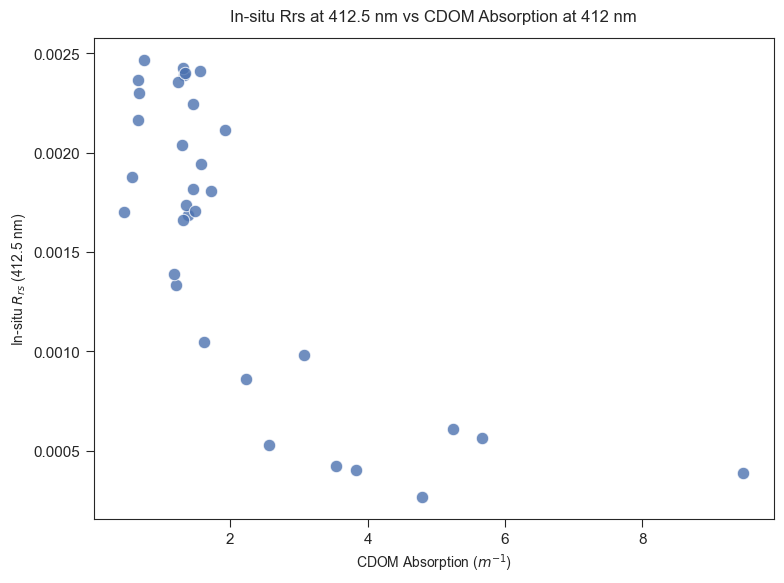

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=water_samples_Rrs,
    x='CDOM_a412_m-1',
    y='Rrs_srf_412.5',

    s=80,
    alpha=0.8
)

plt.title('In-situ Rrs at 412.5 nm vs CDOM Absorption at 412 nm', fontsize=12, pad=12)
plt.xlabel('CDOM Absorption ($m^{-1}$)', fontsize=10)
plt.ylabel('In-situ $R_{rs}$ (412.5 nm)', fontsize=10)

plt.tight_layout()

plt.show()

Exponential Fit Parameters: a=0.0029, b=-0.3207, c=-0.0001
Exponential R-squared ($R^2$): 0.6692


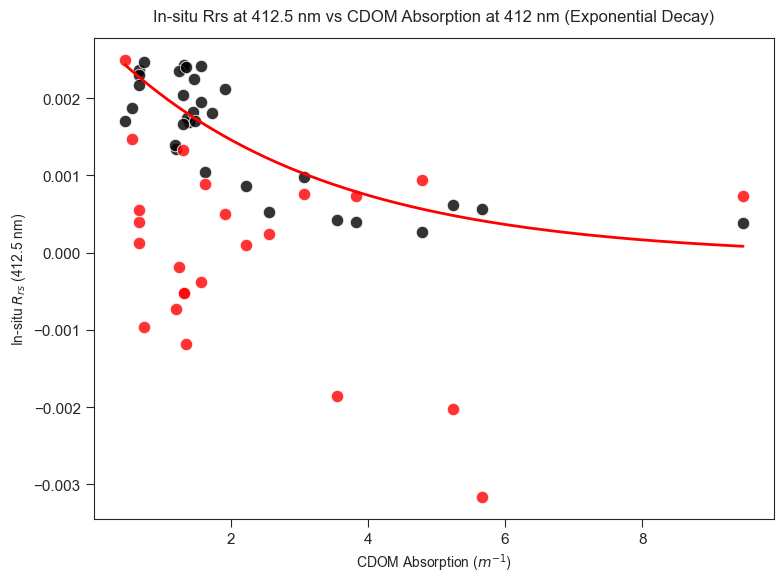

In [79]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import seaborn as sns

# Clean data
df_clean = water_samples_Rrs.dropna(subset=['CDOM_a412_m-1', 'Rrs_srf_412.5']).copy()
x = df_clean['CDOM_a412_m-1']
y = df_clean['Rrs_srf_412.5']

# Define an exponential decay function: y = a * exp(b * x) + c
def exp_decay(x, a, b, c):
    return a * np.exp(b * x) + c

# Fit the curve (popt contains the optimal parameters [a, b, c])
try:
    popt, _ = curve_fit(exp_decay, x, y, p0=[y.max(), -0.1, y.min()])

    # Calculate R-squared for the exponential fit
    y_pred = exp_decay(x, *popt)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r_squared = 1 - (ss_res / ss_tot)

    print(f"Exponential Fit Parameters: a={popt[0]:.4f}, b={popt[1]:.4f}, c={popt[2]:.4f}")
    print(f"Exponential R-squared ($R^2$): {r_squared:.4f}")
except Exception as e:
    print(f"Curve fitting failed: {e}")

# Plotting the scatter plot and the exponential regression curve
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_clean,
    x='CDOM_a412_m-1',
    y='Rrs_srf_412.5',
    color='black',
    s=80,
    alpha=0.8
)
sns.scatterplot(
    data=df_clean,
    x='CDOM_a412_m-1',
    y='sat_Rrs_412.5',
    color='red',
    s=80,
    alpha=0.8
)
# Generate a smooth, dense range of x values instead of using data points
x_smooth = np.linspace(x.min(), x.max(), 300)
y_fit = exp_decay(x_smooth, *popt)

plt.plot(x_smooth, y_fit, color='red', linewidth=2, label='Exponential Fit')

plt.title('In-situ Rrs at 412.5 nm vs CDOM Absorption at 412 nm (Exponential Decay)', fontsize=12, pad=12)
plt.xlabel('CDOM Absorption ($m^{-1}$)', fontsize=10)
plt.ylabel('In-situ $R_{rs}$ (412.5 nm)', fontsize=10)

plt.tight_layout()

plt.show()

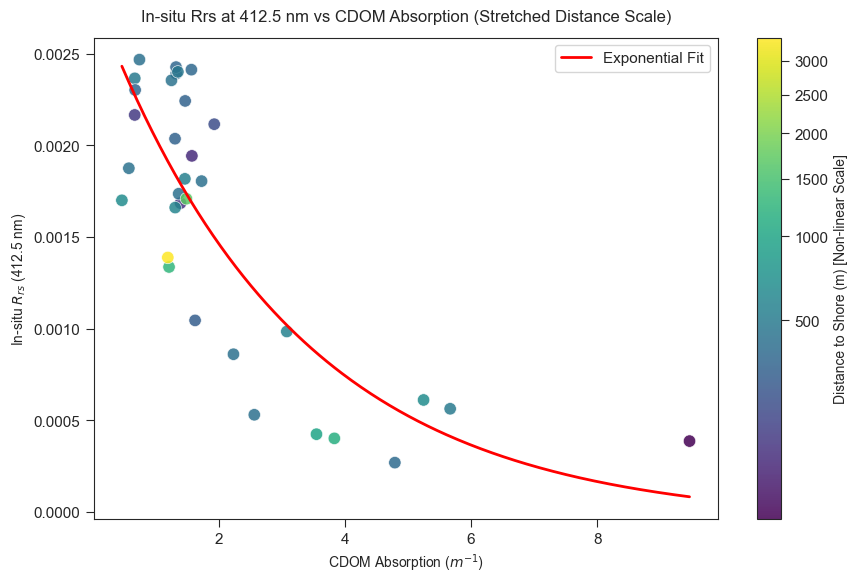

In [80]:
from matplotlib.colors import PowerNorm
# Clean data ensuring distance is included from df_clean
df_clean = water_samples_Rrs.dropna(
    subset=['CDOM_a412_m-1', 'Rrs_srf_412.5', 'dist_to_shore_m']
).copy()

x = df_clean['CDOM_a412_m-1']
y = df_clean['Rrs_srf_412.5']
distance = df_clean['dist_to_shore_m']
# Use PowerNorm with a gamma < 1 to stretch out the lower end
# (where most of your points are clustered), making the color spread more visible.
plt.figure(figsize=(9, 6))

sc = plt.scatter(
    x, y,
    c=distance,
    cmap='viridis',
    norm=PowerNorm(gamma=0.4),  # Adjust gamma (0.3 to 0.6) to taste
    s=80,
    alpha=0.85,
    edgecolors='white',
    linewidth=0.5
)

cbar = plt.colorbar(sc)
cbar.set_label('Distance to Shore (m) [Non-linear Scale]', fontsize=10)

# Smooth curve line
x_smooth = np.linspace(x.min(), x.max(), 300)
y_fit = exp_decay(x_smooth, *popt)
plt.plot(x_smooth, y_fit, color='red', linewidth=2, label='Exponential Fit')

plt.title('In-situ Rrs at 412.5 nm vs CDOM Absorption (Stretched Distance Scale)', fontsize=12, pad=12)
plt.xlabel('CDOM Absorption ($m^{-1}$)', fontsize=10)
plt.ylabel('In-situ $R_{rs}$ (412.5 nm)', fontsize=10)
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

In [81]:
## a, b, c exponential fit
import numpy as np
from scipy.optimize import curve_fit
from scipy import stats

df_clean = water_samples_Rrs.dropna(subset=['CDOM_a412_m-1', 'Rrs_srf_412.5']).copy()
x = df_clean['CDOM_a412_m-1']
y = df_clean['Rrs_srf_412.5']

def exp_decay(x, a, b, c):
    return a * np.exp(b * x) + c

# curve_fit returns optimal parameters (popt) and the covariance matrix (pcov)
popt, pcov = curve_fit(exp_decay, x, y, p0=[y.max(), -0.1, y.min()])

# Standard errors of the parameters (square root of the diagonal of pcov)
perr = np.sqrt(np.diag(pcov))

# Degrees of freedom (number of points minus number of parameters)
dof = len(y) - len(popt)

# Calculate t-statistics and p-values for each parameter
t_stats = popt / perr
p_values = [2 * (1 - stats.t.cdf(np.abs(t), dof)) for t in t_stats]

# R-squared calculation
y_pred = exp_decay(x, *popt)
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r_squared = 1 - (ss_res / ss_tot)

print("Exponential Fit Statistics:")
for name, val, err, pval in zip(['a', 'b', 'c'], popt, perr, p_values):
    print(f"  {name}: {val:.4f} (SE: {err:.4f}, p-value: {pval:.4e})")

print(f"R-squared ($R^2$): {r_squared:.4f}")


Exponential Fit Statistics:
  a: 0.0029 (SE: 0.0004, p-value: 1.6959e-07)
  b: -0.3207 (SE: 0.1466, p-value: 3.6582e-02)
  c: -0.0001 (SE: 0.0005, p-value: 9.1464e-01)
R-squared ($R^2$): 0.6692


In [82]:
## a b exponential fit
import numpy as np
from scipy.optimize import curve_fit
from scipy import stats

df_clean = water_samples_Rrs.dropna(subset=['CDOM_a412_m-1', 'Rrs_srf_412.5']).copy()
x = df_clean['CDOM_a412_m-1']
y = df_clean['Rrs_srf_412.5']

# 2-parameter exponential decay (no 'c' offset)
def exp_decay_2param(x, a, b):
    return a * np.exp(b * x)

# Fit the curve
popt, pcov = curve_fit(exp_decay_2param, x, y, p0=[y.max(), -0.1])
perr = np.sqrt(np.diag(pcov))
dof = len(y) - len(popt)
t_stats = popt / perr
p_values = [2 * (1 - stats.t.cdf(np.abs(t), dof)) for t in t_stats]

# R-squared
y_pred = exp_decay_2param(x, *popt)
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r_squared = 1 - (ss_res / ss_tot)

print(f"Parameter a: {popt[0]:.4f} (SE: {perr[0]:.4f}, p: {p_values[0]:.4e})")
print(f"Parameter b: {popt[1]:.4f} (SE: {perr[1]:.4f}, p: {p_values[1]:.4e})")
print(f"R-squared ($R^2$): {r_squared:.4f}")

Parameter a: 0.0028 (SE: 0.0003, p: 4.3907e-12)
Parameter b: -0.3342 (SE: 0.0642, p: 1.1988e-05)
R-squared ($R^2$): 0.6690


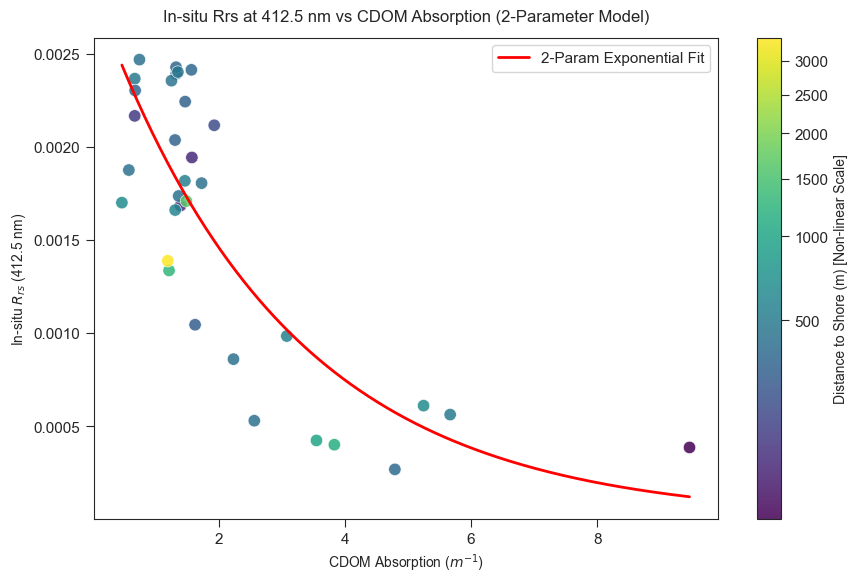

In [83]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm

# Clean data including distance
df_clean = water_samples_Rrs.dropna(
    subset=['CDOM_a412_m-1', 'Rrs_srf_412.5', 'dist_to_shore_m']
).copy()

x = df_clean['CDOM_a412_m-1']
y = df_clean['Rrs_srf_412.5']
distance = df_clean['dist_to_shore_m']

# 2-parameter exponential decay (no 'c' offset)
def exp_decay_2param(x, a, b):
    return a * np.exp(b * x)

# Fit the 2-parameter curve
popt, _ = curve_fit(exp_decay_2param, x, y, p0=[y.max(), -0.1])

# Plotting
plt.figure(figsize=(9, 6))

sc = plt.scatter(
    x, y,
    c=distance,
    cmap='viridis',
    norm=PowerNorm(gamma=0.4),
    s=80,
    alpha=0.85,
    edgecolors='white',
    linewidth=0.5
)

cbar = plt.colorbar(sc)
cbar.set_label('Distance to Shore (m) [Non-linear Scale]', fontsize=10)

# Smooth curve line for the 2-parameter model
x_smooth = np.linspace(x.min(), x.max(), 300)
y_fit = exp_decay_2param(x_smooth, *popt)
plt.plot(x_smooth, y_fit, color='red', linewidth=2, label='2-Param Exponential Fit')

plt.title('In-situ Rrs at 412.5 nm vs CDOM Absorption (2-Parameter Model)', fontsize=12, pad=12)
plt.xlabel('CDOM Absorption ($m^{-1}$)', fontsize=10)
plt.ylabel('In-situ $R_{rs}$ (412.5 nm)', fontsize=10)
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

In [84]:
water_samples_Rrs

,Site,CDOM_a412_m-1,CDOM_a434_m-1,CDOM_a443_m-1,CDOM_a490_m-1,Chl_a_[ug/L],Chl_b_[ug/L],Chl_c_[ug/L],Date,Latitude,...,sat_flag_LAND,sat_flag_OC4ME_FAIL,sat_flag_OCNN_FAIL,sat_flag_SATURATED,sat_flag_SNOW_ICE,sat_flag_SUSPECT,sat_flag_TIDAL,sat_flag_WATER,snapped_pixel_lat,snapped_pixel_lon
0,ISO-01,5.6681,3.7328,3.2217,1.6826,3.041240,-0.023840,0.732600,2026-04-28,53.263103,...,False,False,True,False,False,False,False,True,53.263694,-9.038737
1,ISO-02,5.2462,3.6482,3.1513,1.4342,3.248234,0.019364,0.684792,2026-04-28,53.260653,...,False,False,True,False,False,False,False,True,53.261125,-9.039462
2,ISO-03,3.5467,2.1829,1.7883,0.6034,2.660049,0.053825,0.475276,2026-04-28,53.250777,...,False,False,True,False,False,False,False,True,53.250170,-9.035626
3,ISO-04,3.8306,2.5170,2.1257,0.8536,3.216769,0.003157,0.589285,2026-04-28,53.244920,...,False,False,False,False,False,False,False,True,53.245713,-9.043785
4,ISO-05,1.3899,0.7341,0.4474,0.0350,14.443843,-0.190331,5.316073,2026-04-29,53.242783,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ISO-06,1.4635,0.7004,0.4885,0.0217,13.028986,-0.226679,4.731097,2026-04-29,53.242865,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,ISO-07,1.3605,0.7114,0.6069,0.0887,7.048044,-1.133704,0.551598,2026-04-29,53.242872,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,ISO-08A,9.4658,6.3757,5.4946,2.8589,3.327007,-0.048250,0.357905,2026-04-28,53.141730,...,False,False,False,False,False,False,True,True,53.142199,-8.935765
8,ISO-08B,4.7905,3.0862,2.7564,1.4988,4.086672,0.245169,0.498590,2026-04-28,53.158338,...,False,True,False,False,False,False,False,True,53.159654,-8.951298
9,ISO-09,2.5603,1.7749,1.4804,0.9081,4.624154,0.203794,0.639475,2026-04-28,53.167728,...,False,True,False,False,False,False,False,True,53.168040,-8.955759


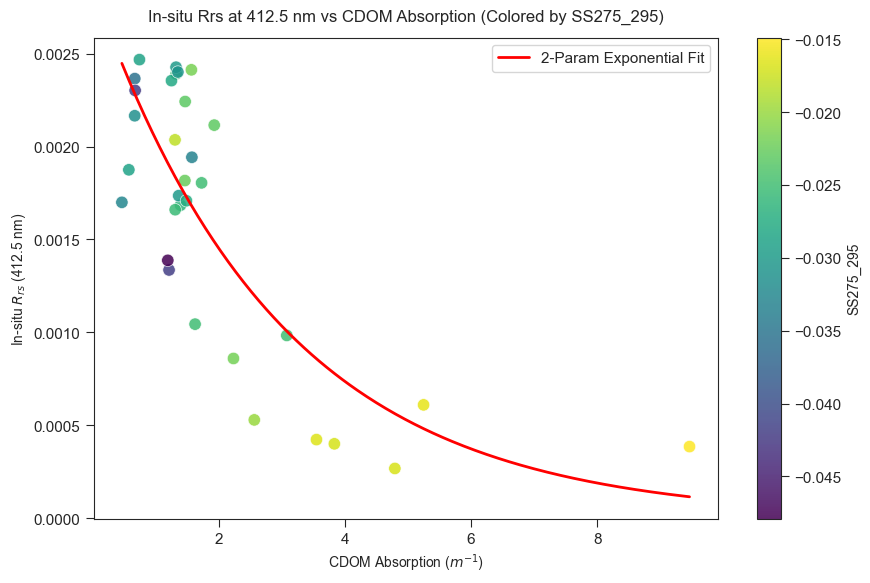

In [85]:
## 2 parameter decay - doesn't include the offset that was recommended


import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Clean data including SS275_295
df_clean = water_samples_Rrs.dropna(
    subset=['CDOM_a412_m-1', 'Rrs_srf_412.5', 'SS275_295']
).copy()

x = df_clean['CDOM_a412_m-1']
y = df_clean['Rrs_srf_412.5']
ss_color = df_clean['SS275_295']

# 2-parameter exponential decay model
def exp_decay_2param(x, a, b):
    return a * np.exp(b * x)

# Fit the 2-parameter exponential curve
popt, _ = curve_fit(exp_decay_2param, x, y, p0=[y.max(), -0.1])

# Plotting
plt.figure(figsize=(9, 6))

sc = plt.scatter(
    x, y,
    c=ss_color,
    cmap='viridis',
    s=80,
    alpha=0.85,
    edgecolors='white',
    linewidth=0.5
)

cbar = plt.colorbar(sc)
cbar.set_label('SS275_295', fontsize=10)

# Smooth curve line for the 2-parameter exponential model
x_smooth = np.linspace(x.min(), x.max(), 300)
y_fit = exp_decay_2param(x_smooth, *popt)
plt.plot(x_smooth, y_fit, color='red', linewidth=2, label='2-Param Exponential Fit')

plt.title('In-situ Rrs at 412.5 nm vs CDOM Absorption (Colored by SS275_295)', fontsize=12, pad=12)
plt.xlabel('CDOM Absorption ($m^{-1}$)', fontsize=10)
plt.ylabel('In-situ $R_{rs}$ (412.5 nm)', fontsize=10)
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

3-Parameter Offset Model Fit Statistics:
  a: 0.0029 (SE: 0.0004, p-value: 1.6959e-07)
  b: -0.3207 (SE: 0.1466, p-value: 3.6582e-02)
  c: -0.0001 (SE: 0.0005, p-value: 9.1464e-01)
R-squared ($R^2$): 0.6692


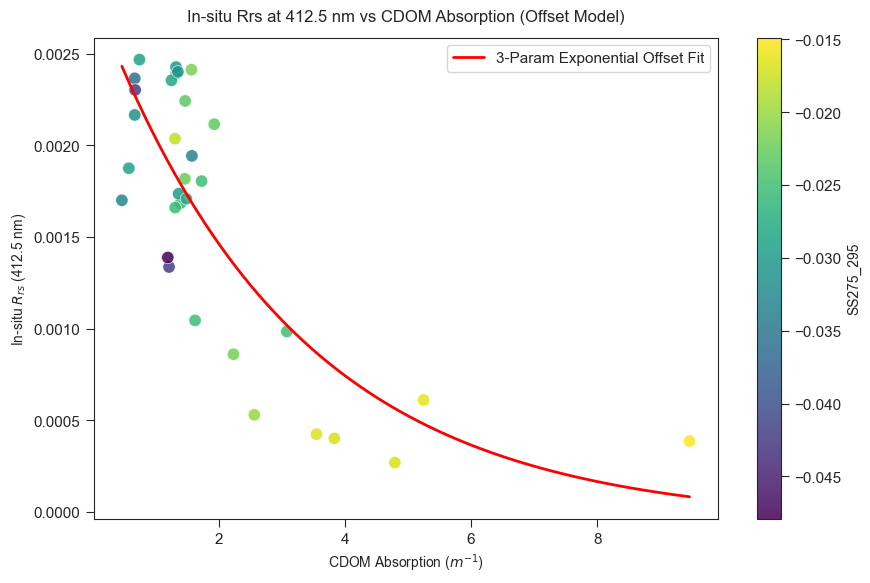

In [86]:
## This one aligns with what was recommended by Anara : Rrs(412.5) = y(0) + Ae^(-k*acdom(412))
import numpy as np
from scipy.optimize import curve_fit
from scipy import stats
import matplotlib.pyplot as plt

# Clean data including SS275_295
df_clean = water_samples_Rrs.dropna(
    subset=['CDOM_a412_m-1', 'Rrs_srf_412.5'] #, 'SS275_295']
).copy()

x = df_clean['CDOM_a412_m-1']
y = df_clean['Rrs_srf_412.5']
ss_color = df_clean['SS275_295']

# 3-parameter exponential offset model: y = a * exp(b * x) + c
def exp_offset_model(x, a, b, c):
    return a * np.exp(b * x) + c

# Fit the curve
popt, pcov = curve_fit(exp_offset_model, x, y, p0=[y.max(), -0.1, y.min()])
perr = np.sqrt(np.diag(pcov))
dof = len(y) - len(popt)
t_stats = popt / perr
p_values = [2 * (1 - stats.t.cdf(np.abs(t), dof)) for t in t_stats]

# R-squared calculation
y_pred = exp_offset_model(x, *popt)
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r_squared = 1 - (ss_res / ss_tot)

print("3-Parameter Offset Model Fit Statistics:")
for name, val, err, pval in zip(['a', 'b', 'c'], popt, perr, p_values):
    print(f"  {name}: {val:.4f} (SE: {err:.4f}, p-value: {pval:.4e})")
print(f"R-squared ($R^2$): {r_squared:.4f}")

# Plotting with linear color scale for SS275_295
plt.figure(figsize=(9, 6))

sc = plt.scatter(
    x, y,
    c=ss_color,
    cmap='viridis',
    s=80,
    alpha=0.85,
    edgecolors='white',
    linewidth=0.5
)

cbar = plt.colorbar(sc)
cbar.set_label('SS275_295', fontsize=10)

# Smooth curve line for the 3-parameter offset model
x_smooth = np.linspace(x.min(), x.max(), 300)
y_fit = exp_offset_model(x_smooth, *popt)
plt.plot(x_smooth, y_fit, color='red', linewidth=2, label='3-Param Exponential Offset Fit')

plt.title('In-situ Rrs at 412.5 nm vs CDOM Absorption (Offset Model)', fontsize=12, pad=12)
plt.xlabel('CDOM Absorption ($m^{-1}$)', fontsize=10)
plt.ylabel('In-situ $R_{rs}$ (412.5 nm)', fontsize=10)
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

### Ratio (412/555) vs acdom(412)

In [87]:
## FIRST: In-Situ (Non-convolved, but interpolated to get 555)

Log-Log Fit Parameters: a=0.8085, b=-0.9149
Log-Log R-squared ($R^2$): 0.6727


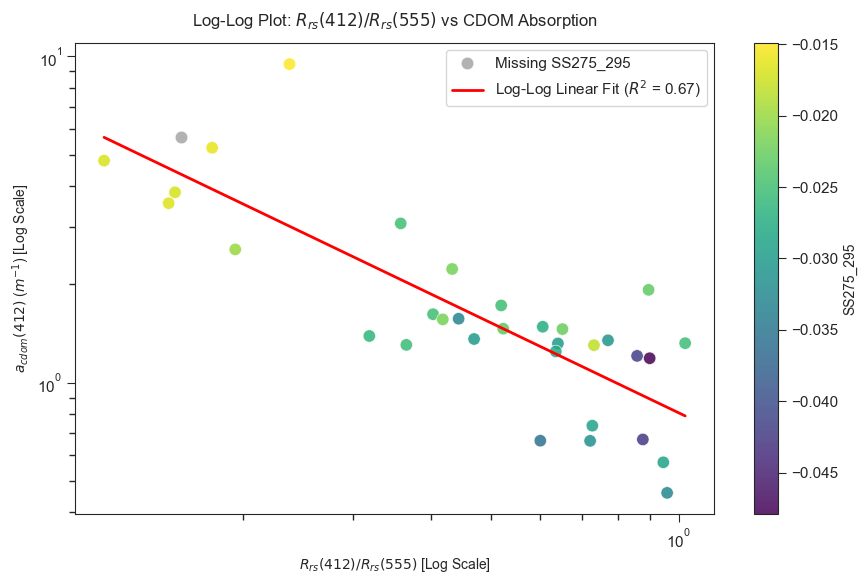

In [88]:
## FIRST: In-Situ (Non-convolved, but interpolated to get 555)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Interpolate 555 nm in site_means using the midpoint between 554 and 556
site_means['555'] = (site_means['554'] + site_means['556']) / 2

# 2. Compute the 412 / 555 ratio within site_means
site_means['Rrs_ratio_412_555'] = site_means['412'] / site_means['555']

# 3. Merge site_means with your CDOM dataframe using the 'Site' column
merged_df = pd.merge(
    water_samples_Rrs,
    site_means[['Site', 'Rrs_ratio_412_555']],
    on='Site',
    how='inner'
)

# Clean data for regression
df_clean = merged_df.dropna(
    subset=['CDOM_a412_m-1', 'Rrs_ratio_412_555']
).copy()

y = df_clean['CDOM_a412_m-1']
## want x to be the ratio, so that cdom is what you are predicting...?
x = df_clean['Rrs_ratio_412_555']
ss_color = df_clean['SS275_295']
valid_mask = ss_color.notna()
# 4. Fit linear regression in log-log space
log_x = np.log(x)
log_y = np.log(y)
# Fit ln(CDOM) = intercept + b * ln(ratio)
b_insitu, intercept_insitu = np.polyfit(log_x, log_y, 1)

# Convert intercept back to the power-law coefficient
a_insitu = np.exp(intercept_insitu)

# Predicted CDOM in log space
log_y_pred = intercept_insitu + b_insitu * log_x
ss_res = np.sum((log_y - log_y_pred) ** 2)
ss_tot = np.sum((log_y - log_y.mean()) ** 2)
r_squared = 1 - (ss_res / ss_tot)

print(f"Log-Log Fit Parameters: a={a_insitu:.4f}, b={b_insitu:.4f}")
print(f"Log-Log R-squared ($R^2$): {r_squared:.4f}")

# 5. Plotting on log-log scales
plt.figure(figsize=(9, 6))
# Plot points with missing SS275_295 in grey first
if (~valid_mask).any():
    plt.scatter(
        x[~valid_mask], y[~valid_mask],
        c='grey',
        s=80,
        alpha=0.6,
        edgecolors='white',
        linewidth=0.5,
        label='Missing SS275_295'
    )
sc = plt.scatter(
    x, y,
    c=ss_color,
    cmap='viridis',
    s=80,
    alpha=0.85,
    edgecolors='white',
    linewidth=0.5
)

cbar = plt.colorbar(sc)
cbar.set_label('SS275_295', fontsize=10)

# Smooth straight line in log space
x_smooth = np.logspace(np.log10(x.min()), np.log10(x.max()), 300)
y_fit = a_insitu * (x_smooth ** b_insitu)
plt.plot(x_smooth, y_fit, color='red', linewidth=2, label=f'Log-Log Linear Fit ($R^2$ = {r_squared:.2f})')

# Apply logarithmic scales to both axes
plt.xscale('log')
plt.yscale('log')

plt.title('Log-Log Plot: $R_{rs}(412)/R_{rs}(555)$ vs CDOM Absorption', fontsize=12, pad=12)
plt.ylabel('$a_{cdom}(412)$ ($m^{-1}$) [Log Scale]', fontsize=10)
plt.xlabel('$R_{rs}(412) / R_{rs}(555)$ [Log Scale]', fontsize=10)
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

Log-Log Fit Parameters: a=0.8108, b=-0.8842
Log-Log R-squared ($R^2$): 0.6750


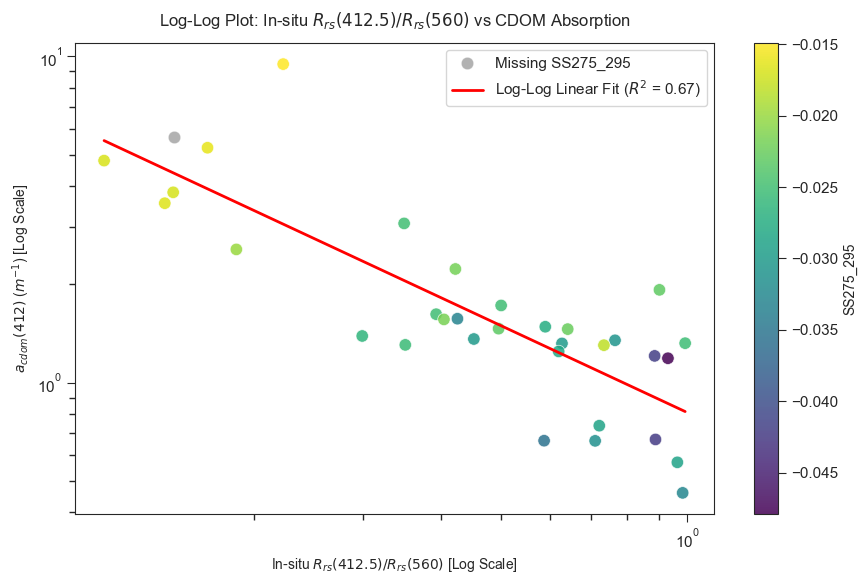

In [89]:
## SECOND: Convolved In-Situ

# Compute the ratio directly from water_samples_Rrs using in-situ convoluted bands
water_samples_Rrs['Rrs_conv_ratio_412_560'] = water_samples_Rrs['Rrs_srf_412.5'] / water_samples_Rrs['Rrs_srf_560.0']

# Clean data for regression
df_clean = water_samples_Rrs.dropna(
    subset=['CDOM_a412_m-1', 'Rrs_srf_412.5', 'Rrs_srf_560.0']
).copy()

y = df_clean['CDOM_a412_m-1']
x = df_clean['Rrs_conv_ratio_412_560']
ss_color = df_clean['SS275_295']
# Create a boolean mask for valid vs missing SS275_295 values
valid_mask = ss_color.notna()
# Fit linear regression in log-log space (predicting CDOM from the band ratio)
log_x = np.log(x)
log_y = np.log(y)
b_conv, intercept_conv = np.polyfit(log_x, log_y, 1)

# Convert intercept back to the power-law coefficient
a_conv = np.exp(intercept_conv)

# Calculate R-squared in log space
log_y_pred = intercept_conv + b_conv * log_x
ss_res = np.sum((log_y - log_y_pred) ** 2)
ss_tot = np.sum((log_y - log_y.mean()) ** 2)
r_squared = 1 - (ss_res / ss_tot)

print(f"Log-Log Fit Parameters: a={a_conv:.4f}, b={b_conv:.4f}")
print(f"Log-Log R-squared ($R^2$): {r_squared:.4f}")

# Plotting on log-log scales
plt.figure(figsize=(9, 6))
# Plot points with missing SS275_295 in grey first
if (~valid_mask).any():
    plt.scatter(
        x[~valid_mask], y[~valid_mask],
        c='grey',
        s=80,
        alpha=0.6,
        edgecolors='white',
        linewidth=0.5,
        label='Missing SS275_295'
    )
sc = plt.scatter(
    x, y,
    c=ss_color,
    cmap='viridis',
    s=80,
    alpha=0.85,
    edgecolors='white',
    linewidth=0.5
)

cbar = plt.colorbar(sc)
cbar.set_label('SS275_295', fontsize=10)

# Smooth straight line in log space
x_smooth = np.logspace(np.log10(x.min()), np.log10(x.max()), 300)
y_fit = a_conv * (x_smooth ** b_conv)
plt.plot(x_smooth, y_fit, color='red', linewidth=2, label=f'Log-Log Linear Fit ($R^2$ = {r_squared:.2f})')

# Apply logarithmic scales to both axes
plt.xscale('log')
plt.yscale('log')

plt.title('Log-Log Plot: In-situ $R_{rs}(412.5)/R_{rs}(560)$ vs CDOM Absorption', fontsize=12, pad=12)
plt.ylabel('$a_{cdom}(412)$ ($m^{-1}$) [Log Scale]', fontsize=10)
plt.xlabel('In-situ $R_{rs}(412.5) / R_{rs}(560)$ [Log Scale]', fontsize=10)
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

Log-Log Fit Parameters: a=1.3871, b=-0.2503
Log-Log R-squared ($R^2$): 0.0748


C:\Users\25298423\AppData\Local\Temp\ipykernel_14932\1016280346.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sat_valid_412_560['Rrs_sat_ratio_412_560'] = sat_valid_412_560['sat_Rrs_412.5'] / sat_valid_412_560['sat_Rrs_560.0']


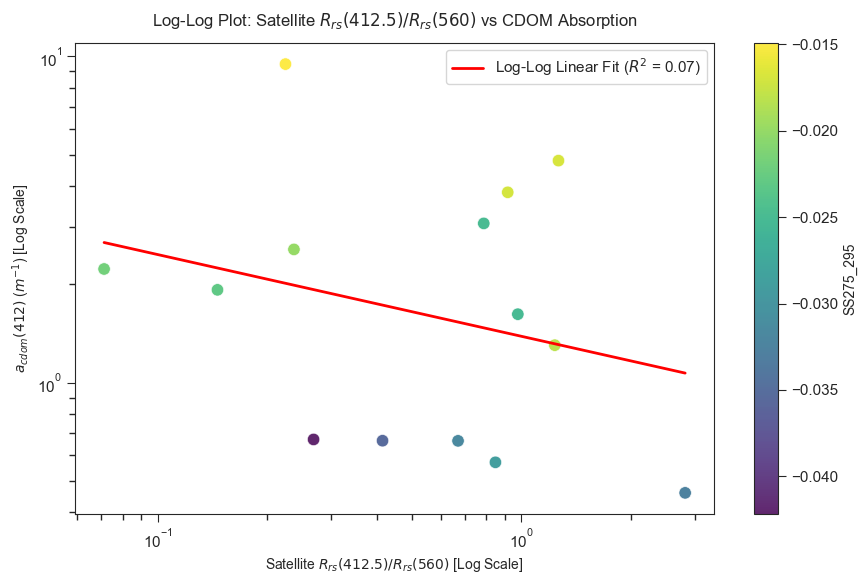

In [90]:
## Third: Satellite Values, only with positive reflectances for ratio

# Compute the ratio directly from water_samples_Rrs
sat_valid_412_560 = water_samples_Rrs[(water_samples_Rrs['sat_Rrs_412.5']>0) & (water_samples_Rrs['sat_Rrs_560.0']>0)]
sat_valid_412_560['Rrs_sat_ratio_412_560'] = sat_valid_412_560['sat_Rrs_412.5'] / sat_valid_412_560['sat_Rrs_560.0']

# Clean data for regression
df_clean = sat_valid_412_560.dropna(
    subset=['CDOM_a412_m-1', 'sat_Rrs_412.5', 'sat_Rrs_560.0']
).copy()

y = df_clean['CDOM_a412_m-1']
x = df_clean['Rrs_sat_ratio_412_560']
ss_color = df_clean['SS275_295']
# Create a boolean mask for valid vs missing SS275_295 values
valid_mask = ss_color.notna()
# Fit linear regression in log-log space (predicting CDOM from the band ratio)
log_x = np.log(x)
log_y = np.log(y)
b_sat, intercept_sat = np.polyfit(log_x, log_y, 1)

# Convert intercept back to the power-law coefficient
a_sat = np.exp(intercept_sat)

# Calculate R-squared in log space
log_y_pred = intercept_sat + b_sat * log_x
ss_res = np.sum((log_y - log_y_pred) ** 2)
ss_tot = np.sum((log_y - log_y.mean()) ** 2)
r_squared = 1 - (ss_res / ss_tot)

print(f"Log-Log Fit Parameters: a={a_sat:.4f}, b={b_sat:.4f}")
print(f"Log-Log R-squared ($R^2$): {r_squared:.4f}")

# Plotting on log-log scales
plt.figure(figsize=(9, 6))
# Plot points with missing SS275_295 in grey first
if (~valid_mask).any():
    plt.scatter(
        x[~valid_mask], y[~valid_mask],
        c='grey',
        s=80,
        alpha=0.6,
        edgecolors='white',
        linewidth=0.5,
        label='Missing SS275_295'
    )
sc = plt.scatter(
    x, y,
    c=ss_color,
    cmap='viridis',
    s=80,
    alpha=0.85,
    edgecolors='white',
    linewidth=0.5
)

cbar = plt.colorbar(sc)
cbar.set_label('SS275_295', fontsize=10)

# Smooth straight line in log space
x_smooth = np.logspace(np.log10(x.min()), np.log10(x.max()), 300)
y_fit = a_sat * (x_smooth ** b_sat)
plt.plot(x_smooth, y_fit, color='red', linewidth=2, label=f'Log-Log Linear Fit ($R^2$ = {r_squared:.2f})')

# Apply logarithmic scales to both axes
plt.xscale('log')
plt.yscale('log')

plt.title('Log-Log Plot: Satellite $R_{rs}(412.5)/R_{rs}(560)$ vs CDOM Absorption', fontsize=12, pad=12)
plt.ylabel('$a_{cdom}(412)$ ($m^{-1}$) [Log Scale]', fontsize=10)
plt.xlabel('Satellite $R_{rs}(412.5) / R_{rs}(560)$ [Log Scale]', fontsize=10)
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

**Need to do a couple of things:**
1. make a regression plot using positive Rrs values for the satellite data, to show how boofy it is
2. need to do the thingy below where I use the in-situ convolved a and b values to make a satellite predicted CDOM, and see how that compares to the actual samples.
3. Do a comparsion of how our insitu measurements performed compared to satellite, with metrics, compared to the actual cdom values
4. Need to decide when enough is enough with the OLCI data, and move onto the Copernicus big girl data for just directly comparing Chl-a and CDOM satellite measurements, instead of this ratio BS - should just finish up what I already started tomorrow, and then move onto the big girl data**

In [91]:
## Now, need to do 1. An insitu calibrated model to apply to satellite data, using a_conv and b_conv and see how that works out. Can only use positive values for satellite data
sat_valid_412_560 = water_samples_Rrs[(water_samples_Rrs['sat_Rrs_412.5']>0) & (water_samples_Rrs['sat_Rrs_560.0']>0)]
sat_valid_412_560['sat_ratio_412_560'] = sat_valid_412_560['sat_Rrs_412.5']/sat_valid_412_560['sat_Rrs_560.0']
sat_valid_412_560

C:\Users\25298423\AppData\Local\Temp\ipykernel_14932\648260979.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sat_valid_412_560['sat_ratio_412_560'] = sat_valid_412_560['sat_Rrs_412.5']/sat_valid_412_560['sat_Rrs_560.0']


,Site,CDOM_a412_m-1,CDOM_a434_m-1,CDOM_a443_m-1,CDOM_a490_m-1,Chl_a_[ug/L],Chl_b_[ug/L],Chl_c_[ug/L],Date,Latitude,...,sat_flag_OCNN_FAIL,sat_flag_SATURATED,sat_flag_SNOW_ICE,sat_flag_SUSPECT,sat_flag_TIDAL,sat_flag_WATER,snapped_pixel_lat,snapped_pixel_lon,Rrs_conv_ratio_412_560,sat_ratio_412_560
3,ISO-04,3.8306,2.5170,2.1257,0.8536,3.216769,0.003157,0.589285,2026-04-28,53.244920,...,False,False,False,False,False,True,53.245713,-9.043785,0.147839,0.917731
7,ISO-08A,9.4658,6.3757,5.4946,2.8589,3.327007,-0.048250,0.357905,2026-04-28,53.141730,...,False,False,False,False,True,True,53.142199,-8.935765,0.222611,0.224562
8,ISO-08B,4.7905,3.0862,2.7564,1.4988,4.086672,0.245169,0.498590,2026-04-28,53.158338,...,False,False,False,False,False,True,53.159654,-8.951298,0.114316,1.265747
9,ISO-09,2.5603,1.7749,1.4804,0.9081,4.624154,0.203794,0.639475,2026-04-28,53.167728,...,False,False,False,False,False,True,53.168040,-8.955759,0.187007,0.236919
10,ISO-10,1.6208,1.0907,0.8076,0.2422,5.246053,0.249978,0.596292,2026-04-28,53.175897,...,False,False,False,False,False,True,53.176426,-8.960218,0.393333,0.978399
11,ISO-11,2.2299,1.6962,1.4782,0.8149,5.670156,0.172541,0.946466,2026-04-28,53.180213,...,False,False,False,False,False,True,53.180354,-8.972780,0.422532,0.071175
12,ISO-12,3.0759,1.9765,1.7371,1.0501,6.121353,0.216508,1.055452,2026-04-28,53.179393,...,False,False,False,False,False,True,53.178465,-8.980150,0.349139,0.788476
16,ISO-16,0.6638,0.2890,0.1900,-0.0077,1.561965,0.021027,0.141319,2026-05-10,53.276242,...,False,False,False,False,False,True,53.275997,-9.566388,0.587757,0.415253
17,ISO-17,0.6697,0.4675,0.3169,0.1041,0.726994,0.010177,-0.084427,2026-05-10,53.255887,...,False,False,False,False,False,True,53.255456,-9.570482,0.889623,0.268293
18,ISO-18,0.4594,0.0663,-0.0602,-0.3295,0.650673,0.046494,0.015557,2026-05-10,53.242418,...,False,False,False,False,False,True,53.242616,-9.573041,0.984256,2.823728


In [92]:
sat_valid_412_560['CDOM_pred_from_conv'] = a_conv * (sat_valid_412_560['sat_ratio_412_560']) ** b_conv

log_observed = np.log(sat_valid_412_560['CDOM_a412_m-1'])
log_predicted = np.log(sat_valid_412_560['CDOM_pred_from_conv'])
print(sat_valid_412_560[['Site','CDOM_a412_m-1','CDOM_pred_from_conv']])

       Site  CDOM_a412_m-1  CDOM_pred_from_conv
3    ISO-04         3.8306             0.874716
7   ISO-08A         9.4658             3.036957
8   ISO-08B         4.7905             0.658275
9    ISO-09         2.5603             2.896471
10   ISO-10         1.6208             0.826583
11   ISO-11         2.2299             8.387927
12   ISO-12         3.0759             1.000365
16   ISO-16         0.6638             1.763528
17   ISO-17         0.6697             2.594867
18   ISO-18         0.4594             0.323810
21   ISO-21         0.6631             1.155351
28   ISO-28         1.3025             0.672064
29   ISO-29         1.9247             4.444689
30   ISO-30         0.5699             0.937050


C:\Users\25298423\AppData\Local\Temp\ipykernel_14932\1345708192.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sat_valid_412_560['CDOM_pred_from_conv'] = a_conv * (sat_valid_412_560['sat_ratio_412_560']) ** b_conv


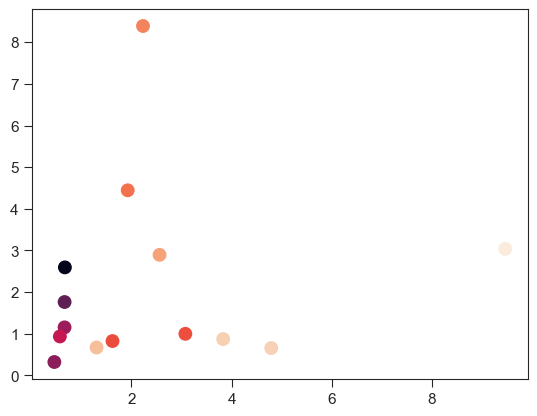

In [93]:
plt.scatter(x=sat_valid_412_560['CDOM_a412_m-1'],y=sat_valid_412_560['CDOM_pred_from_conv'], c=sat_valid_412_560['SS275_295'], s=80)

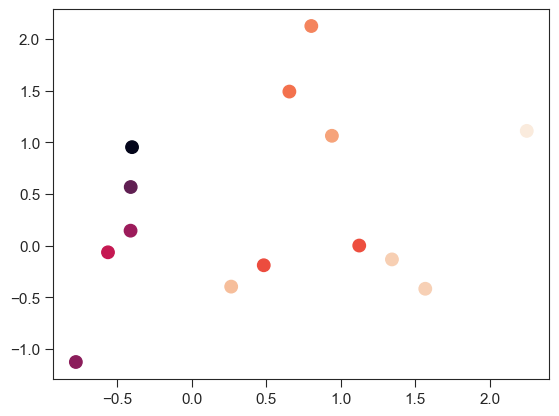

In [94]:
plt.scatter(x=log_observed,y=log_predicted, c=sat_valid_412_560['SS275_295'], s=80)

In [95]:
### NEED TO PLOT RESIDUALS OF PLOTS

In [96]:
water_samples_Rrs.loc[:,water_samples_Rrs.columns.str.contains('sat')|water_samples_Rrs.columns.str.contains('Site')]


,Site,sat_Rrs_1020.5,sat_Rrs_400.0,sat_Rrs_412.5,sat_Rrs_442.5,sat_Rrs_490.0,sat_Rrs_510.0,sat_Rrs_560.0,sat_Rrs_620.0,sat_Rrs_665.0,...,sat_flag_INLAND_WATER,sat_flag_INVALID,sat_flag_LAND,sat_flag_OC4ME_FAIL,sat_flag_OCNN_FAIL,sat_flag_SATURATED,sat_flag_SNOW_ICE,sat_flag_SUSPECT,sat_flag_TIDAL,sat_flag_WATER
0,ISO-01,0.001431,-0.003271,-0.003161,-0.002575,-0.001723,-0.001201,0.000189,-0.000296,-0.000549,...,False,False,False,False,True,False,False,False,False,True
1,ISO-02,0.001396,-0.002018,-0.002025,-0.001498,-0.000853,-0.000523,0.000544,0.000001,-0.000165,...,False,False,False,False,True,False,False,False,False,True
2,ISO-03,0.000408,-0.001935,-0.001852,-0.001474,-0.001019,-0.000652,0.000098,-0.000287,-0.000388,...,False,False,False,False,True,False,False,False,False,True
3,ISO-04,0.000174,0.000891,0.000731,0.000554,0.000509,0.000585,0.000797,0.000238,0.000001,...,False,False,False,False,False,False,False,False,False,True
4,ISO-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ISO-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,ISO-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,ISO-08A,0.012023,0.000629,0.000738,0.001153,0.001547,0.001892,0.003287,0.003064,0.002705,...,False,False,False,False,False,False,False,False,True,True
8,ISO-08B,0.001204,0.001003,0.000937,0.000334,0.000196,0.000375,0.000740,0.000340,0.000058,...,False,False,False,True,False,False,False,False,False,True
9,ISO-09,0.001577,0.000203,0.000238,0.000244,0.000281,0.000570,0.001003,0.000541,0.000327,...,False,False,False,True,False,False,False,False,False,True


### Ratio 412/555(or 560) compared to acdom(443)

In [97]:
water_samples_Rrs.columns

Index(['Site', 'CDOM_a412_m-1', 'CDOM_a434_m-1', 'CDOM_a443_m-1',
       'CDOM_a490_m-1', 'Chl_a_[ug/L]', 'Chl_b_[ug/L]', 'Chl_c_[ug/L]', 'Date',
       'Latitude', 'Longitude', 'Notes', 'Part_ap412_m-1', 'Part_ap434_m-1',
       'Part_ap443_m-1', 'Part_ap490_m-1', 'Part_ap678m-1', 'Rrs_srf_1020.0',
       'Rrs_srf_400.0', 'Rrs_srf_412.5', 'Rrs_srf_442.5', 'Rrs_srf_490.0',
       'Rrs_srf_510.0', 'Rrs_srf_560.0', 'Rrs_srf_620.0', 'Rrs_srf_665.0',
       'Rrs_srf_673.8', 'Rrs_srf_681.2', 'Rrs_srf_708.8', 'Rrs_srf_753.8',
       'Rrs_srf_761.2', 'Rrs_srf_764.4', 'Rrs_srf_767.5', 'Rrs_srf_778.8',
       'Rrs_srf_865.0', 'Rrs_srf_885.0', 'Rrs_srf_900.0', 'Rrs_srf_940.0',
       'SS275_295', 'SS_err', 'Time_Delta', 'Time_Delta_mins', 'Timestamp_End',
       'Timestamp_Start', 'dist_to_shore_m', 'exact_distance_m',
       'insitu_midpoint', 'outside_original_pixel', 'sat_Rrs_1020.5',
       'sat_Rrs_400.0', 'sat_Rrs_412.5', 'sat_Rrs_442.5', 'sat_Rrs_490.0',
       'sat_Rrs_510.0', 'sat_Rrs_5

In [377]:
## Base-10 log version of the LOSO CDOM model - KEEP FOR PAPER
## The original functions remain unchanged

from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm


def leave_one_site_out_loso_base10(df, site_col, y_col, in_situ_bands, sat_bands):
    """
    Leave-one-site-out cross-validation using base-10 logarithms.

    The model is fitted using in-situ Rrs bands and predicts the
    in-situ CDOM target for the left-out site.
    """

    # 1. Identify CDOM wavelength columns
    target_cdom_wavelengths = ["412", "434", "443", "490"]

    cdom_check_cols = [
        col for col in df.columns
        if ("CDOM" in col and any(wl in col for wl in target_cdom_wavelengths))
    ]

    if not cdom_check_cols:
        cdom_check_cols = [col for col in df.columns if "CDOM" in col]

    # 2. Required columns must be positive and non-null
    mandatory_cols = list(set(in_situ_bands + cdom_check_cols + [y_col]))

    # 3. Filter the complete dataframe before LOSO
    clean_df = df.dropna(subset=mandatory_cols).copy()
    valid_mask = (clean_df[mandatory_cols] > 0).all(axis=1)
    clean_df = clean_df[valid_mask]

    # 4. Identify valid sites
    sites = clean_df[site_col].unique()

    coefficients = []
    observed_all = []
    predicted_all = []
    site_labels = []

    # 5. Leave-one-site-out loop
    for site in sites:
        train_df = clean_df[clean_df[site_col] != site]

        if train_df.empty:
            continue

        X_train = train_df[in_situ_bands]
        y_train = train_df[y_col]

        # Base-10 log transformation
        X_train_log = np.log10(X_train)
        X_train_log = sm.add_constant(X_train_log)
        y_train_log = np.log10(y_train)

        # Fit OLS model
        model = sm.OLS(y_train_log, X_train_log).fit()
        params = model.params

        coefficients.append({
            "site_left_out": site,
            **params.to_dict()
        })

        # Left-out site
        test_subset = clean_df[clean_df[site_col] == site].copy()

        if not test_subset.empty:
            X_test = sm.add_constant(
                np.log10(test_subset[in_situ_bands]),
                has_constant="add"
            )

            # Match training design matrix
            X_test = X_test.reindex(
                columns=X_train_log.columns,
                fill_value=0
            )

            pred_log = model.predict(X_test)

            # Back-transform from log10 space
            pred_val = 10 ** pred_log

            observed_all.extend(test_subset[y_col].values)
            predicted_all.extend(pred_val.values)
            site_labels.extend([site] * len(test_subset))

    # Keep the original column name so the rest of your existing workflow can still recognise it.
    results_base10 = pd.DataFrame({
        "site": site_labels,
        "observed": observed_all,
        "predicted_sat": predicted_all
    })

    coeffs_base10 = pd.DataFrame(coefficients)

    return results_base10, coeffs_base10


def calculate_validation_metrics_base10(y_true, y_pred):
    """
    Calculate validation metrics using base-10 log-transformed values.
    """

    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    valid = (
        np.isfinite(y_true)
        & np.isfinite(y_pred)
        & (y_true > 0)
        & (y_pred > 0)
    )

    y_true = y_true[valid]
    y_pred = y_pred[valid]

    # Base-10 logarithms
    log_true = np.log10(y_true)
    log_pred = np.log10(y_pred)

    # Original-scale R2
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2_original = 1 - ss_res / ss_tot

    # Base-10 log-scale R2
    ss_res_log = np.sum((log_true - log_pred) ** 2)
    ss_tot_log = np.sum((log_true - np.mean(log_true)) ** 2)
    r2_log = 1 - ss_res_log / ss_tot_log

    # Spearman correlation
    spearman_corr, spearman_p = stats.spearmanr(y_true, y_pred)

    # Regression in base-10 log space
    slope_log, intercept_log, r_log, p_log, se_log = stats.linregress(log_true, log_pred)

    # Regression on original scale
    slope_original, intercept_original, r_original, p_original, se_original = stats.linregress(y_true, y_pred)

    # Error statistics
    rmsd = np.sqrt(np.mean((y_pred - y_true) ** 2))
    log_rmse = np.sqrt(np.mean((log_pred - log_true) ** 2))

    pd_values = 100 * (y_pred - y_true) / y_true
    mdpd = np.median(pd_values)
    mdapd = np.median(np.abs(pd_values))

    log_difference = log_pred - log_true
    median_log_bias = np.median(log_difference)
    mean_log_bias = np.mean(log_difference)

    return {
        "N": len(y_true),
        "R2_original": r2_original,
        "R2_log10": r2_log,
        "Spearman_Rho": spearman_corr,
        "Spearman_p": spearman_p,
        "Slope_log10": slope_log,
        "Intercept_log10": intercept_log,
        "Slope_original": slope_original,
        "Intercept_original": intercept_original,
        "RMSD": rmsd,
        "Log10_RMSE": log_rmse,
        "MdPD_percent": mdpd,
        "MdAPD_percent": mdapd,
        "Median_Log10_Bias": median_log_bias,
        "Mean_Log10_Bias": mean_log_bias
    }


def plot_validation_figures_base10(results_df, obs_col="observed", pred_col="predicted_sat"):
    """
    Plot LOSO validation results using base-10 log-transformed values.
    """

    y_true = results_df[obs_col].to_numpy(dtype=float)
    y_pred = results_df[pred_col].to_numpy(dtype=float)

    valid = (
        np.isfinite(y_true)
        & np.isfinite(y_pred)
        & (y_true > 0)
        & (y_pred > 0)
    )

    y_true = y_true[valid]
    y_pred = y_pred[valid]

    # Base-10 logarithms for plotting
    log_true = np.log10(y_true)
    log_pred = np.log10(y_pred)

    residuals = y_pred - y_true

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # ---------------------------------------------------------
    # 1. Log-log scatterplot
    # ---------------------------------------------------------
    ax = axes[0, 0]

    ax.scatter(log_true, log_pred, alpha=0.7, edgecolor="k", linewidth=0.5)

    min_val = min(log_true.min(), log_pred.min())
    max_val = max(log_true.max(), log_pred.max())

    ax.plot([min_val, max_val], [min_val, max_val], "k--", linewidth=1.5, label="1:1 line")
    ax.set_xlabel("Log10(Observed in-situ " r"$a_{\mathrm{CDOM}}(443)$)")
    ax.set_ylabel("Log10(LOSO cross-validated " r"predicted $a_{\mathrm{CDOM}}(443)$)")
    ax.set_title("Log-Log Cross-Validation")
    ax.legend(loc="best")

    # ---------------------------------------------------------
    # 2. Original-scale observed versus predicted
    # ---------------------------------------------------------
    ax = axes[0, 1]

    ax.scatter(y_true, y_pred, alpha=0.7, edgecolor="k", linewidth=0.5)

    min_val_original = min(y_true.min(), y_pred.min())
    max_val_original = max(y_true.max(), y_pred.max())

    ax.plot([min_val_original, max_val_original], [min_val_original, max_val_original], "k--", linewidth=1.5, label="1:1 line")
    ax.set_xlabel(r"Observed in-situ $a_{\mathrm{CDOM}}(443)$ " r"($\mathrm{m^{-1}}$)")
    ax.set_ylabel(r"LOSO cross-validated predicted " r"$a_{\mathrm{CDOM}}(443)$ " r"($\mathrm{m^{-1}}$)")
    ax.set_title("Observed vs. LOSO Cross-Validated Prediction")
    ax.legend(loc="best")

    # ---------------------------------------------------------
    # 3. Residual plot
    # ---------------------------------------------------------
    ax = axes[1, 0]

    ax.scatter(y_pred, residuals, alpha=0.7, edgecolor="k", linewidth=0.5)
    ax.axhline(0, color="k", linestyle="--", linewidth=1.5)

    ax.set_xlabel(r"LOSO cross-validated predicted " r"$a_{\mathrm{CDOM}}(443)$ " r"($\mathrm{m^{-1}}$)")
    ax.set_ylabel("Residuals (LOSO predicted - observed)")
    ax.set_title("LOSO Cross-Validation Residuals")

    # ---------------------------------------------------------
    # 4. Bland-Altman plot in base-10 log space
    # ---------------------------------------------------------
    ax = axes[1, 1]

    mean_log = (log_true + log_pred) / 2
    difference_log = log_pred - log_true

    median_bias = np.median(difference_log)
    sd_difference = np.std(difference_log, ddof=1)

    ax.scatter(mean_log, difference_log, alpha=0.7, edgecolor="k", linewidth=0.5)
    ax.axhline(median_bias, color="red", linestyle="-", linewidth=1.5, label=f"Median bias: {median_bias:.3f}")
    ax.axhline(median_bias + 1.96 * sd_difference, color="gray", linestyle="--", linewidth=1)
    ax.axhline(median_bias - 1.96 * sd_difference, color="gray", linestyle="--", linewidth=1)

    ax.set_xlabel("Mean of Log10(Observed) and Log10(LOSO Prediction)")
    ax.set_ylabel("Log10(LOSO Prediction) - Log10(Observed)")
    ax.set_title("Bland-Altman Plot (Base-10 Log Scale)")
    ax.legend(loc="best")

    fig.suptitle("Leave-One-Site-Out Validation of the In-Situ CDOM Retrieval Model", fontsize=14, fontweight="bold", y = 0.93)
    fig.text(
        0.5,
        0.89,
        "In-situ bands matched to OLCI products",
        ha="center",
        fontsize=13
    )
    fig.subplots_adjust(top=0.85, bottom=0.1, left=0.1, right=0.95, hspace=0.3, wspace=0.3)
    plt.savefig("C:/Users/25298423/PycharmProjects/FinalFigures/loso_OCLI_insitu_model_plot.png", dpi=300, bbox_inches="tight")

    plt.show()

In [375]:
results_base10, coeffs_base10 = (
    leave_one_site_out_loso_base10(
        water_samples_Rrs,
        site_col="Site",
        y_col="CDOM_a443_m-1",
        in_situ_bands=[
            "Rrs_srf_442.5",
            "Rrs_srf_490.0",
            "Rrs_srf_510.0",
            "Rrs_srf_560.0"
        ],
        sat_bands=[
            "sat_Rrs_442.5",
            "sat_Rrs_490.0",
            "sat_Rrs_510.0",
            "sat_Rrs_560.0"
        ]
    )
)

metrics_base10 = (
    calculate_validation_metrics_base10(
        results_base10["observed"],
        results_base10["predicted_sat"]
    )
)

print(metrics_base10)

{'N': 25, 'R2_original': np.float64(0.795983617012516), 'R2_log10': np.float64(0.7733390801344866), 'Spearman_Rho': np.float64(0.7884615384615384), 'Spearman_p': np.float64(2.8512225517544837e-06), 'Slope_log10': np.float64(0.8043804439777017), 'Intercept_log10': np.float64(0.0016981993279706724), 'Slope_original': np.float64(0.7474555832294569), 'Intercept_original': np.float64(0.277664874476361), 'RMSD': np.float64(0.5326569364458585), 'Log10_RMSE': np.float64(0.14692808198538762), 'MdPD_percent': np.float64(7.136966830328953), 'MdAPD_percent': np.float64(25.24364942890668), 'Median_Log10_Bias': np.float64(0.029939346838990938), 'Mean_Log10_Bias': np.float64(-0.0008781678350629085)}


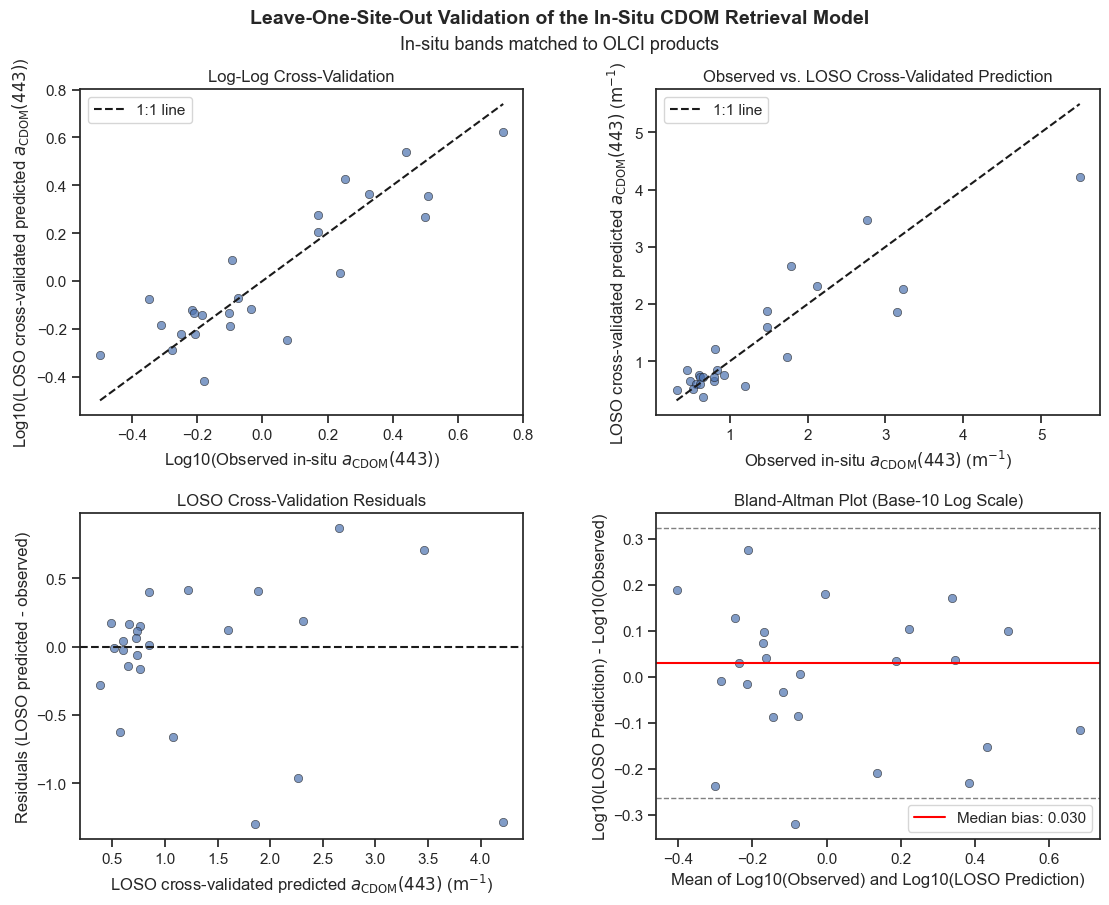

In [378]:

plot_validation_figures_base10(
    results_base10
)


In [266]:
coeffs_base10.describe()

,const,Rrs_srf_442.5,Rrs_srf_490.0,Rrs_srf_510.0,Rrs_srf_560.0
count,25.000000,25.000000,25.000000,25.000000,25.000000
mean,-4.052571,-1.122340,1.819984,-3.220703,1.080198
std,0.150627,0.208901,1.111952,1.155527,0.239068
min,-4.536303,-1.581780,-0.925794,-6.064408,0.547738
25%,-4.090448,-1.190341,1.386435,-3.540058,0.958159
50%,-4.061873,-1.121328,1.812846,-3.219628,1.082747
75%,-4.030237,-1.043213,2.133322,-2.740839,1.147074
max,-3.696445,-0.654427,4.446233,-0.400661,1.649523


In [268]:

# Turn the dictionary into a DataFrame
metrics_df = pd.DataFrame(list(metrics_base10.items()), columns=['Validation Metric', 'Value'])
# Turn the dictionary into a DataFrame
# Round all float values in the metrics DataFrame to 4 decimal places
metrics_df['Value'] = metrics_df['Value'].apply(lambda x: round(x, 4) if isinstance(x, (int, float)) else x)

# Copy to clipboard for easy pasting into Word/Excel
metrics_df.to_clipboard(excel=True, index=False)

# Option 2: Print a clean table view in your console to look at first
print(metrics_df.to_string(index=False))

 Validation Metric   Value
                 N 25.0000
       R2_original  0.7960
          R2_log10  0.7733
      Spearman_Rho  0.7885
        Spearman_p  0.0000
       Slope_log10  0.8044
   Intercept_log10  0.0017
    Slope_original  0.7475
Intercept_original  0.2777
              RMSD  0.5327
        Log10_RMSE  0.1469
      MdPD_percent  7.1370
     MdAPD_percent 25.2436
 Median_Log10_Bias  0.0299
   Mean_Log10_Bias -0.0009


In [108]:
water_samples_Rrs

,Site,CDOM_a412_m-1,CDOM_a434_m-1,CDOM_a443_m-1,CDOM_a490_m-1,Chl_a_[ug/L],Chl_b_[ug/L],Chl_c_[ug/L],Date,Latitude,...,sat_flag_OC4ME_FAIL,sat_flag_OCNN_FAIL,sat_flag_SATURATED,sat_flag_SNOW_ICE,sat_flag_SUSPECT,sat_flag_TIDAL,sat_flag_WATER,snapped_pixel_lat,snapped_pixel_lon,Rrs_conv_ratio_412_560
0,ISO-01,5.6681,3.7328,3.2217,1.6826,3.041240,-0.023840,0.732600,2026-04-28,53.263103,...,False,True,False,False,False,False,True,53.263694,-9.038737,0.148490
1,ISO-02,5.2462,3.6482,3.1513,1.4342,3.248234,0.019364,0.684792,2026-04-28,53.260653,...,False,True,False,False,False,False,True,53.261125,-9.039462,0.167979
2,ISO-03,3.5467,2.1829,1.7883,0.6034,2.660049,0.053825,0.475276,2026-04-28,53.250777,...,False,True,False,False,False,False,True,53.250170,-9.035626,0.143286
3,ISO-04,3.8306,2.5170,2.1257,0.8536,3.216769,0.003157,0.589285,2026-04-28,53.244920,...,False,False,False,False,False,False,True,53.245713,-9.043785,0.147839
4,ISO-05,1.3899,0.7341,0.4474,0.0350,14.443843,-0.190331,5.316073,2026-04-29,53.242783,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.298731
5,ISO-06,1.4635,0.7004,0.4885,0.0217,13.028986,-0.226679,4.731097,2026-04-29,53.242865,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.496207
6,ISO-07,1.3605,0.7114,0.6069,0.0887,7.048044,-1.133704,0.551598,2026-04-29,53.242872,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.452569
7,ISO-08A,9.4658,6.3757,5.4946,2.8589,3.327007,-0.048250,0.357905,2026-04-28,53.141730,...,False,False,False,False,False,True,True,53.142199,-8.935765,0.222611
8,ISO-08B,4.7905,3.0862,2.7564,1.4988,4.086672,0.245169,0.498590,2026-04-28,53.158338,...,True,False,False,False,False,False,True,53.159654,-8.951298,0.114316
9,ISO-09,2.5603,1.7749,1.4804,0.9081,4.624154,0.203794,0.639475,2026-04-28,53.167728,...,True,False,False,False,False,False,True,53.168040,-8.955759,0.187007


In [379]:
## Base-10 log version of the LOSO satellite-transfer model - KEEP FOR FINAL
## The original natural-log functions remain unchanged

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm


def leave_one_site_out_loso_sat_prediction_base10(
        df, site_col, y_col, in_situ_bands, sat_bands
):
    """
    Leave-one-site-out model transfer using base-10 logarithms.

    The model is trained on in-situ Rrs bands and then applied
    to the corresponding satellite Rrs bands for the left-out site.
    """

    target_cdom_wavelengths = ["412", "434", "443", "490"]

    cdom_check_cols = [
        col for col in df.columns
        if "CDOM" in col and any(wl in col for wl in target_cdom_wavelengths)
    ]

    if not cdom_check_cols:
        cdom_check_cols = [col for col in df.columns if "CDOM" in col]

    mandatory_cols = list(set(in_situ_bands + cdom_check_cols + [y_col]))

    clean_df = df.dropna(subset=mandatory_cols).copy()
    valid_mask = (clean_df[mandatory_cols] > 0).all(axis=1)
    clean_df = clean_df[valid_mask]

    sites = clean_df[site_col].unique()

    coefficients = []
    observed_all = []
    predicted_all = []
    site_labels = []

    # Leave-one-site-out loop
    for site in sites:
        train_df = clean_df[clean_df[site_col] != site]

        if train_df.empty:
            continue

        X_train = train_df[in_situ_bands]
        y_train = train_df[y_col]

        X_train_log10 = sm.add_constant(np.log10(X_train))
        y_train_log10 = np.log10(y_train)

        model = sm.OLS(y_train_log10, X_train_log10).fit()
        params = model.params

        coefficients.append({
            "site_left_out": site,
            **params.to_dict()
        })

        test_subset = clean_df[clean_df[site_col] == site].copy()
        sat_check_cols = list(set(sat_bands + [y_col]))

        test_subset = test_subset.dropna(subset=sat_check_cols)
        test_valid_mask = (test_subset[sat_check_cols] > 0).all(axis=1)
        test_subset = test_subset[test_valid_mask]

        if test_subset.empty:
            continue

        X_test_raw = test_subset[sat_bands]
        X_test_log10 = sm.add_constant(np.log10(X_test_raw), has_constant="add")

        rename_map = {
            satellite_band: in_situ_band
            for satellite_band, in_situ_band in zip(sat_bands, in_situ_bands)
        }

        X_test_log10 = X_test_log10.rename(columns=rename_map)
        X_test_log10 = X_test_log10.reindex(columns=X_train_log10.columns, fill_value=0)

        pred_log10 = model.predict(X_test_log10)
        predicted_values = 10 ** pred_log10

        observed_all.extend(test_subset[y_col].values)
        predicted_all.extend(predicted_values.values)
        site_labels.extend([site] * len(test_subset))

    results_sat_base10 = pd.DataFrame({
        "site": site_labels,
        "observed": observed_all,
        "predicted_sat": predicted_all
    })

    coeffs_sat_base10 = pd.DataFrame(coefficients)

    return results_sat_base10, coeffs_sat_base10


def calculate_validation_metrics_sat_base10(y_true, y_pred):
    """
    Calculate satellite-transfer validation metrics
    using base-10 logarithms.
    """

    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    valid = (
            np.isfinite(y_true)
            & np.isfinite(y_pred)
            & (y_true > 0)
            & (y_pred > 0)
    )

    y_true = y_true[valid]
    y_pred = y_pred[valid]

    log10_true = np.log10(y_true)
    log10_pred = np.log10(y_pred)

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2_original = 1 - ss_res / ss_tot

    ss_res_log10 = np.sum((log10_true - log10_pred) ** 2)
    ss_tot_log10 = np.sum((log10_true - np.mean(log10_true)) ** 2)
    r2_log10 = 1 - ss_res_log10 / ss_tot_log10

    spearman_corr, spearman_p = stats.spearmanr(y_true, y_pred)

    slope_log10, intercept_log10, r_log10, p_log10, se_log10 = stats.linregress(
        log10_true, log10_pred
    )

    slope_original, intercept_original, r_original, p_original, se_original = stats.linregress(
        y_true, y_pred
    )

    rmsd = np.sqrt(np.mean((y_pred - y_true) ** 2))
    log10_rmse = np.sqrt(np.mean((log10_pred - log10_true) ** 2))

    percentage_difference = 100 * (y_pred - y_true) / y_true
    mdpd = np.median(percentage_difference)
    mdapd = np.median(np.abs(percentage_difference))

    log10_difference = log10_pred - log10_true
    median_log10_bias = np.median(log10_difference)
    mean_log10_bias = np.mean(log10_difference)

    return {
        "N": len(y_true),
        "R2_original": r2_original,
        "R2_log10": r2_log10,
        "Spearman_Rho": spearman_corr,
        "Spearman_p": spearman_p,
        "Slope_log10": slope_log10,
        "Intercept_log10": intercept_log10,
        "Slope_original": slope_original,
        "Intercept_original": intercept_original,
        "RMSD": rmsd,
        "Log10_RMSE": log10_rmse,
        "MdPD_percent": mdpd,
        "MdAPD_percent": mdapd,
        "Median_Log10_Bias": median_log10_bias,
        "Mean_Log10_Bias": mean_log10_bias
    }


def plot_validation_figures_sat_base10(
        results_df, obs_col="observed", pred_col="predicted_sat"
):
    """
    Plot satellite-transfer validation results using
    base-10 logarithms.
    """

    y_true = results_df[obs_col].to_numpy(dtype=float)
    y_pred = results_df[pred_col].to_numpy(dtype=float)

    valid = (
            np.isfinite(y_true)
            & np.isfinite(y_pred)
            & (y_true > 0)
            & (y_pred > 0)
    )

    y_true = y_true[valid]
    y_pred = y_pred[valid]

    log10_true = np.log10(y_true)
    log10_pred = np.log10(y_pred)
    residuals = y_pred - y_true

    fig, axes = plt.subplots(2, 2, figsize=(12, 11))
    plt.subplots_adjust(hspace=0.4, wspace=0.3)

    # 1. Log-log scatterplot
    ax = axes[0, 0]
    ax.scatter(log10_true, log10_pred, alpha=0.7, edgecolor="k", linewidth=0.5)

    min_val = min(log10_true.min(), log10_pred.min())
    max_val = max(log10_true.max(), log10_pred.max())

    ax.plot([min_val, max_val], [min_val, max_val], "k--", linewidth=1.5, label="1:1 line")
    ax.set_xlabel(r"Log10(Observed in-situ $a_{\mathrm{CDOM}}(443)$)")
    ax.set_ylabel(r"Log10(CDOM predicted from satellite $R_{rs}$" + "\n" + r"using the in-situ model)")
    ax.set_title("Log-Log Satellite Transfer")
    ax.legend(loc="best")

    # 2. Original-scale comparison
    ax = axes[0, 1]
    ax.scatter(y_true, y_pred, alpha=0.7, edgecolor="k", linewidth=0.5)

    min_original = min(y_true.min(), y_pred.min())
    max_original = max(y_true.max(), y_pred.max())

    ax.plot([min_original, max_original], [min_original, max_original], "k--", linewidth=1.5, label="1:1 line")
    ax.set_xlabel(r"Observed in-situ $a_{\mathrm{CDOM}}(443)$ ($\mathrm{m^{-1}}$)")
    ax.set_ylabel(r"CDOM predicted from satellite $R_{rs}$" + "\n" + r"using the in-situ model ($\mathrm{m^{-1}}$)")
    ax.set_title("Observed vs. Satellite-Transferred Prediction")
    ax.legend(loc="best")

    # 3. Residual plot
    ax = axes[1, 0]
    ax.scatter(y_pred, residuals, alpha=0.7, edgecolor="k", linewidth=0.5)
    ax.axhline(0, color="k", linestyle="--", linewidth=1.5)
    ax.set_xlabel(r"CDOM predicted from satellite $R_{rs}$ using the in-situ model ($\mathrm{m^{-1}}$)")
    ax.set_ylabel(r"Residuals: satellite-transferred prediction" + "\n" + r"- observed ($\mathrm{m^{-1}}$)")
    ax.set_title("Satellite-Transfer Residuals")

    # 4. Bland-Altman plot in base-10 log space
    ax = axes[1, 1]
    mean_log10 = (log10_true + log10_pred) / 2
    difference_log10 = log10_pred - log10_true

    median_bias = np.median(difference_log10)
    sd_difference = np.std(difference_log10, ddof=1)

    ax.scatter(mean_log10, difference_log10, alpha=0.7, edgecolor="k", linewidth=0.5)
    ax.axhline(median_bias, color="red", linestyle="-", linewidth=1.5, label=f"Median bias: {median_bias:.3f}")
    ax.axhline(median_bias + 1.96 * sd_difference, color="gray", linestyle="--", linewidth=1)
    ax.axhline(median_bias - 1.96 * sd_difference, color="gray", linestyle="--", linewidth=1)

    ax.set_xlabel("Mean of Log10(Observed) and Log10(Satellite Prediction)")
    ax.set_ylabel(r"Log10(Satellite Prediction)" + "\n" + r"- Log10(Observed)")
    ax.set_title("Bland-Altman Plot (Base-10 Log Scale)")
    ax.legend(loc="best")

    fig.suptitle("Transfer Validation of the In-Situ CDOM Model Using OLCI Satellite Rrs", fontsize=14, fontweight="bold",
                 y=0.93
                 )
    fig.text(
        0.5,
        0.89,
        "In-situ bands matched to OLCI products",
        ha="center",
        fontsize=13
    )
    fig.subplots_adjust(top=0.85, bottom=0.1, left=0.1, right=0.95, hspace=0.3, wspace=0.3)

    plt.savefig("C:/Users/25298423/PycharmProjects/FinalFigures/loso_OCLI_satellite_validation_plot.png", dpi=1200, bbox_inches="tight")

    plt.show()

{'N': 10, 'R2_original': np.float64(-8.619316037226383), 'R2_log10': np.float64(-2.6022512613769093), 'Spearman_Rho': np.float64(0.04242424242424241), 'Spearman_p': np.float64(0.907363817812816), 'Slope_log10': np.float64(0.06849085947341536), 'Intercept_log10': np.float64(0.6003451809513827), 'Slope_original': np.float64(-0.3554844039984753), 'Intercept_original': np.float64(5.480946420768729), 'RMSD': np.float64(4.367051701527376), 'Log10_RMSE': np.float64(0.6248660118952777), 'MdPD_percent': np.float64(259.0788653036765), 'MdAPD_percent': np.float64(259.0788653036765), 'Median_Log10_Bias': np.float64(0.55257528338555), 'Mean_Log10_Bias': np.float64(0.4732097147884134)}


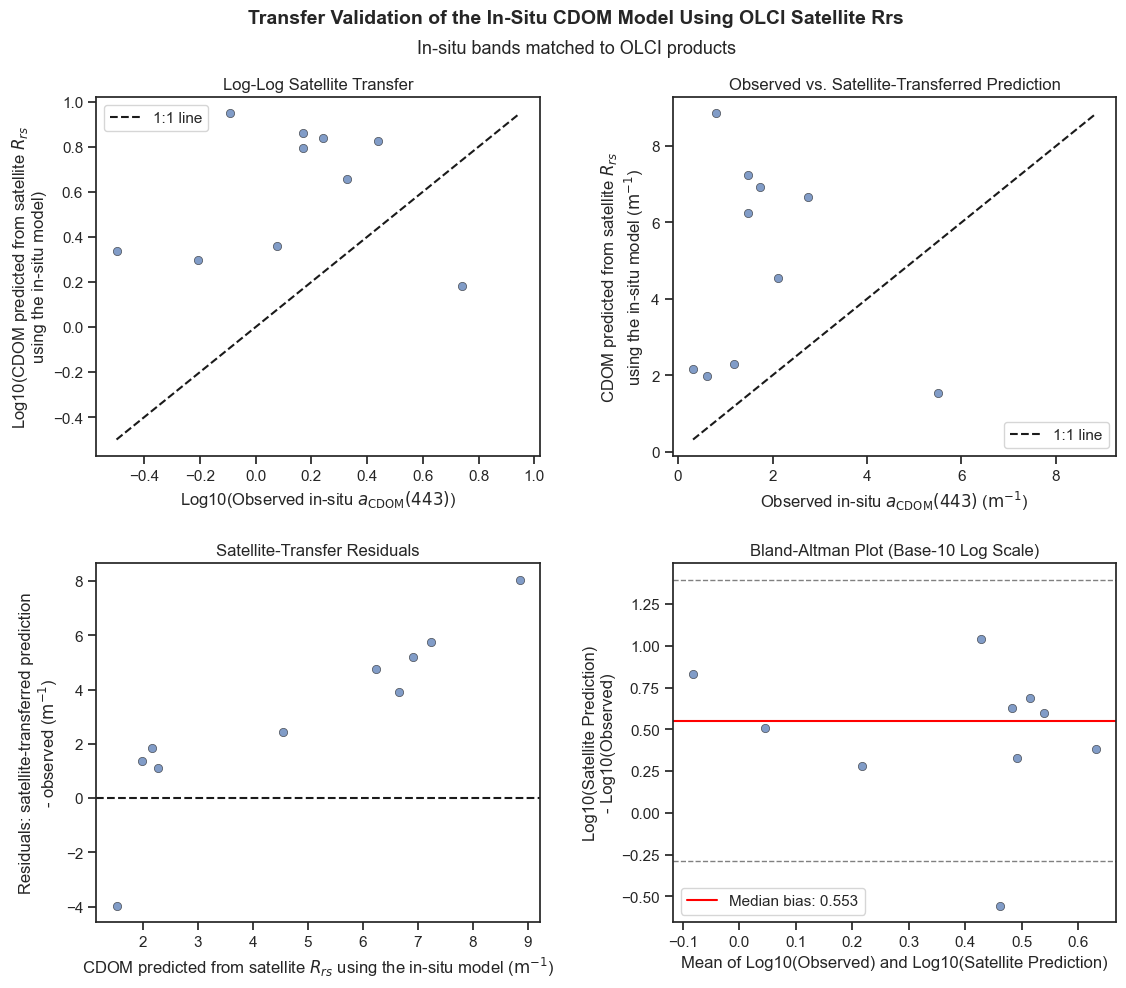

In [380]:
results_sat_base10, coeffs_sat_base10 = (
    leave_one_site_out_loso_sat_prediction_base10(
        water_samples_Rrs,
        site_col="Site",
        y_col="CDOM_a443_m-1",
        in_situ_bands=[
            "Rrs_srf_442.5",
            "Rrs_srf_490.0",
            "Rrs_srf_510.0",
            "Rrs_srf_560.0"
        ],
        sat_bands=[
            "sat_Rrs_442.5",
            "sat_Rrs_490.0",
            "sat_Rrs_510.0",
            "sat_Rrs_560.0"
        ]
    )
)

metrics_sat_base10 = (
    calculate_validation_metrics_sat_base10(
        results_sat_base10["observed"],
        results_sat_base10["predicted_sat"]
    )
)

print(metrics_sat_base10)

plot_validation_figures_sat_base10(
    results_sat_base10
)


In [285]:

# Turn the dictionary into a DataFrame
metrics_sat_df = pd.DataFrame(list(metrics_sat_base10.items()), columns=['Validation Metric', 'Value'])
# Turn the dictionary into a DataFrame
# Round all float values in the metrics DataFrame to 4 decimal places
metrics_sat_df['Value'] = metrics_sat_df['Value'].apply(lambda x: round(x, 4) if isinstance(x, (int, float)) else x)

# Copy to clipboard for easy pasting into Word/Excel
metrics_sat_df.to_clipboard(excel=True, index=False)

# Option 2: Print a clean table view in your console to look at first
print(metrics_sat_df.to_string(index=False))

 Validation Metric    Value
                 N  10.0000
       R2_original  -8.6193
          R2_log10  -2.6023
      Spearman_Rho   0.0424
        Spearman_p   0.9074
       Slope_log10   0.0685
   Intercept_log10   0.6003
    Slope_original  -0.3555
Intercept_original   5.4809
              RMSD   4.3671
        Log10_RMSE   0.6249
      MdPD_percent 259.0789
     MdAPD_percent 259.0789
 Median_Log10_Bias   0.5526
   Mean_Log10_Bias   0.4732


In [112]:
coeffs.describe()

,const,Rrs_srf_442.5,Rrs_srf_490.0,Rrs_srf_510.0,Rrs_srf_560.0
count,25.000000,25.000000,25.000000,25.000000,25.000000
mean,-9.331390,-1.122340,1.819984,-3.220703,1.080198
std,0.346831,0.208901,1.111952,1.155527,0.239068
min,-10.445224,-1.581780,-0.925794,-6.064408,0.547738
25%,-9.418604,-1.190341,1.386435,-3.540058,0.958159
50%,-9.352809,-1.121328,1.812846,-3.219628,1.082747
75%,-9.279964,-1.043213,2.133322,-2.740839,1.147074
max,-8.511378,-0.654427,4.446233,-0.400661,1.649523


In [113]:
import pandas as pd

# Turn the dictionary into a DataFrame
# Round all float values in the metrics DataFrame to 4 decimal places
metrics_df['Value'] = metrics_df['Value'].apply(lambda x: round(x, 4) if isinstance(x, (int, float)) else x)

# Copy to clipboard for easy pasting into Word/Excel
metrics_df.to_clipboard(excel=True, index=False)

# Option 2: Print a clean table view in your console to look at first
print(metrics_df.to_string(index=False))

 Validation Metric   Value
                 N 25.0000
       R2_original  0.7960
            R2_log  0.7733
      Spearman_Rho  0.7885
        Spearman_p  0.0000
         Slope_log  0.8044
     Intercept_log  0.0039
    Slope_original  0.7475
Intercept_original  0.2777
              RMSD  0.5327
          Log_RMSE  0.3383
      MdPD_percent  7.1370
     MdAPD_percent 25.2436
   Median_Log_Bias  0.0689
     Mean_Log_Bias -0.0020


## LOSO Take 2: Correct Labels Names

# Comparing Directly To Copernicus Chl-a

In [114]:
# Create a mapping dictionary or series from stations for latitude and longitude
lat_map = stations.set_index('Site')['latitude_dec']
lon_map = stations.set_index('Site')['longitude_dec']
date_map = stations.set_index('Site')['Date']
# Fill missing latitude and longitude values in water_samples_Rrs using the Site column
water_samples_Rrs['Latitude'] = water_samples_Rrs['Latitude'].fillna(
    water_samples_Rrs['Site'].map(lat_map)
)
water_samples_Rrs['Longitude'] = water_samples_Rrs['Longitude'].fillna(
    water_samples_Rrs['Site'].map(lon_map)
)
water_samples_Rrs['Date'] = water_samples_Rrs['Date'].fillna(
    water_samples_Rrs['Site'].map(date_map)
)
water_samples_Rrs['Date'] = pd.to_datetime(water_samples_Rrs['Date'])

In [115]:
notes_map = secchi.set_index('Site')['Notes']
water_samples_Rrs['Notes'] = water_samples_Rrs['Site'].map(notes_map)

In [116]:
water_samples_Rrs

,Site,CDOM_a412_m-1,CDOM_a434_m-1,CDOM_a443_m-1,CDOM_a490_m-1,Chl_a_[ug/L],Chl_b_[ug/L],Chl_c_[ug/L],Date,Latitude,...,sat_flag_OC4ME_FAIL,sat_flag_OCNN_FAIL,sat_flag_SATURATED,sat_flag_SNOW_ICE,sat_flag_SUSPECT,sat_flag_TIDAL,sat_flag_WATER,snapped_pixel_lat,snapped_pixel_lon,Rrs_conv_ratio_412_560
0,ISO-01,5.6681,3.7328,3.2217,1.6826,3.041240,-0.023840,0.732600,2026-04-28,53.263103,...,False,True,False,False,False,False,True,53.263694,-9.038737,0.148490
1,ISO-02,5.2462,3.6482,3.1513,1.4342,3.248234,0.019364,0.684792,2026-04-28,53.260653,...,False,True,False,False,False,False,True,53.261125,-9.039462,0.167979
2,ISO-03,3.5467,2.1829,1.7883,0.6034,2.660049,0.053825,0.475276,2026-04-28,53.250777,...,False,True,False,False,False,False,True,53.250170,-9.035626,0.143286
3,ISO-04,3.8306,2.5170,2.1257,0.8536,3.216769,0.003157,0.589285,2026-04-28,53.244920,...,False,False,False,False,False,False,True,53.245713,-9.043785,0.147839
4,ISO-05,1.3899,0.7341,0.4474,0.0350,14.443843,-0.190331,5.316073,2026-04-29,53.242783,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.298731
5,ISO-06,1.4635,0.7004,0.4885,0.0217,13.028986,-0.226679,4.731097,2026-04-29,53.242865,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.496207
6,ISO-07,1.3605,0.7114,0.6069,0.0887,7.048044,-1.133704,0.551598,2026-04-29,53.242872,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.452569
7,ISO-08A,9.4658,6.3757,5.4946,2.8589,3.327007,-0.048250,0.357905,2026-04-28,53.141730,...,False,False,False,False,False,True,True,53.142199,-8.935765,0.222611
8,ISO-08B,4.7905,3.0862,2.7564,1.4988,4.086672,0.245169,0.498590,2026-04-28,53.158338,...,True,False,False,False,False,False,True,53.159654,-8.951298,0.114316
9,ISO-09,2.5603,1.7749,1.4804,0.9081,4.624154,0.203794,0.639475,2026-04-28,53.167728,...,True,False,False,False,False,False,True,53.168040,-8.955759,0.187007


<xarray.Dataset> Size: 7MB
Dimensions:    (time: 61, latitude: 135, longitude: 225)
Coordinates:
  * time       (time) datetime64[ns] 488B 2026-04-01 2026-04-02 ... 2026-05-31
  * latitude   (latitude) float32 540B 52.75 52.76 52.76 ... 53.49 53.49 53.5
  * longitude  (longitude) float32 900B -9.997 -9.992 -9.986 ... -8.758 -8.753
Data variables:
    CHL        (time, latitude, longitude) float32 7MB dask.array<chunksize=(61, 135, 225), meta=np.ndarray>
Attributes:
    comment:                   average
    Conventions:               CF-1.8, ACDD-1.3
    title:                     cmems_obs-oc_atl_bgc-plankton_my_l3-olci-300m_P1D
    source:                    surface observation
    references:                http://www.globcolour.info GlobColour has been...
    institution:               ACRI
    contact:                   servicedesk.cmems@acri-st.fr
    history:                   Created using software developed at ACRI-ST
    copernicusmarine_version:  2.2.2

2026-04-28T00:00:00.000000000
Checking duplicate NaN patterns across the dataset...

🤔 No duplicate timestamps were found in the dataset to compare.
Checking if duplicate pixel values match exactly across the dataset...

🤔 No duplicate timestamps were found in the dataset to compare.


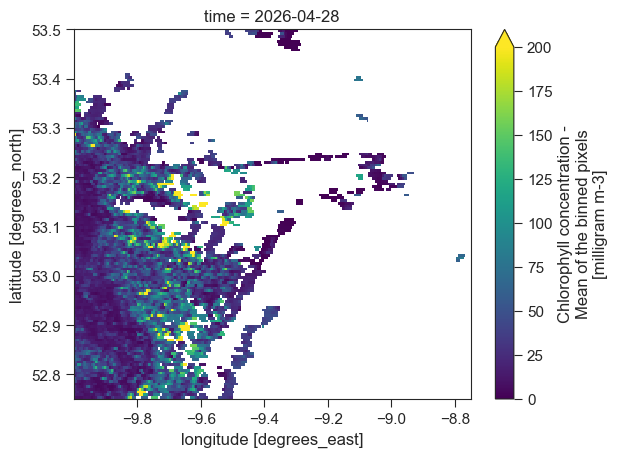

In [117]:
import glob
chla_insitu_file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/in-situ/CHL/*.nc'))
chla_is = xr.open_mfdataset(chla_insitu_file_list, concat_dim='time', combine='nested')
display(chla_is)
print(chla_is['CHL'].sel(time='2026-04-28').time.values)
## there are multiple passes in one day
# Strip out the exact duplicates by keeping only the first unique timestamp
_, index = np.unique(chla_is['time'], return_index=True)
chla_is_one = chla_is.isel(time=index)
chla_is_one['CHL'].sel(time='2026-04-28').plot(x='longitude', y='latitude', vmin=0, vmax=200)
## Code to check if the NaN values are the same everyday

# 1. Group by the time coordinate
grouped = chla_is['CHL'].groupby('time')

all_duplicates_identical = True
checked_days_count = 0

print("Checking duplicate NaN patterns across the dataset...\n")

for time_val, group in grouped:
    # We only care about days that actually have duplicates (more than 1 slice)
    if group.sizes['time'] > 1:
        checked_days_count += 1

        # Get the NaN mask for all slices on this day (True where NaN, False where valid)
        nan_mask = group.isnull()

        # Check if the NaN mask for the first slice matches all other slices along the time dim
        # .all() checks if every single pixel matches
        is_identical = (nan_mask == nan_mask.isel(time=0)).all().values

        if not is_identical:
            print(f"❌ Mismatch found on day {np.datetime_as_string(time_val, unit='D')}!")
            all_duplicates_identical = False
            break

# 2. Print final verdict
if all_duplicates_identical and checked_days_count > 0:
    print(f"✅ Success! Verified {checked_days_count} days with duplicate files.")
    print("For every single one of those days, the NaN values are in the exact same spots.")
elif checked_days_count == 0:
    print("🤔 No duplicate timestamps were found in the dataset to compare.")
## check if the values of every pixel are the same per day

import numpy as np

# 1. Group by the time coordinate
grouped = chla_is['CHL'].groupby('time')

all_values_identical = True
checked_days_count = 0

print("Checking if duplicate pixel values match exactly across the dataset...\n")

for time_val, group in grouped:
    # Target only the days that have duplicates
    if group.sizes['time'] > 1:
        checked_days_count += 1

        # Extract the underlying numpy array for the daily slices
        data_array = group.values
        first_slice = data_array[0]

        # Compare every subsequent slice to the first slice
        for i in range(1, len(data_array)):
            is_match = np.allclose(first_slice, data_array[i], equal_nan=True)

            if not is_match:
                print(f"❌ Value mismatch found on day {np.datetime_as_string(time_val, unit='D')} at slice index {i}!")
                all_values_identical = False
                break

    if not all_values_identical:
        break

# 2. Print final verdict
if all_values_identical and checked_days_count > 0:
    print(
        f"✅ Success! All data values are 100% identical across the duplicate slices for all {checked_days_count} days.")
elif checked_days_count == 0:
    print("🤔 No duplicate timestamps were found in the dataset to compare.")
## can write over the orignal data with this one, as it is verified that the values are the same for every pass every day
# Strip out the exact duplicates by keeping only the first unique timestamp
_, index = np.unique(chla_is['time'], return_index=True)
chla_is = chla_is.isel(time=index)

In [118]:
chla_is

<xarray.Dataset> Size: 7MB
Dimensions:    (time: 61, latitude: 135, longitude: 225)
Coordinates:
  * time       (time) datetime64[ns] 488B 2026-04-01 2026-04-02 ... 2026-05-31
  * latitude   (latitude) float32 540B 52.75 52.76 52.76 ... 53.49 53.49 53.5
  * longitude  (longitude) float32 900B -9.997 -9.992 -9.986 ... -8.758 -8.753
Data variables:
    CHL        (time, latitude, longitude) float32 7MB dask.array<chunksize=(61, 135, 225), meta=np.ndarray>
Attributes:
    comment:                   average
    Conventions:               CF-1.8, ACDD-1.3
    title:                     cmems_obs-oc_atl_bgc-plankton_my_l3-olci-300m_P1D
    source:                    surface observation
    references:                http://www.globcolour.info GlobColour has been...
    institution:               ACRI
    contact:                   servicedesk.cmems@acri-st.fr
    history:                   Created using software developed at ACRI-ST
    copernicusmarine_version:  2.2.2

In [119]:
import numpy as np
import pandas as pd
import xarray as xr

# 1. Ensure the Date column in your dataframe is in datetime format
water_samples_Rrs['Date'] = pd.to_datetime(water_samples_Rrs['Date'])

# 2. Convert dataframe columns into Xarray DataArrays for fast, vectorized indexing
lats = xr.DataArray(water_samples_Rrs['Latitude'].values, dims="sample")
lons = xr.DataArray(water_samples_Rrs['Longitude'].values, dims="sample")
times = xr.DataArray(water_samples_Rrs['Date'].values, dims="sample")

# 3. Extract the CHL values matching each specific date, latitude, and longitude
matched_chl = chla_is['CHL'].sel(
    latitude=lats,
    longitude=lons,
    time=times,
    method='nearest'
)

# 4. Add the extracted satellite Chl-a values directly back into your dataframe
water_samples_Rrs['CHL_copernicus'] = matched_chl.values

print(f"Successfully matched Chl-a for {water_samples_Rrs['CHL_copernicus'].notna().sum()} out of {len(water_samples_Rrs)} rows!")

Successfully matched Chl-a for 14 out of 34 rows!


In [120]:
water_samples_Rrs[["Site", "Date", "Chl_a_[ug/L]","CHL_copernicus"]]

,Site,Date,Chl_a_[ug/L],CHL_copernicus
0,ISO-01,2026-04-28,3.041240,NaN
1,ISO-02,2026-04-28,3.248234,NaN
2,ISO-03,2026-04-28,2.660049,NaN
3,ISO-04,2026-04-28,3.216769,4.096779
4,ISO-05,2026-04-29,14.443843,NaN
5,ISO-06,2026-04-29,13.028986,89.036270
6,ISO-07,2026-04-29,7.048044,39.573650
7,ISO-08A,2026-04-28,3.327007,NaN
8,ISO-08B,2026-04-28,4.086672,NaN
9,ISO-09,2026-04-28,4.624154,NaN


C:\Users\25298423\AppData\Local\Temp\ipykernel_14932\194424440.py:50: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\25298423\PycharmProjects\JupyterProject1\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


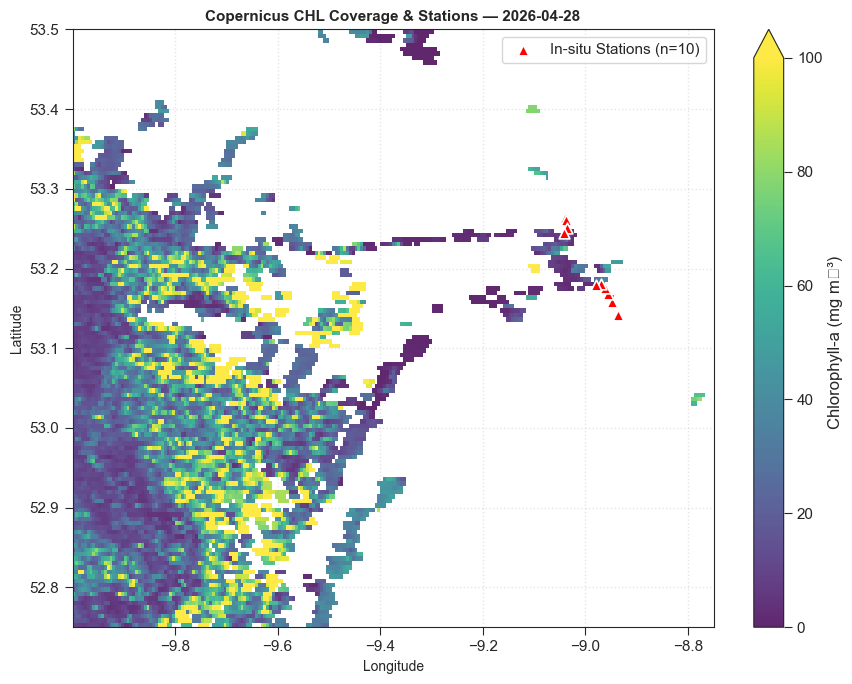

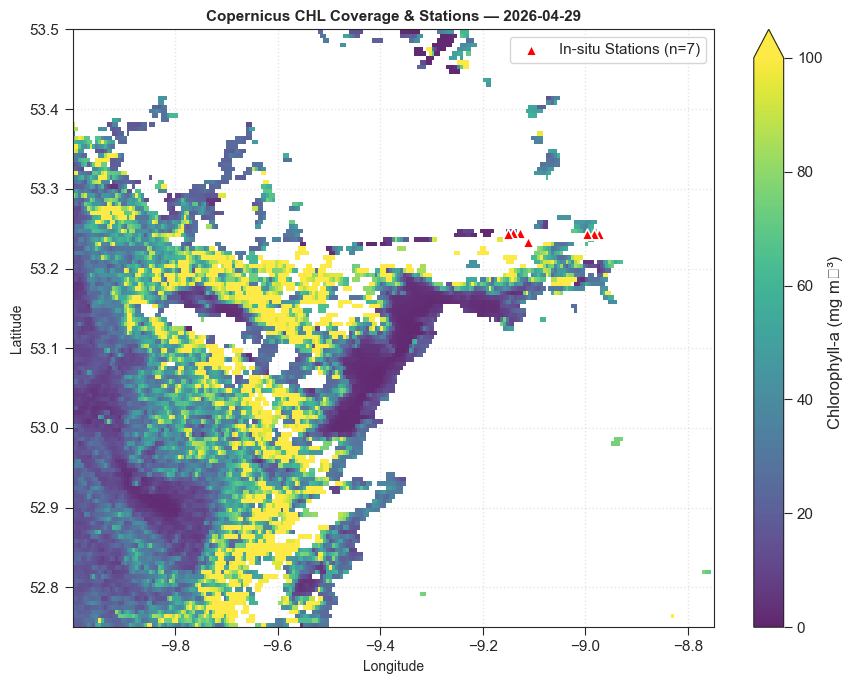

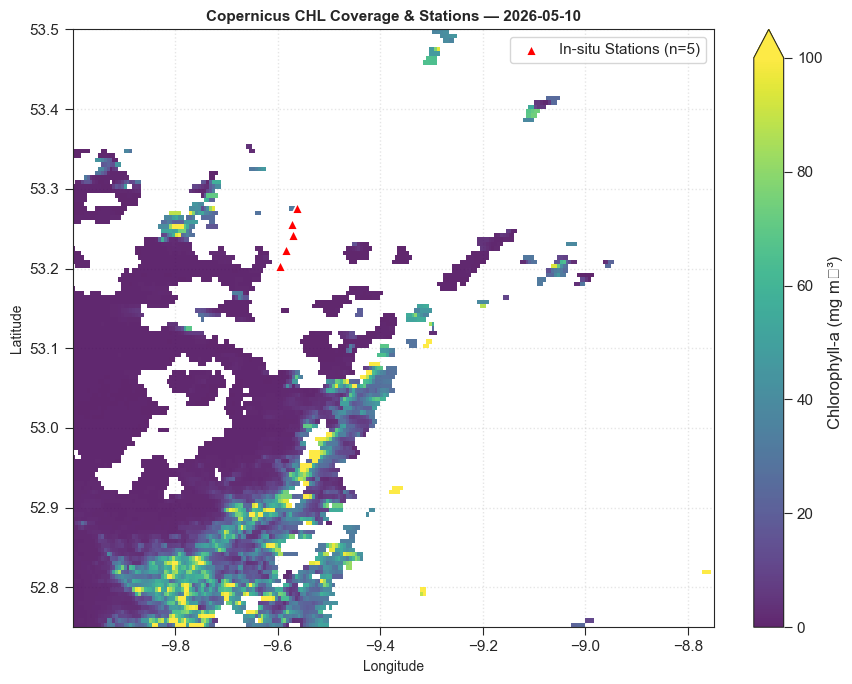

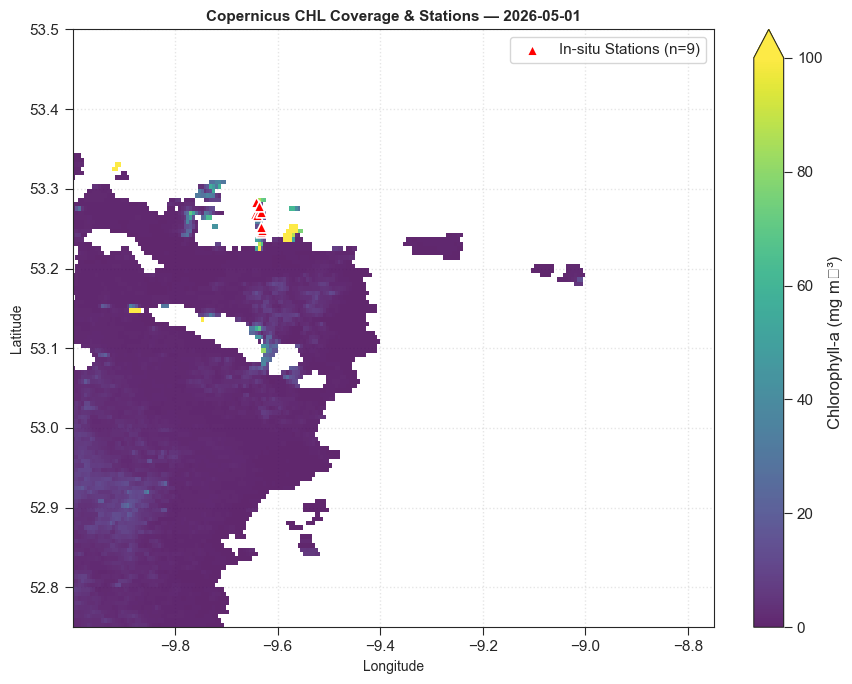

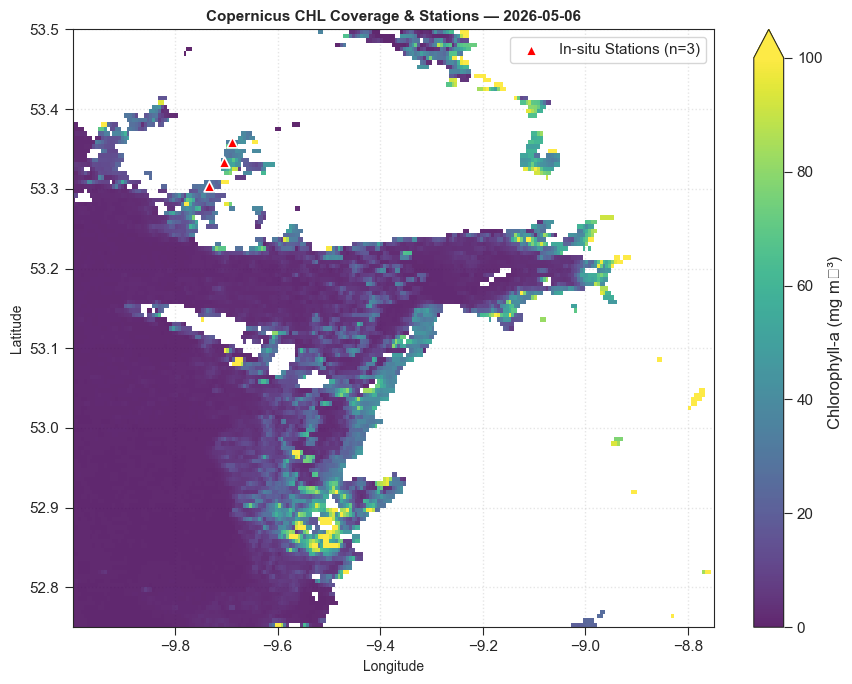

In [121]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

# 1. Ensure Date is in datetime format and get unique dates from your in-situ data
water_samples_Rrs['Date'] = pd.to_datetime(water_samples_Rrs['Date'])
unique_dates = water_samples_Rrs['Date'].dt.date.unique()

# 2. Loop through each date to plot Copernicus CHL grid coverage with station overlays
for date_val in unique_dates:
    # Filter stations active on this specific date
    day_stations = water_samples_Rrs[water_samples_Rrs['Date'].dt.date == date_val]

    try:
        # Extract Copernicus CHL spatial grid for this date (using nearest time match)
        chla_day = chla_is['CHL'].sel(time=str(date_val), method='nearest')

        fig, ax = plt.subplots(figsize=(9, 7))

        # Plot the 1km x 1km Copernicus CHL spatial field
        im = chla_day.plot(
            ax=ax,
            cmap='viridis',
            vmin=0,
            vmax=100,
            add_colorbar=True,
            cbar_kwargs={'label': 'Chlorophyll-a (mg m⁻³)'},
            alpha=0.85
        )

        # Overlay the in-situ station locations for this day
        ax.scatter(
            day_stations['Longitude'],
            day_stations['Latitude'],
            color='red',
            marker='^',
            s=60,
            edgecolor='white',
            linewidth=1.2,
            label=f'In-situ Stations (n={len(day_stations)})'
        )

        ax.set_title(f"Copernicus CHL Coverage & Stations — {date_val}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Longitude", fontsize=10)
        ax.set_ylabel("Latitude", fontsize=10)
        ax.legend(loc='upper right', frameon=True)
        ax.grid(True, linestyle=":", alpha=0.5)

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Could not plot date {date_val}: {e}")

In [122]:
chla_is['CHL']

<xarray.DataArray 'CHL' (time: 61, latitude: 135, longitude: 225)> Size: 7MB
dask.array<getitem, shape=(61, 135, 225), dtype=float32, chunksize=(61, 135, 225), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 488B 2026-04-01 2026-04-02 ... 2026-05-31
  * latitude   (latitude) float32 540B 52.75 52.76 52.76 ... 53.49 53.49 53.5
  * longitude  (longitude) float32 900B -9.997 -9.992 -9.986 ... -8.758 -8.753
Attributes:
    long_name:      Chlorophyll concentration - Mean of the binned pixels
    units:          milligram m-3
    valid_min:      0.0
    valid_max:      1000.0
    standard_name:  mass_concentration_of_chlorophyll_a_in_sea_water

In [123]:
import numpy as np
import pandas as pd
import xarray as xr

# 1. Ensure Date is in datetime format and initialize output columns
water_samples_Rrs['Date'] = pd.to_datetime(water_samples_Rrs['Date'])
water_samples_Rrs['CHL_copernicus'] = np.nan
water_samples_Rrs['CHL_copernicus_adj'] = np.nan

lat_vals = chla_is['latitude'].values
lon_vals = chla_is['longitude'].values

# 2. Loop through each station matchup
for idx, row in water_samples_Rrs.iterrows():
    target_date = row['Date']
    t_lat = row['Latitude']
    t_lon = row['Longitude']

    try:
        # Select the Copernicus CHL slice for this specific date using nearest time
        chla_slice = chla_is['CHL'].sel(time=target_date, method='nearest')

        # Find index of the exact nearest grid cell
        lat_idx = np.abs(lat_vals - t_lat).argmin()
        lon_idx = np.abs(lon_vals - t_lon).argmin()

        # Exact pixel match (extracting safely as a scalar float)
        exact_val = chla_slice.isel(latitude=lat_idx, longitude=lon_idx).values.item()

        if exact_val is not None and not np.isnan(exact_val):
            water_samples_Rrs.loc[idx, 'CHL_copernicus'] = exact_val
            water_samples_Rrs.loc[idx, 'CHL_copernicus_adj'] = exact_val
        else:
            # If exact pixel is NaN, search adjacent pixels within a 2km radius (±2 grid cells)
            radius = 2
            lat_start = max(0, lat_idx - radius)
            lat_end = min(len(lat_vals), lat_idx + radius + 1)
            lon_start = max(0, lon_idx - radius)
            lon_end = min(len(lon_vals), lon_idx + radius + 1)

            window = chla_slice.isel(
                latitude=slice(lat_start, lat_end),
                longitude=slice(lon_start, lon_end)
            )

            window_vals = window.values
            valid_mask = ~np.isnan(window_vals)

            if valid_mask.any():
                sub_lats = lat_vals[lat_start:lat_end]
                sub_lons = lon_vals[lon_start:lon_end]
                sub_lon_grid, sub_lat_grid = np.meshgrid(sub_lons, sub_lats)

                valid_indices = np.where(valid_mask)
                dists = (sub_lat_grid[valid_indices] - t_lat)**2 + (sub_lon_grid[valid_indices] - t_lon)**2
                closest_idx = np.argmin(dists)

                adj_val = window_vals[valid_indices[0][closest_idx], valid_indices[1][closest_idx]]
                water_samples_Rrs.loc[idx, 'CHL_copernicus_adj'] = adj_val

    except Exception as e:
        print(f"Error at row {idx}: {e}")
        continue

print(f"Exact matches (CHL_copernicus): {water_samples_Rrs['CHL_copernicus'].notna().sum()} out of {len(water_samples_Rrs)}")
print(f"Matches with adjacency fallback (CHL_copernicus_adj): {water_samples_Rrs['CHL_copernicus_adj'].notna().sum()} out of {len(water_samples_Rrs)}")

Exact matches (CHL_copernicus): 14 out of 34
Matches with adjacency fallback (CHL_copernicus_adj): 27 out of 34


In [124]:
water_samples_Rrs[['Site','Chl_a_[ug/L]','CHL_copernicus','CHL_copernicus_adj']]

,Site,Chl_a_[ug/L],CHL_copernicus,CHL_copernicus_adj
0,ISO-01,3.041240,NaN,NaN
1,ISO-02,3.248234,NaN,4.091745
2,ISO-03,2.660049,NaN,4.091745
3,ISO-04,3.216769,4.096779,4.096779
4,ISO-05,14.443843,NaN,75.539368
5,ISO-06,13.028986,89.036270,89.036270
6,ISO-07,7.048044,39.573650,39.573650
7,ISO-08A,3.327007,NaN,NaN
8,ISO-08B,4.086672,NaN,55.633991
9,ISO-09,4.624154,NaN,55.643433


In [125]:
## This one includes metrics like distance to pixel and all that
import numpy as np
import pandas as pd


def calculate_distance_m(lat1, lon1, lat2, lon2):
    """
    Approximate distance between two latitude/longitude points in metres.
    """
    meters_per_degree_lat = 111120.0
    meters_per_degree_lon = (
            111120.0 * np.cos(np.radians(lat1))
    )

    delta_lat = lat2 - lat1
    delta_lon = lon2 - lon1

    return np.sqrt(
        (delta_lat * meters_per_degree_lat) ** 2
        + (delta_lon * meters_per_degree_lon) ** 2
    )


# Ensure station dates are datetime values
water_samples_Rrs["Date"] = pd.to_datetime(
    water_samples_Rrs["Date"]
)

# Initialise CHL-specific output columns
water_samples_Rrs["CHL_copernicus"] = np.nan
water_samples_Rrs["CHL_copernicus_adj"] = np.nan
water_samples_Rrs["CHL_selected_pixel_lat"] = np.nan
water_samples_Rrs["CHL_selected_pixel_lon"] = np.nan
water_samples_Rrs[
    "CHL_distance_to_selected_pixel_m"
] = np.nan
water_samples_Rrs["CHL_matchup_source"] = np.nan

# Satellite coordinate arrays
lat_vals = chla_is["latitude"].values
lon_vals = chla_is["longitude"].values

# Convert satellite times to calendar dates
satellite_days = pd.to_datetime(
    chla_is["time"].values
).normalize()

# Local search radius in grid-cell indices
radius_cells = 2

for idx, row in water_samples_Rrs.iterrows():

    target_day = pd.Timestamp(
        row["Date"]
    ).normalize()

    target_lat = row["Latitude"]
    target_lon = row["Longitude"]

    try:
        # Select only an exact calendar-day match
        matching_times = np.where(
            satellite_days == target_day
        )[0]

        if len(matching_times) == 0:
            continue

        # Use the first satellite slice for that calendar day
        chla_slice = chla_is["CHL"].isel(
            time=matching_times[0]
        )

        # Find the nearest satellite grid cell
        lat_idx = np.abs(
            lat_vals - target_lat
        ).argmin()

        lon_idx = np.abs(
            lon_vals - target_lon
        ).argmin()

        exact_lat = float(
            lat_vals[lat_idx]
        )

        exact_lon = float(
            lon_vals[lon_idx]
        )

        exact_value = float(
            np.asarray(
                chla_slice.isel(
                    latitude=lat_idx,
                    longitude=lon_idx
                ).values
            ).squeeze()
        )

        exact_distance_m = calculate_distance_m(
            target_lat,
            target_lon,
            exact_lat,
            exact_lon
        )

        # Exact pixel is valid
        if np.isfinite(exact_value):

            water_samples_Rrs.loc[
                idx,
                "CHL_copernicus"
            ] = exact_value

            # Best-available column uses exact pixel
            water_samples_Rrs.loc[
                idx,
                "CHL_copernicus_adj"
            ] = exact_value

            water_samples_Rrs.loc[
                idx,
                "CHL_selected_pixel_lat"
            ] = exact_lat

            water_samples_Rrs.loc[
                idx,
                "CHL_selected_pixel_lon"
            ] = exact_lon

            water_samples_Rrs.loc[
                idx,
                "CHL_distance_to_selected_pixel_m"
            ] = exact_distance_m

            water_samples_Rrs.loc[
                idx,
                "CHL_matchup_source"
            ] = "exact"

        # Exact pixel is missing, so search locally
        else:

            lat_start = max(
                0,
                lat_idx - radius_cells
            )

            lat_end = min(
                len(lat_vals),
                lat_idx + radius_cells + 1
            )

            lon_start = max(
                0,
                lon_idx - radius_cells
            )

            lon_end = min(
                len(lon_vals),
                lon_idx + radius_cells + 1
            )

            window = chla_slice.isel(
                latitude=slice(lat_start, lat_end),
                longitude=slice(lon_start, lon_end)
            )

            window_vals = np.asarray(
                window.values
            )

            valid_mask = np.isfinite(
                window_vals
            )

            if not valid_mask.any():
                continue

            sub_lats = lat_vals[
                lat_start:lat_end
            ]

            sub_lons = lon_vals[
                lon_start:lon_end
            ]

            sub_lon_grid, sub_lat_grid = np.meshgrid(
                sub_lons,
                sub_lats
            )

            valid_indices = np.where(
                valid_mask
            )

            candidate_lats = sub_lat_grid[
                valid_indices
            ]

            candidate_lons = sub_lon_grid[
                valid_indices
            ]

            candidate_values = window_vals[
                valid_indices
            ]

            candidate_distances_m = np.array([
                calculate_distance_m(
                    target_lat,
                    target_lon,
                    candidate_lat,
                    candidate_lon
                )
                for candidate_lat, candidate_lon
                in zip(
                    candidate_lats,
                    candidate_lons
                )
            ])

            closest_idx = np.argmin(
                candidate_distances_m
            )

            adjacent_value = float(
                candidate_values[closest_idx]
            )

            selected_lat = float(
                candidate_lats[closest_idx]
            )

            selected_lon = float(
                candidate_lons[closest_idx]
            )

            selected_distance_m = float(
                candidate_distances_m[closest_idx]
            )

            # Exact column remains NaN
            water_samples_Rrs.loc[
                idx,
                "CHL_copernicus_adj"
            ] = adjacent_value

            water_samples_Rrs.loc[
                idx,
                "CHL_selected_pixel_lat"
            ] = selected_lat

            water_samples_Rrs.loc[
                idx,
                "CHL_selected_pixel_lon"
            ] = selected_lon

            water_samples_Rrs.loc[
                idx,
                "CHL_distance_to_selected_pixel_m"
            ] = selected_distance_m

            water_samples_Rrs.loc[
                idx,
                "CHL_matchup_source"
            ] = "local_fallback"

    except Exception as error:
        print(
            f"Error at row {idx}: {error}"
        )

# Summary
print(
    "Exact CHL matches:",
    water_samples_Rrs[
        "CHL_copernicus"
    ].notna().sum()
)

print(
    "Exact plus local fallback CHL matches:",
    water_samples_Rrs[
        "CHL_copernicus_adj"
    ].notna().sum()
)

print(
    water_samples_Rrs[
        [
            "Site",
            "CHL_copernicus",
            "CHL_copernicus_adj",
            "CHL_selected_pixel_lat",
            "CHL_selected_pixel_lon",
            "CHL_distance_to_selected_pixel_m",
            "CHL_matchup_source"
        ]
    ].head()
)


C:\Users\25298423\AppData\Local\Temp\ipykernel_14932\1706173788.py:264: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'local_fallback' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  water_samples_Rrs.loc[


Exact CHL matches: 14
Exact plus local fallback CHL matches: 27
     Site  CHL_copernicus  CHL_copernicus_adj  CHL_selected_pixel_lat  \
0  ISO-01             NaN                 NaN                     NaN   
1  ISO-02             NaN            4.091745               53.247223   
2  ISO-03             NaN            4.091745               53.247223   
3  ISO-04        4.096779            4.096779               53.247223   
4  ISO-05             NaN           75.539368               53.247223   

   CHL_selected_pixel_lon  CHL_distance_to_selected_pixel_m CHL_matchup_source  
0                     NaN                               NaN                NaN  
1               -9.036107                       1493.851138     local_fallback  
2               -9.036107                        398.879667     local_fallback  
3               -9.041662                        255.912263              exact  
4               -8.980552                        698.257583     local_fallback  


In [126]:
water_samples_Rrs[['Site','Date','Latitude', 'Longitude','Chl_a_[ug/L]','CHL_copernicus','CHL_copernicus_adj']]

,Site,Date,Latitude,Longitude,Chl_a_[ug/L],CHL_copernicus,CHL_copernicus_adj
0,ISO-01,2026-04-28,53.263103,-9.039540,3.041240,NaN,NaN
1,ISO-02,2026-04-28,53.260653,-9.037058,3.248234,NaN,4.091745
2,ISO-03,2026-04-28,53.250777,-9.036935,2.660049,NaN,4.091745
3,ISO-04,2026-04-28,53.244920,-9.041622,3.216769,4.096779,4.096779
4,ISO-05,2026-04-29,53.242783,-8.973122,14.443843,NaN,75.539368
5,ISO-06,2026-04-29,53.242865,-8.983428,13.028986,89.036270,89.036270
6,ISO-07,2026-04-29,53.242872,-8.996783,7.048044,39.573650,39.573650
7,ISO-08A,2026-04-28,53.141730,-8.936175,3.327007,NaN,NaN
8,ISO-08B,2026-04-28,53.158338,-8.948395,4.086672,NaN,55.633991
9,ISO-09,2026-04-28,53.167728,-8.955467,4.624154,NaN,55.643433


In [127]:
water_samples_Rrs["Chl_anomaly"] = water_samples_Rrs['CHL_copernicus']/water_samples_Rrs['Chl_a_[ug/L]']
water_samples_Rrs["Chl_anomaly_adj"] = water_samples_Rrs['CHL_copernicus_adj']/water_samples_Rrs['Chl_a_[ug/L]']

Exact Match Anomaly vs $a_{CDOM}(443)$: R² = 0.0264 (p = 5.7910e-01)
Adjusted Match Anomaly vs $a_{CDOM}(443)$: R² = 0.0608 (p = 2.2444e-01)


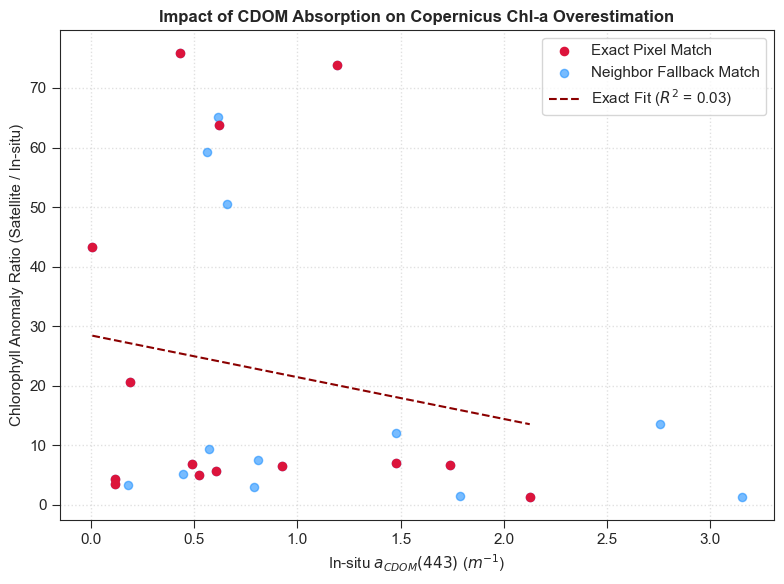

In [128]:
import numpy as np
import pandas as pd
from scipy.stats import linregress
import matplotlib.pyplot as plt

# 1. Filter out rows with missing data for CDOM and the anomaly columns
subset_exact = water_samples_Rrs.dropna(subset=['CDOM_a443_m-1', 'Chl_anomaly'])
subset_adj = water_samples_Rrs.dropna(subset=['CDOM_a443_m-1', 'Chl_anomaly_adj'])

# 2. Compute regressions to quantify the relationship
slope, intercept, r_val, p_val, _ = linregress(subset_exact['CDOM_a443_m-1'], subset_exact['Chl_anomaly'])
slope_adj, intercept_adj, r_val_adj, p_val_adj, _ = linregress(subset_adj['CDOM_a443_m-1'], subset_adj['Chl_anomaly_adj'])

print(f"Exact Match Anomaly vs $a_{{CDOM}}(443)$: R² = {r_val**2:.4f} (p = {p_val:.4e})")
print(f"Adjusted Match Anomaly vs $a_{{CDOM}}(443)$: R² = {r_val_adj**2:.4f} (p = {p_val_adj:.4e})")

# 3. Plot the relationship for your thesis figures
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(subset_exact['CDOM_a443_m-1'], subset_exact['Chl_anomaly'],
           color='crimson', label='Exact Pixel Match', s=35, zorder=3)
ax.scatter(subset_adj['CDOM_a443_m-1'], subset_adj['Chl_anomaly_adj'],
           color='dodgerblue', alpha=0.6, label='Neighbor Fallback Match', s=35, zorder=2)

# Regression line for exact matches
x_line = np.linspace(subset_exact['CDOM_a443_m-1'].min(), subset_exact['CDOM_a443_m-1'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, color='darkred', linestyle='--', linewidth=1.5,
        label=f'Exact Fit ($R^2$ = {r_val**2:.2f})')

ax.set_xlabel(r"In-situ $a_{CDOM}(443)$ ($m^{-1}$)", fontsize=11)
ax.set_ylabel(r"Chlorophyll Anomaly Ratio (Satellite / In-situ)", fontsize=11)
ax.set_title("Impact of CDOM Absorption on Copernicus Chl-a Overestimation", fontsize=12, fontweight="bold")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(frameon=True)

plt.tight_layout()
plt.show()

### Doing the same thing but with the CDOM data

<xarray.Dataset> Size: 2MB
Dimensions:    (time: 61, latitude: 72, longitude: 120)
Coordinates:
  * time       (time) datetime64[ns] 488B 2026-04-01 2026-04-02 ... 2026-05-31
  * latitude   (latitude) float32 288B 52.76 52.77 52.78 ... 53.47 53.48 53.49
  * longitude  (longitude) float32 480B -9.995 -9.984 -9.974 ... -8.766 -8.755
Data variables:
    CDM        (time, latitude, longitude) float32 2MB dask.array<chunksize=(61, 72, 120), meta=np.ndarray>
Attributes:
    comment:                   average
    Conventions:               CF-1.8, ACDD-1.3
    title:                     cmems_obs-oc_atl_bgc-optics_my_l3-multi-1km_P1D
    source:                    surface observation
    references:                http://www.globcolour.info GlobColour has been...
    institution:               ACRI
    contact:                   servicedesk.cmems@acri-st.fr
    history:                   Created using software developed at ACRI-ST
    copernicusmarine_version:  2.2.2

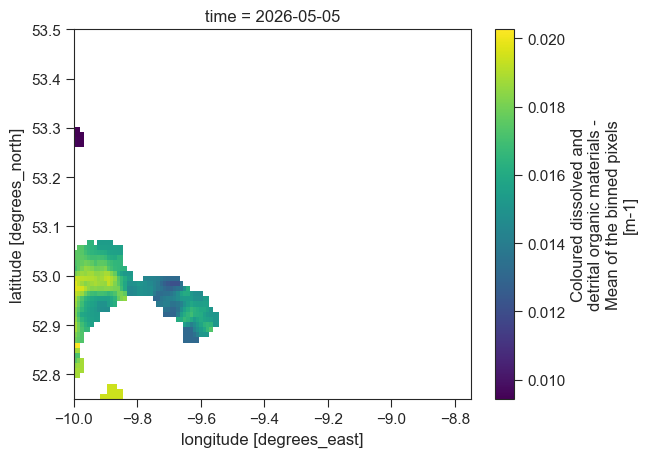

In [129]:
cdom_insitu_file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/in-situ/CDM/*.nc'))
cdom_is = xr.open_mfdataset(cdom_insitu_file_list, concat_dim='time', combine='nested')
display(cdom_is)
cdom_is['CDM'].sel(time='2026-5-5').plot(x='longitude', y='latitude')  #, vmin=0, vmax=200)

In [130]:
import numpy as np
import pandas as pd
import xarray as xr

# 1. Ensure the Date column in your dataframe is in datetime format
water_samples_Rrs['Date'] = pd.to_datetime(water_samples_Rrs['Date'])

# 2. Convert dataframe columns into Xarray DataArrays for fast, vectorized indexing
lats = xr.DataArray(water_samples_Rrs['Latitude'].values, dims="sample")
lons = xr.DataArray(water_samples_Rrs['Longitude'].values, dims="sample")
times = xr.DataArray(water_samples_Rrs['Date'].values, dims="sample")

# 3. Extract the CHL values matching each specific date, latitude, and longitude
matched_chl = cdom_is['CDM'].sel(
    latitude=lats,
    longitude=lons,
    time=times,
    method='nearest'
)

# 4. Add the extracted satellite Chl-a values directly back into your dataframe
water_samples_Rrs['CDM_copernicus'] = matched_chl.values

print(
    f"Successfully matched CDOM for {water_samples_Rrs['CDM_copernicus'].notna().sum()} out of {len(water_samples_Rrs)} rows!")
water_samples_Rrs[["Site", "Date", "CDOM_a443_m-1", "CDM_copernicus"]]

Successfully matched CDOM for 5 out of 34 rows!


,Site,Date,CDOM_a443_m-1,CDM_copernicus
0,ISO-01,2026-04-28,3.2217,NaN
1,ISO-02,2026-04-28,3.1513,NaN
2,ISO-03,2026-04-28,1.7883,NaN
3,ISO-04,2026-04-28,2.1257,0.020737
4,ISO-05,2026-04-29,0.4474,NaN
5,ISO-06,2026-04-29,0.4885,0.232169
6,ISO-07,2026-04-29,0.6069,0.238565
7,ISO-08A,2026-04-28,5.4946,NaN
8,ISO-08B,2026-04-28,2.7564,NaN
9,ISO-09,2026-04-28,1.4804,NaN


In [131]:
water_samples_Rrs

,Site,CDOM_a412_m-1,CDOM_a434_m-1,CDOM_a443_m-1,CDOM_a490_m-1,Chl_a_[ug/L],Chl_b_[ug/L],Chl_c_[ug/L],Date,Latitude,...,Rrs_conv_ratio_412_560,CHL_copernicus,CHL_copernicus_adj,CHL_selected_pixel_lat,CHL_selected_pixel_lon,CHL_distance_to_selected_pixel_m,CHL_matchup_source,Chl_anomaly,Chl_anomaly_adj,CDM_copernicus
0,ISO-01,5.6681,3.7328,3.2217,1.6826,3.041240,-0.023840,0.732600,2026-04-28,53.263103,...,0.148490,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ISO-02,5.2462,3.6482,3.1513,1.4342,3.248234,0.019364,0.684792,2026-04-28,53.260653,...,0.167979,NaN,4.091745,53.247223,-9.036107,1493.851138,local_fallback,NaN,1.259683,NaN
2,ISO-03,3.5467,2.1829,1.7883,0.6034,2.660049,0.053825,0.475276,2026-04-28,53.250777,...,0.143286,NaN,4.091745,53.247223,-9.036107,398.879667,local_fallback,NaN,1.538222,NaN
3,ISO-04,3.8306,2.5170,2.1257,0.8536,3.216769,0.003157,0.589285,2026-04-28,53.244920,...,0.147839,4.096779,4.096779,53.247223,-9.041662,255.912263,exact,1.273569,1.273569,0.020737
4,ISO-05,1.3899,0.7341,0.4474,0.0350,14.443843,-0.190331,5.316073,2026-04-29,53.242783,...,0.298731,NaN,75.539368,53.247223,-8.980552,698.257583,local_fallback,NaN,5.229866,NaN
5,ISO-06,1.4635,0.7004,0.4885,0.0217,13.028986,-0.226679,4.731097,2026-04-29,53.242865,...,0.496207,89.036270,89.036270,53.241665,-8.986107,222.523468,exact,6.833707,6.833707,0.232169
6,ISO-07,1.3605,0.7114,0.6069,0.0887,7.048044,-1.133704,0.551598,2026-04-29,53.242872,...,0.452569,39.573650,39.573650,53.241665,-8.997218,137.219832,exact,5.614841,5.614841,0.238565
7,ISO-08A,9.4658,6.3757,5.4946,2.8589,3.327007,-0.048250,0.357905,2026-04-28,53.141730,...,0.222611,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,ISO-08B,4.7905,3.0862,2.7564,1.4988,4.086672,0.245169,0.498590,2026-04-28,53.158338,...,0.114316,NaN,55.633991,53.163887,-8.947218,621.723027,local_fallback,NaN,13.613520,NaN
9,ISO-09,2.5603,1.7749,1.4804,0.9081,4.624154,0.203794,0.639475,2026-04-28,53.167728,...,0.187007,NaN,55.643433,53.163887,-8.952774,463.024320,local_fallback,NaN,12.033213,NaN


C:\Users\25298423\AppData\Local\Temp\ipykernel_14932\23529381.py:50: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\25298423\PycharmProjects\JupyterProject1\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


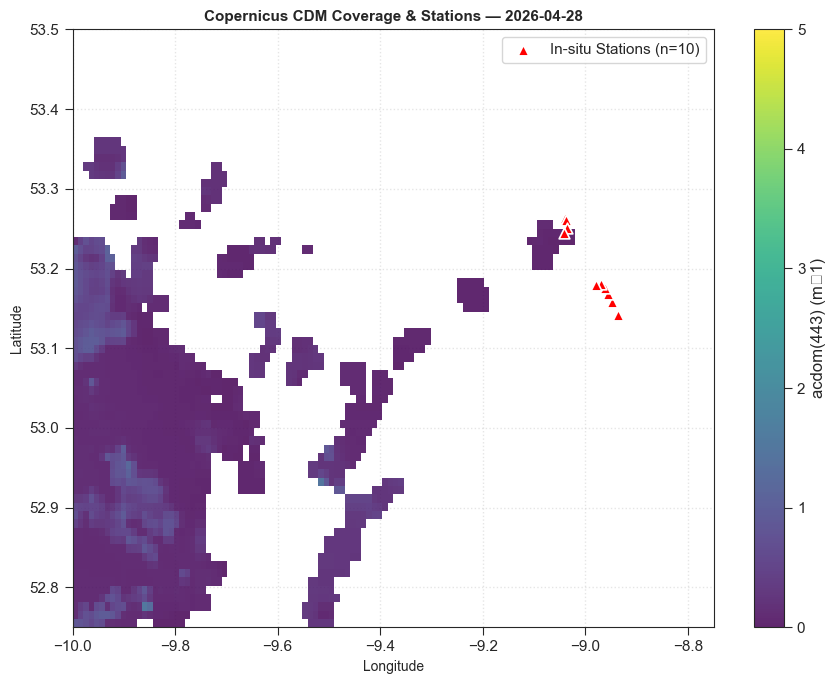

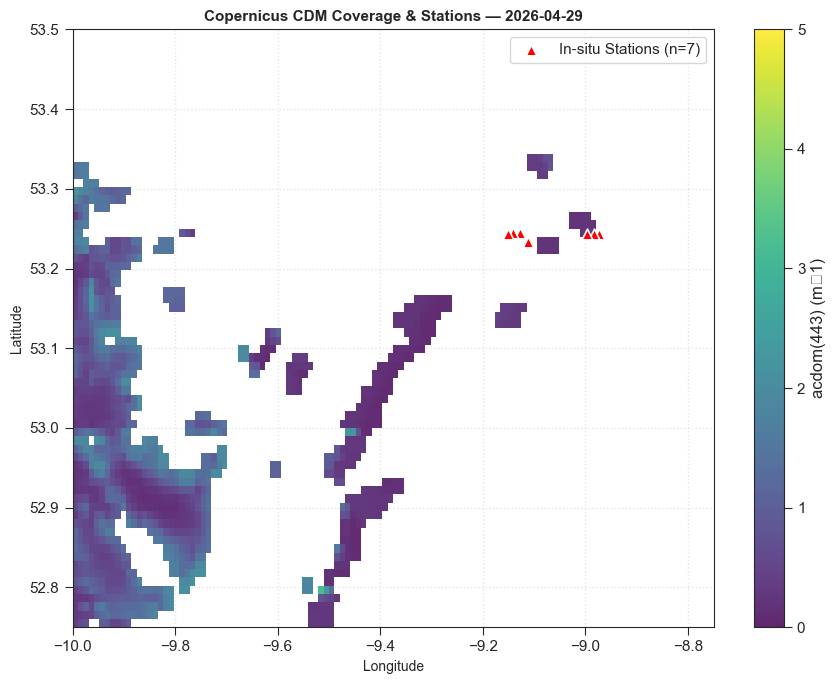

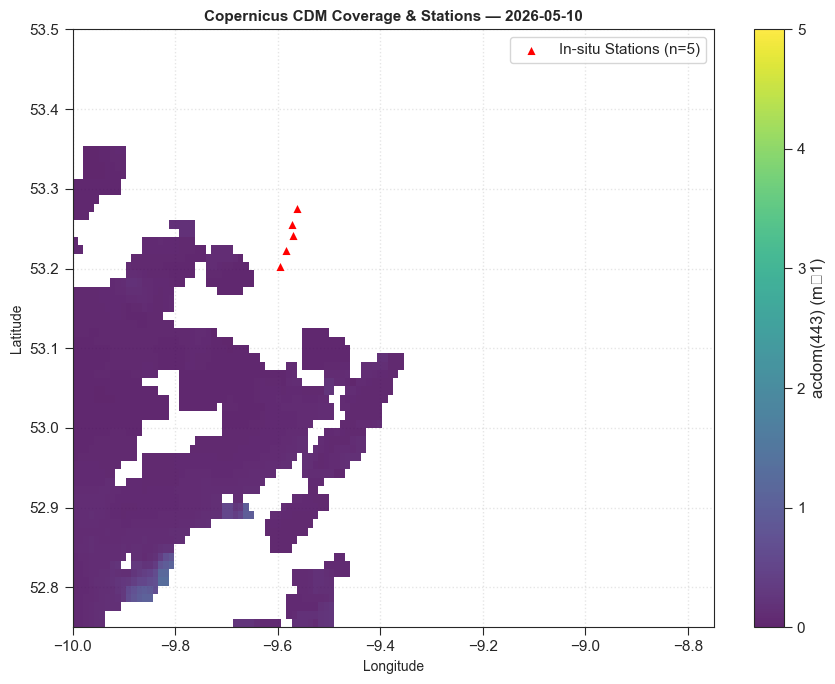

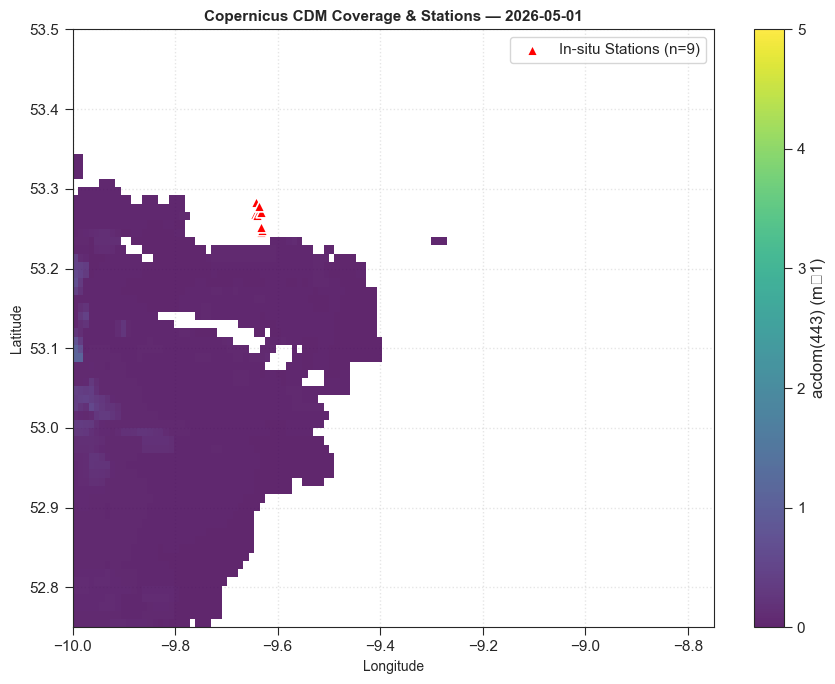

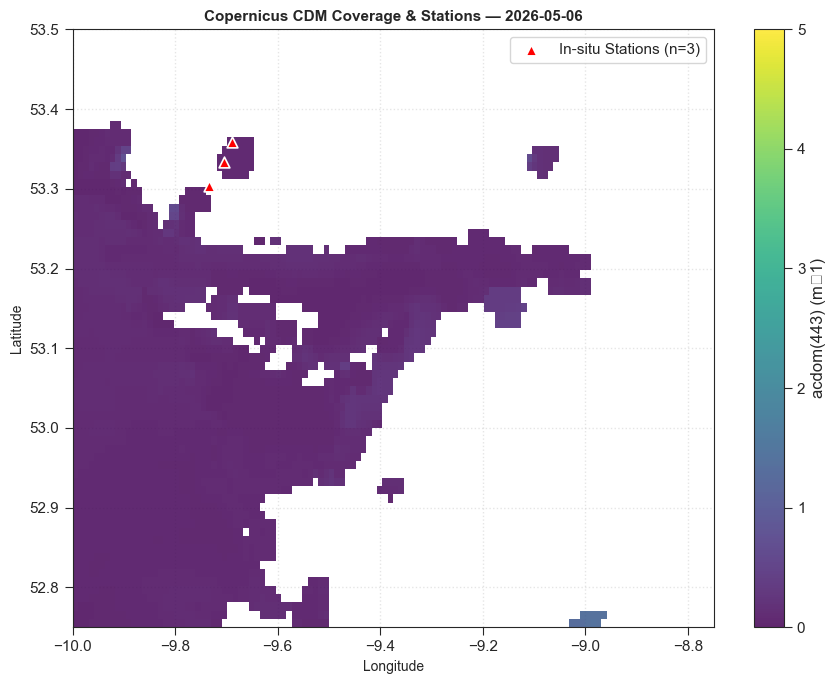

In [132]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

# 1. Ensure Date is in datetime format and get unique dates from your in-situ data
water_samples_Rrs['Date'] = pd.to_datetime(water_samples_Rrs['Date'])
unique_dates = water_samples_Rrs['Date'].dt.date.unique()

# 2. Loop through each date to plot Copernicus CHL grid coverage with station overlays
for date_val in unique_dates:
    # Filter stations active on this specific date
    day_stations = water_samples_Rrs[water_samples_Rrs['Date'].dt.date == date_val]

    try:
        # Extract Copernicus CHL spatial grid for this date (using nearest time match)
        cdom_day = cdom_is['CDM'].sel(time=str(date_val), method='nearest')

        fig, ax = plt.subplots(figsize=(9, 7))

        # Plot the 1km x 1km Copernicus CHL spatial field
        im = cdom_day.plot(
            ax=ax,
            cmap='viridis',
            vmin=0,
            vmax=5,
            add_colorbar=True,
            cbar_kwargs={'label': 'acdom(443) (m⁻1)'},
            alpha=0.85
        )

        # Overlay the in-situ station locations for this day
        ax.scatter(
            day_stations['Longitude'],
            day_stations['Latitude'],
            color='red',
            marker='^',
            s=60,
            edgecolor='white',
            linewidth=1.2,
            label=f'In-situ Stations (n={len(day_stations)})'
        )

        ax.set_title(f"Copernicus CDM Coverage & Stations — {date_val}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Longitude", fontsize=10)
        ax.set_ylabel("Latitude", fontsize=10)
        ax.legend(loc='upper right', frameon=True)
        ax.grid(True, linestyle=":", alpha=0.5)

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Could not plot date {date_val}: {e}")

In [133]:

import numpy as np
import pandas as pd
import xarray as xr

# 1. Ensure Date is in datetime format and initialize output columns
water_samples_Rrs['Date'] = pd.to_datetime(water_samples_Rrs['Date'])
water_samples_Rrs['CDM_copernicus'] = np.nan
water_samples_Rrs['CDM_copernicus_adj'] = np.nan

lat_vals = cdom_is['latitude'].values
lon_vals = cdom_is['longitude'].values

# 2. Loop through each station matchup
for idx, row in water_samples_Rrs.iterrows():
    target_date = row['Date']
    t_lat = row['Latitude']
    t_lon = row['Longitude']

    try:
        # Select the Copernicus CDM slice for this specific date using nearest time
        cdom_slice = cdom_is['CDM'].sel(time=target_date, method='nearest')

        # Find index of the exact nearest grid cell
        lat_idx = np.abs(lat_vals - t_lat).argmin()
        lon_idx = np.abs(lon_vals - t_lon).argmin()

        # Exact pixel match (extracting safely as a scalar float)
        exact_val = cdom_slice.isel(latitude=lat_idx, longitude=lon_idx).values.item()

        if exact_val is not None and not np.isnan(exact_val):
            water_samples_Rrs.loc[idx, 'CDM_copernicus'] = exact_val
            water_samples_Rrs.loc[idx, 'CDM_copernicus_adj'] = exact_val
        else:
            # If exact pixel is NaN, search adjacent pixels within a 2km radius (±2 grid cells)
            radius = 2
            lat_start = max(0, lat_idx - radius)
            lat_end = min(len(lat_vals), lat_idx + radius + 1)
            lon_start = max(0, lon_idx - radius)
            lon_end = min(len(lon_vals), lon_idx + radius + 1)

            window = cdom_slice.isel(
                latitude=slice(lat_start, lat_end),
                longitude=slice(lon_start, lon_end)
            )

            window_vals = window.values
            valid_mask = ~np.isnan(window_vals)

            if valid_mask.any():
                sub_lats = lat_vals[lat_start:lat_end]
                sub_lons = lon_vals[lon_start:lon_end]
                sub_lon_grid, sub_lat_grid = np.meshgrid(sub_lons, sub_lats)

                valid_indices = np.where(valid_mask)
                dists = (sub_lat_grid[valid_indices] - t_lat) ** 2 + (sub_lon_grid[valid_indices] - t_lon) ** 2
                closest_idx = np.argmin(dists)

                adj_val = window_vals[valid_indices[0][closest_idx], valid_indices[1][closest_idx]]
                water_samples_Rrs.loc[idx, 'CDM_copernicus_adj'] = adj_val

    except Exception as e:
        print(f"Error at row {idx}: {e}")
        continue

print(
    f"Exact matches (CDM_copernicus): {water_samples_Rrs['CDM_copernicus'].notna().sum()} out of {len(water_samples_Rrs)}")
print(
    f"Matches with adjacency fallback (CDM_copernicus_adj): {water_samples_Rrs['CDM_copernicus_adj'].notna().sum()} out of {len(water_samples_Rrs)}")

Exact matches (CDM_copernicus): 5 out of 34
Matches with adjacency fallback (CDM_copernicus_adj): 14 out of 34


In [134]:
import numpy as np
import pandas as pd


def calculate_distance_m(lat1, lon1, lat2, lon2):
    """
    Approximate distance between two latitude/longitude points in metres.
    """
    meters_per_degree_lat = 111120.0
    meters_per_degree_lon = (
            111120.0 * np.cos(np.radians(lat1))
    )

    delta_lat = lat2 - lat1
    delta_lon = lon2 - lon1

    return np.sqrt(
        (delta_lat * meters_per_degree_lat) ** 2
        + (delta_lon * meters_per_degree_lon) ** 2
    )


# Ensure station dates are datetime values
water_samples_Rrs["Date"] = pd.to_datetime(
    water_samples_Rrs["Date"]
)

# Initialise CDM-specific output columns
water_samples_Rrs["CDM_copernicus"] = np.nan
water_samples_Rrs["CDM_copernicus_adj"] = np.nan
water_samples_Rrs["CDM_selected_pixel_lat"] = np.nan
water_samples_Rrs["CDM_selected_pixel_lon"] = np.nan
water_samples_Rrs[
    "CDM_distance_to_selected_pixel_m"
] = np.nan
water_samples_Rrs["CDM_matchup_source"] = np.nan

# Satellite coordinate arrays
lat_vals = cdom_is["latitude"].values
lon_vals = cdom_is["longitude"].values

# Convert satellite times to calendar dates
satellite_days = pd.to_datetime(
    cdom_is["time"].values
).normalize()

# Local search radius in grid-cell indices
radius_cells = 2

for idx, row in water_samples_Rrs.iterrows():

    target_day = pd.Timestamp(
        row["Date"]
    ).normalize()

    target_lat = row["Latitude"]
    target_lon = row["Longitude"]

    try:
        # Select only an exact calendar-day match
        matching_times = np.where(
            satellite_days == target_day
        )[0]

        if len(matching_times) == 0:
            continue

        # Use the first satellite slice for that calendar day
        cdm_slice = cdom_is["CDM"].isel(
            time=matching_times[0]
        )

        # Find the nearest satellite grid cell
        lat_idx = np.abs(
            lat_vals - target_lat
        ).argmin()

        lon_idx = np.abs(
            lon_vals - target_lon
        ).argmin()

        exact_lat = float(
            lat_vals[lat_idx]
        )

        exact_lon = float(
            lon_vals[lon_idx]
        )

        exact_value = float(
            np.asarray(
                cdm_slice.isel(
                    latitude=lat_idx,
                    longitude=lon_idx
                ).values
            ).squeeze()
        )

        exact_distance_m = calculate_distance_m(
            target_lat,
            target_lon,
            exact_lat,
            exact_lon
        )

        # Exact pixel is valid
        if np.isfinite(exact_value):

            water_samples_Rrs.loc[
                idx,
                "CDM_copernicus"
            ] = exact_value

            # Best-available column uses exact pixel
            water_samples_Rrs.loc[
                idx,
                "CDM_copernicus_adj"
            ] = exact_value

            water_samples_Rrs.loc[
                idx,
                "CDM_selected_pixel_lat"
            ] = exact_lat

            water_samples_Rrs.loc[
                idx,
                "CDM_selected_pixel_lon"
            ] = exact_lon

            water_samples_Rrs.loc[
                idx,
                "CDM_distance_to_selected_pixel_m"
            ] = exact_distance_m

            water_samples_Rrs.loc[
                idx,
                "CDM_matchup_source"
            ] = "exact"

        # Exact pixel is missing, so search locally
        else:

            lat_start = max(
                0,
                lat_idx - radius_cells
            )

            lat_end = min(
                len(lat_vals),
                lat_idx + radius_cells + 1
            )

            lon_start = max(
                0,
                lon_idx - radius_cells
            )

            lon_end = min(
                len(lon_vals),
                lon_idx + radius_cells + 1
            )

            window = cdm_slice.isel(
                latitude=slice(lat_start, lat_end),
                longitude=slice(lon_start, lon_end)
            )

            window_vals = np.asarray(
                window.values
            )

            valid_mask = np.isfinite(
                window_vals
            )

            if not valid_mask.any():
                continue

            sub_lats = lat_vals[
                lat_start:lat_end
            ]

            sub_lons = lon_vals[
                lon_start:lon_end
            ]

            sub_lon_grid, sub_lat_grid = np.meshgrid(
                sub_lons,
                sub_lats
            )

            valid_indices = np.where(
                valid_mask
            )

            candidate_lats = sub_lat_grid[
                valid_indices
            ]

            candidate_lons = sub_lon_grid[
                valid_indices
            ]

            candidate_values = window_vals[
                valid_indices
            ]

            candidate_distances_m = np.array([
                calculate_distance_m(
                    target_lat,
                    target_lon,
                    candidate_lat,
                    candidate_lon
                )
                for candidate_lat, candidate_lon
                in zip(
                    candidate_lats,
                    candidate_lons
                )
            ])

            closest_idx = np.argmin(
                candidate_distances_m
            )

            adjacent_value = float(
                candidate_values[closest_idx]
            )

            selected_lat = float(
                candidate_lats[closest_idx]
            )

            selected_lon = float(
                candidate_lons[closest_idx]
            )

            selected_distance_m = float(
                candidate_distances_m[closest_idx]
            )

            # Exact column remains NaN
            water_samples_Rrs.loc[
                idx,
                "CDM_copernicus_adj"
            ] = adjacent_value

            water_samples_Rrs.loc[
                idx,
                "CDM_selected_pixel_lat"
            ] = selected_lat

            water_samples_Rrs.loc[
                idx,
                "CDM_selected_pixel_lon"
            ] = selected_lon

            water_samples_Rrs.loc[
                idx,
                "CDM_distance_to_selected_pixel_m"
            ] = selected_distance_m

            water_samples_Rrs.loc[
                idx,
                "CDM_matchup_source"
            ] = "local_fallback"

    except Exception as error:
        print(
            f"Error at row {idx}: {error}"
        )

# Summary
print(
    "Exact CDM matches:",
    water_samples_Rrs[
        "CDM_copernicus"
    ].notna().sum()
)

print(
    "Exact plus local fallback CDM matches:",
    water_samples_Rrs[
        "CDM_copernicus_adj"
    ].notna().sum()
)

print(
    water_samples_Rrs[
        [
            "Site",
            "CDM_copernicus",
            "CDM_copernicus_adj",
            "CDM_selected_pixel_lat",
            "CDM_selected_pixel_lon",
            "CDM_distance_to_selected_pixel_m",
            "CDM_matchup_source"
        ]
    ].head()
)


Exact CDM matches: 5
Exact plus local fallback CDM matches: 14
     Site  CDM_copernicus  CDM_copernicus_adj  CDM_selected_pixel_lat  \
0  ISO-01             NaN            0.020737               53.244793   
1  ISO-02             NaN            0.020737               53.244793   
2  ISO-03             NaN            0.020737               53.244793   
3  ISO-04        0.020737            0.020737               53.244793   
4  ISO-05             NaN            0.232169               53.244793   

   CDM_selected_pixel_lon  CDM_distance_to_selected_pixel_m CDM_matchup_source  
0               -9.036457                       2044.961941     local_fallback  
1               -9.036457                       1762.983512     local_fallback  
2               -9.036457                        665.840259     local_fallback  
3               -9.036457                        343.726079              exact  
4               -8.984374                        780.886224     local_fallback  


C:\Users\25298423\AppData\Local\Temp\ipykernel_14932\3914834132.py:263: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'local_fallback' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  water_samples_Rrs.loc[


In [135]:
water_samples_Rrs

,Site,CDOM_a412_m-1,CDOM_a434_m-1,CDOM_a443_m-1,CDOM_a490_m-1,Chl_a_[ug/L],Chl_b_[ug/L],Chl_c_[ug/L],Date,Latitude,...,CHL_distance_to_selected_pixel_m,CHL_matchup_source,Chl_anomaly,Chl_anomaly_adj,CDM_copernicus,CDM_copernicus_adj,CDM_selected_pixel_lat,CDM_selected_pixel_lon,CDM_distance_to_selected_pixel_m,CDM_matchup_source
0,ISO-01,5.6681,3.7328,3.2217,1.6826,3.041240,-0.023840,0.732600,2026-04-28,53.263103,...,NaN,NaN,NaN,NaN,NaN,0.020737,53.244793,-9.036457,2044.961941,local_fallback
1,ISO-02,5.2462,3.6482,3.1513,1.4342,3.248234,0.019364,0.684792,2026-04-28,53.260653,...,1493.851138,local_fallback,NaN,1.259683,NaN,0.020737,53.244793,-9.036457,1762.983512,local_fallback
2,ISO-03,3.5467,2.1829,1.7883,0.6034,2.660049,0.053825,0.475276,2026-04-28,53.250777,...,398.879667,local_fallback,NaN,1.538222,NaN,0.020737,53.244793,-9.036457,665.840259,local_fallback
3,ISO-04,3.8306,2.5170,2.1257,0.8536,3.216769,0.003157,0.589285,2026-04-28,53.244920,...,255.912263,exact,1.273569,1.273569,0.020737,0.020737,53.244793,-9.036457,343.726079,exact
4,ISO-05,1.3899,0.7341,0.4474,0.0350,14.443843,-0.190331,5.316073,2026-04-29,53.242783,...,698.257583,local_fallback,NaN,5.229866,NaN,0.232169,53.244793,-8.984374,780.886224,local_fallback
5,ISO-06,1.4635,0.7004,0.4885,0.0217,13.028986,-0.226679,4.731097,2026-04-29,53.242865,...,222.523468,exact,6.833707,6.833707,0.232169,0.232169,53.244793,-8.984374,223.278135,exact
6,ISO-07,1.3605,0.7114,0.6069,0.0887,7.048044,-1.133704,0.551598,2026-04-29,53.242872,...,137.219832,exact,5.614841,5.614841,0.238565,0.238565,53.244793,-8.994791,251.214021,exact
7,ISO-08A,9.4658,6.3757,5.4946,2.8589,3.327007,-0.048250,0.357905,2026-04-28,53.141730,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,ISO-08B,4.7905,3.0862,2.7564,1.4988,4.086672,0.245169,0.498590,2026-04-28,53.158338,...,621.723027,local_fallback,NaN,13.613520,NaN,NaN,NaN,NaN,NaN,NaN
9,ISO-09,2.5603,1.7749,1.4804,0.9081,4.624154,0.203794,0.639475,2026-04-28,53.167728,...,463.024320,local_fallback,NaN,12.033213,NaN,NaN,NaN,NaN,NaN,NaN


In [136]:
water_samples_Rrs[['Site', 'Date', 'Latitude', 'Longitude', 'CDOM_a443_m-1', 'CDM_copernicus', 'CDM_copernicus_adj']]

,Site,Date,Latitude,Longitude,CDOM_a443_m-1,CDM_copernicus,CDM_copernicus_adj
0,ISO-01,2026-04-28,53.263103,-9.039540,3.2217,NaN,0.020737
1,ISO-02,2026-04-28,53.260653,-9.037058,3.1513,NaN,0.020737
2,ISO-03,2026-04-28,53.250777,-9.036935,1.7883,NaN,0.020737
3,ISO-04,2026-04-28,53.244920,-9.041622,2.1257,0.020737,0.020737
4,ISO-05,2026-04-29,53.242783,-8.973122,0.4474,NaN,0.232169
5,ISO-06,2026-04-29,53.242865,-8.983428,0.4885,0.232169,0.232169
6,ISO-07,2026-04-29,53.242872,-8.996783,0.6069,0.238565,0.238565
7,ISO-08A,2026-04-28,53.141730,-8.936175,5.4946,NaN,NaN
8,ISO-08B,2026-04-28,53.158338,-8.948395,2.7564,NaN,NaN
9,ISO-09,2026-04-28,53.167728,-8.955467,1.4804,NaN,NaN


In [137]:
water_samples_Rrs["CDM_anomaly"] = water_samples_Rrs['CDM_copernicus'] / water_samples_Rrs['CDOM_a443_m-1']
water_samples_Rrs["CDM_anomaly_adj"] = water_samples_Rrs['CDM_copernicus_adj'] / water_samples_Rrs['CDOM_a443_m-1']


# Statistics for both CHL and CDM Copernicus to In-Situ Measurements

In [138]:
cop_compare = water_samples_Rrs[['Site','Date','Latitude','Longitude','Chl_a_[ug/L]','CHL_copernicus','CHL_copernicus_adj','CDOM_a443_m-1','CDM_copernicus','CDM_copernicus_adj']]

In [139]:
cop_compare[~(cop_compare['CHL_copernicus'].isna())]

,Site,Date,Latitude,Longitude,Chl_a_[ug/L],CHL_copernicus,CHL_copernicus_adj,CDOM_a443_m-1,CDM_copernicus,CDM_copernicus_adj
3,ISO-04,2026-04-28,53.244920,-9.041622,3.216769,4.096779,4.096779,2.1257,0.020737,0.020737
5,ISO-06,2026-04-29,53.242865,-8.983428,13.028986,89.036270,89.036270,0.4885,0.232169,0.232169
6,ISO-07,2026-04-29,53.242872,-8.996783,7.048044,39.573650,39.573650,0.6069,0.238565,0.238565
11,ISO-11,2026-04-28,53.180213,-8.970387,5.670156,39.858913,39.858913,1.4782,NaN,NaN
12,ISO-12,2026-04-28,53.179393,-8.979265,6.121353,41.342110,41.342110,1.7371,NaN,NaN
14,ISO-14,2026-04-29,53.244955,-9.140852,5.114190,33.432777,33.432777,0.9243,NaN,NaN
16,ISO-16,2026-05-10,53.276242,-9.562655,1.561965,32.174744,32.174744,0.1900,NaN,NaN
21,ISO-21,2026-05-01,53.252010,-9.633478,3.694152,12.835410,12.835410,0.1190,NaN,0.027371
24,ISO-24,2026-05-01,53.267222,-9.640902,2.032541,154.329483,154.329483,0.4332,NaN,NaN
25,ISO-25,2026-05-01,53.270480,-9.631842,2.081076,10.249057,10.249057,0.5260,NaN,NaN


In [140]:
print(', '.join(cop_compare[~(cop_compare['CHL_copernicus'].isna())]['Site'].tolist()))

ISO-04, ISO-06, ISO-07, ISO-11, ISO-12, ISO-14, ISO-16, ISO-21, ISO-24, ISO-25, ISO-27, ISO-28, ISO-29, ISO-30


In [141]:
### This one includes log-slope and log-intercept, use some of it for the final
import numpy as np
import pandas as pd
from scipy.stats import linregress, spearmanr, wilcoxon

# 1. Select required columns
required_cols = [
    "Chl_a_[ug/L]",
    "CHL_copernicus"
]

df_val = (
    water_samples_Rrs[required_cols]
    .dropna()
    .copy()
)

# 2. Keep only physically valid positive values
valid_mask = (
    np.isfinite(df_val["Chl_a_[ug/L]"])
    & np.isfinite(df_val["CHL_copernicus"])
    & (df_val["Chl_a_[ug/L]"] > 0)
    & (df_val["CHL_copernicus"] > 0)
)

df_val = df_val.loc[valid_mask].copy()

x = df_val["Chl_a_[ug/L]"].to_numpy(dtype=float)
y = df_val["CHL_copernicus"].to_numpy(dtype=float)

n = len(df_val)

if n < 3:
    raise ValueError(
        f"Only {n} valid matchups remain. At least 3 are required."
    )

# 3. Log10 transformation
log_x = np.log10(x)
log_y = np.log10(y)

# 4. Log-scale regression
# x = in-situ Chl-a
# y = Copernicus Chl-a
slope, intercept, r_value, p_value, std_error = (
    linregress(log_x, log_y)
)

# This is the regression R2, equivalent to r_value squared
r2_log_regression = r_value ** 2

# Fitted log-scale predictions
log_y_fitted = intercept + slope * log_x

# Optional predictive R2 on the log scale
ss_res_log = np.sum(
    (log_y - log_y_fitted) ** 2
)

ss_tot_log = np.sum(
    (log_y - np.mean(log_y)) ** 2
)

r2_log_predictive = (
    1 - ss_res_log / ss_tot_log
)

# 5. Spearman correlation
spearman_corr, spearman_p = spearmanr(
    x,
    y
)

# 6. Original-scale RMSD
rmsd = np.sqrt(
    np.mean((y - x) ** 2)
)

# 7. Log-RMSE
log_rmse = np.sqrt(
    np.mean((log_y - log_x) ** 2)
)

# 8. Percentage differences
percentage_differences = (
    (y - x) / x
) * 100

mdpd = np.median(
    percentage_differences
)

mdapd = np.median(
    np.abs(percentage_differences)
)

# 9. Log bias
log_differences = log_y - log_x

median_log_bias = np.median(
    log_differences
)

mean_log_bias = np.mean(
    log_differences
)

# Multiplicative bias converted back to percentage
median_multiplicative_bias = (
    (10 ** median_log_bias) - 1
) * 100

# Multiplicative error associated with log-RMSE
typical_multiplicative_error = (
    (10 ** log_rmse) - 1
) * 100

# 10. Paired Wilcoxon test on log differences
if np.allclose(log_differences, 0):
    wilcoxon_stat = 0
    wilcoxon_p = 1.0
else:
    wilcoxon_stat, wilcoxon_p = wilcoxon(
        log_differences,
        zero_method="wilcox",
        alternative="two-sided",
        method="auto"
    )

# 11. Report
print("==========================================")
print("       COPERNICUS CHL-a VALIDATION        ")
print("==========================================")
print(f"Valid matchups (N)              : {n}")
print()
print(f"Log regression slope            : {slope:.4f}")
print(f"Log regression intercept        : {intercept:.4f}")
print(f"Log regression R²               : {r2_log_regression:.4f}")
print(f"Log predictive R²               : {r2_log_predictive:.4f}")
print()
print(
    f"Spearman correlation            : "
    f"{spearman_corr:.4f} "
    f"(p = {spearman_p:.4e})"
)
print()
print(
    f"RMSD                            : "
    f"{rmsd:.4f} in the original Chl-a units"
)
print(f"Log-RMSE                        : {log_rmse:.4f}")
print(
    f"Typical multiplicative error    : "
    f"{typical_multiplicative_error:.2f}%"
)
print()
print(f"MdPD                            : {mdpd:.2f}%")
print(f"MdAPD                           : {mdapd:.2f}%")
print(f"Median log bias                 : {median_log_bias:.4f}")
print(
    f"Median multiplicative bias      : "
    f"{median_multiplicative_bias:.2f}%"
)
print(f"Mean log bias                   : {mean_log_bias:.4f}")
print()
print(
    f"Wilcoxon statistic              : "
    f"{wilcoxon_stat}"
)
print(
    f"Wilcoxon p-value                : "
    f"{wilcoxon_p:.4e}"
)
print("==========================================")


       COPERNICUS CHL-a VALIDATION        
Valid matchups (N)              : 14

Log regression slope            : 0.1128
Log regression intercept        : 1.3995
Log regression R²               : 0.0146
Log predictive R²               : 0.0146

Spearman correlation            : 0.3802 (p = 1.7991e-01)

RMSD                            : 51.8227 in the original Chl-a units
Log-RMSE                        : 1.1714
Typical multiplicative error    : 1383.83%

MdPD                            : 579.37%
MdAPD                           : 579.37%
Median log bias                 : 0.8321
Median multiplicative bias      : 579.36%
Mean log bias                   : 1.0399

Wilcoxon statistic              : 0.0
Wilcoxon p-value                : 1.2207e-04


In [142]:
# 11. Report and Clipboard Export
metrics_summary = pd.DataFrame({
    "Parameter / Metric": [
        "Valid Matchups (N)",
        "Log Regression Slope",
        "Log Regression Intercept",
        "Log Regression R²",
        "Log Predictive R²",
        "Spearman Correlation (rho)",
        "Spearman p-value",
        "RMSD",
        "Log-RMSE",
        "Typical Multiplicative Error (%)",
        "MdPD (%)",
        "MdAPD (%)",
        "Median Log Bias",
        "Median Multiplicative Bias (%)",
        "Wilcoxon Statistic",
        "Wilcoxon p-value"
    ],
    "Value": [
        f"{n}",
        f"{slope:.4f}",
        f"{intercept:.4f}",
        f"{r2_log_regression:.4f}",
        f"{r2_log_predictive:.4f}",
        f"{spearman_corr:.4f}",
        f"{spearman_p:.4e}",
        f"{rmsd:.4f}",
        f"{log_rmse:.4f}",
        f"{typical_multiplicative_error:.2f}%",
        f"{mdpd:.2f}%",
        f"{mdapd:.2f}%",
        f"{median_log_bias:.4f}",
        f"{median_multiplicative_bias:.2f}%",
        f"{wilcoxon_stat}",
        f"{wilcoxon_p:.4e}"
    ]
})

print("==========================================")
print("        COPERNICUS CHL-a VALIDATION        ")
print("==========================================")
for idx, row in metrics_summary.iterrows():
    print(f"{row['Parameter / Metric']:<32} : {row['Value']}")
print("==========================================")

# Copy straight to clipboard for Word/Excel
metrics_summary.to_clipboard(excel=True, index=False)
print("\nValidation metrics table successfully copied to clipboard!")

        COPERNICUS CHL-a VALIDATION        
Valid Matchups (N)               : 14
Log Regression Slope             : 0.1128
Log Regression Intercept         : 1.3995
Log Regression R²                : 0.0146
Log Predictive R²                : 0.0146
Spearman Correlation (rho)       : 0.3802
Spearman p-value                 : 1.7991e-01
RMSD                             : 51.8227
Log-RMSE                         : 1.1714
Typical Multiplicative Error (%) : 1383.83%
MdPD (%)                         : 579.37%
MdAPD (%)                        : 579.37%
Median Log Bias                  : 0.8321
Median Multiplicative Bias (%)   : 579.36%
Wilcoxon Statistic               : 0.0
Wilcoxon p-value                 : 1.2207e-04

Validation metrics table successfully copied to clipboard!


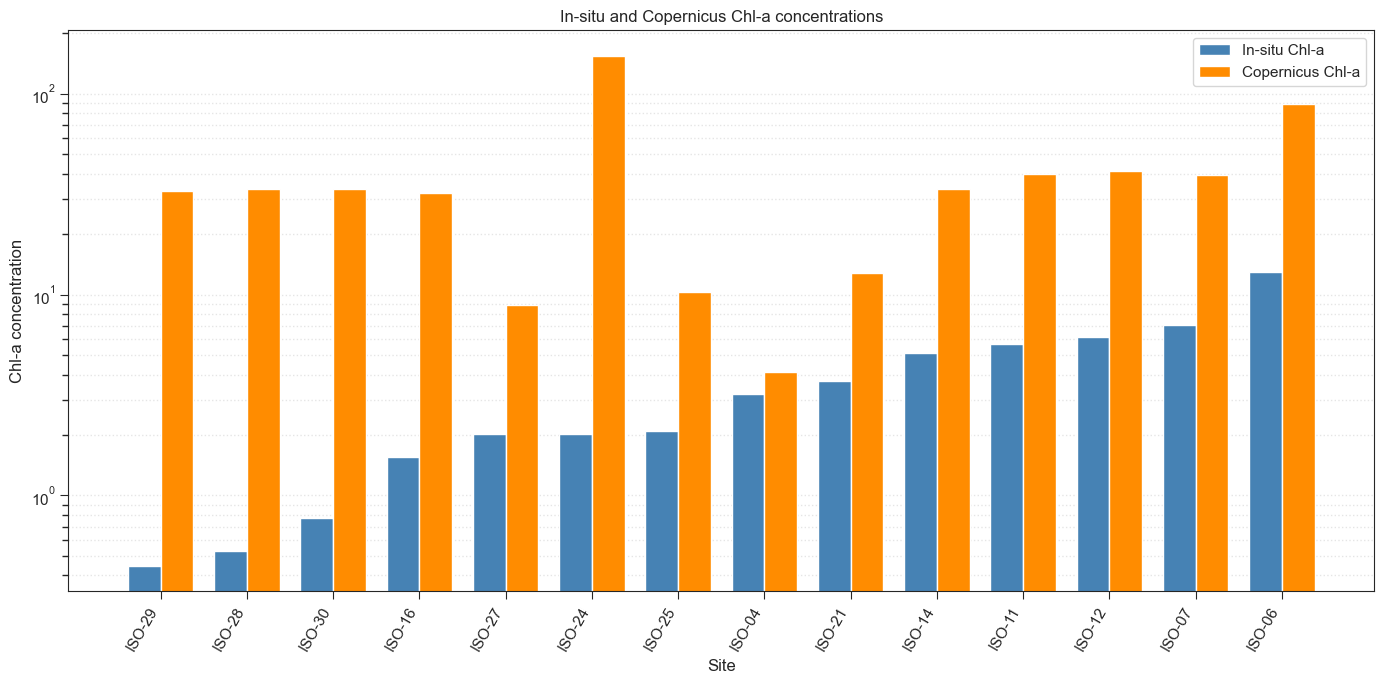

In [143]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Select exact-pixel Copernicus Chl-a comparison
plot_df = water_samples_Rrs[
    [
        "Site",
        "Chl_a_[ug/L]",
        "CHL_copernicus"
    ]
].dropna().copy()

# Keep only positive values for the log-scale plot
plot_df = plot_df[
    (plot_df["Chl_a_[ug/L]"] > 0)
    & (plot_df["CHL_copernicus"] > 0)
].copy()

# Sort sites by in-situ Chl-a
plot_df = plot_df.sort_values(
    "Chl_a_[ug/L]"
).reset_index(drop=True)

x = np.arange(len(plot_df))
width = 0.38

fig, ax = plt.subplots(
    figsize=(14, 7)
)

bars_insitu = ax.bar(
    x - width / 2,
    plot_df["Chl_a_[ug/L]"],
    width,
    label="In-situ Chl-a",
    color="steelblue"
)

bars_satellite = ax.bar(
    x + width / 2,
    plot_df["CHL_copernicus"],
    width,
    label="Copernicus Chl-a",
    color="darkorange"
)

ax.set_yscale("log")

ax.set_xlabel("Site")
ax.set_ylabel("Chl-a concentration")
ax.set_title(
    "In-situ and Copernicus Chl-a concentrations"
)

ax.set_xticks(x)
ax.set_xticklabels(
    plot_df["Site"].astype(str),
    rotation=60,
    ha="right"
)

ax.legend()
ax.grid(
    axis="y",
    which="both",
    linestyle=":",
    alpha=0.5
)

plt.tight_layout()

plt.savefig(
    "in_situ_vs_copernicus_chla_barplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [144]:
import numpy as np
import pandas as pd

from scipy.stats import (
    linregress,
    spearmanr,
    pearsonr,
    wilcoxon
)


def validate_copernicus_product(
    df,
    insitu_col,
    satellite_col,
    qc_cols=None,
    product_name="Copernicus product"
):
    """
    Validates a satellite product against in-situ observations.

    The regression is performed in log10 space.
    The reported slope and intercept use a type-2,
    reduced-major-axis regression calculated from
    two reciprocal OLS regressions.

    x = in-situ observation
    y = satellite estimate
    """

    if qc_cols is None:
        qc_cols = []

    # Include the target, satellite product and required QC variables
    required_cols = list(
        dict.fromkeys(
            [insitu_col, satellite_col]
            + qc_cols
        )
    )

    df_val = (
        df[required_cols]
        .dropna()
        .copy()
    )

    # Require positive, finite values for the main comparison
    valid_mask = (
        np.isfinite(df_val[insitu_col])
        & np.isfinite(df_val[satellite_col])
        & (df_val[insitu_col] > 0)
        & (df_val[satellite_col] > 0)
    )

    # Apply additional quality-control columns
    for col in qc_cols:
        valid_mask &= (
            np.isfinite(df_val[col])
            & (df_val[col] > 0)
        )

    df_val = df_val.loc[
        valid_mask
    ].copy()


    x = df_val[insitu_col].to_numpy(dtype=float)
    y = df_val[satellite_col].to_numpy(dtype=float)

    n = len(df_val)

    if n < 3:
        raise ValueError(
            f"Only {n} valid matchups remain. "
            "At least 3 are required."
        )

    # Log10 transformation
    log_x = np.log10(x)
    log_y = np.log10(y)

    # -------------------------------------------------
    # Type-2 regression
    # -------------------------------------------------

    # OLS: satellite against in-situ
    fit_y_on_x = linregress(
        log_x,
        log_y
    )

    slope_y_on_x = fit_y_on_x.slope

    # OLS: in-situ against satellite
    fit_x_on_y = linregress(
        log_y,
        log_x
    )

    slope_x_on_y = fit_x_on_y.slope

    if slope_y_on_x * slope_x_on_y <= 0:
        raise ValueError(
            "The reciprocal regression slopes do not have "
            "the same sign, so a type-2 slope cannot be calculated."
        )

    # Reduced-major-axis/type-2 slope
    type2_slope = (
        np.sign(slope_y_on_x)
        * np.sqrt(
            slope_y_on_x / slope_x_on_y
        )
    )

    # Type-2 intercept in log10 space
    type2_intercept = (
        np.mean(log_y)
        - type2_slope * np.mean(log_x)
    )

    # Correlation-based R2
    pearson_r, pearson_p = pearsonr(
        log_x,
        log_y
    )

    r2_log = pearson_r ** 2

    # Fitted values from the type-2 line
    log_y_type2 = (
        type2_intercept
        + type2_slope * log_x
    )

    # Predictive R2 relative to the type-2 line
    ss_res_log = np.sum(
        (log_y - log_y_type2) ** 2
    )

    ss_tot_log = np.sum(
        (log_y - np.mean(log_y)) ** 2
    )

    r2_log_type2 = (
        1
        - ss_res_log / ss_tot_log
    )

    # -------------------------------------------------
    # Correlation statistics
    # -------------------------------------------------

    spearman_rho, spearman_p = spearmanr(
        x,
        y
    )

    # -------------------------------------------------
    # Error and bias statistics
    # -------------------------------------------------

    # Original-scale differences
    differences = y - x

    bias_original = np.mean(
        differences
    )

    rmsd_original = np.sqrt(
        np.mean(differences ** 2)
    )

    # Log-scale differences
    log_differences = log_y - log_x

    mean_log_bias = np.mean(
        log_differences
    )

    median_log_bias = np.median(
        log_differences
    )

    rmsd_log = np.sqrt(
        np.mean(log_differences ** 2)
    )

    # Back-transformed multiplicative biases
    mean_multiplicative_bias = (
        (10 ** mean_log_bias) - 1
    ) * 100

    median_multiplicative_bias = (
        (10 ** median_log_bias) - 1
    ) * 100

    # Percentage differences
    percentage_differences = (
        differences / x
    ) * 100

    mdpd = np.median(
        percentage_differences
    )

    mdapd = np.median(
        np.abs(percentage_differences)
    )

    # -------------------------------------------------
    # Paired Wilcoxon test on log differences
    # -------------------------------------------------

    if np.allclose(
        log_differences,
        0
    ):
        wilcoxon_stat = 0
        wilcoxon_p = 1.0
    else:
        wilcoxon_stat, wilcoxon_p = wilcoxon(
            log_differences,
            zero_method="wilcox",
            alternative="two-sided",
            method="auto"
        )

    # -------------------------------------------------
    # Output
    # -------------------------------------------------

    metrics = {
        "Product": product_name,
        "N": n,

        "Type2_Slope_log": type2_slope,
        "Type2_Intercept_log": type2_intercept,

        "Pearson_r_log": pearson_r,
        "Pearson_p_log": pearson_p,
        "R2_log": r2_log,
        "R2_log_type2_line": r2_log_type2,

        "Spearman_Rho": spearman_rho,
        "Spearman_p": spearman_p,

        "Bias_original_units": bias_original,
        "RMSD_original_units": rmsd_original,

        "Mean_Log_Bias": mean_log_bias,
        "Median_Log_Bias": median_log_bias,
        "RMSD_log": rmsd_log,

        "Mean_Multiplicative_Bias_percent":
            mean_multiplicative_bias,

        "Median_Multiplicative_Bias_percent":
            median_multiplicative_bias,

        "MdPD_percent": mdpd,
        "MdAPD_percent": mdapd,

        "Wilcoxon_statistic": wilcoxon_stat,
        "Wilcoxon_p": wilcoxon_p
    }

    print("==========================================")
    print(f"{product_name.upper()} VALIDATION")
    print("==========================================")
    print(f"Valid matchups (N)              : {n}")
    print()
    print(
        f"Type-2 slope, log scale         : "
        f"{type2_slope:.4f}"
    )
    print(
        f"Type-2 intercept, log scale     : "
        f"{type2_intercept:.4f}"
    )
    print(
        f"Log-scale R²                    : "
        f"{r2_log:.4f}"
    )
    print(
        f"Spearman correlation            : "
        f"{spearman_rho:.4f} "
        f"(p = {spearman_p:.4e})"
    )
    print()
    print(
        f"Bias, original units            : "
        f"{bias_original:.4f}"
    )
    print(
        f"RMSD, original units            : "
        f"{rmsd_original:.4f}"
    )
    print(
        f"RMSD, log scale                 : "
        f"{rmsd_log:.4f}"
    )
    print()
    print(
        f"Mean multiplicative bias        : "
        f"{mean_multiplicative_bias:.2f}%"
    )
    print(
        f"Median multiplicative bias      : "
        f"{median_multiplicative_bias:.2f}%"
    )
    print(f"MdPD                            : {mdpd:.2f}%")
    print(f"MdAPD                           : {mdapd:.2f}%")
    print()
    print(
        f"Wilcoxon statistic              : "
        f"{wilcoxon_stat}"
    )
    print(
        f"Wilcoxon p-value                : "
        f"{wilcoxon_p:.4e}"
    )
    print("==========================================")

    return metrics, df_val


In [145]:
chl_exact_metrics, chl_exact_data = (
    validate_copernicus_product(
        df=water_samples_Rrs,
        insitu_col="Chl_a_[ug/L]",
        satellite_col="CHL_copernicus",
        product_name="Copernicus exact-pixel Chl-a"
    )
)


COPERNICUS EXACT-PIXEL CHL-A VALIDATION
Valid matchups (N)              : 14

Type-2 slope, log scale         : 0.9337
Type-2 intercept, log scale     : 1.0668
Log-scale R²                    : 0.0146
Spearman correlation            : 0.3802 (p = 1.7991e-01)

Bias, original units            : 36.6088
RMSD, original units            : 51.8227
RMSD, log scale                 : 1.1714

Mean multiplicative bias        : 996.34%
Median multiplicative bias      : 579.36%
MdPD                            : 579.37%
MdAPD                           : 579.37%

Wilcoxon statistic              : 0.0
Wilcoxon p-value                : 1.2207e-04


In [146]:
cop_compare[~(cop_compare['CHL_copernicus'].isna())].describe()

,Date,Latitude,Longitude,Chl_a_[ug/L],CHL_copernicus,CHL_copernicus_adj,CDOM_a443_m-1,CDM_copernicus,CDM_copernicus_adj
count,14,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,5.000000,7.000000
mean,2026-05-01 15:25:42.857142784,53.262565,-9.381911,3.810009,40.418831,40.418831,0.754700,0.124673,0.099826
min,2026-04-28 00:00:00,53.179393,-9.733772,0.445919,4.096779,4.096779,0.007500,0.020737,0.020737
25%,2026-04-29 00:00:00,53.243384,-9.639785,1.677398,17.670244,17.670244,0.250800,0.065948,0.037708
50%,2026-05-01 00:00:00,53.259616,-9.597248,2.648923,33.434019,33.434019,0.566450,0.065948,0.065948
75%,2026-05-04 18:00:00,53.277873,-9.007993,5.531164,39.787598,39.787598,1.124025,0.232169,0.149059
max,2026-05-10 00:00:00,53.358697,-8.970387,13.028986,154.329483,154.329483,2.125700,0.238565,0.238565
std,NaN,0.049418,0.331211,3.419927,38.822908,38.822908,0.652827,0.102746,0.094203


In [147]:
water_samples_Rrs[~(water_samples_Rrs['CHL_copernicus'].isna())]

,Site,CDOM_a412_m-1,CDOM_a434_m-1,CDOM_a443_m-1,CDOM_a490_m-1,Chl_a_[ug/L],Chl_b_[ug/L],Chl_c_[ug/L],Date,Latitude,...,Chl_anomaly,Chl_anomaly_adj,CDM_copernicus,CDM_copernicus_adj,CDM_selected_pixel_lat,CDM_selected_pixel_lon,CDM_distance_to_selected_pixel_m,CDM_matchup_source,CDM_anomaly,CDM_anomaly_adj
3,ISO-04,3.8306,2.5170,2.1257,0.8536,3.216769,0.003157,0.589285,2026-04-28,53.244920,...,1.273569,1.273569,0.020737,0.020737,53.244793,-9.036457,343.726079,exact,0.009755,0.009755
5,ISO-06,1.4635,0.7004,0.4885,0.0217,13.028986,-0.226679,4.731097,2026-04-29,53.242865,...,6.833707,6.833707,0.232169,0.232169,53.244793,-8.984374,223.278135,exact,0.475269,0.475269
6,ISO-07,1.3605,0.7114,0.6069,0.0887,7.048044,-1.133704,0.551598,2026-04-29,53.242872,...,5.614841,5.614841,0.238565,0.238565,53.244793,-8.994791,251.214021,exact,0.393088,0.393088
11,ISO-11,2.2299,1.6962,1.4782,0.8149,5.670156,0.172541,0.946466,2026-04-28,53.180213,...,7.029598,7.029598,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,ISO-12,3.0759,1.9765,1.7371,1.0501,6.121353,0.216508,1.055452,2026-04-28,53.179393,...,6.753754,6.753754,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,ISO-14,1.7239,1.0977,0.9243,0.3530,5.114190,0.019620,0.843084,2026-04-29,53.244955,...,6.537257,6.537257,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,ISO-16,0.6638,0.2890,0.1900,-0.0077,1.561965,0.021027,0.141319,2026-05-10,53.276242,...,20.598891,20.598891,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21,ISO-21,0.6631,0.2688,0.1190,-0.2226,3.694152,-0.090772,0.614198,2026-05-01,53.252010,...,3.474522,3.474522,NaN,0.027371,53.234375,-9.609374,2531.445484,local_fallback,NaN,0.230009
24,ISO-24,1.2462,0.5399,0.4332,-0.0409,2.032541,-0.074087,0.297333,2026-05-01,53.267222,...,75.929330,75.929330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,ISO-25,1.3482,0.7521,0.5260,0.0781,2.081076,0.002660,0.302683,2026-05-01,53.270480,...,4.924883,4.924883,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


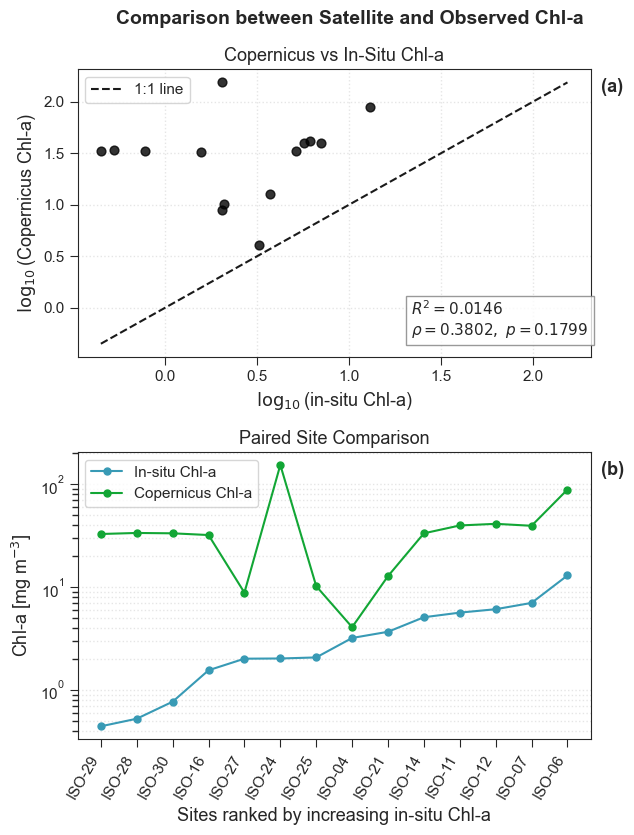

In [148]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = water_samples_Rrs[[
    "Site",
    "Chl_a_[ug/L]",
    "CHL_copernicus"
]].dropna().copy()

plot_df = plot_df[
    (plot_df["Chl_a_[ug/L]"] > 0) & (plot_df["CHL_copernicus"] > 0)
    ].copy()

plot_df = plot_df.sort_values("Chl_a_[ug/L]").reset_index(drop=True)

x = plot_df["Chl_a_[ug/L]"].to_numpy()
y = plot_df["CHL_copernicus"].to_numpy()

log_x = np.log10(x)
log_y = np.log10(y)

# Compact figure size fitting well within A4 column width with scaled-up fonts
fig, axes = plt.subplots(2, 1, figsize=(6.5, 8.5))

# Panel A: log-log scatterplot
ax = axes[0]

ax.scatter(log_x, log_y, color="black", edgecolor="black", alpha=0.8, s=40)

min_log = min(log_x.min(), log_y.min())
max_log = max(log_x.max(), log_y.max())

ax.plot([min_log, max_log], [min_log, max_log], "k--", label="1:1 line")

ax.set_xlabel(r"$\log_{10}$(in-situ Chl-a)", fontsize=13)
ax.set_ylabel(r"$\log_{10}$(Copernicus Chl-a)", fontsize=13)
ax.set_title("Copernicus vs In-Situ Chl-a", fontsize=13)

ax.text(
    0.65,
    0.20,
    r"$R^2=0.0146$" + "\n" + r"$\rho=0.3802,\ p=0.1799$",
    transform=ax.transAxes,
    verticalalignment="top",
    fontsize=11,
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray"),
)

ax.legend(loc="best", fontsize=11)
ax.grid(True, linestyle=":", alpha=0.5)
ax.text(
    1.02, 0.97, "(a)",
    transform=ax.transAxes,
    fontsize=13,
    fontweight="bold",
    verticalalignment="top",
    horizontalalignment="left"
)
# Panel B: ranked paired site plot
ax = axes[1]

site_number = np.arange(len(plot_df))

ax.plot(
    site_number,
    x,
    marker="o",
    linewidth=1.5,
    markersize=5,
    label="In-situ Chl-a",
    color="#389ab5",
)

ax.plot(
    site_number,
    y,
    marker="o",
    linewidth=1.5,
    markersize=5,
    label="Copernicus Chl-a",
    color="#12a635",
)

ax.set_yscale("log")

ax.set_xlabel("Sites ranked by increasing in-situ Chl-a", fontsize=13)
ax.set_ylabel(r"Chl-a [mg m$^{-3}$]", fontsize=13)
ax.set_title("Paired Site Comparison", fontsize=13)

ax.set_xticks(site_number)
ax.set_xticklabels(
    plot_df["Site"].astype(str), rotation=60, ha="right", fontsize=11
)

ax.grid(axis="y", which="both", linestyle=":", alpha=0.5)

ax.legend(fontsize=11)
ax.text(
    1.02, 0.97, "(b)",
    transform=ax.transAxes,
    fontsize=13,
    fontweight="bold",
    verticalalignment="top",
    horizontalalignment="left"
)
fig.suptitle("Comparison between Satellite and Observed Chl-a", fontsize=14, fontweight="bold", x=0.55)
plt.tight_layout()

plt.savefig("C:/Users/25298423/PycharmProjects/FinalFigures/copernicus_chla_pattern_validation.png", dpi=300, bbox_inches="tight")

plt.show()

### CDOM Statistics

In [149]:
water_samples_Rrs[~(water_samples_Rrs['CDM_copernicus'].isna())&(water_samples_Rrs['CDOM_a443_m-1']>0) & (water_samples_Rrs['CDOM_a490_m-1']>0)]

,Site,CDOM_a412_m-1,CDOM_a434_m-1,CDOM_a443_m-1,CDOM_a490_m-1,Chl_a_[ug/L],Chl_b_[ug/L],Chl_c_[ug/L],Date,Latitude,...,Chl_anomaly,Chl_anomaly_adj,CDM_copernicus,CDM_copernicus_adj,CDM_selected_pixel_lat,CDM_selected_pixel_lon,CDM_distance_to_selected_pixel_m,CDM_matchup_source,CDM_anomaly,CDM_anomaly_adj
3,ISO-04,3.8306,2.5170,2.1257,0.8536,3.216769,0.003157,0.589285,2026-04-28,53.244920,...,1.273569,1.273569,0.020737,0.020737,53.244793,-9.036457,343.726079,exact,0.009755,0.009755
5,ISO-06,1.4635,0.7004,0.4885,0.0217,13.028986,-0.226679,4.731097,2026-04-29,53.242865,...,6.833707,6.833707,0.232169,0.232169,53.244793,-8.984374,223.278135,exact,0.475269,0.475269
6,ISO-07,1.3605,0.7114,0.6069,0.0887,7.048044,-1.133704,0.551598,2026-04-29,53.242872,...,5.614841,5.614841,0.238565,0.238565,53.244793,-8.994791,251.214021,exact,0.393088,0.393088
28,ISO-28,1.3025,0.8463,0.6212,0.2549,0.528111,-0.002384,-0.052638,2026-05-06,53.358697,...,63.821061,63.821061,0.065948,0.065948,53.359375,-9.692707,211.439590,exact,0.106163,0.106163
29,ISO-29,1.9247,1.3170,1.1906,0.8620,0.445919,0.032178,-0.045950,2026-05-06,53.333773,...,73.844615,73.844615,0.065948,0.065948,53.338543,-9.703124,554.973352,exact,0.055391,0.055391


In [150]:
### This one includes log-slope and log-intercept, use some of it for the final -  CDOM EXACT
import numpy as np
import pandas as pd
from scipy.stats import linregress, spearmanr, wilcoxon

# 1. Select required columns
required_cols = [
    "CDOM_a443_m-1",
    "CDOM_a490_m-1",
    "CDM_copernicus"
]

df_val = (
    water_samples_Rrs[required_cols]
    .dropna()
    .copy()
)

# 2. Keep only physically valid positive values
valid_mask = (
        np.isfinite(df_val["CDOM_a443_m-1"])
        & np.isfinite(df_val["CDM_copernicus"])
        & (df_val["CDOM_a443_m-1"] > 0)
        & (df_val["CDOM_a490_m-1"] > 0)
        & (df_val["CDM_copernicus"] > 0)
)

df_val = df_val.loc[valid_mask].copy()

x = df_val["CDOM_a443_m-1"].to_numpy(dtype=float)
y = df_val["CDM_copernicus"].to_numpy(dtype=float)

n = len(df_val)

if n < 3:
    raise ValueError(
        f"Only {n} valid matchups remain. At least 3 are required."
    )

# 3. Log10 transformation
log_x = np.log10(x)
log_y = np.log10(y)

# 4. Log-scale regression
# x = in-situ Chl-a
# y = Copernicus Chl-a
slope, intercept, r_value, p_value, std_error = (
    linregress(log_x, log_y)
)

# This is the regression R2, equivalent to r_value squared
r2_log_regression = r_value ** 2

# Fitted log-scale predictions
log_y_fitted = intercept + slope * log_x

# Optional predictive R2 on the log scale
ss_res_log = np.sum(
    (log_y - log_y_fitted) ** 2
)

ss_tot_log = np.sum(
    (log_y - np.mean(log_y)) ** 2
)

r2_log_predictive = (
        1 - ss_res_log / ss_tot_log
)

# 5. Spearman correlation
spearman_corr, spearman_p = spearmanr(
    x,
    y
)

# 6. Original-scale RMSD
rmsd = np.sqrt(
    np.mean((y - x) ** 2)
)

# 7. Log-RMSE
log_rmse = np.sqrt(
    np.mean((log_y - log_x) ** 2)
)

# 8. Percentage differences
percentage_differences = (
                                 (y - x) / x
                         ) * 100

mdpd = np.median(
    percentage_differences
)

mdapd = np.median(
    np.abs(percentage_differences)
)

# 9. Log bias
log_differences = log_y - log_x

median_log_bias = np.median(
    log_differences
)

mean_log_bias = np.mean(
    log_differences
)

# Multiplicative bias converted back to percentage
median_multiplicative_bias = (
                                     (10 ** median_log_bias) - 1
                             ) * 100

# Multiplicative error associated with log-RMSE
typical_multiplicative_error = (
                                       (10 ** log_rmse) - 1
                               ) * 100

# 10. Paired Wilcoxon test on log differences
if np.allclose(log_differences, 0):
    wilcoxon_stat = 0
    wilcoxon_p = 1.0
else:
    wilcoxon_stat, wilcoxon_p = wilcoxon(
        log_differences,
        zero_method="wilcox",
        alternative="two-sided",
        method="auto"
    )

# 11. Report
print("==========================================")
print("       COPERNICUS CDOM VALIDATION        ")
print("==========================================")
print(f"Valid matchups (N)              : {n}")
print()
print(f"Log regression slope            : {slope:.4f}")
print(f"Log regression intercept        : {intercept:.4f}")
print(f"Log regression R²               : {r2_log_regression:.4f}")
print(f"Log predictive R²               : {r2_log_predictive:.4f}")
print()
print(
    f"Spearman correlation            : "
    f"{spearman_corr:.4f} "
    f"(p = {spearman_p:.4e})"
)
print()
print(
    f"RMSD                            : "
    f"{rmsd:.4f} in the original CDM units"
)
print(f"Log-RMSE                        : {log_rmse:.4f}")
print(
    f"Typical multiplicative error    : "
    f"{typical_multiplicative_error:.2f}%"
)
print()
print(f"MdPD                            : {mdpd:.2f}%")
print(f"MdAPD                           : {mdapd:.2f}%")
print(f"Median log bias                 : {median_log_bias:.4f}")
print(
    f"Median multiplicative bias      : "
    f"{median_multiplicative_bias:.2f}%"
)
print(f"Mean log bias                   : {mean_log_bias:.4f}")
print()
print(
    f"Wilcoxon statistic              : "
    f"{wilcoxon_stat}"
)
print(
    f"Wilcoxon p-value                : "
    f"{wilcoxon_p:.4e}"
)
print("==========================================")


       COPERNICUS CDOM VALIDATION        
Valid matchups (N)              : 5

Log regression slope            : -1.4977
Log regression intercept        : -1.1596
Log regression R²               : 0.7878
Log predictive R²               : 0.7878

Spearman correlation            : -0.8000 (p = 1.0409e-01)

RMSD                            : 1.1140 in the original CDM units
Log-RMSE                        : 1.1696
Typical multiplicative error    : 1377.70%

MdPD                            : -89.38%
MdAPD                           : 89.38%
Median log bias                 : -0.9740
Median multiplicative bias      : -89.38%
Mean log bias                   : -0.9940

Wilcoxon statistic              : 0.0
Wilcoxon p-value                : 6.2500e-02


In [151]:
# 11. Report and Clipboard Export
metrics_summary = pd.DataFrame({
    "Parameter / Metric": [
        "Valid Matchups (N)",
        "Log Regression Slope",
        "Log Regression Intercept",
        "Log Regression R²",
        "Log Predictive R²",
        "Spearman Correlation (rho)",
        "Spearman p-value",
        "RMSD",
        "Log-RMSE",
        "Typical Multiplicative Error (%)",
        "MdPD (%)",
        "MdAPD (%)",
        "Median Log Bias",
        "Median Multiplicative Bias (%)",
        "Wilcoxon Statistic",
        "Wilcoxon p-value"
    ],
    "Value": [
        f"{n}",
        f"{slope:.4f}",
        f"{intercept:.4f}",
        f"{r2_log_regression:.4f}",
        f"{r2_log_predictive:.4f}",
        f"{spearman_corr:.4f}",
        f"{spearman_p:.4e}",
        f"{rmsd:.4f}",
        f"{log_rmse:.4f}",
        f"{typical_multiplicative_error:.2f}%",
        f"{mdpd:.2f}%",
        f"{mdapd:.2f}%",
        f"{median_log_bias:.4f}",
        f"{median_multiplicative_bias:.2f}%",
        f"{wilcoxon_stat}",
        f"{wilcoxon_p:.4e}"
    ]
})

print("==========================================")
print("        COPERNICUS CDOM VALIDATION        ")
print("==========================================")
for idx, row in metrics_summary.iterrows():
    print(f"{row['Parameter / Metric']:<32} : {row['Value']}")
print("==========================================")

# Copy straight to clipboard for Word/Excel
metrics_summary.to_clipboard(excel=True, index=False)
print("\nValidation metrics table successfully copied to clipboard!")

        COPERNICUS CDOM VALIDATION        
Valid Matchups (N)               : 5
Log Regression Slope             : -1.4977
Log Regression Intercept         : -1.1596
Log Regression R²                : 0.7878
Log Predictive R²                : 0.7878
Spearman Correlation (rho)       : -0.8000
Spearman p-value                 : 1.0409e-01
RMSD                             : 1.1140
Log-RMSE                         : 1.1696
Typical Multiplicative Error (%) : 1377.70%
MdPD (%)                         : -89.38%
MdAPD (%)                        : 89.38%
Median Log Bias                  : -0.9740
Median Multiplicative Bias (%)   : -89.38%
Wilcoxon Statistic               : 0.0
Wilcoxon p-value                 : 6.2500e-02

Validation metrics table successfully copied to clipboard!


In [152]:
cdm_exact_metrics, cdm_exact_data = (
    validate_copernicus_product(
        df=water_samples_Rrs,
        insitu_col="CDOM_a443_m-1",
        satellite_col="CDM_copernicus",
        qc_cols= ["CDOM_a443_m-1","CDOM_a490_m-1"], ##need to be in list form
        product_name="Copernicus exact-pixel CDOM"
    )
)

COPERNICUS EXACT-PIXEL CDOM VALIDATION
Valid matchups (N)              : 5

Type-2 slope, log scale         : -1.6874
Type-2 intercept, log scale     : -1.1722
Log-scale R²                    : 0.7878
Spearman correlation            : -0.8000 (p = 1.0409e-01)

Bias, original units            : -0.8819
RMSD, original units            : 1.1140
RMSD, log scale                 : 1.1696

Mean multiplicative bias        : -89.86%
Median multiplicative bias      : -89.38%
MdPD                            : -89.38%
MdAPD                           : 89.38%

Wilcoxon statistic              : 0.0
Wilcoxon p-value                : 6.2500e-02


In [153]:
cdm_adj_metrics, cdm_adj_data = (
    validate_copernicus_product(
        df=water_samples_Rrs,
        insitu_col="CDOM_a443_m-1",
        satellite_col="CDM_copernicus_adj",
        qc_cols= ["CDOM_a443_m-1","CDOM_a490_m-1"], ##need to be in list form
        product_name="Copernicus exact+adjacent-pixel CDOM"
    )
)

COPERNICUS EXACT+ADJACENT-PIXEL CDOM VALIDATION
Valid matchups (N)              : 11

Type-2 slope, log scale         : -1.5263
Type-2 intercept, log scale     : -1.1465
Log-scale R²                    : 0.7018
Spearman correlation            : -0.8721 (p = 4.6463e-04)

Bias, original units            : -1.2835
RMSD, original units            : 1.6626
RMSD, log scale                 : 1.4374

Mean multiplicative bias        : -94.23%
Median multiplicative bias      : -94.46%
MdPD                            : -94.46%
MdAPD                           : 94.46%

Wilcoxon statistic              : 0.0
Wilcoxon p-value                : 9.7656e-04


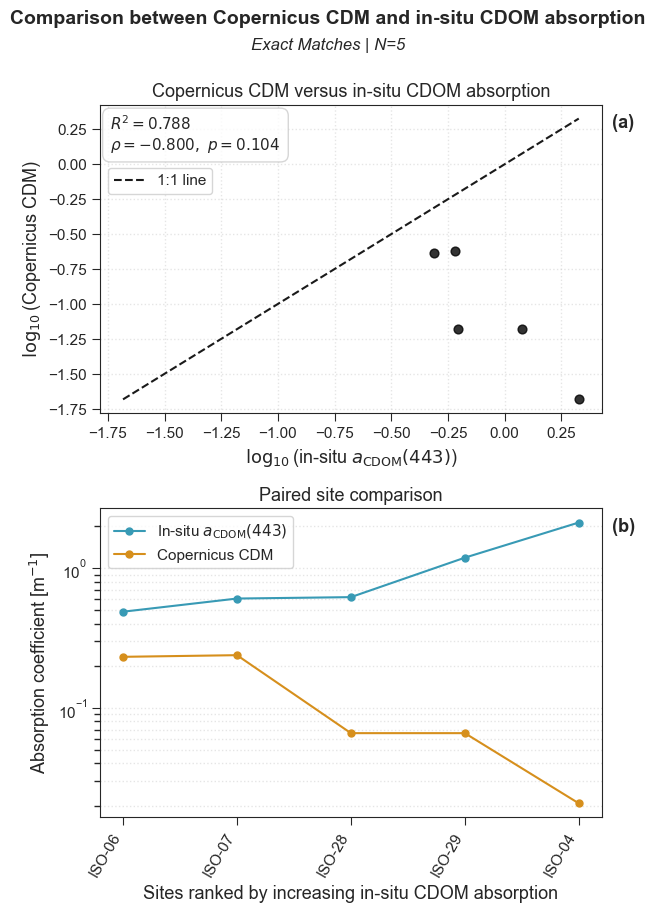

Valid exact-pixel CDM matchups plotted: 5


In [154]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

satellite_col = "CDM_copernicus"

plot_df = water_samples_Rrs[
    [
        "Site",
        "CDOM_a443_m-1",
        "CDOM_a490_m-1",
        satellite_col
    ]
].dropna().copy()

# Retain only physically valid positive values
plot_df = plot_df[
    (plot_df["CDOM_a443_m-1"] > 0)
    & (plot_df["CDOM_a490_m-1"] > 0)
    & (plot_df[satellite_col] > 0)
    ].copy()

# Sort sites by increasing in-situ CDOM absorption at 443 nm
plot_df = plot_df.sort_values(
    "CDOM_a443_m-1"
).reset_index(drop=True)

x = plot_df["CDOM_a443_m-1"].to_numpy(
    dtype=float
)

y = plot_df[satellite_col].to_numpy(
    dtype=float
)

log_x = np.log10(x)
log_y = np.log10(y)

# Calculate plot statistics
pearson_r_log = np.corrcoef(
    log_x,
    log_y
)[0, 1]

r2_log = pearson_r_log ** 2

spearman_rho, spearman_p = spearmanr(
    x,
    y
)

# Compact figure size suitable for an A4 column
fig, axes = plt.subplots(
    2,
    1,
    figsize=(6.5, 9.3)
)

# Panel A: log-log scatterplot
ax = axes[0]

ax.scatter(
    log_x,
    log_y,
    color="black",
    edgecolor="black",
    alpha=0.8,
    s=40
)

min_log = min(
    log_x.min(),
    log_y.min()
)

max_log = max(
    log_x.max(),
    log_y.max()
)

ax.plot(
    [min_log, max_log],
    [min_log, max_log],
    "k--",
    label="1:1 line"
)

ax.set_xlabel(
    r"$\log_{10}$(in-situ $a_{\mathrm{CDOM}}(443)$)",
    fontsize=13
)

ax.set_ylabel(
    r"$\log_{10}$(Copernicus CDM)",
    fontsize=13
)

ax.set_title(
    "Copernicus CDM versus in-situ CDOM absorption",
    fontsize=13
)

ax.text(
    0.02,
    0.97,
    rf"$R^2={r2_log:.3f}$"
    "\n"
    rf"$\rho={spearman_rho:.3f},\ p={spearman_p:.3f}$",
    transform=ax.transAxes,
    verticalalignment="top",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        alpha=0.8,
        edgecolor="0.8",
        linewidth=1
    )
)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.0, 0.82),
    fontsize=11
)

ax.grid(
    True,
    linestyle=":",
    alpha=0.5
)
ax.text(
    1.02, 0.97, "(a)",
    transform=ax.transAxes,
    fontsize=13,
    fontweight="bold",
    verticalalignment="top",
    horizontalalignment="left"
)
# Panel B: ranked paired site plot
ax = axes[1]

site_number = np.arange(
    len(plot_df)
)

ax.plot(
    site_number,
    x,
    marker="o",
    linewidth=1.5,
    markersize=5,
    label=r"In-situ $a_{\mathrm{CDOM}}(443)$",
    color="#389ab5"
)

ax.plot(
    site_number,
    y,
    marker="o",
    linewidth=1.5,
    markersize=5,
    label="Copernicus CDM",
    color="#d68f1c"
)

ax.set_yscale("log")

ax.set_xlabel(
    "Sites ranked by increasing in-situ CDOM absorption",
    fontsize=13
)

ax.set_ylabel(
    r"Absorption coefficient [m$^{-1}$]",
    fontsize=13
)

ax.set_title(
    "Paired site comparison",
    fontsize=13
)

ax.set_xticks(
    site_number
)

ax.set_xticklabels(
    plot_df["Site"].astype(str),
    rotation=60,
    ha="right",
    fontsize=11
)

ax.grid(
    axis="y",
    which="both",
    linestyle=":",
    alpha=0.5
)

ax.legend(
    fontsize=11
)
ax.text(
    1.02, 0.97, "(b)",
    transform=ax.transAxes,
    fontsize=13,
    fontweight="bold",
    verticalalignment="top",
    horizontalalignment="left"
)
fig.suptitle(
    "Comparison between Copernicus CDM and in-situ CDOM absorption",
    fontsize=14,
    fontweight="bold",
    x=0.5, y=0.98
)
fig.text(0.5,0.95,"Exact Matches | N=5", fontsize=12, fontweight='normal', fontstyle='italic', ha='center',va='top')
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig("C:/Users/25298423/PycharmProjects/FinalFigures/copernicus_cdm_vs_insitu_cdom_exact.png",dpi=1200)

plt.show()

print(
    f"Valid exact-pixel CDM matchups plotted: {len(plot_df)}"
)


In [155]:
### This one includes log-slope and log-intercept, use some of it for the final - CDOM ADJACENT
import numpy as np
import pandas as pd
from scipy.stats import linregress, spearmanr, wilcoxon

# 1. Select required columns
required_cols = [
    "CDOM_a443_m-1",
    "CDOM_a490_m-1",
    "CDM_copernicus_adj"
]

df_val = (
    water_samples_Rrs[required_cols]
    .dropna()
    .copy()
)

# 2. Keep only physically valid positive values
valid_mask = (
        np.isfinite(df_val["CDOM_a443_m-1"])
        & np.isfinite(df_val["CDM_copernicus_adj"])
        & (df_val["CDOM_a443_m-1"] > 0)
        & (df_val["CDOM_a490_m-1"] > 0)
        & (df_val["CDM_copernicus_adj"] > 0)
)

df_val = df_val.loc[valid_mask].copy()

x = df_val["CDOM_a443_m-1"].to_numpy(dtype=float)
y = df_val["CDM_copernicus_adj"].to_numpy(dtype=float)

n = len(df_val)

if n < 3:
    raise ValueError(
        f"Only {n} valid matchups remain. At least 3 are required."
    )

# 3. Log10 transformation
log_x = np.log10(x)
log_y = np.log10(y)

# 4. Log-scale regression
# x = in-situ Chl-a
# y = Copernicus Chl-a
slope, intercept, r_value, p_value, std_error = (
    linregress(log_x, log_y)
)

# This is the regression R2, equivalent to r_value squared
r2_log_regression = r_value ** 2

# Fitted log-scale predictions
log_y_fitted = intercept + slope * log_x

# Optional predictive R2 on the log scale
ss_res_log = np.sum(
    (log_y - log_y_fitted) ** 2
)

ss_tot_log = np.sum(
    (log_y - np.mean(log_y)) ** 2
)

r2_log_predictive = (
        1 - ss_res_log / ss_tot_log
)

# 5. Spearman correlation
spearman_corr, spearman_p = spearmanr(
    x,
    y
)

# 6. Original-scale RMSD
rmsd = np.sqrt(
    np.mean((y - x) ** 2)
)

# 7. Log-RMSE
log_rmse = np.sqrt(
    np.mean((log_y - log_x) ** 2)
)

# 8. Percentage differences
percentage_differences = (
                                 (y - x) / x
                         ) * 100

mdpd = np.median(
    percentage_differences
)

mdapd = np.median(
    np.abs(percentage_differences)
)

# 9. Log bias
log_differences = log_y - log_x

median_log_bias = np.median(
    log_differences
)

mean_log_bias = np.mean(
    log_differences
)

# Multiplicative bias converted back to percentage
median_multiplicative_bias = (
                                     (10 ** median_log_bias) - 1
                             ) * 100

# Multiplicative error associated with log-RMSE
typical_multiplicative_error = (
                                       (10 ** log_rmse) - 1
                               ) * 100

# 10. Paired Wilcoxon test on log differences
if np.allclose(log_differences, 0):
    wilcoxon_stat = 0
    wilcoxon_p = 1.0
else:
    wilcoxon_stat, wilcoxon_p = wilcoxon(
        log_differences,
        zero_method="wilcox",
        alternative="two-sided",
        method="auto"
    )

# 11. Report
print("==========================================")
print("       COPERNICUS CDOM VALIDATION        ")
print("==========================================")
print(f"Valid matchups (N)              : {n}")
print()
print(f"Log regression slope            : {slope:.4f}")
print(f"Log regression intercept        : {intercept:.4f}")
print(f"Log regression R²               : {r2_log_regression:.4f}")
print(f"Log predictive R²               : {r2_log_predictive:.4f}")
print()
print(
    f"Spearman correlation            : "
    f"{spearman_corr:.4f} "
    f"(p = {spearman_p:.4e})"
)
print()
print(
    f"RMSD                            : "
    f"{rmsd:.4f} in the original CDM units"
)
print(f"Log-RMSE                        : {log_rmse:.4f}")
print(
    f"Typical multiplicative error    : "
    f"{typical_multiplicative_error:.2f}%"
)
print()
print(f"MdPD                            : {mdpd:.2f}%")
print(f"MdAPD                           : {mdapd:.2f}%")
print(f"Median log bias                 : {median_log_bias:.4f}")
print(
    f"Median multiplicative bias      : "
    f"{median_multiplicative_bias:.2f}%"
)
print(f"Mean log bias                   : {mean_log_bias:.4f}")
print()
print(
    f"Wilcoxon statistic              : "
    f"{wilcoxon_stat}"
)
print(
    f"Wilcoxon p-value                : "
    f"{wilcoxon_p:.4e}"
)
print("==========================================")


       COPERNICUS CDOM VALIDATION        
Valid matchups (N)              : 11

Log regression slope            : -1.2786
Log regression intercept        : -1.1556
Log regression R²               : 0.7018
Log predictive R²               : 0.7018

Spearman correlation            : -0.8721 (p = 4.6463e-04)

RMSD                            : 1.6626 in the original CDM units
Log-RMSE                        : 1.4374
Typical multiplicative error    : 2637.90%

MdPD                            : -94.46%
MdAPD                           : 94.46%
Median log bias                 : -1.2566
Median multiplicative bias      : -94.46%
Mean log bias                   : -1.2388

Wilcoxon statistic              : 0.0
Wilcoxon p-value                : 9.7656e-04


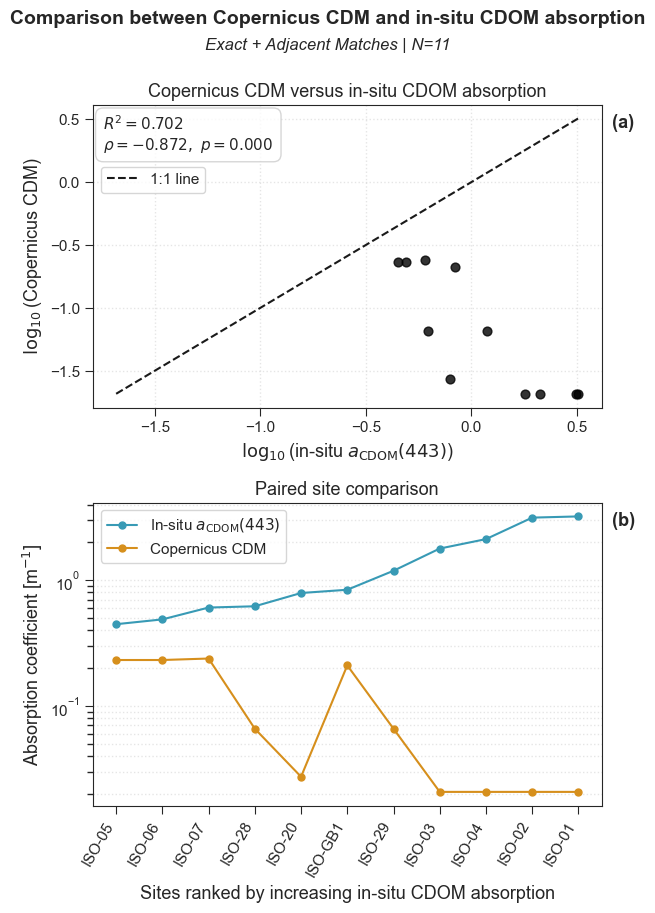

Valid exact-pixel CDM matchups plotted: 11


In [156]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

satellite_col = "CDM_copernicus_adj"

plot_df = water_samples_Rrs[
    [
        "Site",
        "CDOM_a443_m-1",
        "CDOM_a490_m-1",
        satellite_col
    ]
].dropna().copy()

# Retain only physically valid positive values
plot_df = plot_df[
    (plot_df["CDOM_a443_m-1"] > 0)
    & (plot_df["CDOM_a490_m-1"] > 0)
    & (plot_df[satellite_col] > 0)
    ].copy()

# Sort sites by increasing in-situ CDOM absorption at 443 nm
plot_df = plot_df.sort_values(
    "CDOM_a443_m-1"
).reset_index(drop=True)

x = plot_df["CDOM_a443_m-1"].to_numpy(
    dtype=float
)

y = plot_df[satellite_col].to_numpy(
    dtype=float
)

log_x = np.log10(x)
log_y = np.log10(y)

# Calculate plot statistics
pearson_r_log = np.corrcoef(
    log_x,
    log_y
)[0, 1]

r2_log = pearson_r_log ** 2

spearman_rho, spearman_p = spearmanr(
    x,
    y
)

# Compact figure size suitable for an A4 column
fig, axes = plt.subplots(
    2,
    1,
    figsize=(6.5, 9.3)
)

# Panel A: log-log scatterplot
ax = axes[0]

ax.scatter(
    log_x,
    log_y,
    color="black",
    edgecolor="black",
    alpha=0.8,
    s=40
)

min_log = min(
    log_x.min(),
    log_y.min()
)

max_log = max(
    log_x.max(),
    log_y.max()
)

ax.plot(
    [min_log, max_log],
    [min_log, max_log],
    "k--",
    label="1:1 line"
)

ax.set_xlabel(
    r"$\log_{10}$(in-situ $a_{\mathrm{CDOM}}(443)$)",
    fontsize=13
)

ax.set_ylabel(
    r"$\log_{10}$(Copernicus CDM)",
    fontsize=13
)

ax.set_title(
    "Copernicus CDM versus in-situ CDOM absorption",
    fontsize=13
)

ax.text(
    0.02,
    0.97,
    rf"$R^2={r2_log:.3f}$"
    "\n"
    rf"$\rho={spearman_rho:.3f},\ p={spearman_p:.3f}$",
    transform=ax.transAxes,
    verticalalignment="top",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        alpha=0.8,
        edgecolor="0.8",
        linewidth=1
    )
)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.0, 0.82),
    fontsize=11
)

ax.grid(
    True,
    linestyle=":",
    alpha=0.5
)
ax.text(
    1.02, 0.97, "(a)",
    transform=ax.transAxes,
    fontsize=13,
    fontweight="bold",
    verticalalignment="top",
    horizontalalignment="left"
)
# Panel B: ranked paired site plot
ax = axes[1]

site_number = np.arange(
    len(plot_df)
)

ax.plot(
    site_number,
    x,
    marker="o",
    linewidth=1.5,
    markersize=5,
    label=r"In-situ $a_{\mathrm{CDOM}}(443)$",
    color="#389ab5"
)

ax.plot(
    site_number,
    y,
    marker="o",
    linewidth=1.5,
    markersize=5,
    label="Copernicus CDM",
    color="#d68f1c"
)

ax.set_yscale("log")

ax.set_xlabel(
    "Sites ranked by increasing in-situ CDOM absorption",
    fontsize=13
)

ax.set_ylabel(
    r"Absorption coefficient [m$^{-1}$]",
    fontsize=13
)

ax.set_title(
    "Paired site comparison",
    fontsize=13
)

ax.set_xticks(
    site_number
)

ax.set_xticklabels(
    plot_df["Site"].astype(str),
    rotation=60,
    ha="right",
    fontsize=11
)

ax.grid(
    axis="y",
    which="both",
    linestyle=":",
    alpha=0.5
)

ax.legend(
    fontsize=11
)
ax.text(
    1.02, 0.97, "(b)",
    transform=ax.transAxes,
    fontsize=13,
    fontweight="bold",
    verticalalignment="top",
    horizontalalignment="left"
)
fig.suptitle(
    "Comparison between Copernicus CDM and in-situ CDOM absorption",
    fontsize=14,
    fontweight="bold",
    x=0.5, y=0.98
)
fig.text(0.5,0.95,"Exact + Adjacent Matches | N=11", fontsize=12, fontweight='normal', fontstyle='italic', ha='center',va='top')
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig("C:/Users/25298423/PycharmProjects/FinalFigures/copernicus_cdm_vs_insitu_cdom_adjacent.png",dpi=1200)

plt.show()

print(
    f"Valid exact-pixel CDM matchups plotted: {len(plot_df)}"
)


<xarray.Dataset> Size: 2MB
Dimensions:    (time: 61, latitude: 72, longitude: 120)
Coordinates:
  * time       (time) datetime64[ns] 488B 2026-04-01 2026-04-02 ... 2026-05-31
  * latitude   (latitude) float32 288B 52.76 52.77 52.78 ... 53.47 53.48 53.49
  * longitude  (longitude) float32 480B -9.995 -9.984 -9.974 ... -8.766 -8.755
Data variables:
    ZSD        (time, latitude, longitude) float32 2MB dask.array<chunksize=(61, 72, 120), meta=np.ndarray>
Attributes:
    comment:                   average
    Conventions:               CF-1.8, ACDD-1.3
    title:                     cmems_obs-oc_atl_bgc-transp_my_l3-multi-1km_P1D
    source:                    surface observation
    references:                http://www.globcolour.info GlobColour has been...
    institution:               ACRI
    contact:                   servicedesk.cmems@acri-st.fr
    history:                   Created using software developed at ACRI-ST
    copernicusmarine_version:  2.2.2

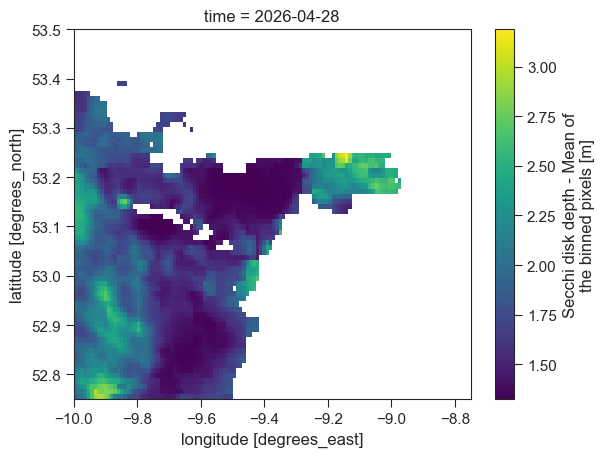

In [157]:
zsd_insitu_file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/in-situ/ZSD/*.nc'))
zsd_is = xr.open_mfdataset(zsd_insitu_file_list, concat_dim='time', combine='nested')
display(zsd_is)
zsd_is['ZSD'].sel(time='2026-04-28').plot()

In [158]:
stations

,Date,Time_Start,Time_End,Site,Longitude,Latitude,Secchi_Depth(m),Notes,Timestamp_Start,Timestamp_End,latitude_dec,longitude_dec
0,2026-04-28,11:28:00,11:38:00,ISO-01,9° 2.3724' W,53° 15.7862’N,3.36,NaN,2026-04-28 11:28:00,2026-04-28 11:38:00,53.263103,-9.039540
1,2026-04-28,11:43:00,11:50:00,ISO-02,9° 2.2235’ W,53° 15.6392’ N,4.06,NaN,2026-04-28 11:43:00,2026-04-28 11:50:00,53.260653,-9.037058
2,2026-04-28,12:02:00,12:09:00,ISO-03,9° 2.2161’ W,53° 15.0466’ N,4.13,NaN,2026-04-28 12:02:00,2026-04-28 12:09:00,53.250777,-9.036935
3,2026-04-28,12:18:00,12:26:00,ISO-04,9° 2.4973’ W,53° 14.6952’ N,NaN,NaN,2026-04-28 12:18:00,2026-04-28 12:26:00,53.244920,-9.041622
4,2026-04-28,15:18:00,15:25:00,ISO-08A,8° 56.1705’ W,53° 8.5038’ N,2.53,NaN,2026-04-28 15:18:00,2026-04-28 15:25:00,53.141730,-8.936175
5,2026-04-28,15:41:00,15:47:00,ISO-08B,8° 56.9037’ W,53° 9.5003’ N,4.88,NaN,2026-04-28 15:41:00,2026-04-28 15:47:00,53.158338,-8.948395
6,2026-04-28,15:58:00,16:02:00,ISO-09,8° 57.3280’ W,53° 10.0637’ N,4.25,NaN,2026-04-28 15:58:00,2026-04-28 16:02:00,53.167728,-8.955467
7,2026-04-28,16:13:00,16:15:00,ISO-10,8° 57.7330’ W,53° 10.5538’ N,4.39,NaN,2026-04-28 16:13:00,2026-04-28 16:15:00,53.175897,-8.962217
8,2026-04-28,16:24:00,16:34:00,ISO-11,8° 58.2232’ W,53° 10.8128’ N,4.59,NaN,2026-04-28 16:24:00,2026-04-28 16:34:00,53.180213,-8.970387
9,2026-04-28,16:43:00,16:48:00,ISO-12,8° 58.7559’ W,53° 10.7636’ N,5.05,NaN,2026-04-28 16:43:00,2026-04-28 16:48:00,53.179393,-8.979265


In [159]:
water_samples_Rrs = water_samples_Rrs.merge(
    stations[["Site", "Secchi_Depth(m)"]],
    on="Site",
    how="left"
)
water_samples_Rrs

,Site,CDOM_a412_m-1,CDOM_a434_m-1,CDOM_a443_m-1,CDOM_a490_m-1,Chl_a_[ug/L],Chl_b_[ug/L],Chl_c_[ug/L],Date,Latitude,...,Chl_anomaly_adj,CDM_copernicus,CDM_copernicus_adj,CDM_selected_pixel_lat,CDM_selected_pixel_lon,CDM_distance_to_selected_pixel_m,CDM_matchup_source,CDM_anomaly,CDM_anomaly_adj,Secchi_Depth(m)
0,ISO-01,5.6681,3.7328,3.2217,1.6826,3.041240,-0.023840,0.732600,2026-04-28,53.263103,...,NaN,NaN,0.020737,53.244793,-9.036457,2044.961941,local_fallback,NaN,0.006437,3.36
1,ISO-02,5.2462,3.6482,3.1513,1.4342,3.248234,0.019364,0.684792,2026-04-28,53.260653,...,1.259683,NaN,0.020737,53.244793,-9.036457,1762.983512,local_fallback,NaN,0.006580,4.06
2,ISO-03,3.5467,2.1829,1.7883,0.6034,2.660049,0.053825,0.475276,2026-04-28,53.250777,...,1.538222,NaN,0.020737,53.244793,-9.036457,665.840259,local_fallback,NaN,0.011596,4.13
3,ISO-04,3.8306,2.5170,2.1257,0.8536,3.216769,0.003157,0.589285,2026-04-28,53.244920,...,1.273569,0.020737,0.020737,53.244793,-9.036457,343.726079,exact,0.009755,0.009755,NaN
4,ISO-05,1.3899,0.7341,0.4474,0.0350,14.443843,-0.190331,5.316073,2026-04-29,53.242783,...,5.229866,NaN,0.232169,53.244793,-8.984374,780.886224,local_fallback,NaN,0.518929,2.76
5,ISO-06,1.4635,0.7004,0.4885,0.0217,13.028986,-0.226679,4.731097,2026-04-29,53.242865,...,6.833707,0.232169,0.232169,53.244793,-8.984374,223.278135,exact,0.475269,0.475269,2.80
6,ISO-07,1.3605,0.7114,0.6069,0.0887,7.048044,-1.133704,0.551598,2026-04-29,53.242872,...,5.614841,0.238565,0.238565,53.244793,-8.994791,251.214021,exact,0.393088,0.393088,5.06
7,ISO-08A,9.4658,6.3757,5.4946,2.8589,3.327007,-0.048250,0.357905,2026-04-28,53.141730,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.53
8,ISO-08B,4.7905,3.0862,2.7564,1.4988,4.086672,0.245169,0.498590,2026-04-28,53.158338,...,13.613520,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.88
9,ISO-09,2.5603,1.7749,1.4804,0.9081,4.624154,0.203794,0.639475,2026-04-28,53.167728,...,12.033213,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.25


In [160]:
# Create a mapping dictionary or series from stations for latitude and longitude
lat_map = stations.set_index('Site')['latitude_dec']
lon_map = stations.set_index('Site')['longitude_dec']
date_map = stations.set_index('Site')['Date']
# Fill missing latitude and longitude values in water_samples_Rrs using the Site column
water_samples_Rrs['Latitude'] = water_samples_Rrs['Latitude'].fillna(
    water_samples_Rrs['Site'].map(lat_map)
)
water_samples_Rrs['Longitude'] = water_samples_Rrs['Longitude'].fillna(
    water_samples_Rrs['Site'].map(lon_map)
)
water_samples_Rrs['Date'] = water_samples_Rrs['Date'].fillna(
    water_samples_Rrs['Site'].map(date_map)
)
water_samples_Rrs['Date'] = pd.to_datetime(water_samples_Rrs['Date'])

In [161]:
water_samples_Rrs[water_samples_Rrs['Site'].str.contains('19')]

,Site,CDOM_a412_m-1,CDOM_a434_m-1,CDOM_a443_m-1,CDOM_a490_m-1,Chl_a_[ug/L],Chl_b_[ug/L],Chl_c_[ug/L],Date,Latitude,...,Chl_anomaly_adj,CDM_copernicus,CDM_copernicus_adj,CDM_selected_pixel_lat,CDM_selected_pixel_lon,CDM_distance_to_selected_pixel_m,CDM_matchup_source,CDM_anomaly,CDM_anomaly_adj,Secchi_Depth(m)
19,ISO-19,0.6897,0.3265,0.1817,-0.1654,3.851219,-0.076903,0.575986,2026-05-01,53.246167,...,3.332818,NaN,0.027371,53.234375,-9.609374,1983.368666,local_fallback,NaN,0.150639,4.7


In [162]:
import numpy as np
import pandas as pd
import xarray as xr

# 1. Ensure the Date column in your dataframe is in datetime format
water_samples_Rrs['Date'] = pd.to_datetime(water_samples_Rrs['Date'])

# 2. Convert dataframe columns into Xarray DataArrays for fast, vectorized indexing
lats = xr.DataArray(water_samples_Rrs['Latitude'].values, dims="sample")
lons = xr.DataArray(water_samples_Rrs['Longitude'].values, dims="sample")
times = xr.DataArray(water_samples_Rrs['Date'].values, dims="sample")

# 3. Extract the zsd values matching each specific date, latitude, and longitude
matched_zsd = zsd_is['ZSD'].sel(
    latitude=lats,
    longitude=lons,
    time=times,
    method='nearest'
)

# 4. Add the extracted satellite Chl-a values directly back into your dataframe
water_samples_Rrs['ZSD_copernicus'] = matched_zsd.values

print(
    f"Successfully matched ZSD for {water_samples_Rrs['ZSD_copernicus'].notna().sum()} out of {len(water_samples_Rrs)} rows!")

Successfully matched ZSD for 8 out of 34 rows!


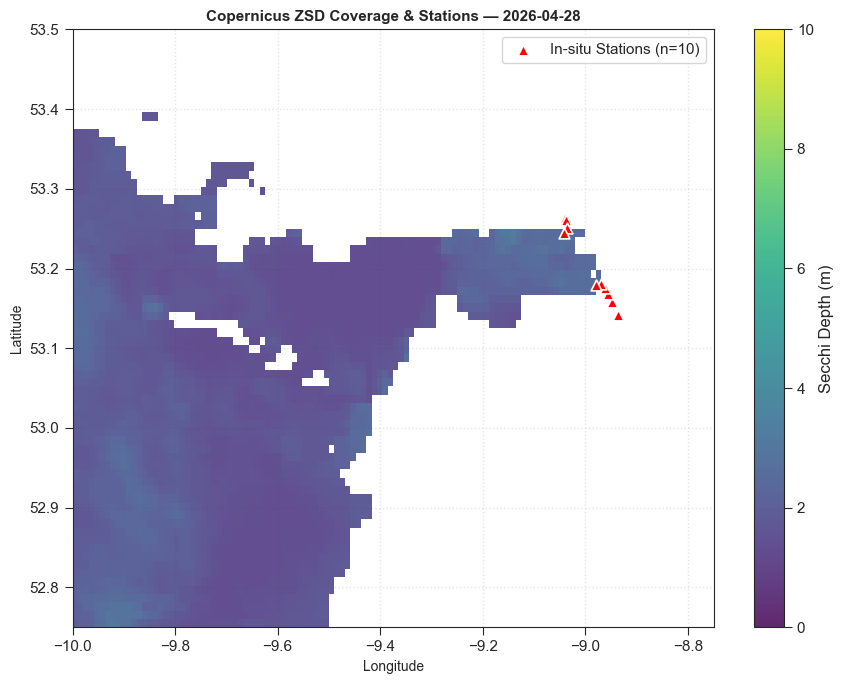

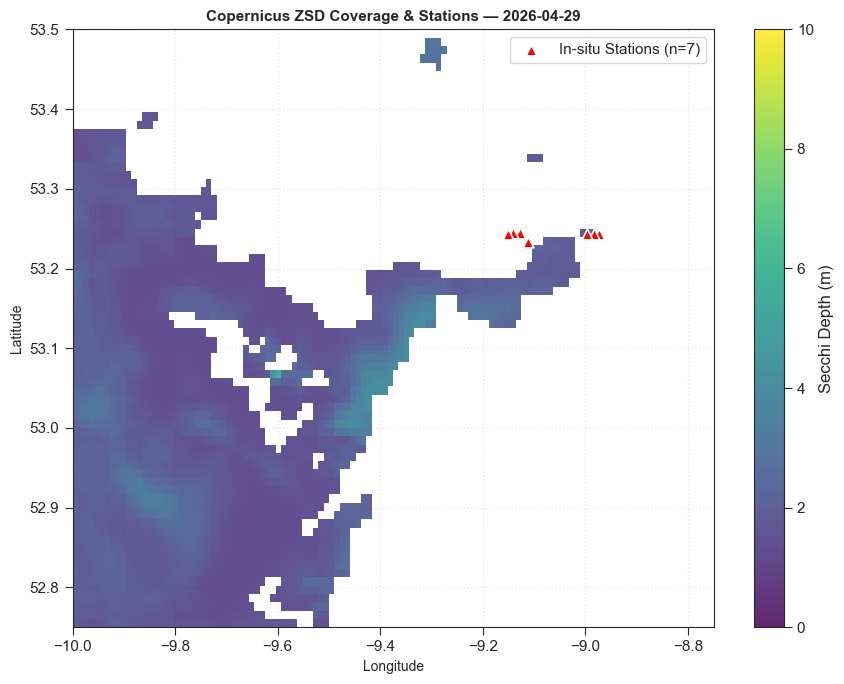

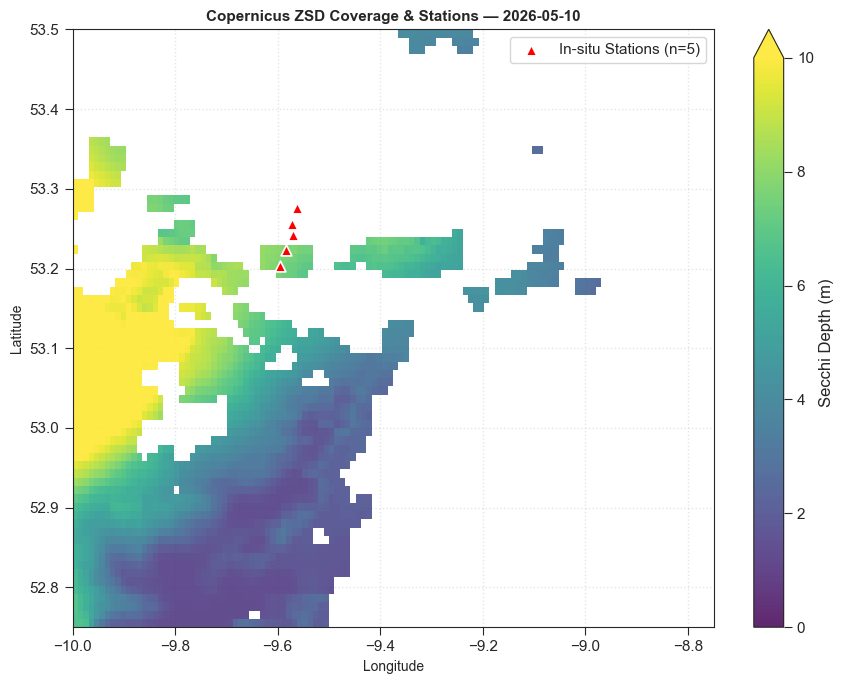

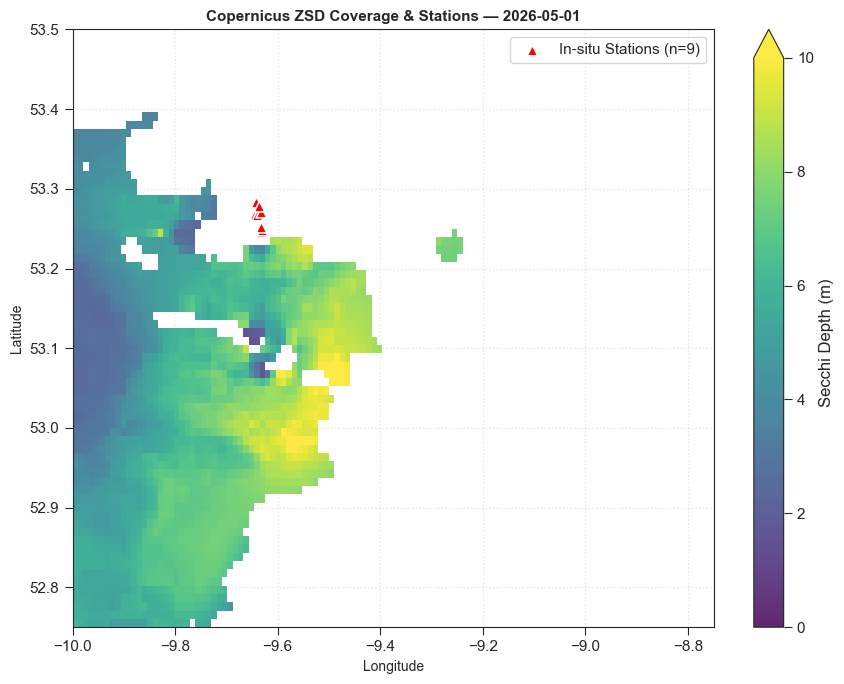

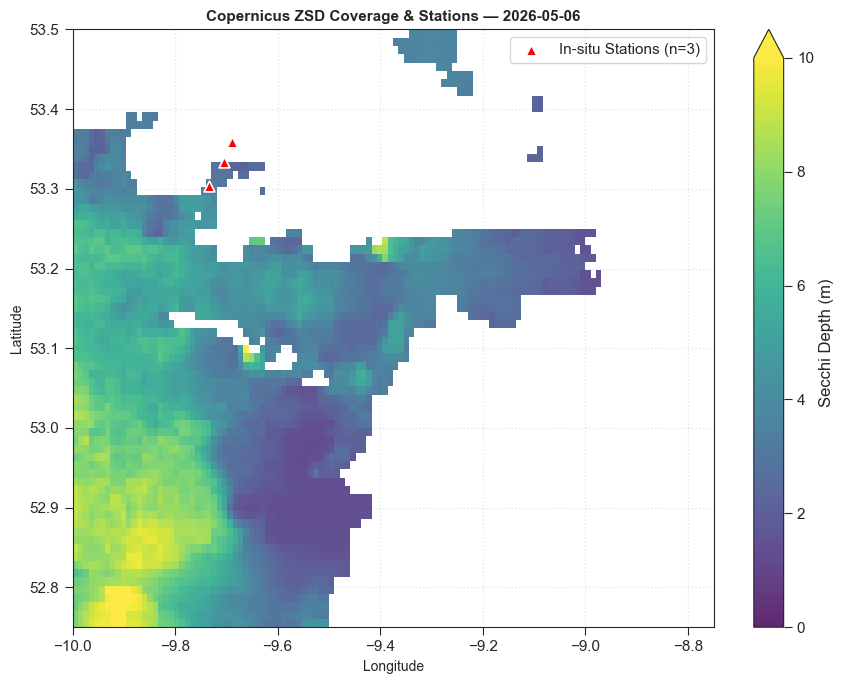

In [163]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

# 1. Ensure Date is in datetime format and get unique dates from your in-situ data
water_samples_Rrs['Date'] = pd.to_datetime(water_samples_Rrs['Date'])
unique_dates = water_samples_Rrs['Date'].dt.date.unique()

# 2. Loop through each date to plot Copernicus CHL grid coverage with station overlays
for date_val in unique_dates:
    # Filter stations active on this specific date
    day_stations = water_samples_Rrs[water_samples_Rrs['Date'].dt.date == date_val]

    try:
        # Extract Copernicus CHL spatial grid for this date (using nearest time match)
        zsd_day = zsd_is['ZSD'].sel(time=str(date_val), method='nearest')

        fig, ax = plt.subplots(figsize=(9, 7))

        # Plot the 1km x 1km Copernicus CHL spatial field
        im = zsd_day.plot(
            ax=ax,
            cmap='viridis',
            vmin=0,
            vmax=10,
            add_colorbar=True,
            cbar_kwargs={'label': 'Secchi Depth (m)'},
            alpha=0.85
        )

        # Overlay the in-situ station locations for this day
        ax.scatter(
            day_stations['Longitude'],
            day_stations['Latitude'],
            color='red',
            marker='^',
            s=60,
            edgecolor='white',
            linewidth=1.2,
            label=f'In-situ Stations (n={len(day_stations)})'
        )

        ax.set_title(f"Copernicus ZSD Coverage & Stations — {date_val}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Longitude", fontsize=10)
        ax.set_ylabel("Latitude", fontsize=10)
        ax.legend(loc='upper right', frameon=True)
        ax.grid(True, linestyle=":", alpha=0.5)

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Could not plot date {date_val}: {e}")

In [164]:

import numpy as np
import pandas as pd
import xarray as xr

# 1. Ensure Date is in datetime format and initialize output columns
water_samples_Rrs['Date'] = pd.to_datetime(water_samples_Rrs['Date'])
water_samples_Rrs['ZSD_copernicus'] = np.nan
water_samples_Rrs['ZSD_copernicus_adj'] = np.nan

lat_vals = zsd_is['latitude'].values
lon_vals = zsd_is['longitude'].values

# 2. Loop through each station matchup
for idx, row in water_samples_Rrs.iterrows():
    target_date = row['Date']
    t_lat = row['Latitude']
    t_lon = row['Longitude']

    try:
        # Select the Copernicus ZSD slice for this specific date using nearest time
        zsd_slice = zsd_is['ZSD'].sel(time=target_date, method='nearest')

        # Find index of the exact nearest grid cell
        lat_idx = np.abs(lat_vals - t_lat).argmin()
        lon_idx = np.abs(lon_vals - t_lon).argmin()

        # Exact pixel match (extracting safely as a scalar float)
        exact_val = zsd_slice.isel(latitude=lat_idx, longitude=lon_idx).values.item()

        if exact_val is not None and not np.isnan(exact_val):
            water_samples_Rrs.loc[idx, 'ZSD_copernicus'] = exact_val
            water_samples_Rrs.loc[idx, 'ZSD_copernicus_adj'] = exact_val
        else:
            # If exact pixel is NaN, search adjacent pixels within a 2km radius (±2 grid cells)
            radius = 2
            lat_start = max(0, lat_idx - radius)
            lat_end = min(len(lat_vals), lat_idx + radius + 1)
            lon_start = max(0, lon_idx - radius)
            lon_end = min(len(lon_vals), lon_idx + radius + 1)

            window = zsd_slice.isel(
                latitude=slice(lat_start, lat_end),
                longitude=slice(lon_start, lon_end)
            )

            window_vals = window.values
            valid_mask = ~np.isnan(window_vals)

            if valid_mask.any():
                sub_lats = lat_vals[lat_start:lat_end]
                sub_lons = lon_vals[lon_start:lon_end]
                sub_lon_grid, sub_lat_grid = np.meshgrid(sub_lons, sub_lats)

                valid_indices = np.where(valid_mask)
                dists = (sub_lat_grid[valid_indices] - t_lat) ** 2 + (sub_lon_grid[valid_indices] - t_lon) ** 2
                closest_idx = np.argmin(dists)

                adj_val = window_vals[valid_indices[0][closest_idx], valid_indices[1][closest_idx]]
                water_samples_Rrs.loc[idx, 'ZSD_copernicus_adj'] = adj_val

    except Exception as e:
        print(f"Error at row {idx}: {e}")
        continue

print(
    f"Exact matches (ZSD_copernicus): {water_samples_Rrs['ZSD_copernicus'].notna().sum()} out of {len(water_samples_Rrs)}")
print(
    f"Matches with adjacency fallback (ZSD_copernicus_adj): {water_samples_Rrs['ZSD_copernicus_adj'].notna().sum()} out of {len(water_samples_Rrs)}")

Exact matches (ZSD_copernicus): 8 out of 34
Matches with adjacency fallback (ZSD_copernicus_adj): 21 out of 34


In [165]:
import numpy as np
import pandas as pd


def distance_m(lat1, lon1, lat2, lon2):
    """
    Approximate distance between two latitude/longitude points in metres.
    """
    meters_per_degree_lat = 111120.0
    meters_per_degree_lon = (
            111120.0 * np.cos(np.radians(lat1))
    )

    delta_lat = lat2 - lat1
    delta_lon = lon2 - lon1

    return np.sqrt(
        (delta_lat * meters_per_degree_lat) ** 2
        + (delta_lon * meters_per_degree_lon) ** 2
    )


# Ensure the station dates are datetime values
water_samples_Rrs["Date"] = pd.to_datetime(
    water_samples_Rrs["Date"]
)

# Initialise only the required ZSD columns
water_samples_Rrs["ZSD_copernicus"] = np.nan
water_samples_Rrs["ZSD_copernicus_adj"] = np.nan
water_samples_Rrs["ZSD_selected_pixel_lat"] = np.nan
water_samples_Rrs["ZSD_selected_pixel_lon"] = np.nan
water_samples_Rrs[
    "ZSD_distance_to_selected_pixel_m"
] = np.nan
water_samples_Rrs["ZSD_matchup_source"] = np.nan

# Satellite coordinate arrays
lat_vals = zsd_is["latitude"].values
lon_vals = zsd_is["longitude"].values

# Convert satellite dates to calendar dates
satellite_days = pd.to_datetime(
    zsd_is["time"].values
).normalize()

# Search radius in grid-cell indices
radius_cells = 2

for idx, row in water_samples_Rrs.iterrows():

    target_day = pd.Timestamp(
        row["Date"]
    ).normalize()

    target_lat = row["Latitude"]
    target_lon = row["Longitude"]

    try:
        # Select only an exact calendar-day match
        matching_times = np.where(
            satellite_days == target_day
        )[0]

        if len(matching_times) == 0:
            continue

        # Use the first dataset slice for that calendar day
        zsd_slice = zsd_is["ZSD"].isel(
            time=matching_times[0]
        )

        # Find the nearest grid cell to the station
        lat_idx = np.abs(
            lat_vals - target_lat
        ).argmin()

        lon_idx = np.abs(
            lon_vals - target_lon
        ).argmin()

        exact_lat = float(
            lat_vals[lat_idx]
        )

        exact_lon = float(
            lon_vals[lon_idx]
        )

        exact_value = float(
            np.asarray(
                zsd_slice.isel(
                    latitude=lat_idx,
                    longitude=lon_idx
                ).values
            ).squeeze()
        )

        exact_distance_m = distance_m(
            target_lat,
            target_lon,
            exact_lat,
            exact_lon
        )

        # Exact pixel is valid
        if np.isfinite(exact_value):

            # Exact-pixel product
            water_samples_Rrs.loc[
                idx,
                "ZSD_copernicus"
            ] = exact_value

            # Best-available product also uses exact pixel
            water_samples_Rrs.loc[
                idx,
                "ZSD_copernicus_adj"
            ] = exact_value

            water_samples_Rrs.loc[
                idx,
                "ZSD_selected_pixel_lat"
            ] = exact_lat

            water_samples_Rrs.loc[
                idx,
                "ZSD_selected_pixel_lon"
            ] = exact_lon

            water_samples_Rrs.loc[
                idx,
                "ZSD_distance_to_selected_pixel_m"
            ] = exact_distance_m

            water_samples_Rrs.loc[
                idx,
                "ZSD_matchup_source"
            ] = "exact"

        # Exact pixel is missing, so search locally
        else:

            lat_start = max(
                0,
                lat_idx - radius_cells
            )

            lat_end = min(
                len(lat_vals),
                lat_idx + radius_cells + 1
            )

            lon_start = max(
                0,
                lon_idx - radius_cells
            )

            lon_end = min(
                len(lon_vals),
                lon_idx + radius_cells + 1
            )

            window = zsd_slice.isel(
                latitude=slice(lat_start, lat_end),
                longitude=slice(lon_start, lon_end)
            )

            window_vals = np.asarray(
                window.values
            )

            valid_mask = np.isfinite(
                window_vals
            )

            if not valid_mask.any():
                continue

            sub_lats = lat_vals[
                lat_start:lat_end
            ]

            sub_lons = lon_vals[
                lon_start:lon_end
            ]

            sub_lon_grid, sub_lat_grid = np.meshgrid(
                sub_lons,
                sub_lats
            )

            valid_indices = np.where(
                valid_mask
            )

            candidate_lats = sub_lat_grid[
                valid_indices
            ]

            candidate_lons = sub_lon_grid[
                valid_indices
            ]

            candidate_values = window_vals[
                valid_indices
            ]

            candidate_distances_m = np.array([
                distance_m(
                    target_lat,
                    target_lon,
                    candidate_lat,
                    candidate_lon
                )
                for candidate_lat, candidate_lon
                in zip(
                    candidate_lats,
                    candidate_lons
                )
            ])

            closest_idx = np.argmin(
                candidate_distances_m
            )

            adjacent_value = float(
                candidate_values[closest_idx]
            )

            selected_lat = float(
                candidate_lats[closest_idx]
            )

            selected_lon = float(
                candidate_lons[closest_idx]
            )

            selected_distance_m = float(
                candidate_distances_m[closest_idx]
            )

            # Exact-pixel column remains NaN
            water_samples_Rrs.loc[
                idx,
                "ZSD_copernicus_adj"
            ] = adjacent_value

            water_samples_Rrs.loc[
                idx,
                "ZSD_selected_pixel_lat"
            ] = selected_lat

            water_samples_Rrs.loc[
                idx,
                "ZSD_selected_pixel_lon"
            ] = selected_lon

            water_samples_Rrs.loc[
                idx,
                "ZSD_distance_to_selected_pixel_m"
            ] = selected_distance_m

            water_samples_Rrs.loc[
                idx,
                "ZSD_matchup_source"
            ] = "local_fallback"

    except Exception as error:
        print(
            f"Error at row {idx}: {error}"
        )

# Summary
print(
    "Exact ZSD matches:",
    water_samples_Rrs[
        "ZSD_copernicus"
    ].notna().sum()
)

print(
    "Exact plus local fallback matches:",
    water_samples_Rrs[
        "ZSD_copernicus_adj"
    ].notna().sum()
)

print(
    water_samples_Rrs[
        [
            "Site",
            "ZSD_copernicus",
            "ZSD_copernicus_adj",
            "ZSD_selected_pixel_lat",
            "ZSD_selected_pixel_lon",
            "ZSD_distance_to_selected_pixel_m",
            "ZSD_matchup_source"
        ]
    ].head()
)


C:\Users\25298423\AppData\Local\Temp\ipykernel_14932\3956304483.py:264: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'local_fallback' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  water_samples_Rrs.loc[


Exact ZSD matches: 8
Exact plus local fallback matches: 21
     Site  ZSD_copernicus  ZSD_copernicus_adj  ZSD_selected_pixel_lat  \
0  ISO-01             NaN            2.444638               53.244793   
1  ISO-02             NaN            2.444638               53.244793   
2  ISO-03             NaN            2.444638               53.244793   
3  ISO-04        2.444638            2.444638               53.244793   
4  ISO-05             NaN            1.847745               53.244793   

   ZSD_selected_pixel_lon  ZSD_distance_to_selected_pixel_m ZSD_matchup_source  
0               -9.036457                       2044.961941     local_fallback  
1               -9.036457                       1762.983512     local_fallback  
2               -9.036457                        665.840259     local_fallback  
3               -9.036457                        343.726079              exact  
4               -8.984374                        780.886224     local_fallback  


In [166]:
water_samples_Rrs[(water_samples_Rrs['Notes']!='B')&~(water_samples_Rrs['Secchi_Depth(m)'].isna())&~(water_samples_Rrs['ZSD_copernicus'].isna())][['Site','Date','Secchi_Depth(m)','ZSD_copernicus','ZSD_copernicus_adj','Notes']]

,Site,Date,Secchi_Depth(m),ZSD_copernicus,ZSD_copernicus_adj,Notes
5,ISO-06,2026-04-29,2.80,1.847745,1.847745,U
6,ISO-07,2026-04-29,5.06,1.860473,1.860473,NaN
11,ISO-11,2026-04-28,4.59,2.577679,2.577679,NaN
12,ISO-12,2026-04-28,5.05,2.609065,2.609065,NaN
32,ISO-GB2,2026-05-10,11.20,7.802036,7.802036,NaN


In [167]:
water_samples_Rrs

,Site,CDOM_a412_m-1,CDOM_a434_m-1,CDOM_a443_m-1,CDOM_a490_m-1,Chl_a_[ug/L],Chl_b_[ug/L],Chl_c_[ug/L],Date,Latitude,...,CDM_matchup_source,CDM_anomaly,CDM_anomaly_adj,Secchi_Depth(m),ZSD_copernicus,ZSD_copernicus_adj,ZSD_selected_pixel_lat,ZSD_selected_pixel_lon,ZSD_distance_to_selected_pixel_m,ZSD_matchup_source
0,ISO-01,5.6681,3.7328,3.2217,1.6826,3.041240,-0.023840,0.732600,2026-04-28,53.263103,...,local_fallback,NaN,0.006437,3.36,NaN,2.444638,53.244793,-9.036457,2044.961941,local_fallback
1,ISO-02,5.2462,3.6482,3.1513,1.4342,3.248234,0.019364,0.684792,2026-04-28,53.260653,...,local_fallback,NaN,0.006580,4.06,NaN,2.444638,53.244793,-9.036457,1762.983512,local_fallback
2,ISO-03,3.5467,2.1829,1.7883,0.6034,2.660049,0.053825,0.475276,2026-04-28,53.250777,...,local_fallback,NaN,0.011596,4.13,NaN,2.444638,53.244793,-9.036457,665.840259,local_fallback
3,ISO-04,3.8306,2.5170,2.1257,0.8536,3.216769,0.003157,0.589285,2026-04-28,53.244920,...,exact,0.009755,0.009755,NaN,2.444638,2.444638,53.244793,-9.036457,343.726079,exact
4,ISO-05,1.3899,0.7341,0.4474,0.0350,14.443843,-0.190331,5.316073,2026-04-29,53.242783,...,local_fallback,NaN,0.518929,2.76,NaN,1.847745,53.244793,-8.984374,780.886224,local_fallback
5,ISO-06,1.4635,0.7004,0.4885,0.0217,13.028986,-0.226679,4.731097,2026-04-29,53.242865,...,exact,0.475269,0.475269,2.80,1.847745,1.847745,53.244793,-8.984374,223.278135,exact
6,ISO-07,1.3605,0.7114,0.6069,0.0887,7.048044,-1.133704,0.551598,2026-04-29,53.242872,...,exact,0.393088,0.393088,5.06,1.860473,1.860473,53.244793,-8.994791,251.214021,exact
7,ISO-08A,9.4658,6.3757,5.4946,2.8589,3.327007,-0.048250,0.357905,2026-04-28,53.141730,...,NaN,NaN,NaN,2.53,NaN,NaN,NaN,NaN,NaN,NaN
8,ISO-08B,4.7905,3.0862,2.7564,1.4988,4.086672,0.245169,0.498590,2026-04-28,53.158338,...,NaN,NaN,NaN,4.88,NaN,2.577679,53.182293,-8.973957,3160.246058,local_fallback
9,ISO-09,2.5603,1.7749,1.4804,0.9081,4.624154,0.203794,0.639475,2026-04-28,53.167728,...,NaN,NaN,NaN,4.25,NaN,2.577679,53.182293,-8.973957,2033.782147,local_fallback


In [168]:
import numpy as np
import pandas as pd

from scipy.stats import (
    linregress,
    spearmanr,
    pearsonr,
    wilcoxon
)

# 1. Select required columns
required_cols = [
    "Secchi_Depth(m)",
    "ZSD_copernicus",
    "Notes"
]

df_val = (
    water_samples_Rrs[required_cols]
    .dropna(
        subset=[
            "Secchi_Depth(m)",
            "ZSD_copernicus"
        ]
    )
    .copy()
)

# 2. Exclude bottom-hit observations
if "Notes" in df_val.columns:
    df_val = df_val[
        ~df_val["Notes"]
        .astype(str)
        .str.contains("B", case=False, na=False)
    ].copy()

# 3. Retain only finite, positive Secchi-depth values
valid_mask = (
        np.isfinite(df_val["Secchi_Depth(m)"])
        & np.isfinite(df_val["ZSD_copernicus"])
        & (df_val["Secchi_Depth(m)"] > 0)
        & (df_val["ZSD_copernicus"] > 0)
)

df_val = df_val.loc[
    valid_mask
].copy()

x = df_val["Secchi_Depth(m)"].to_numpy(
    dtype=float
)

y = df_val["ZSD_copernicus"].to_numpy(
    dtype=float
)

n = len(df_val)

if n < 3:
    raise ValueError(
        f"Only {n} valid matchups remain. "
        "At least 3 are required."
    )

# x = in-situ Secchi depth
# y = Copernicus ZSD

# 4. Type-2 regression on the original scale

# OLS: satellite against in-situ
fit_y_on_x = linregress(
    x,
    y
)

slope_y_on_x = fit_y_on_x.slope

# OLS: in-situ against satellite
fit_x_on_y = linregress(
    y,
    x
)

slope_x_on_y = fit_x_on_y.slope

if slope_y_on_x * slope_x_on_y <= 0:
    raise ValueError(
        "The reciprocal slopes do not have the same sign. "
        "A type-2 slope cannot be calculated."
    )

# Reduced-major-axis/type-2 slope
type2_slope = (
        np.sign(slope_y_on_x)
        * np.sqrt(
    slope_y_on_x / slope_x_on_y
)
)

# Type-2 intercept
type2_intercept = (
        np.mean(y)
        - type2_slope * np.mean(x)
)

# Type-2 fitted values
y_type2_fitted = (
        type2_intercept
        + type2_slope * x
)

# Type-2 R2, based on Pearson correlation
pearson_r, pearson_p = pearsonr(
    x,
    y
)

r2_type2 = pearson_r ** 2

# Optional R2 around the type-2 line
ss_res_type2 = np.sum(
    (y - y_type2_fitted) ** 2
)

ss_tot = np.sum(
    (y - np.mean(y)) ** 2
)

r2_type2_line = (
        1 - ss_res_type2 / ss_tot
)

# 5. Ordinary least-squares regression, original scale
ols_slope = fit_y_on_x.slope
ols_intercept = fit_y_on_x.intercept
ols_r2 = fit_y_on_x.rvalue ** 2

# 6. Spearman rank correlation
spearman_rho, spearman_p = spearmanr(
    x,
    y
)

# 7. Error and bias statistics

# Satellite minus in-situ
differences = y - x

bias = np.mean(
    differences
)

mae = np.mean(
    np.abs(differences)
)

rmsd = np.sqrt(
    np.mean(differences ** 2)
)

# Percentage differences
percentage_differences = (
                                 differences / x
                         ) * 100

mdpd = np.median(
    percentage_differences
)

mdapd = np.median(
    np.abs(percentage_differences)
)

mape = np.mean(
    np.abs(percentage_differences)
)

# 8. Paired Wilcoxon test on original-scale differences
if np.allclose(
        differences,
        0
):
    wilcoxon_stat = 0
    wilcoxon_p = 1.0
else:
    wilcoxon_stat, wilcoxon_p = wilcoxon(
        differences,
        zero_method="wilcox",
        alternative="two-sided",
        method="auto"
    )

# 9. Report results
print("==========================================")
print("      COPERNICUS ZSD VALIDATION")
print("==========================================")
print(f"Valid matchups (N)              : {n}")
print()
print(
    f"Type-2 slope                    : "
    f"{type2_slope:.4f}"
)
print(
    f"Type-2 intercept                : "
    f"{type2_intercept:.4f} m"
)
print(
    f"Type-2 R²                       : "
    f"{r2_type2:.4f}"
)
print(
    f"Type-2-line R²                  : "
    f"{r2_type2_line:.4f}"
)
print()
print(
    f"OLS slope                       : "
    f"{ols_slope:.4f}"
)
print(
    f"OLS intercept                   : "
    f"{ols_intercept:.4f} m"
)
print(
    f"OLS R²                          : "
    f"{ols_r2:.4f}"
)
print()
print(
    f"Pearson correlation             : "
    f"{pearson_r:.4f} "
    f"(p = {pearson_p:.4e})"
)
print(
    f"Spearman correlation            : "
    f"{spearman_rho:.4f} "
    f"(p = {spearman_p:.4e})"
)
print()
print(
    f"Bias, satellite - in-situ       : "
    f"{bias:.4f} m"
)
print(
    f"MAE                             : "
    f"{mae:.4f} m"
)
print(
    f"RMSD                            : "
    f"{rmsd:.4f} m"
)
print()
print(
    f"MAPE                            : "
    f"{mape:.2f}%"
)
print(
    f"MdPD                            : "
    f"{mdpd:.2f}%"
)
print(
    f"MdAPD                           : "
    f"{mdapd:.2f}%"
)
print()
print(
    f"Wilcoxon statistic              : "
    f"{wilcoxon_stat}"
)
print(
    f"Wilcoxon p-value                : "
    f"{wilcoxon_p:.4e}"
)
print("==========================================")


      COPERNICUS ZSD VALIDATION
Valid matchups (N)              : 5

Type-2 slope                    : 0.7905
Type-2 intercept                : -1.1979 m
Type-2 R²                       : 0.9360
Type-2-line R²                  : 0.9349

OLS slope                       : 0.7647
OLS intercept                   : -1.0502 m
OLS R²                          : 0.9360

Pearson correlation             : 0.9674 (p = 7.0163e-03)
Spearman correlation            : 0.7000 (p = 1.8812e-01)

Bias, satellite - in-situ       : -2.4006 m
MAE                             : 2.4006 m
RMSD                            : 2.5572 m

MAPE                            : 43.95%
MdPD                            : -43.84%
MdAPD                           : 43.84%

Wilcoxon statistic              : 0.0
Wilcoxon p-value                : 6.2500e-02


In [169]:
import numpy as np
import pandas as pd

from scipy.stats import (
    linregress,
    spearmanr,
    pearsonr,
    wilcoxon
)

# 1. Select required columns
required_cols = [
    "Secchi_Depth(m)",
    "ZSD_copernicus_adj",
    "Notes"
]

df_val = (
    water_samples_Rrs[required_cols]
    .dropna(
        subset=[
            "Secchi_Depth(m)",
            "ZSD_copernicus_adj"
        ]
    )
    .copy()
)

# 2. Exclude bottom-hit observations
if "Notes" in df_val.columns:
    df_val = df_val[
        ~df_val["Notes"]
        .astype(str)
        .str.contains("B", case=False, na=False)
    ].copy()

# 3. Retain only finite, positive Secchi-depth values
valid_mask = (
        np.isfinite(df_val["Secchi_Depth(m)"])
        & np.isfinite(df_val["ZSD_copernicus_adj"])
        & (df_val["Secchi_Depth(m)"] > 0)
        & (df_val["ZSD_copernicus_adj"] > 0)
)

df_val = df_val.loc[
    valid_mask
].copy()

x = df_val["Secchi_Depth(m)"].to_numpy(
    dtype=float
)

y = df_val["ZSD_copernicus_adj"].to_numpy(
    dtype=float
)

n = len(df_val)

if n < 3:
    raise ValueError(
        f"Only {n} valid matchups remain. "
        "At least 3 are required."
    )

# x = in-situ Secchi depth
# y = Copernicus ZSD adjacent (radius =2)

# 4. Type-2 regression on the original scale

# OLS: satellite against in-situ
fit_y_on_x = linregress(
    x,
    y
)

slope_y_on_x = fit_y_on_x.slope

# OLS: in-situ against satellite
fit_x_on_y = linregress(
    y,
    x
)

slope_x_on_y = fit_x_on_y.slope

if slope_y_on_x * slope_x_on_y <= 0:
    raise ValueError(
        "The reciprocal slopes do not have the same sign. "
        "A type-2 slope cannot be calculated."
    )

# Reduced-major-axis/type-2 slope
type2_slope = (
        np.sign(slope_y_on_x)
        * np.sqrt(
    slope_y_on_x / slope_x_on_y
)
)

# Type-2 intercept
type2_intercept = (
        np.mean(y)
        - type2_slope * np.mean(x)
)

# Type-2 fitted values
y_type2_fitted = (
        type2_intercept
        + type2_slope * x
)

# Type-2 R2, based on Pearson correlation
pearson_r, pearson_p = pearsonr(
    x,
    y
)

r2_type2 = pearson_r ** 2

# Optional R2 around the type-2 line
ss_res_type2 = np.sum(
    (y - y_type2_fitted) ** 2
)

ss_tot = np.sum(
    (y - np.mean(y)) ** 2
)

r2_type2_line = (
        1 - ss_res_type2 / ss_tot
)

# 5. Ordinary least-squares regression, original scale
ols_slope = fit_y_on_x.slope
ols_intercept = fit_y_on_x.intercept
ols_r2 = fit_y_on_x.rvalue ** 2

# 6. Spearman rank correlation
spearman_rho, spearman_p = spearmanr(
    x,
    y
)

# 7. Error and bias statistics

# Satellite minus in-situ
differences = y - x

bias = np.mean(
    differences
)

mae = np.mean(
    np.abs(differences)
)

rmsd = np.sqrt(
    np.mean(differences ** 2)
)

# Percentage differences
percentage_differences = (
                                 differences / x
                         ) * 100

mdpd = np.median(
    percentage_differences
)

mdapd = np.median(
    np.abs(percentage_differences)
)

mape = np.mean(
    np.abs(percentage_differences)
)

# 8. Paired Wilcoxon test on original-scale differences
if np.allclose(
        differences,
        0
):
    wilcoxon_stat = 0
    wilcoxon_p = 1.0
else:
    wilcoxon_stat, wilcoxon_p = wilcoxon(
        differences,
        zero_method="wilcox",
        alternative="two-sided",
        method="auto"
    )

# 9. Report results
print("==========================================")
print("      COPERNICUS ZSD (adjacent) VALIDATION")
print("==========================================")
print(f"Valid matchups (N)              : {n}")
print()
print(
    f"Type-2 slope                    : "
    f"{type2_slope:.4f}"
)
print(
    f"Type-2 intercept                : "
    f"{type2_intercept:.4f} m"
)
print(
    f"Type-2 R²                       : "
    f"{r2_type2:.4f}"
)
print(
    f"Type-2-line R²                  : "
    f"{r2_type2_line:.4f}"
)
print()
print(
    f"OLS slope                       : "
    f"{ols_slope:.4f}"
)
print(
    f"OLS intercept                   : "
    f"{ols_intercept:.4f} m"
)
print(
    f"OLS R²                          : "
    f"{ols_r2:.4f}"
)
print()
print(
    f"Pearson correlation             : "
    f"{pearson_r:.4f} "
    f"(p = {pearson_p:.4e})"
)
print(
    f"Spearman correlation            : "
    f"{spearman_rho:.4f} "
    f"(p = {spearman_p:.4e})"
)
print()
print(
    f"Bias, satellite - in-situ       : "
    f"{bias:.4f} m"
)
print(
    f"MAE                             : "
    f"{mae:.4f} m"
)
print(
    f"RMSD                            : "
    f"{rmsd:.4f} m"
)
print()
print(
    f"MAPE                            : "
    f"{mape:.2f}%"
)
print(
    f"MdPD                            : "
    f"{mdpd:.2f}%"
)
print(
    f"MdAPD                           : "
    f"{mdapd:.2f}%"
)
print()
print(
    f"Wilcoxon statistic              : "
    f"{wilcoxon_stat}"
)
print(
    f"Wilcoxon p-value                : "
    f"{wilcoxon_p:.4e}"
)
print("==========================================")


      COPERNICUS ZSD (adjacent) VALIDATION
Valid matchups (N)              : 16

Type-2 slope                    : 0.7907
Type-2 intercept                : -1.1447 m
Type-2 R²                       : 0.5605
Type-2-line R²                  : 0.4973

OLS slope                       : 0.5920
OLS intercept                   : 0.0020 m
OLS R²                          : 0.5605

Pearson correlation             : 0.7487 (p = 8.4779e-04)
Spearman correlation            : 0.7331 (p = 1.2325e-03)

Bias, satellite - in-situ       : -2.3524 m
MAE                             : 2.4253 m
RMSD                            : 3.0040 m

MAPE                            : 41.55%
MdPD                            : -40.30%
MdAPD                           : 40.30%

Wilcoxon statistic              : 1.0
Wilcoxon p-value                : 6.1035e-05


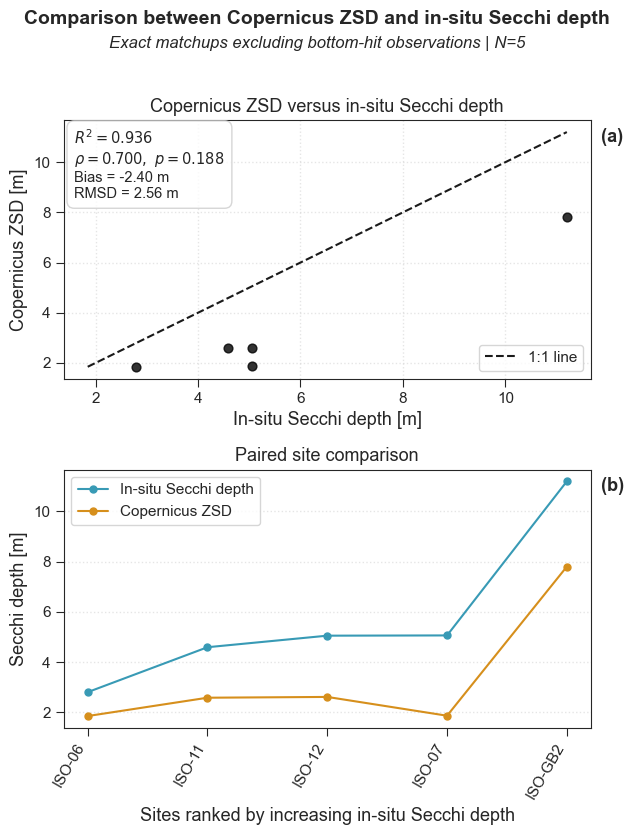

Valid exact-pixel Secchi matchups plotted: 5


In [170]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr, pearsonr

# Select Secchi-depth variables
plot_df = water_samples_Rrs[
    [
        "Site",
        "Secchi_Depth(m)",
        "ZSD_copernicus",
        "Notes"
    ]
].dropna(
    subset=[
        "Site",
        "Secchi_Depth(m)",
        "ZSD_copernicus"
    ]
).copy()

# Exclude bottom-hit observations
plot_df = plot_df[
    ~plot_df["Notes"]
    .astype(str)
    .str.contains(
        "B",
        case=False,
        na=False
    )
].copy()

# Retain only valid positive Secchi-depth values
plot_df = plot_df[
    (plot_df["Secchi_Depth(m)"] > 0)
    & (plot_df["ZSD_copernicus"] > 0)
    ].copy()

# Sort sites by increasing in-situ Secchi depth
plot_df = plot_df.sort_values(
    "Secchi_Depth(m)"
).reset_index(drop=True)

x = plot_df["Secchi_Depth(m)"].to_numpy(
    dtype=float
)

y = plot_df["ZSD_copernicus"].to_numpy(
    dtype=float
)

n = len(plot_df)

if n < 3:
    raise ValueError(
        f"Only {n} valid Secchi matchups remain."
    )

# Correlation statistics
pearson_r, pearson_p = pearsonr(
    x,
    y
)

r2 = pearson_r ** 2

spearman_rho, spearman_p = spearmanr(
    x,
    y
)

# Error statistics
differences = y - x

bias = np.mean(
    differences
)

rmsd = np.sqrt(
    np.mean(differences ** 2)
)

# Compact figure suitable for an A4 column
fig, axes = plt.subplots(
    2,
    1,
    figsize=(6.5, 8.5)
)

# -------------------------------------------------
# Panel A: original-scale scatterplot
# -------------------------------------------------

ax = axes[0]

ax.scatter(
    x,
    y,
    color="black",
    edgecolor="black",
    alpha=0.8,
    s=40
)

min_value = min(
    x.min(),
    y.min()
)

max_value = max(
    x.max(),
    y.max()
)

ax.plot(
    [min_value, max_value],
    [min_value, max_value],
    "k--",
    label="1:1 line"
)

ax.set_xlabel(
    r"In-situ Secchi depth [m]",
    fontsize=13
)

ax.set_ylabel(
    r"Copernicus ZSD [m]",
    fontsize=13
)

ax.set_title(
    "Copernicus ZSD versus in-situ Secchi depth",
    fontsize=13
)

ax.text(
    0.02,
    0.97,
    rf"$R^2={r2:.3f}$"
    "\n"
    rf"$\rho={spearman_rho:.3f},\ p={spearman_p:.3f}$"
    "\n"
    rf"Bias = {bias:.2f} m"
    "\n"
    rf"RMSD = {rmsd:.2f} m",
    transform=ax.transAxes,
    verticalalignment="top",
    fontsize=10.5,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        alpha=0.8,
        edgecolor="0.8",
        linewidth=1
    )
)

ax.legend(
    loc="best",
    fontsize=11
)

ax.grid(
    True,
    linestyle=":",
    alpha=0.5
)

ax.text(
    1.02,
    0.97,
    "(a)",
    transform=ax.transAxes,
    fontsize=13,
    fontweight="bold",
    verticalalignment="top",
    horizontalalignment="left"
)

# -------------------------------------------------
# Panel B: ranked paired site plot
# -------------------------------------------------

ax = axes[1]

site_number = np.arange(
    len(plot_df)
)

ax.plot(
    site_number,
    x,
    marker="o",
    linewidth=1.5,
    markersize=5,
    label="In-situ Secchi depth",
    color="#389ab5"
)

ax.plot(
    site_number,
    y,
    marker="o",
    linewidth=1.5,
    markersize=5,
    label="Copernicus ZSD",
    color="#d68f1c"
)

ax.set_xlabel(
    "Sites ranked by increasing in-situ Secchi depth",
    fontsize=13
)

ax.set_ylabel(
    "Secchi depth [m]",
    fontsize=13
)

ax.set_title(
    "Paired site comparison",
    fontsize=13
)

ax.set_xticks(
    site_number
)

ax.set_xticklabels(
    plot_df["Site"].astype(str),
    rotation=60,
    ha="right",
    fontsize=11
)

ax.grid(
    axis="y",
    linestyle=":",
    alpha=0.5
)

ax.legend(
    fontsize=11
)

ax.text(
    1.02,
    0.97,
    "(b)",
    transform=ax.transAxes,
    fontsize=13,
    fontweight="bold",
    verticalalignment="top",
    horizontalalignment="left"
)

# Overall title
fig.suptitle(
    "Comparison between Copernicus ZSD and in-situ Secchi depth",
    fontsize=14,
    fontweight="bold",
    x=0.5,
    y=0.98
)

fig.text(
    0.5,
    0.95,
    f"Exact matchups excluding bottom-hit observations | N={n}",
    fontsize=12,
    fontweight="normal",
    fontstyle="italic",
    ha="center",
    va="top"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.94]
)

plt.savefig(
    "C:/Users/25298423/PycharmProjects/FinalFigures/"
    "copernicus_zsd_vs_insitu_secchi_exact.png",
    dpi=1200,
    bbox_inches="tight"
)

plt.show()

print(
    f"Valid exact-pixel Secchi matchups plotted: {n}"
)


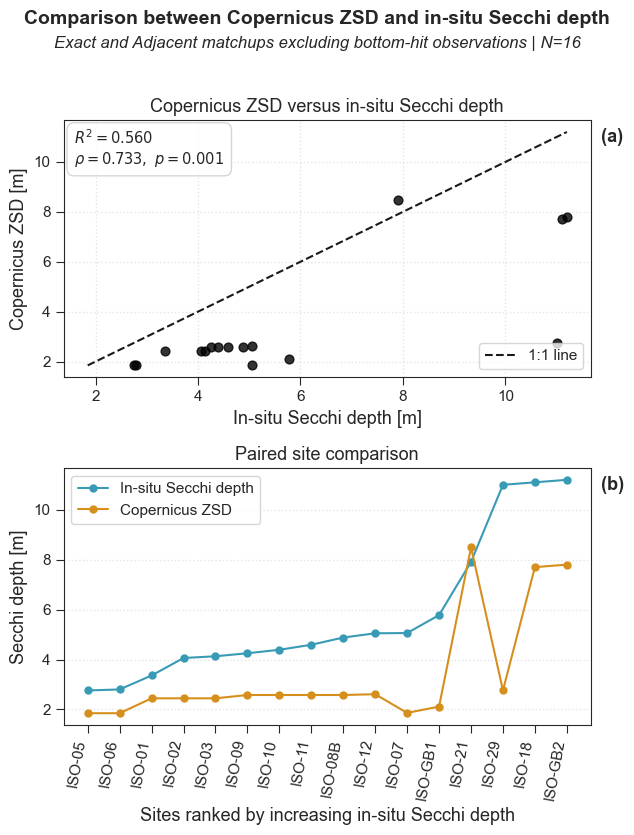

Valid exact-pixel Secchi matchups plotted: 16


In [171]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr, pearsonr

# Select Secchi-depth variables
plot_df = water_samples_Rrs[
    [
        "Site",
        "Secchi_Depth(m)",
        "ZSD_copernicus_adj",
        "Notes"
    ]
].dropna(
    subset=[
        "Site",
        "Secchi_Depth(m)",
        "ZSD_copernicus_adj"
    ]
).copy()

# Exclude bottom-hit observations
plot_df = plot_df[
    ~plot_df["Notes"]
    .astype(str)
    .str.contains(
        "B",
        case=False,
        na=False
    )
].copy()

# Retain only valid positive Secchi-depth values
plot_df = plot_df[
    (plot_df["Secchi_Depth(m)"] > 0)
    & (plot_df["ZSD_copernicus_adj"] > 0)
    ].copy()

# Sort sites by increasing in-situ Secchi depth
plot_df = plot_df.sort_values(
    "Secchi_Depth(m)"
).reset_index(drop=True)

x = plot_df["Secchi_Depth(m)"].to_numpy(
    dtype=float
)

y = plot_df["ZSD_copernicus_adj"].to_numpy(
    dtype=float
)

n = len(plot_df)

if n < 3:
    raise ValueError(
        f"Only {n} valid Secchi matchups remain."
    )

# Correlation statistics
pearson_r, pearson_p = pearsonr(
    x,
    y
)

r2 = pearson_r ** 2

spearman_rho, spearman_p = spearmanr(
    x,
    y
)

# Error statistics
differences = y - x

bias = np.mean(
    differences
)

rmsd = np.sqrt(
    np.mean(differences ** 2)
)

# Compact figure suitable for an A4 column
fig, axes = plt.subplots(
    2,
    1,
    figsize=(6.5, 8.5)
)

# -------------------------------------------------
# Panel A: original-scale scatterplot
# -------------------------------------------------

ax = axes[0]

ax.scatter(
    x,
    y,
    color="black",
    edgecolor="black",
    alpha=0.8,
    s=40
)

min_value = min(
    x.min(),
    y.min()
)

max_value = max(
    x.max(),
    y.max()
)

ax.plot(
    [min_value, max_value],
    [min_value, max_value],
    "k--",
    label="1:1 line"
)

ax.set_xlabel(
    r"In-situ Secchi depth [m]",
    fontsize=13
)

ax.set_ylabel(
    r"Copernicus ZSD [m]",
    fontsize=13
)

ax.set_title(
    "Copernicus ZSD versus in-situ Secchi depth",
    fontsize=13
)

ax.text(
    0.02,
    0.97,
    rf"$R^2={r2:.3f}$"
    "\n"
    rf"$\rho={spearman_rho:.3f},\ p={spearman_p:.3f}$",
    transform=ax.transAxes,
    verticalalignment="top",
    fontsize=10.5,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        alpha=0.8,
        edgecolor="0.8",
        linewidth=1
    )
)

ax.legend(
    loc="best",
    fontsize=11
)

ax.grid(
    True,
    linestyle=":",
    alpha=0.5
)

ax.text(
    1.02,
    0.97,
    "(a)",
    transform=ax.transAxes,
    fontsize=13,
    fontweight="bold",
    verticalalignment="top",
    horizontalalignment="left"
)

# -------------------------------------------------
# Panel B: ranked paired site plot
# -------------------------------------------------

ax = axes[1]

site_number = np.arange(
    len(plot_df)
)

ax.plot(
    site_number,
    x,
    marker="o",
    linewidth=1.5,
    markersize=5,
    label="In-situ Secchi depth",
    color="#389ab5"
)

ax.plot(
    site_number,
    y,
    marker="o",
    linewidth=1.5,
    markersize=5,
    label="Copernicus ZSD",
    color="#d68f1c"
)

ax.set_xlabel(
    "Sites ranked by increasing in-situ Secchi depth",
    fontsize=13
)

ax.set_ylabel(
    "Secchi depth [m]",
    fontsize=13
)

ax.set_title(
    "Paired site comparison",
    fontsize=13
)

ax.set_xticks(
    site_number
)

ax.set_xticklabels(
    plot_df["Site"].astype(str),
    rotation=80,
    ha="right",
    fontsize=11
)

ax.grid(
    axis="y",
    linestyle=":",
    alpha=0.5
)

ax.legend(
    fontsize=11
)

ax.text(
    1.02,
    0.97,
    "(b)",
    transform=ax.transAxes,
    fontsize=13,
    fontweight="bold",
    verticalalignment="top",
    horizontalalignment="left"
)

# Overall title
fig.suptitle(
    "Comparison between Copernicus ZSD and in-situ Secchi depth",
    fontsize=14,
    fontweight="bold",
    x=0.5,
    y=0.98
)

fig.text(
    0.5,
    0.95,
    f"Exact and Adjacent matchups excluding bottom-hit observations | N={n}",
    fontsize=12,
    fontweight="normal",
    fontstyle="italic",
    ha="center",
    va="top"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.94]
)

plt.savefig(
    "C:/Users/25298423/PycharmProjects/FinalFigures/copernicus_zsd_vs_insitu_secchi_adj.png",
    dpi=1200,
    bbox_inches="tight"
)

plt.show()

print(
    f"Valid exact-pixel Secchi matchups plotted: {n}"
)


In [172]:
water_samples_Rrs[['Site','Secchi_Depth(m)','ZSD_copernicus_adj', 'ZSD_distance_to_selected_pixel_m','ZSD_selected_pixel_lat','ZSD_selected_pixel_lon']]

,Site,Secchi_Depth(m),ZSD_copernicus_adj,ZSD_distance_to_selected_pixel_m,ZSD_selected_pixel_lat,ZSD_selected_pixel_lon
0,ISO-01,3.36,2.444638,2044.961941,53.244793,-9.036457
1,ISO-02,4.06,2.444638,1762.983512,53.244793,-9.036457
2,ISO-03,4.13,2.444638,665.840259,53.244793,-9.036457
3,ISO-04,NaN,2.444638,343.726079,53.244793,-9.036457
4,ISO-05,2.76,1.847745,780.886224,53.244793,-8.984374
5,ISO-06,2.80,1.847745,223.278135,53.244793,-8.984374
6,ISO-07,5.06,1.860473,251.214021,53.244793,-8.994791
7,ISO-08A,2.53,NaN,NaN,NaN,NaN
8,ISO-08B,4.88,2.577679,3160.246058,53.182293,-8.973957
9,ISO-09,4.25,2.577679,2033.782147,53.182293,-8.973957


In [173]:
water_samples_Rrs.columns

Index(['Site', 'CDOM_a412_m-1', 'CDOM_a434_m-1', 'CDOM_a443_m-1',
       'CDOM_a490_m-1', 'Chl_a_[ug/L]', 'Chl_b_[ug/L]', 'Chl_c_[ug/L]', 'Date',
       'Latitude',
       ...
       'CDM_matchup_source', 'CDM_anomaly', 'CDM_anomaly_adj',
       'Secchi_Depth(m)', 'ZSD_copernicus', 'ZSD_copernicus_adj',
       'ZSD_selected_pixel_lat', 'ZSD_selected_pixel_lon',
       'ZSD_distance_to_selected_pixel_m', 'ZSD_matchup_source'],
      dtype='object', length=107)

# Copernicus Rrs Bands Analysis

In [177]:
import os
import glob
import numpy as np
import pandas as pd
import xarray as xr


def calculate_distance_m(lat1, lon1, lat2, lon2):
    """
    Approximate distance between two latitude/longitude coordinates
    in metres.
    """
    metres_per_degree_lat = 111120.0
    metres_per_degree_lon = (
            111120.0 * np.cos(np.radians(lat1))
    )

    delta_lat = lat2 - lat1
    delta_lon = lon2 - lon1

    return np.sqrt(
        (delta_lat * metres_per_degree_lat) ** 2
        + (delta_lon * metres_per_degree_lon) ** 2
    )


def extract_common_rrs_matchups(
        datasets,
        bands,
        stations_df,
        radius_cells=2
):
    """
    Extract all Rrs bands using one common matchup pixel per site.

    Strict analysis:
        Same calendar day.
        Nearest nominal pixel centre.
        The exact pixel must have finite values for every requested band.

    Expanded analysis:
        Same calendar day.
        Exact pixel used when all requested bands are valid.
        If any requested band is invalid at the exact pixel, search
        a local window and select the nearest pixel with finite values
        for every requested band.

    Site-level metadata is recorded once.
    """

    out = stations_df.copy()

    # -------------------------------------------------------------
    # Initialise the two Rrs value columns for every band
    # -------------------------------------------------------------
    for band in bands:
        out[f"RRS{band}_copernicus"] = np.nan
        out[f"RRS{band}_copernicus_adj"] = np.nan

    # -------------------------------------------------------------
    # Initialise site-level metadata once
    # -------------------------------------------------------------
    out["RRS_selected_pixel_lat"] = np.nan
    out["RRS_selected_pixel_lon"] = np.nan
    out["RRS_distance_to_selected_pixel_m"] = np.nan
    out["RRS_matchup_source"] = pd.NA
    out["RRS_selected_satellite_date"] = pd.NaT

    # -------------------------------------------------------------
    # Use the first band as the reference grid
    # -------------------------------------------------------------
    reference_band = bands[0]
    reference_ds = datasets[reference_band]

    lat_vals = np.asarray(
        reference_ds["latitude"].values,
        dtype=float
    )

    lon_vals = np.asarray(
        reference_ds["longitude"].values,
        dtype=float
    )

    # -------------------------------------------------------------
    # Confirm that all bands use the same spatial grid
    # -------------------------------------------------------------
    for band in bands:

        ds = datasets[band]

        if not np.allclose(
                ds["latitude"].values,
                lat_vals
        ):
            raise ValueError(
                f"Latitude grid differs for RRS{band}"
            )

        if not np.allclose(
                ds["longitude"].values,
                lon_vals
        ):
            raise ValueError(
                f"Longitude grid differs for RRS{band}"
            )

    # -------------------------------------------------------------
    # Store time arrays and normalised calendar dates
    # -------------------------------------------------------------
    time_values = {}
    time_days = {}

    for band in bands:
        ds = datasets[band]

        time_values[band] = pd.to_datetime(
            ds["time"].values
        )

        time_days[band] = (
            time_values[band].normalize()
        )

    # -------------------------------------------------------------
    # Helper function for extracting one band value
    # -------------------------------------------------------------
    def get_band_value(
            band,
            time_idx,
            lat_idx,
            lon_idx
    ):
        ds = datasets[band]
        var_name = f"RRS{band}"

        value = ds[var_name].isel(
            time=time_idx,
            latitude=lat_idx,
            longitude=lon_idx
        ).values

        return float(
            np.asarray(value).squeeze()
        )

    # -------------------------------------------------------------
    # Process each sampling site
    # -------------------------------------------------------------
    for idx, row in out.iterrows():

        target_date = pd.to_datetime(
            row["Date"]
        )

        target_day = target_date.normalize()

        target_lat = float(
            row["latitude_dec"]
        )

        target_lon = float(
            row["longitude_dec"]
        )

        # ---------------------------------------------------------
        # Find a same-calendar-day satellite record for every band
        # ---------------------------------------------------------
        time_indices = {}
        same_day_available = True

        for band in bands:

            matching_indices = np.where(
                time_days[band] == target_day
            )[0]

            if len(matching_indices) == 0:
                same_day_available = False
                break

            # Use the first record when the product is daily.
            # No time-difference column is calculated.
            time_indices[band] = matching_indices[0]

        if not same_day_available:
            continue

        # ---------------------------------------------------------
        # Find the nearest nominal grid-cell centre
        # ---------------------------------------------------------
        nearest_lat_idx = np.abs(
            lat_vals - target_lat
        ).argmin()

        nearest_lon_idx = np.abs(
            lon_vals - target_lon
        ).argmin()

        exact_pixel_lat = float(
            lat_vals[nearest_lat_idx]
        )

        exact_pixel_lon = float(
            lon_vals[nearest_lon_idx]
        )

        exact_distance_m = calculate_distance_m(
            target_lat,
            target_lon,
            exact_pixel_lat,
            exact_pixel_lon
        )

        # ---------------------------------------------------------
        # Check whether every Rrs band is valid at the exact pixel
        # ---------------------------------------------------------
        exact_values = {}

        for band in bands:
            exact_values[band] = get_band_value(
                band=band,
                time_idx=time_indices[band],
                lat_idx=nearest_lat_idx,
                lon_idx=nearest_lon_idx
            )

        exact_pixel_is_valid = all(
            np.isfinite(exact_values[band])
            for band in bands
        )

        # ---------------------------------------------------------
        # Case 1: all bands valid at the exact pixel
        # ---------------------------------------------------------
        if exact_pixel_is_valid:

            selected_lat_idx = nearest_lat_idx
            selected_lon_idx = nearest_lon_idx
            selected_lat = exact_pixel_lat
            selected_lon = exact_pixel_lon
            selected_distance_m = exact_distance_m
            selected_source = "exact"
            selected_values = exact_values

            for band in bands:
                out.loc[
                    idx,
                    f"RRS{band}_copernicus"
                ] = exact_values[band]

                out.loc[
                    idx,
                    f"RRS{band}_copernicus_adj"
                ] = exact_values[band]

        # ---------------------------------------------------------
        # Case 2: search for one common local fallback pixel
        # ---------------------------------------------------------
        else:

            lat_start = max(
                0,
                nearest_lat_idx - radius_cells
            )

            lat_end = min(
                len(lat_vals),
                nearest_lat_idx + radius_cells + 1
            )

            lon_start = max(
                0,
                nearest_lon_idx - radius_cells
            )

            lon_end = min(
                len(lon_vals),
                nearest_lon_idx + radius_cells + 1
            )

            candidate_pixels = []

            for candidate_lat_idx in range(
                    lat_start,
                    lat_end
            ):
                for candidate_lon_idx in range(
                        lon_start,
                        lon_end
                ):

                    candidate_values = {}

                    for band in bands:
                        candidate_values[band] = (
                            get_band_value(
                                band=band,
                                time_idx=time_indices[band],
                                lat_idx=candidate_lat_idx,
                                lon_idx=candidate_lon_idx
                            )
                        )

                    # The fallback pixel must be valid for every band.
                    all_bands_valid = all(
                        np.isfinite(
                            candidate_values[band]
                        )
                        for band in bands
                    )

                    if not all_bands_valid:
                        continue

                    candidate_lat = float(
                        lat_vals[candidate_lat_idx]
                    )

                    candidate_lon = float(
                        lon_vals[candidate_lon_idx]
                    )

                    candidate_distance_m = (
                        calculate_distance_m(
                            target_lat,
                            target_lon,
                            candidate_lat,
                            candidate_lon
                        )
                    )

                    candidate_pixels.append({
                        "lat_idx": candidate_lat_idx,
                        "lon_idx": candidate_lon_idx,
                        "lat": candidate_lat,
                        "lon": candidate_lon,
                        "distance_m": candidate_distance_m,
                        "values": candidate_values
                    })

            # No local pixel had valid values for every band.
            if len(candidate_pixels) == 0:
                continue

            selected_pixel = min(
                candidate_pixels,
                key=lambda x: x["distance_m"]
            )

            selected_lat_idx = selected_pixel["lat_idx"]
            selected_lon_idx = selected_pixel["lon_idx"]
            selected_lat = selected_pixel["lat"]
            selected_lon = selected_pixel["lon"]
            selected_distance_m = selected_pixel["distance_m"]
            selected_source = "local_fallback"
            selected_values = selected_pixel["values"]

            # Exact columns remain NaN for fallback sites.
            # The expanded columns receive the common fallback values.
            for band in bands:
                out.loc[
                    idx,
                    f"RRS{band}_copernicus_adj"
                ] = selected_values[band]

        # ---------------------------------------------------------
        # Store site-level metadata once
        # ---------------------------------------------------------
        out.loc[
            idx,
            "RRS_selected_pixel_lat"
        ] = selected_lat

        out.loc[
            idx,
            "RRS_selected_pixel_lon"
        ] = selected_lon

        out.loc[
            idx,
            "RRS_distance_to_selected_pixel_m"
        ] = selected_distance_m

        out.loc[
            idx,
            "RRS_matchup_source"
        ] = selected_source

        # Store the matched satellite date once per site.
        # This is not a time-difference column.
        reference_time_idx = time_indices[
            reference_band
        ]

        out.loc[
            idx,
            "RRS_selected_satellite_date"
        ] = time_values[
            reference_band
        ][reference_time_idx]

    return out


# Load the in-situ hyperspectral site means
all_site_means = pd.read_csv(
    "hyperspectral_sampling_means.csv"
)

# Prepare station coordinate names
results_df = all_site_means.rename(
    columns={
        "Latitude": "latitude_dec",
        "Longitude": "longitude_dec"
    }
).copy()

results_df["Date"] = pd.to_datetime(
    results_df["Date"]
)

# Requested Rrs bands
bands = [
    400, 412, 443, 490, 510,
    560, 620, 665, 674, 681, 709
]

# Open all bands before extracting matchups.
# This allows one common pixel to be selected across all bands.
datasets = {}

try:

    for band in bands:

        folder_path = os.path.join(
            "/home/jovyan/notmessedup_directory/in-situ/",
            f"RRS{band}"
        )

        files = glob.glob(
            os.path.join(
                folder_path,
                "*.nc"
            )
        )

        if len(files) == 0:
            raise FileNotFoundError(
                f"No NetCDF file found for RRS{band}"
            )

        file_path = files[0]

        ds = xr.open_dataset(
            file_path
        )

        var_name = f"RRS{band}"

        if var_name not in ds.data_vars:
            ds.close()

            raise KeyError(
                f"{var_name} was not found in "
                f"{os.path.basename(file_path)}. "
                f"Available variables: "
                f"{list(ds.data_vars)}"
            )

        datasets[band] = ds

    # Extract all bands using one common pixel per site
    results_df = extract_common_rrs_matchups(
        datasets=datasets,
        bands=bands,
        stations_df=results_df,
        radius_cells=2
    )

finally:

    # Close all datasets after extraction
    for ds in datasets.values():
        ds.close()

# Check the output
print(
    "Number of sites:",
    len(results_df)
)

print(
    "Exact common-pixel matchups:",
    (
            results_df["RRS_matchup_source"]
            == "exact"
    ).sum()
)

print(
    "Local fallback common-pixel matchups:",
    (
            results_df["RRS_matchup_source"]
            == "local_fallback"
    ).sum()
)

print(
    results_df[
        [
            "Site",
            "Date",
            "latitude_dec",
            "longitude_dec",
            "RRS_selected_pixel_lat",
            "RRS_selected_pixel_lon",
            "RRS_distance_to_selected_pixel_m",
            "RRS_matchup_source",
            "RRS_selected_satellite_date",
            "RRS400_copernicus",
            "RRS400_copernicus_adj",
            "RRS709_copernicus",
            "RRS709_copernicus_adj"
        ]
    ].head()
)


Number of sites: 33
Exact common-pixel matchups: 17
Local fallback common-pixel matchups: 10
      Site       Date  latitude_dec  longitude_dec  RRS_selected_pixel_lat  \
0   ISO-01 2026-04-28     53.263103      -9.039540                     NaN   
1   ISO-02 2026-04-28     53.260653      -9.037058               53.247223   
2   ISO-03 2026-04-28     53.250777      -9.036935               53.247223   
3   ISO-04 2026-04-28     53.244920      -9.041622               53.247223   
4  ISO-08A 2026-04-28     53.141730      -8.936175                     NaN   

   RRS_selected_pixel_lon  RRS_distance_to_selected_pixel_m  \
0                     NaN                               NaN   
1               -9.036107                       1493.690647   
2               -9.036107                        398.749152   
3               -9.041662                        255.912263   
4                     NaN                               NaN   

  RRS_matchup_source RRS_selected_satellite_date  RRS400_co

In [178]:
results_df

,Site,Date,latitude_dec,longitude_dec,320,322,324,326,328,330,...,RRS674_copernicus_adj,RRS681_copernicus,RRS681_copernicus_adj,RRS709_copernicus,RRS709_copernicus_adj,RRS_selected_pixel_lat,RRS_selected_pixel_lon,RRS_distance_to_selected_pixel_m,RRS_matchup_source,RRS_selected_satellite_date
0,ISO-01,2026-04-28,53.263103,-9.039540,-0.005708,-0.005151,-0.004596,-0.004042,-0.003492,-0.002992,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaT
1,ISO-02,2026-04-28,53.260653,-9.037058,-0.005581,-0.005033,-0.004488,-0.003945,-0.003406,-0.002917,...,0.000036,NaN,0.000125,NaN,0.000238,53.247223,-9.036107,1493.690647,local_fallback,2026-04-28
2,ISO-03,2026-04-28,53.250777,-9.036935,-0.005823,-0.005282,-0.004743,-0.004205,-0.003671,-0.003188,...,0.000036,NaN,0.000125,NaN,0.000238,53.247223,-9.036107,398.749152,local_fallback,2026-04-28
3,ISO-04,2026-04-28,53.244920,-9.041622,-0.006524,-0.005931,-0.005342,-0.004754,-0.004172,-0.003647,...,0.000036,0.000125,0.000125,0.000238,0.000238,53.247223,-9.041662,255.912263,exact,2026-04-28
4,ISO-08A,2026-04-28,53.141730,-8.936175,-0.006117,-0.005541,-0.004969,-0.004397,-0.003830,-0.003316,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaT
5,ISO-08B,2026-04-28,53.158338,-8.948395,-0.006501,-0.005923,-0.005347,-0.004772,-0.004199,-0.003677,...,0.002834,NaN,0.003053,NaN,0.004118,53.163887,-8.947218,621.574921,local_fallback,2026-04-28
6,ISO-09,2026-04-28,53.167728,-8.955467,-0.006526,-0.005954,-0.005383,-0.004811,-0.004237,-0.003708,...,0.002834,NaN,0.003053,NaN,0.004118,53.163887,-8.952774,462.975091,local_fallback,2026-04-28
7,ISO-10,2026-04-28,53.175897,-8.962217,-0.007164,-0.006481,-0.005800,-0.005120,-0.004443,-0.003823,...,0.002515,NaN,0.002590,NaN,0.002989,53.180557,-8.963884,529.619778,local_fallback,2026-04-28
8,ISO-11,2026-04-28,53.180213,-8.970387,-0.006365,-0.005768,-0.005169,-0.004569,-0.003966,-0.003403,...,0.002515,0.002590,0.002590,0.002989,0.002989,53.180557,-8.969440,73.733309,exact,2026-04-28
9,ISO-12,2026-04-28,53.179393,-8.979265,-0.006719,-0.006101,-0.005481,-0.004858,-0.004228,-0.003637,...,0.001742,0.001853,0.001853,0.002251,0.002251,53.180557,-8.980552,155.176461,exact,2026-04-28


In [181]:
list(results_df.columns)

['Site',
 'Date',
 'latitude_dec',
 'longitude_dec',
 '320',
 '322',
 '324',
 '326',
 '328',
 '330',
 '332',
 '334',
 '336',
 '338',
 '340',
 '342',
 '344',
 '346',
 '348',
 '350',
 '352',
 '354',
 '356',
 '358',
 '360',
 '362',
 '364',
 '366',
 '368',
 '370',
 '372',
 '374',
 '376',
 '378',
 '380',
 '382',
 '384',
 '386',
 '388',
 '390',
 '392',
 '394',
 '396',
 '398',
 '400',
 '402',
 '404',
 '406',
 '408',
 '410',
 '412',
 '414',
 '416',
 '418',
 '420',
 '422',
 '424',
 '426',
 '428',
 '430',
 '432',
 '434',
 '436',
 '438',
 '440',
 '442',
 '443',
 '444',
 '446',
 '448',
 '450',
 '452',
 '454',
 '456',
 '458',
 '460',
 '462',
 '464',
 '466',
 '468',
 '470',
 '472',
 '474',
 '476',
 '478',
 '480',
 '482',
 '484',
 '486',
 '488',
 '490',
 '492',
 '494',
 '496',
 '498',
 '500',
 '502',
 '504',
 '506',
 '508',
 '510',
 '512',
 '514',
 '516',
 '518',
 '520',
 '522',
 '524',
 '526',
 '528',
 '530',
 '532',
 '534',
 '536',
 '538',
 '540',
 '542',
 '544',
 '546',
 '548',
 '550',
 '552',
 '5

In [188]:
wavelength_cols = [col for col in results_df.columns if col.isdigit()]
nan_counts = results_df[wavelength_cols].isna().sum()
print("Columns with NaN counts:")
print(nan_counts[nan_counts > 0])
print(f"\nTotal columns checked: {len(wavelength_cols)}")
print(f"Columns with at least one NaN: {(nan_counts > 0).sum()}")

Columns with NaN counts:
Series([], dtype: int64)

Total columns checked: 321
Columns with at least one NaN: 0


In [189]:
target_wavelengths = [443, 665, 681, 709]
wavelength_cols = [col for col in results_df.columns if col.isdigit()]
wavelengths = np.array([float(col) for col in wavelength_cols], dtype=float)
sorted_indices = np.argsort(wavelengths)
wavelengths = wavelengths[sorted_indices]
wavelength_cols = [wavelength_cols[i] for i in sorted_indices]

spectral_data = results_df[wavelength_cols].to_numpy(dtype=float)

for target_wl in target_wavelengths:
    # Directly interpolate row by row
    results_df[str(target_wl)] = [
        np.interp(target_wl, wavelengths, row, left=np.nan, right=np.nan)
        for row in spectral_data
    ]

In [191]:
keep_wavelengths = {'400', '412', '443', '490', '510', '560', '620', '665', '674', '681', '709'}

cols_to_drop = [
    col for col in results_df.columns
    if col.isdigit() and col not in keep_wavelengths
]

results_df = results_df.drop(columns=cols_to_drop)

In [193]:
results_df.drop(columns=['RRS_selected_satellite_date'], inplace=True)

In [194]:
results_df

,Site,Date,latitude_dec,longitude_dec,400,412,443,490,510,560,...,RRS674_copernicus,RRS674_copernicus_adj,RRS681_copernicus,RRS681_copernicus_adj,RRS709_copernicus,RRS709_copernicus_adj,RRS_selected_pixel_lat,RRS_selected_pixel_lon,RRS_distance_to_selected_pixel_m,RRS_matchup_source
0,ISO-01,2026-04-28,53.263103,-9.039540,0.000497,0.000563,0.000782,0.001500,0.001977,0.003770,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
1,ISO-02,2026-04-28,53.260653,-9.037058,0.000532,0.000611,0.000884,0.001653,0.002088,0.003621,...,NaN,0.000036,NaN,0.000125,NaN,0.000238,53.247223,-9.036107,1493.690647,local_fallback
2,ISO-03,2026-04-28,53.250777,-9.036935,0.000321,0.000425,0.000744,0.001447,0.001806,0.002944,...,NaN,0.000036,NaN,0.000125,NaN,0.000238,53.247223,-9.036107,398.749152,local_fallback
3,ISO-04,2026-04-28,53.244920,-9.041622,0.000272,0.000402,0.000768,0.001461,0.001784,0.002701,...,0.000036,0.000036,0.000125,0.000125,0.000238,0.000238,53.247223,-9.041662,255.912263,exact
4,ISO-08A,2026-04-28,53.141730,-8.936175,0.000322,0.000387,0.000520,0.000794,0.000981,0.001723,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
5,ISO-08B,2026-04-28,53.158338,-8.948395,0.000162,0.000269,0.000557,0.001148,0.001478,0.002336,...,NaN,0.002834,NaN,0.003053,NaN,0.004118,53.163887,-8.947218,621.574921,local_fallback
6,ISO-09,2026-04-28,53.167728,-8.955467,0.000405,0.000531,0.000877,0.001569,0.001925,0.002824,...,NaN,0.002834,NaN,0.003053,NaN,0.004118,53.163887,-8.952774,462.975091,local_fallback
7,ISO-10,2026-04-28,53.175897,-8.962217,0.000937,0.001047,0.001297,0.001795,0.002057,0.002653,...,NaN,0.002515,NaN,0.002590,NaN,0.002989,53.180557,-8.963884,529.619778,local_fallback
8,ISO-11,2026-04-28,53.180213,-8.970387,0.000777,0.000861,0.001041,0.001421,0.001605,0.002033,...,0.002515,0.002515,0.002590,0.002590,0.002989,0.002989,53.180557,-8.969440,73.733309,exact
9,ISO-12,2026-04-28,53.179393,-8.979265,0.000870,0.000985,0.001256,0.001856,0.002154,0.002816,...,0.001742,0.001742,0.001853,0.001853,0.002251,0.002251,53.180557,-8.980552,155.176461,exact


In [195]:
import numpy as np
import pandas as pd


def calculate_copernicus_rrs_metrics(
    df,
    wavelengths=(
        400, 412, 443, 490, 510,
        560, 620, 665, 674, 681, 709
    ),
    minimum_absolute_insitu=0.0
):
    """
    Calculate RMSD, MdAPD and MdPD for Copernicus Rrs bands.

    In-situ columns:
        "400", "412", "443", etc.

    Copernicus columns:
        "RRS400_copernicus"
        "RRS400_copernicus_adj"

    The exact dataset uses the exact pixel only.
    The exact_plus_adjacent dataset uses the exact pixel where valid
    and the local fallback pixel where the exact pixel was unavailable.
    """

    matchup_columns = {
        "Exact": "_copernicus",
        "Exact+Adjacent": "_copernicus_adj"
    }

    results = []

    for wavelength in wavelengths:

        insitu_col = str(wavelength)

        if insitu_col not in df.columns:
            print(
                f"Warning: in-situ column '{insitu_col}' "
                "was not found."
            )
            continue

        for matchup_name, satellite_suffix in matchup_columns.items():

            satellite_col = (
                f"RRS{wavelength}{satellite_suffix}"
            )

            if satellite_col not in df.columns:
                print(
                    f"Warning: satellite column "
                    f"'{satellite_col}' was not found."
                )
                continue

            # Keep only the paired in-situ and satellite values
            paired = df[
                [insitu_col, satellite_col]
            ].copy()

            paired[insitu_col] = pd.to_numeric(
                paired[insitu_col],
                errors="coerce"
            )

            paired[satellite_col] = pd.to_numeric(
                paired[satellite_col],
                errors="coerce"
            )

            paired = paired.replace(
                [np.inf, -np.inf],
                np.nan
            ).dropna()

            # Percentage metrics cannot be calculated when the
            # in-situ reference is zero.
            paired = paired[
                np.abs(paired[insitu_col])
                > minimum_absolute_insitu
            ]

            n = len(paired)

            if n == 0:
                results.append({
                    "Wavelength": wavelength,
                    "Matchup": matchup_name,
                    "N": 0,
                    "RMSD": np.nan,
                    "MdAPD": np.nan,
                    "MdPD": np.nan
                })
                continue

            insitu_values = paired[
                insitu_col
            ].to_numpy(dtype=float)

            satellite_values = paired[
                satellite_col
            ].to_numpy(dtype=float)

            # Difference defined as satellite minus in-situ
            difference = (
                satellite_values
                - insitu_values
            )

            # RMSD in the original Rrs units
            rmsd = np.sqrt(
                np.mean(difference ** 2)
            )

            # Percentage difference relative to in-situ Rrs
            percentage_difference = (
                100.0
                * difference
                / insitu_values
            )

            mdpd = np.median(
                percentage_difference
            )

            mdapd = np.median(
                np.abs(percentage_difference)
            )

            results.append({
                "Wavelength": wavelength,
                "Matchup": matchup_name,
                "N": n,
                "RMSD": rmsd,
                "MdAPD": mdapd,
                "MdPD": mdpd
            })

    return (
        pd.DataFrame(results)
        .sort_values(
            ["Wavelength", "Matchup"]
        )
        .reset_index(drop=True)
    )


# Run the analysis using your corrected Copernicus Rrs dataframe
copernicus_rrs_metrics = (
    calculate_copernicus_rrs_metrics(
        results_df
    )
)

print(copernicus_rrs_metrics)


    Wavelength         Matchup   N      RMSD       MdAPD       MdPD
0          400           Exact  17  0.002581   69.869558   8.544489
1          400  Exact+Adjacent  27  0.002310   69.869558  10.303828
2          412           Exact  17  0.002551   95.421525 -18.670373
3          412  Exact+Adjacent  27  0.002296   79.481394  -9.354449
4          443           Exact  17  0.002502  106.669445 -23.277286
5          443  Exact+Adjacent  27  0.002211  105.075517 -11.545736
6          490           Exact  17  0.002412  100.284603 -30.967449
7          490  Exact+Adjacent  27  0.002107   73.417292 -23.049086
8          510           Exact  17  0.002402   83.466598 -27.311113
9          510  Exact+Adjacent  27  0.002104   80.076714 -19.714726
10         560           Exact  17  0.002299   54.760944 -13.159770
11         560  Exact+Adjacent  27  0.002108   51.207256 -15.199926
12         620           Exact  17  0.002171  124.747861 -44.017082
13         620  Exact+Adjacent  27  0.002020  12

In [200]:
copernicus_rrs_metrics_pivoted = copernicus_rrs_metrics.pivot(
    index="Wavelength",
    columns="Matchup",
    values=["N", "RMSD", "MdAPD", "MdPD"]
)

copernicus_rrs_metrics_pivoted.columns = [
    f"{metric}_{matchup.lower().replace('+', '')}"
    for metric, matchup in copernicus_rrs_metrics_pivoted.columns
]

copernicus_rrs_metrics_pivoted = copernicus_rrs_metrics_pivoted.rename(columns={
    "N_Exact": "N_exact",
    "RMSD_Exact": "RMSD_exact",
    "MdAPD_Exact": "MdAPD_exact",
    "MdPD_Exact": "MdPD_exact",
    "N_Exact+Adjacent": "N_exactadjacent",
    "RMSD_Exact+Adjacent": "RMSD_exactadjacent",
    "MdAPD_Exact+Adjacent": "MdAPD_exactadjacent",
    "MdPD_Exact+Adjacent": "MdPD_exactadjacent"
})

desired_cols = [
    "N_exact", "RMSD_exact", "MdAPD_exact", "MdPD_exact",
    "N_exactadjacent", "RMSD_exactadjacent", "MdAPD_exactadjacent", "MdPD_exactadjacent"
]

copernicus_rrs_metrics_pivoted = copernicus_rrs_metrics_pivoted[
    [c for c in desired_cols if c in copernicus_rrs_metrics_pivoted.columns]
]

# Apply specific rounding rules per metric type
rounding_dict = {}
for col in copernicus_rrs_metrics_pivoted.columns:
    if "RMSD" in col:
        rounding_dict[col] = 4
    elif "MdAPD" in col or "MdPD" in col:
        rounding_dict[col] = 2
    elif "N" in col:
        rounding_dict[col] = 0

copernicus_rrs_metrics_pivoted = copernicus_rrs_metrics_pivoted.round(rounding_dict)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

copernicus_rrs_metrics_pivoted

,N_exact,RMSD_exact,MdAPD_exact,MdPD_exact,N_exactadjacent,RMSD_exactadjacent,MdAPD_exactadjacent,MdPD_exactadjacent
Wavelength,,,,,,,,
400,17.0,0.0026,69.87,8.54,27.0,0.0023,69.87,10.30
412,17.0,0.0026,95.42,-18.67,27.0,0.0023,79.48,-9.35
443,17.0,0.0025,106.67,-23.28,27.0,0.0022,105.08,-11.55
490,17.0,0.0024,100.28,-30.97,27.0,0.0021,73.42,-23.05
510,17.0,0.0024,83.47,-27.31,27.0,0.0021,80.08,-19.71
560,17.0,0.0023,54.76,-13.16,27.0,0.0021,51.21,-15.20
620,17.0,0.0022,124.75,-44.02,27.0,0.0020,122.63,-47.57
665,17.0,0.0023,266.15,-95.44,27.0,0.0021,230.68,-95.44
674,17.0,0.0023,266.78,-96.40,27.0,0.0021,232.31,-96.69


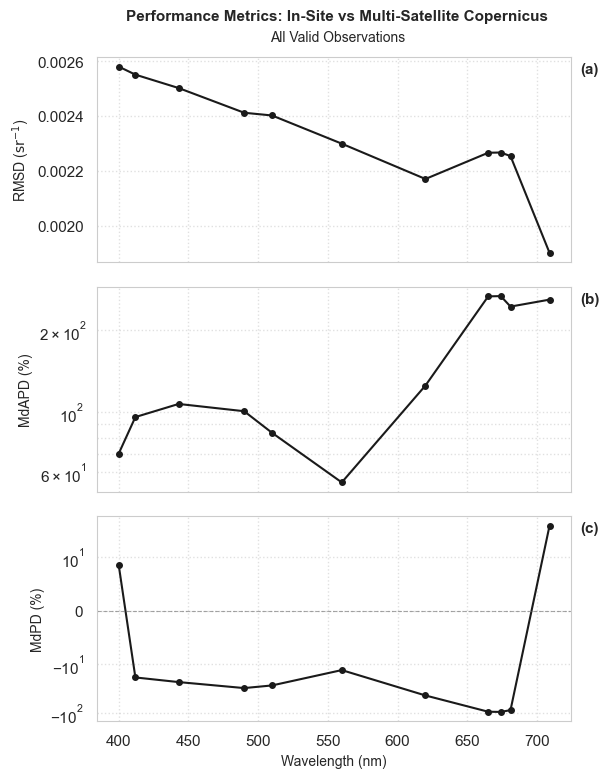

Saved: C:/Users/25298423/PycharmProjects/FinalFigures\PerformanceMetrics_Copernicus_1km_Exact.png


In [206]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Output folder
output_folder = (
    "C:/Users/25298423/PycharmProjects/FinalFigures"
)

os.makedirs(
    output_folder,
    exist_ok=True
)


def make_copernicus_performance_figure(
        metrics_df,
        matchup_name,
        subtitle,
        output_filename
):
    """
    Create one three-panel performance-metrics figure
    for one Copernicus Rrs matchup dataset.
    """

    # Select one matchup dataset
    plot_df = metrics_df[
        metrics_df["Matchup"] == matchup_name
        ].copy()

    plot_df = plot_df.sort_values(
        "Wavelength"
    ).reset_index(drop=True)

    # Ensure metric columns are numeric
    metric_columns = [
        "Wavelength",
        "RMSD",
        "MdAPD",
        "MdPD"
    ]

    for column in metric_columns:
        plot_df[column] = pd.to_numeric(
            plot_df[column],
            errors="coerce"
        )

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(6, 8),
        sharex=True
    )

    # ---------------------------------------------------------
    # 1. RMSD plot
    # ---------------------------------------------------------
    axes[0].plot(
        plot_df["Wavelength"],
        plot_df["RMSD"],
        marker="o",
        color="k",
        linewidth=1.5,
        markersize=4
    )

    axes[0].set_ylabel(
        r"RMSD ($\mathrm{sr^{-1}}$)",
        fontsize=10
    )

    axes[0].grid(
        True,
        linestyle=":",
        alpha=0.6
    )

    axes[0].text(
        1.02,
        0.92,
        "(a)",
        transform=axes[0].transAxes,
        fontsize=11,
        fontweight="bold"
    )

    # ---------------------------------------------------------
    # 2. MdAPD plot
    # ---------------------------------------------------------
    axes[1].plot(
        plot_df["Wavelength"],
        plot_df["MdAPD"],
        marker="o",
        color="k",
        linewidth=1.5,
        markersize=4
    )

    axes[1].set_yscale(
        "log"
    )

    axes[1].set_ylabel(
        "MdAPD (%)",
        fontsize=10
    )

    axes[1].grid(
        True,
        linestyle=":",
        alpha=0.6,
        which="both"
    )

    axes[1].text(
        1.02,
        0.92,
        "(b)",
        transform=axes[1].transAxes,
        fontsize=11,
        fontweight="bold"
    )

    # ---------------------------------------------------------
    # 3. MdPD plot
    # ---------------------------------------------------------
    axes[2].plot(
        plot_df["Wavelength"],
        plot_df["MdPD"],
        marker="o",
        color="k",
        linewidth=1.5,
        markersize=4
    )

    axes[2].set_yscale(
        "symlog",
        linthresh=10
    )

    axes[2].set_ylabel(
        "MdPD (%)",
        fontsize=10
    )

    axes[2].set_xlabel(
        "Wavelength (nm)",
        fontsize=10
    )

    axes[2].grid(
        True,
        linestyle=":",
        alpha=0.6,
        which="both"
    )

    axes[2].text(
        1.02,
        0.92,
        "(c)",
        transform=axes[2].transAxes,
        fontsize=11,
        fontweight="bold"
    )

    # Horizontal zero line for MdPD
    axes[2].axhline(
        0,
        color="gray",
        linestyle="--",
        linewidth=0.8,
        alpha=0.7
    )

    # Titles
    fig.suptitle(
        "Performance Metrics: In-Site vs Multi-Satellite Copernicus",
        fontsize=11,
        fontweight="bold",
        x=0.53,
        y=0.97
    )

    fig.text(
        0.53,
        0.93,
        subtitle,
        ha="center",
        fontsize=10,
        style="normal"
    )

    # Leave space for the two-line title
    fig.subplots_adjust(top=0.91, bottom=0.08, left=0.13, right=0.92, hspace=0.12)

    output_path = os.path.join(
        output_folder,
        output_filename
    )

    plt.savefig(
        output_path,
        dpi=1200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print(
        f"Saved: {output_path}"
    )


# Figure 1: strict exact-pixel matchups
make_copernicus_performance_figure(
    metrics_df=copernicus_rrs_metrics,
    matchup_name="Exact",
    subtitle="All Valid Observations",
    output_filename=(
        "PerformanceMetrics_Copernicus_1km_Exact.png"
    )
)




      Site  latitude_dec  longitude_dec  dist_to_shore_m
0   ISO-01     53.263103      -9.039540       486.397123
1   ISO-02     53.260653      -9.037058       673.060186
2   ISO-03     53.250777      -9.036935       991.930008
3   ISO-04     53.244920      -9.041622      1148.408817
4  ISO-08A     53.141730      -8.936175       147.016236
Nearshore sites, <= 420 m: 15
Farther sites, > 420 m: 18


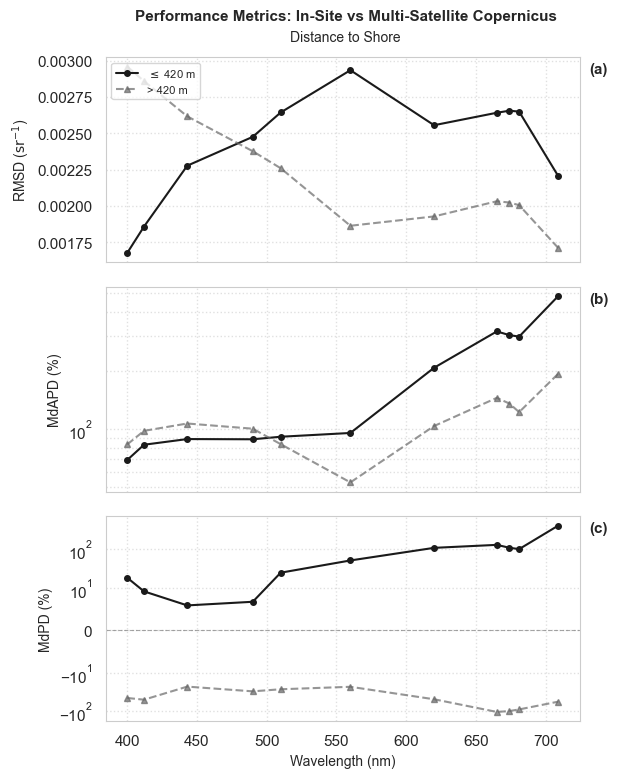

    Wavelength  N (<=420m) RMSD (<=420m)  MdAPD (<=420m)  MdPD (<=420m)  N (>420m) RMSD (>420m)  MdAPD (>420m)  MdPD (>420m)
0          400           6       0.00168           69.18          18.09         11      0.00296          83.23        -46.14
1          412           6       0.00186           82.90           9.11         11      0.00286          97.76        -51.20
2          443           6       0.00228           88.67           5.81         11      0.00262         106.67        -23.28
3          490           6       0.00248           88.44           6.67         11      0.00238         100.28        -30.97
4          510           6       0.00264           91.14          24.55         11      0.00226          83.47        -27.31
5          560           6       0.00293           95.33          51.30         11      0.00186          53.00        -23.54
6          620           6       0.00256          206.77         109.58         11      0.00193         103.51        -49.86


In [208]:
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# Copy the corrected Copernicus dataframe
df_copernicus = results_df.copy()

# 1. Calculate distance from each in-situ station to the shoreline

# Use the coordinate columns created in the corrected Rrs extraction code
gdf_points = gpd.GeoDataFrame(
    df_copernicus,
    geometry=gpd.points_from_xy(
        df_copernicus["longitude_dec"],
        df_copernicus["latitude_dec"]
    ),
    crs="EPSG:4326"
)

# Project points and landmass to metres
landmass_proj = island.to_crs(
    epsg=3035
)

gdf_points_proj = gdf_points.to_crs(
    epsg=3035
)

# Combine land polygons
land_union = landmass_proj.union_all()

# Calculate distance from the station location to the shoreline
df_copernicus["dist_to_shore_m"] = (
    gdf_points_proj.geometry.distance(
        land_union
    )
)

print(
    df_copernicus[
        [
            "Site",
            "latitude_dec",
            "longitude_dec",
            "dist_to_shore_m"
        ]
    ].head()
)

# 2. Split sites into nearshore and farther offshore groups

df_near = df_copernicus[
    df_copernicus["dist_to_shore_m"] <= 420
    ].copy()

df_far = df_copernicus[
    df_copernicus["dist_to_shore_m"] > 420
    ].copy()

print(
    "Nearshore sites, <= 420 m:",
    len(df_near)
)

print(
    "Farther sites, > 420 m:",
    len(df_far)
)

# 3. Calculate band-specific metrics for Copernicus exact-pixel Rrs

bands = [
    400, 412, 443, 490, 510,
    560, 620, 665, 674, 681, 709
]


def calculate_copernicus_group_metrics(
        df_sub,
        satellite_suffix="_copernicus"
):
    """
    Calculate RMSD, MdAPD and MdPD for Copernicus Rrs bands.

    The default suffix '_copernicus' uses the strict exact-pixel
    matchup values.

    To use the expanded exact-plus-local-fallback values, change
    satellite_suffix to '_copernicus_adj'.
    """

    results = []

    for wavelength in bands:

        # In-situ columns are named "400", "412", etc.
        insitu_col = str(wavelength)

        # Copernicus columns are named RRS400_copernicus, etc.
        satellite_col = (
            f"RRS{wavelength}{satellite_suffix}"
        )

        if insitu_col not in df_sub.columns:
            results.append({
                "Wavelength": wavelength,
                "N": 0,
                "RMSD": np.nan,
                "MdAPD": np.nan,
                "MdPD": np.nan
            })
            continue

        if satellite_col not in df_sub.columns:
            results.append({
                "Wavelength": wavelength,
                "N": 0,
                "RMSD": np.nan,
                "MdAPD": np.nan,
                "MdPD": np.nan
            })
            continue

        paired = df_sub[
            [
                insitu_col,
                satellite_col
            ]
        ].copy()

        paired[insitu_col] = pd.to_numeric(
            paired[insitu_col],
            errors="coerce"
        )

        paired[satellite_col] = pd.to_numeric(
            paired[satellite_col],
            errors="coerce"
        )

        paired = paired.replace(
            [np.inf, -np.inf],
            np.nan
        ).dropna()

        # Percentage metrics cannot be calculated when the
        # in-situ Rrs value is zero.
        paired = paired[
            np.abs(paired[insitu_col]) > 0
            ]

        n = len(paired)

        if n == 0:
            results.append({
                "Wavelength": wavelength,
                "N": 0,
                "RMSD": np.nan,
                "MdAPD": np.nan,
                "MdPD": np.nan
            })
            continue

        insitu_values = paired[
            insitu_col
        ].to_numpy(dtype=float)

        satellite_values = paired[
            satellite_col
        ].to_numpy(dtype=float)

        # Satellite minus in-situ
        difference = (
                satellite_values
                - insitu_values
        )

        # RMSD in sr^-1
        rmsd = np.sqrt(
            np.mean(difference ** 2)
        )

        # Percentage difference relative to in-situ Rrs
        percentage_difference = (
                100
                * difference
                / insitu_values
        )

        mdpd = np.median(
            percentage_difference
        )

        mdapd = np.median(
            np.abs(percentage_difference)
        )

        results.append({
            "Wavelength": wavelength,
            "N": n,
            "RMSD": rmsd,
            "MdAPD": mdapd,
            "MdPD": mdpd
        })

    return pd.DataFrame(results)


# Use strict exact-pixel Copernicus values
metrics_near = calculate_copernicus_group_metrics(
    df_near,
    satellite_suffix="_copernicus"
)

metrics_far = calculate_copernicus_group_metrics(
    df_far,
    satellite_suffix="_copernicus"
)

# 4. Plot the distance-to-shore comparison

fig, axes = plt.subplots(
    3,
    1,
    figsize=(6, 8),
    sharex=True
)

# RMSD
axes[0].plot(
    metrics_near["Wavelength"],
    metrics_near["RMSD"],
    marker="o",
    color="k",
    linestyle="-",
    linewidth=1.5,
    markersize=4,
    label=r"$\leq$ 420 m"
)

axes[0].plot(
    metrics_far["Wavelength"],
    metrics_far["RMSD"],
    marker="^",
    color="dimgrey",
    linestyle="--",
    linewidth=1.5,
    markersize=4,
    alpha=0.7,
    label="> 420 m"
)

axes[0].set_ylabel(
    r"RMSD ($\mathrm{sr^{-1}}$)",
    fontsize=10
)

axes[0].grid(
    True,
    linestyle=":",
    alpha=0.6
)

axes[0].legend(
    fontsize=8,
    loc="upper left"
)

axes[0].text(
    1.02,
    0.92,
    "(a)",
    transform=axes[0].transAxes,
    fontsize=11,
    fontweight="bold"
)

# MdAPD
axes[1].plot(
    metrics_near["Wavelength"],
    metrics_near["MdAPD"],
    marker="o",
    color="k",
    linestyle="-",
    linewidth=1.5,
    markersize=4
)

axes[1].plot(
    metrics_far["Wavelength"],
    metrics_far["MdAPD"],
    marker="^",
    color="dimgrey",
    linestyle="--",
    linewidth=1.5,
    markersize=4,
    alpha=0.7
)

axes[1].set_yscale(
    "log"
)

axes[1].set_ylabel(
    "MdAPD (%)",
    fontsize=10
)

axes[1].grid(
    True,
    linestyle=":",
    alpha=0.6,
    which="both"
)

axes[1].text(
    1.02,
    0.92,
    "(b)",
    transform=axes[1].transAxes,
    fontsize=11,
    fontweight="bold"
)

# MdPD
axes[2].plot(
    metrics_near["Wavelength"],
    metrics_near["MdPD"],
    marker="o",
    color="k",
    linestyle="-",
    linewidth=1.5,
    markersize=4
)

axes[2].plot(
    metrics_far["Wavelength"],
    metrics_far["MdPD"],
    marker="^",
    color="dimgrey",
    linestyle="--",
    linewidth=1.5,
    markersize=4,
    alpha=0.7
)

axes[2].set_yscale(
    "symlog",
    linthresh=10
)

axes[2].set_ylabel(
    "MdPD (%)",
    fontsize=10
)

axes[2].set_xlabel(
    "Wavelength (nm)",
    fontsize=10
)

axes[2].grid(
    True,
    linestyle=":",
    alpha=0.6,
    which="both"
)

axes[2].axhline(
    0,
    color="gray",
    linestyle="--",
    linewidth=0.8,
    alpha=0.7
)

axes[2].text(
    1.02,
    0.92,
    "(c)",
    transform=axes[2].transAxes,
    fontsize=11,
    fontweight="bold"
)

fig.suptitle(
        "Performance Metrics: In-Site vs Multi-Satellite Copernicus",
        fontsize=11,
        fontweight="bold",
        x=0.53,
        y=0.97
    )

fig.text(
        0.53,
        0.93,
        "Distance to Shore",
        ha="center",
        fontsize=10,
        style="normal"
    )

    # Leave space for the two-line title
fig.subplots_adjust(top=0.91, bottom=0.08, left=0.13, right=0.92, hspace=0.12)

output_path = (
    "C:/Users/25298423/PycharmProjects/"
    "FinalFigures/"
    "PerformanceMetrics_DistanceToShore_"
    "Copernicus_1km_Exact.png"
)

plt.savefig(
    output_path,
    dpi=1200,
    bbox_inches="tight"
)

plt.show()

# 5. Create the formatted table for your document

table_near = pd.DataFrame({
    "Wavelength": metrics_near["Wavelength"],
    "N (<=420m)": metrics_near["N"],
    "RMSD (<=420m)": metrics_near["RMSD"],
    "MdAPD (<=420m)": metrics_near["MdAPD"],
    "MdPD (<=420m)": metrics_near["MdPD"]
})

table_far = pd.DataFrame({
    "Wavelength": metrics_far["Wavelength"],
    "N (>420m)": metrics_far["N"],
    "RMSD (>420m)": metrics_far["RMSD"],
    "MdAPD (>420m)": metrics_far["MdAPD"],
    "MdPD (>420m)": metrics_far["MdPD"]
})

final_table = pd.merge(
    table_near,
    table_far,
    on="Wavelength"
)

# Format RMSD values to three significant figures
rmsd_columns = [
    column
    for column in final_table.columns
    if "RMSD" in column
]

for column in rmsd_columns:
    final_table[column] = final_table[
        column
    ].apply(
        lambda value: (
            f"{value:.3g}"
            if pd.notnull(value)
            else value
        )
    )

# Round MdAPD and MdPD values to two decimal places
percentage_columns = [
    column
    for column in final_table.columns
    if (
            column != "Wavelength"
            and not column.startswith("N")
            and column not in rmsd_columns
    )
]

for column in percentage_columns:
    final_table[column] = final_table[
        column
    ].round(2)

print(final_table)


In [212]:
notes_map = stations.set_index("Site")["Notes"]
results_df["Notes"] = results_df["Site"].map(notes_map)

In [213]:
results_df

,Site,Date,latitude_dec,longitude_dec,400,412,443,490,510,560,620,665,674,681,709,RRS400_copernicus,RRS400_copernicus_adj,RRS412_copernicus,RRS412_copernicus_adj,RRS443_copernicus,RRS443_copernicus_adj,RRS490_copernicus,RRS490_copernicus_adj,RRS510_copernicus,RRS510_copernicus_adj,RRS560_copernicus,RRS560_copernicus_adj,RRS620_copernicus,RRS620_copernicus_adj,RRS665_copernicus,RRS665_copernicus_adj,RRS674_copernicus,RRS674_copernicus_adj,RRS681_copernicus,RRS681_copernicus_adj,RRS709_copernicus,RRS709_copernicus_adj,RRS_selected_pixel_lat,RRS_selected_pixel_lon,RRS_distance_to_selected_pixel_m,RRS_matchup_source,Notes
0,ISO-01,2026-04-28,53.263103,-9.039540,0.000497,0.000563,0.000782,0.001500,0.001977,0.003770,0.001855,0.001089,0.001093,0.001159,0.000608,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
1,ISO-02,2026-04-28,53.260653,-9.037058,0.000532,0.000611,0.000884,0.001653,0.002088,0.003621,0.001726,0.001086,0.001128,0.001208,0.000662,NaN,0.002686,NaN,0.002449,NaN,0.001786,NaN,0.001333,NaN,0.001776,NaN,0.002394,NaN,0.000684,NaN,-0.000064,NaN,0.000036,NaN,0.000125,NaN,0.000238,53.247223,-9.036107,1493.690647,local_fallback,NaN
2,ISO-03,2026-04-28,53.250777,-9.036935,0.000321,0.000425,0.000744,0.001447,0.001806,0.002944,0.001526,0.001006,0.001074,0.001165,0.000624,NaN,0.002686,NaN,0.002449,NaN,0.001786,NaN,0.001333,NaN,0.001776,NaN,0.002394,NaN,0.000684,NaN,-0.000064,NaN,0.000036,NaN,0.000125,NaN,0.000238,53.247223,-9.036107,398.749152,local_fallback,NaN
3,ISO-04,2026-04-28,53.244920,-9.041622,0.000272,0.000402,0.000768,0.001461,0.001784,0.002701,0.001365,0.000920,0.001001,0.001091,0.000562,0.002684,0.002684,0.002448,0.002448,0.001786,0.001786,0.001333,0.001333,0.001776,0.001776,0.002394,0.002394,0.000684,0.000684,-0.000064,-0.000064,0.000036,0.000036,0.000125,0.000125,0.000238,0.000238,53.247223,-9.041662,255.912263,exact,NaN
4,ISO-08A,2026-04-28,53.141730,-8.936175,0.000322,0.000387,0.000520,0.000794,0.000981,0.001723,0.001466,0.001103,0.001109,0.001176,0.000746,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
5,ISO-08B,2026-04-28,53.158338,-8.948395,0.000162,0.000269,0.000557,0.001148,0.001478,0.002336,0.001325,0.000908,0.000953,0.001019,0.000539,NaN,0.000179,NaN,0.000316,NaN,0.001539,NaN,0.002509,NaN,0.003429,NaN,0.004912,NaN,0.003690,NaN,0.003003,NaN,0.002834,NaN,0.003053,NaN,0.004118,53.163887,-8.947218,621.574921,local_fallback,NaN
6,ISO-09,2026-04-28,53.167728,-8.955467,0.000405,0.000531,0.000877,0.001569,0.001925,0.002824,0.001255,0.000788,0.000853,0.000928,0.000442,NaN,0.000176,NaN,0.000313,NaN,0.001535,NaN,0.002507,NaN,0.003427,NaN,0.004910,NaN,0.003688,NaN,0.003002,NaN,0.002834,NaN,0.003053,NaN,0.004118,53.163887,-8.952774,462.975091,local_fallback,NaN
7,ISO-10,2026-04-28,53.175897,-8.962217,0.000937,0.001047,0.001297,0.001795,0.002057,0.002653,0.001234,0.000879,0.000994,0.001094,0.000551,NaN,0.001320,NaN,0.001467,NaN,0.002204,NaN,0.003113,NaN,0.003724,NaN,0.005135,NaN,0.003269,NaN,0.002529,NaN,0.002515,NaN,0.002590,NaN,0.002989,53.180557,-8.963884,529.619778,local_fallback,NaN
8,ISO-11,2026-04-28,53.180213,-8.970387,0.000777,0.000861,0.001041,0.001421,0.001605,0.002033,0.000948,0.000614,0.000686,0.000753,0.000373,0.001320,0.001320,0.001467,0.001467,0.002204,0.002204,0.003113,0.003113,0.003724,0.003724,0.005135,0.005135,0.003269,0.003269,0.002529,0.002529,0.002515,0.002515,0.002590,0.002590,0.002989,0.002989,53.180557,-8.969440,73.733309,exact,NaN
9,ISO-12,2026-04-28,53.179393,-8.979265,0.000870,0.000985,0.001256,0.001856,0.002154,0.002816,0.001208,0.000816,0.000945,0.001057,0.000504,0.001053,0.001053,0.000961,0.000961,0.001560,0.001560,0.002349,0.002349,0.003009,0.003009,0.004471,0.004471,0.002459,0.002459,0.001760,0.001760,0.001742,0.001742,0.001853,0.001853,0.002251,0.002251,53.180557,-8.980552,155.176461,exact,NaN


### Bottom Visibility Performance Statistics

Water-column observations: 24
Bottom-hit observations, Notes contains "B": 9


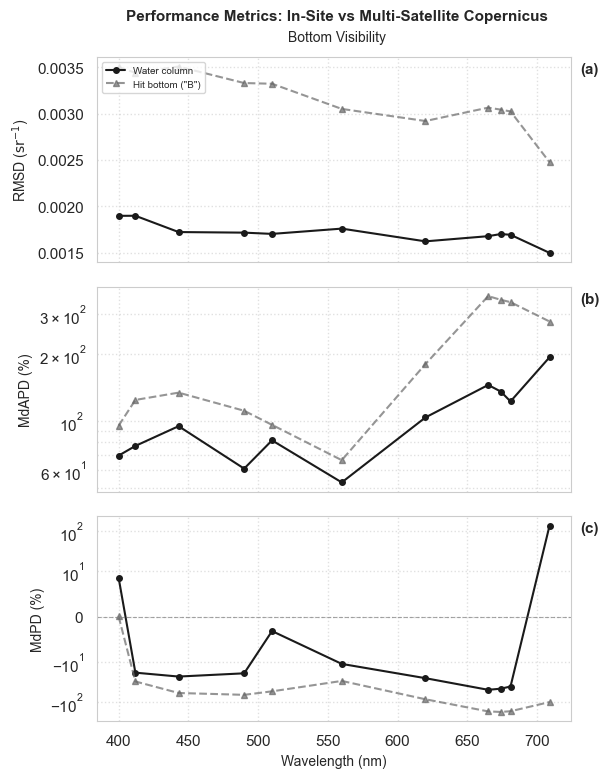

,Wavelength,N (Water Column),RMSD (Water Column),MdAPD (Water Column),MdPD (Water Column),"N (Hit Bottom ""B"")","RMSD (Hit Bottom ""B"")","MdAPD (Hit Bottom ""B"")","MdPD (Hit Bottom ""B"")"
0,400,11,0.0019,69.87,8.54,6,0.0035,95.13,0.01
1,412,11,0.0019,77.19,-18.67,6,0.00344,123.98,-30.76
2,443,11,0.00172,94.60,-23.28,6,0.00351,133.67,-59.11
3,490,11,0.00172,61.09,-19.37,6,0.00333,110.90,-65.63
4,510,11,0.0017,81.75,-3.22,6,0.00332,95.89,-53.81
5,560,11,0.00176,53.00,-11.36,6,0.00305,66.65,-29.84
6,620,11,0.00162,103.51,-25.53,6,0.00292,179.41,-84.38
7,665,11,0.00168,144.67,-49.36,6,0.00306,361.49,-167.89
8,674,11,0.0017,135.21,-46.29,6,0.00304,347.92,-172.94
9,681,11,0.00169,122.08,-40.99,6,0.00302,339.68,-166.25


In [216]:
# Select the strict exact-pixel Copernicus dataset
# Use "_copernicus_adj" instead if you want the
# exact-plus-local-fallback analysis.
copernicus_suffix = "_copernicus"

# 1. Split the dataframe according to bottom visibility
has_bottom_hit = (
    results_df["Notes"]
    .fillna("")
    .astype(str)
    .str.contains("B", na=False)
)

df_water_column = results_df[
    ~has_bottom_hit
].copy()

df_bottom_hit = results_df[
    has_bottom_hit
].copy()

print(
    "Water-column observations:",
    len(df_water_column)
)

print(
    'Bottom-hit observations, Notes contains "B":',
    len(df_bottom_hit)
)

# 2. Calculate band-specific metrics for both groups
# This reuses calculate_copernicus_group_metrics()
# from the previous analysis.

metrics_water = calculate_copernicus_group_metrics(
    df_water_column,
    satellite_suffix=copernicus_suffix
)

metrics_bottom = calculate_copernicus_group_metrics(
    df_bottom_hit,
    satellite_suffix=copernicus_suffix
)

# 3. Plot the water-column versus bottom-hit comparison

fig, axes = plt.subplots(
    3,
    1,
    figsize=(6, 8),
    sharex=True
)

# RMSD
axes[0].plot(
    metrics_water["Wavelength"],
    metrics_water["RMSD"],
    marker="o",
    color="k",
    linestyle="-",
    linewidth=1.5,
    markersize=4,
    label="Water column"
)

axes[0].plot(
    metrics_bottom["Wavelength"],
    metrics_bottom["RMSD"],
    marker="^",
    color="dimgrey",
    linestyle="--",
    linewidth=1.5,
    markersize=4,
    alpha=0.7,
    label='Hit bottom ("B")'
)

axes[0].set_ylabel(
    r"RMSD ($\mathrm{sr^{-1}}$)",
    fontsize=10
)

axes[0].grid(
    True,
    linestyle=":",
    alpha=0.6
)

axes[0].legend(
    fontsize=7,
    loc="upper left"
)

axes[0].text(
    1.02,
    0.92,
    "(a)",
    transform=axes[0].transAxes,
    fontsize=11,
    fontweight="bold"
)

# MdAPD
axes[1].plot(
    metrics_water["Wavelength"],
    metrics_water["MdAPD"],
    marker="o",
    color="k",
    linestyle="-",
    linewidth=1.5,
    markersize=4
)

axes[1].plot(
    metrics_bottom["Wavelength"],
    metrics_bottom["MdAPD"],
    marker="^",
    color="dimgrey",
    linestyle="--",
    linewidth=1.5,
    markersize=4,
    alpha=0.7
)

axes[1].set_yscale(
    "log"
)

axes[1].set_ylabel(
    "MdAPD (%)",
    fontsize=10
)

axes[1].grid(
    True,
    linestyle=":",
    alpha=0.6,
    which="both"
)

axes[1].text(
    1.02,
    0.92,
    "(b)",
    transform=axes[1].transAxes,
    fontsize=11,
    fontweight="bold"
)

# MdPD
axes[2].plot(
    metrics_water["Wavelength"],
    metrics_water["MdPD"],
    marker="o",
    color="k",
    linestyle="-",
    linewidth=1.5,
    markersize=4
)

axes[2].plot(
    metrics_bottom["Wavelength"],
    metrics_bottom["MdPD"],
    marker="^",
    color="dimgrey",
    linestyle="--",
    linewidth=1.5,
    markersize=4,
    alpha=0.7
)

axes[2].set_yscale(
    "symlog",
    linthresh=10
)

axes[2].set_ylabel(
    "MdPD (%)",
    fontsize=10
)

axes[2].set_xlabel(
    "Wavelength (nm)",
    fontsize=10
)

axes[2].grid(
    True,
    linestyle=":",
    alpha=0.6,
    which="both"
)

axes[2].axhline(
    0,
    color="gray",
    linestyle="--",
    linewidth=0.8,
    alpha=0.7
)

axes[2].text(
    1.02,
    0.92,
    "(c)",
    transform=axes[2].transAxes,
    fontsize=11,
    fontweight="bold"
)

fig.suptitle(
        "Performance Metrics: In-Site vs Multi-Satellite Copernicus",
        fontsize=11,
        fontweight="bold",
        x=0.53,
        y=0.97
    )

fig.text(
        0.53,
        0.93,
        "Bottom Visibility",
        ha="center",
        fontsize=10,
        style="normal"
    )

    # Leave space for the two-line title
fig.subplots_adjust(top=0.91, bottom=0.08, left=0.13, right=0.92, hspace=0.12)

output_path = (
    "C:/Users/25298423/PycharmProjects/"
    "FinalFigures/"
    "PerformanceMetrics_BottomHit_"
    "Copernicus_1km_Exact.png"
)

plt.savefig(
    output_path,
    dpi=1200,
    bbox_inches="tight"
)

plt.show()

# 4. Create the formatted table for your document

table_water = pd.DataFrame({
    "Wavelength": metrics_water["Wavelength"],
    "N (Water Column)": metrics_water["N"],
    "RMSD (Water Column)": metrics_water["RMSD"],
    "MdAPD (Water Column)": metrics_water["MdAPD"],
    "MdPD (Water Column)": metrics_water["MdPD"]
})

table_bottom = pd.DataFrame({
    "Wavelength": metrics_bottom["Wavelength"],
    'N (Hit Bottom "B")': metrics_bottom["N"],
    'RMSD (Hit Bottom "B")': metrics_bottom["RMSD"],
    'MdAPD (Hit Bottom "B")': metrics_bottom["MdAPD"],
    'MdPD (Hit Bottom "B")': metrics_bottom["MdPD"]
})

final_table_bottom = pd.merge(
    table_water,
    table_bottom,
    on="Wavelength"
)

# Format RMSD values to three significant figures
rmsd_columns = [
    column
    for column in final_table_bottom.columns
    if "RMSD" in column
]

for column in rmsd_columns:
    final_table_bottom[column] = (
        final_table_bottom[column]
        .apply(
            lambda value: (
                f"{value:.3g}"
                if pd.notnull(value)
                else value
            )
        )
    )

# Round MdAPD and MdPD values to two decimal places
percentage_columns = [
    column
    for column in final_table_bottom.columns
    if (
            column != "Wavelength"
            and not column.startswith("N")
            and column not in rmsd_columns
    )
]

for column in percentage_columns:
    final_table_bottom[column] = (
        final_table_bottom[column]
        .round(2)
    )

final_table_bottom


## Compare Rrs Spectra Site by Site, Insitu vs Copernicus

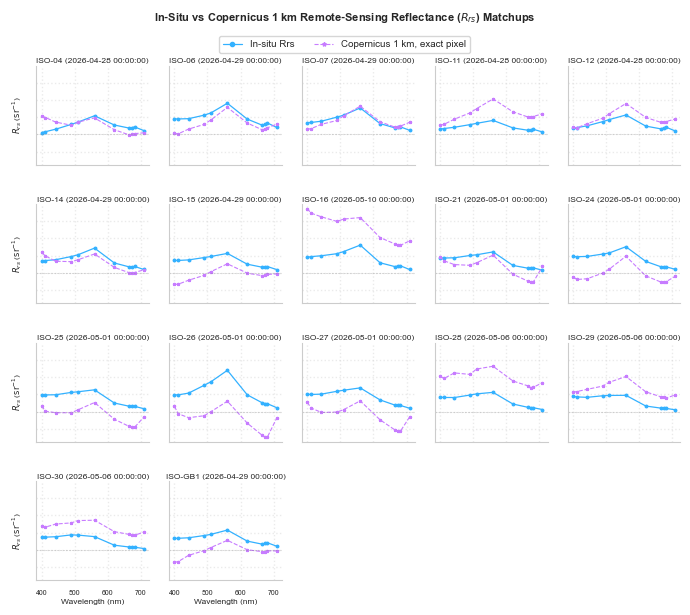

Saved figure to: C:/Users/25298423/PycharmProjects/FinalFigures/Insitu_Copernicus_1km_Exact_Rrs_Spectra_Comparison.png


In [217]:
import math
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_insitu_copernicus_matchups(
        results_df,
        satellite_suffix="_copernicus",
        satellite_label="Copernicus 1 km, exact pixel",
        station_id_col="Site",
        date_col="Date",
        output_filename=(
                "Insitu_Copernicus_1km_Exact_Rrs_Spectra_Comparison.png"
        )
):
    """
    Plot in-situ Rrs and Copernicus Rrs spectra for each site.

    Default:
        RRS400_copernicus
        RRS412_copernicus
        etc.

    To plot the expanded exact-plus-local-fallback dataset, use:
        satellite_suffix="_copernicus_adj"
    """

    df = results_df.copy()

    bands = [
        400, 412, 443, 490, 510,
        560, 620, 665, 674, 681, 709
    ]

    # ---------------------------------------------------------
    # Identify available in-situ and satellite columns
    # ---------------------------------------------------------
    insitu_columns = [
        str(band)
        for band in bands
        if str(band) in df.columns
    ]

    satellite_columns = {
        band: f"RRS{band}{satellite_suffix}"
        for band in bands
        if f"RRS{band}{satellite_suffix}" in df.columns
    }

    if len(insitu_columns) == 0:
        raise ValueError(
            "No in-situ Rrs columns named 400, 412, 443, etc. "
            "were found."
        )

    if len(satellite_columns) == 0:
        raise ValueError(
            f"No Copernicus columns ending with "
            f"'{satellite_suffix}' were found."
        )

    # ---------------------------------------------------------
    # Keep only sites with at least one valid in-situ and
    # one valid satellite Rrs value
    # ---------------------------------------------------------
    valid_indices = []

    for idx, row in df.iterrows():

        insitu_values = pd.to_numeric(
            row[insitu_columns],
            errors="coerce"
        ).to_numpy(dtype=float)

        satellite_values = pd.to_numeric(
            row[
                list(satellite_columns.values())
            ],
            errors="coerce"
        ).to_numpy(dtype=float)

        insitu_available = np.isfinite(
            insitu_values
        ).any()

        satellite_available = np.isfinite(
            satellite_values
        ).any()

        if insitu_available and satellite_available:
            valid_indices.append(idx)

    if len(valid_indices) == 0:
        raise ValueError(
            "No sites contained valid in-situ and Copernicus "
            "Rrs values."
        )

    # ---------------------------------------------------------
    # Sort sites alphanumerically
    # ---------------------------------------------------------
    def alphanumeric_key(idx):

        site_name = str(
            df.loc[idx, station_id_col]
        )

        return [
            int(value)
            if value.isdigit()
            else value.lower()
            for value in re.split(
                r"(\d+)",
                site_name
            )
        ]

    valid_indices = sorted(
        valid_indices,
        key=alphanumeric_key
    )

    # ---------------------------------------------------------
    # Determine one common y-axis range from all plotted data
    # ---------------------------------------------------------
    all_values = []

    for idx in valid_indices:
        row = df.loc[idx]

        insitu_values = pd.to_numeric(
            row[insitu_columns],
            errors="coerce"
        ).to_numpy(dtype=float)

        satellite_values = pd.to_numeric(
            row[
                list(satellite_columns.values())
            ],
            errors="coerce"
        ).to_numpy(dtype=float)

        all_values.extend(
            insitu_values[np.isfinite(insitu_values)]
        )

        all_values.extend(
            satellite_values[np.isfinite(satellite_values)]
        )

    all_values = np.asarray(
        all_values,
        dtype=float
    )

    y_min = np.nanmin(all_values)
    y_max = np.nanmax(all_values)

    y_range = y_max - y_min

    if y_range == 0:
        y_padding = max(
            abs(y_max) * 0.1,
            0.001
        )
    else:
        y_padding = 0.05 * y_range

    common_ylim = (
        y_min - y_padding,
        y_max + y_padding
    )

    # ---------------------------------------------------------
    # Create site-panel layout
    # ---------------------------------------------------------
    columns_per_page = 5
    total_sites = len(valid_indices)
    total_rows = math.ceil(
        total_sites / columns_per_page
    )

    fig_width = 7.0
    fig_height = max(
        4.5,
        1.55 * total_rows
    )

    fig, axes = plt.subplots(
        total_rows,
        columns_per_page,
        figsize=(fig_width, fig_height),
        sharex=True,
        sharey=True,
        squeeze=False
    )

    axes_flat = axes.flatten()

    # Plot colours
    c_insitu = "#33B1FF"
    c_copernicus = "#C77CFF"

    # ---------------------------------------------------------
    # Plot each station
    # ---------------------------------------------------------
    for slot_idx, idx in enumerate(valid_indices):

        ax = axes_flat[slot_idx]
        row = df.loc[idx]

        site_name = str(
            row.get(
                station_id_col,
                f"Site {idx}"
            )
        )

        date_value = row.get(
            date_col,
            ""
        )

        # In-situ values
        insitu_x = []
        insitu_y = []

        for band in bands:

            col = str(band)

            if col not in df.columns:
                continue

            value = pd.to_numeric(
                row[col],
                errors="coerce"
            )

            if pd.notna(value):
                insitu_x.append(band)
                insitu_y.append(float(value))

        # Copernicus values
        satellite_x = []
        satellite_y = []

        for band in bands:

            col = satellite_columns.get(
                band
            )

            if col is None:
                continue

            value = pd.to_numeric(
                row[col],
                errors="coerce"
            )

            if pd.notna(value):
                satellite_x.append(band)
                satellite_y.append(float(value))

        # Plot in-situ spectrum
        if len(insitu_x) > 0:
            ax.plot(
                insitu_x,
                insitu_y,
                "o-",
                color=c_insitu,
                linewidth=0.9,
                markersize=1.8
            )

        # Plot Copernicus spectrum
        if len(satellite_x) > 0:
            ax.plot(
                satellite_x,
                satellite_y,
                "*--",
                color=c_copernicus,
                linewidth=0.8,
                markersize=2.2
            )

        ax.set_ylim(
            common_ylim
        )

        ax.axhline(
            0,
            color="gray",
            linestyle="--",
            linewidth=0.4,
            alpha=0.5
        )

        ax.grid(
            True,
            linestyle=":",
            alpha=0.4
        )

        ax.tick_params(
            axis="both",
            which="major",
            labelsize=5.0,
            pad=1
        )

        ax.spines["top"].set_visible(
            False
        )

        ax.spines["right"].set_visible(
            False
        )

        ax.set_title(
            f"{site_name} ({date_value})",
            fontsize=6.0,
            fontweight="normal",
            pad=2
        )

        # Show y-axis labels only on the first column
        column_index = slot_idx % columns_per_page

        if column_index == 0:

            ax.set_ylabel(
                r"$R_{rs}$ ($\mathrm{sr^{-1}}$)",
                fontsize=6.0,
                labelpad=2
            )

        else:

            ax.set_yticklabels([])

        # Show x-axis labels only on the bottom row
        row_index = slot_idx // columns_per_page

        if row_index == total_rows - 1:

            ax.set_xlabel(
                "Wavelength (nm)",
                fontsize=6.0,
                labelpad=2
            )

        else:

            ax.set_xlabel("")

    # Remove unused subplot axes
    for slot_idx in range(
            total_sites,
            len(axes_flat)
    ):
        fig.delaxes(
            axes_flat[slot_idx]
        )

    # ---------------------------------------------------------
    # Legend and figure title
    # ---------------------------------------------------------
    legend_elements = [
        Line2D(
            [0],
            [0],
            marker="o",
            color=c_insitu,
            label="In-situ Rrs",
            linewidth=0.9,
            markersize=3
        ),
        Line2D(
            [0],
            [0],
            marker="*",
            color=c_copernicus,
            linestyle="--",
            label=satellite_label,
            linewidth=0.8,
            markersize=3
        )
    ]

    fig.suptitle(
        "In-Situ vs Copernicus 1 km Remote-Sensing "
        "Reflectance ($R_{rs}$) Matchups",
        fontsize=8.0,
        fontweight="bold"
    )

    fig.legend(
        handles=legend_elements,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.945),
        ncol=2,
        fontsize=7.0,
        frameon=True
    )

    plt.subplots_adjust(
        left=0.06,
        right=0.98,
        top=0.89,
        bottom=0.06,
        hspace=0.40,
        wspace=0.18
    )

    output_path = (
            "C:/Users/25298423/PycharmProjects/"
            "FinalFigures/"
            + output_filename
    )

    plt.savefig(
        output_path,
        dpi=1200,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"Saved figure to: {output_path}"
    )


# Primary figure using the 17 exact-pixel matchups
plot_insitu_copernicus_matchups(
    results_df=results_df,
    satellite_suffix="_copernicus",
    satellite_label="Copernicus 1 km, exact pixel",
    output_filename=(
        "Insitu_Copernicus_1km_Exact_Rrs_Spectra_Comparison.png"
    )
)


OSError: [Errno 22] Invalid argument: 'C:/Users/25298423/PycharmProjects/FinalFigures/Insitu_Copernicus_1km_Exact_Rrs_Spectra_Comparison.png'

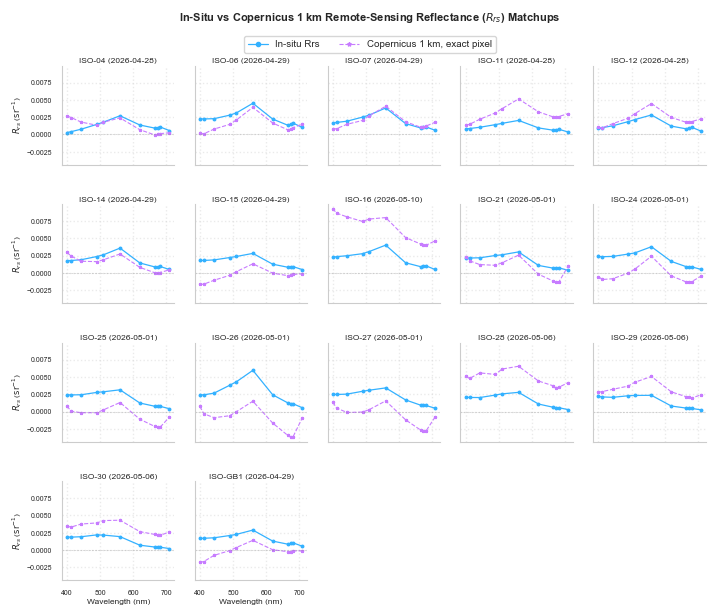

In [219]:
import math
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_insitu_copernicus_matchups(
        results_df,
        satellite_suffix="_copernicus",
        satellite_label="Copernicus 1 km, exact pixel",
        station_id_col="Site",
        date_col="Date",
        output_filename=(
            "Insitu_Copernicus_1km_Exact_Rrs_Spectra_Comparison.png"
        )
):
    """
    Plot in-situ Rrs and Copernicus Rrs spectra for each site
    using a shared y-axis across all subplots.
    """

    df = results_df.copy()

    bands = [
        400, 412, 443, 490, 510,
        560, 620, 665, 674, 681, 709
    ]

    # ---------------------------------------------------------
    # Identify available in-situ and satellite columns
    # ---------------------------------------------------------
    insitu_columns = [
        str(band)
        for band in bands
        if str(band) in df.columns
    ]

    satellite_columns = {
        band: f"RRS{band}{satellite_suffix}"
        for band in bands
        if f"RRS{band}{satellite_suffix}" in df.columns
    }

    if len(insitu_columns) == 0:
        raise ValueError(
            "No in-situ Rrs columns named 400, 412, 443, etc. "
            "were found."
        )

    if len(satellite_columns) == 0:
        raise ValueError(
            f"No Copernicus columns ending with "
            f"'{satellite_suffix}' were found."
        )

    # ---------------------------------------------------------
    # Keep only sites with valid in-situ and satellite Rrs values
    # ---------------------------------------------------------
    valid_indices = []

    for idx, row in df.iterrows():
        insitu_values = pd.to_numeric(
            row[insitu_columns],
            errors="coerce"
        ).to_numpy(dtype=float)

        satellite_values = pd.to_numeric(
            row[list(satellite_columns.values())],
            errors="coerce"
        ).to_numpy(dtype=float)

        if np.isfinite(insitu_values).any() and np.isfinite(satellite_values).any():
            valid_indices.append(idx)

    if len(valid_indices) == 0:
        raise ValueError(
            "No sites contained valid in-situ and Copernicus Rrs values."
        )

    # ---------------------------------------------------------
    # Sort sites alphanumerically
    # ---------------------------------------------------------
    def alphanumeric_key(idx):
        site_name = str(df.loc[idx, station_id_col])
        return [
            int(value) if value.isdigit() else value.lower()
            for value in re.split(r"(\d+)", site_name)
        ]

    valid_indices = sorted(valid_indices, key=alphanumeric_key)

    # ---------------------------------------------------------
    # Determine common y-axis range from all valid sites
    # ---------------------------------------------------------
    all_values = []
    for idx in valid_indices:
        row = df.loc[idx]
        insitu_vals = pd.to_numeric(row[insitu_columns], errors="coerce").to_numpy(dtype=float)
        sat_vals = pd.to_numeric(row[list(satellite_columns.values())], errors="coerce").to_numpy(dtype=float)
        all_values.extend(insitu_vals[np.isfinite(insitu_vals)])
        all_values.extend(sat_vals[np.isfinite(sat_vals)])

    all_values = np.asarray(all_values, dtype=float)
    if len(all_values) > 0:
        y_min = np.nanmin(all_values)
        y_max = np.nanmax(all_values)
        y_range = y_max - y_min
        y_padding = max(abs(y_max) * 0.1, 0.001) if y_range == 0 else 0.05 * y_range
        common_ylim = (y_min - y_padding, y_max + y_padding)
    else:
        common_ylim = (0, 0.01)

    # ---------------------------------------------------------
    # Create figure and subplots with shared y-axis
    # ---------------------------------------------------------
    columns_per_page = 5
    total_sites = len(valid_indices)
    total_rows = math.ceil(total_sites / columns_per_page)

    fig_width = 7.0
    fig_height = max(4.5, 1.55 * total_rows)

    fig, axes = plt.subplots(
        total_rows,
        columns_per_page,
        figsize=(fig_width, fig_height),
        sharex=True,
        sharey=True,
        squeeze=False
    )

    axes_flat = axes.flatten()

    c_insitu = "#33B1FF"
    c_copernicus = "#C77CFF"

    # ---------------------------------------------------------
    # Plot each station
    # ---------------------------------------------------------
    for slot_idx, idx in enumerate(valid_indices):
        ax = axes_flat[slot_idx]
        row = df.loc[idx]

        site_name = str(row.get(station_id_col, f"Site {idx}"))

        # Date without time (remove time if present)
        date_value = str(row.get(date_col, ""))
        if " " in date_value:
            date_value = date_value.split(" ")[0]

        # In-situ values
        insitu_x, insitu_y = [], []
        for band in bands:
            col = str(band)
            if col not in df.columns:
                continue
            value = pd.to_numeric(row[col], errors="coerce")
            if pd.notna(value):
                insitu_x.append(band)
                insitu_y.append(float(value))

        # Copernicus values
        satellite_x, satellite_y = [], []
        for band in bands:
            col = satellite_columns.get(band)
            if col is None:
                continue
            value = pd.to_numeric(row[col], errors="coerce")
            if pd.notna(value):
                satellite_x.append(band)
                satellite_y.append(float(value))

        if len(insitu_x) > 0:
            ax.plot(
                insitu_x, insitu_y, "o-",
                color=c_insitu, linewidth=0.9, markersize=1.8
            )

        if len(satellite_x) > 0:
            ax.plot(
                satellite_x, satellite_y, "*--",
                color=c_copernicus, linewidth=0.8, markersize=2.2
            )

        ax.set_ylim(common_ylim)

        ax.axhline(0, color="gray", linestyle="--", linewidth=0.4, alpha=0.5)
        ax.grid(True, linestyle=":", alpha=0.4)
        ax.tick_params(axis="both", which="major", labelsize=5.0, pad=1)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        title_str = f"{site_name} ({date_value})" if date_value else site_name
        ax.set_title(title_str, fontsize=6.0, fontweight="normal", pad=2)

        # Show y-axis label and ticks on the first column of each row
        column_index = slot_idx % columns_per_page
        if column_index == 0:
            ax.set_ylabel(
                r"$R_{rs}$ ($\mathrm{sr^{-1}}$)",
                fontsize=6.0,
                labelpad=2
            )
            ax.tick_params(labelleft=True)
        else:
            ax.tick_params(labelleft=False)

        # Show x-axis label only on the bottom row
        row_index = slot_idx // columns_per_page
        if row_index == total_rows - 1:
            ax.set_xlabel(
                "Wavelength (nm)",
                fontsize=6.0,
                labelpad=2
            )
        else:
            ax.set_xlabel("")

    # Remove unused subplot axes
    for slot_idx in range(total_sites, len(axes_flat)):
        fig.delaxes(axes_flat[slot_idx])

    # ---------------------------------------------------------
    # Legend and figure title
    # ---------------------------------------------------------
    legend_elements = [
        Line2D(
            [0], [0], marker="o", color=c_insitu,
            label="In-situ Rrs", linewidth=0.9, markersize=3
        ),
        Line2D(
            [0], [0], marker="*", color=c_copernicus, linestyle="--",
            label=satellite_label, linewidth=0.8, markersize=3
        )
    ]

    fig.suptitle(
        "In-Situ vs Copernicus 1 km Remote-Sensing "
        "Reflectance ($R_{rs}$) Matchups",
        fontsize=8.0,
        fontweight="bold"
    )

    fig.legend(
        handles=legend_elements,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.945),
        ncol=2,
        fontsize=7.0,
        frameon=True
    )

    plt.subplots_adjust(
        left=0.06,
        right=0.98,
        top=0.89,
        bottom=0.06,
        hspace=0.40,
        wspace=0.18
    )

    output_path = (
        "C:/Users/25298423/PycharmProjects/"
        "FinalFigures/"
        + output_filename
    )

    plt.savefig(
        output_path,
        dpi=1200,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"Saved figure to: {output_path}"
    )


# Primary figure using the 17 exact-pixel matchups
plot_insitu_copernicus_matchups(
    results_df=results_df,
    satellite_suffix="_copernicus",
    satellite_label="Copernicus 1 km, exact pixel",
    output_filename=(
        "Insitu_Copernicus_1km_Exact_Rrs_Spectra_Comparison.png"
    )
)

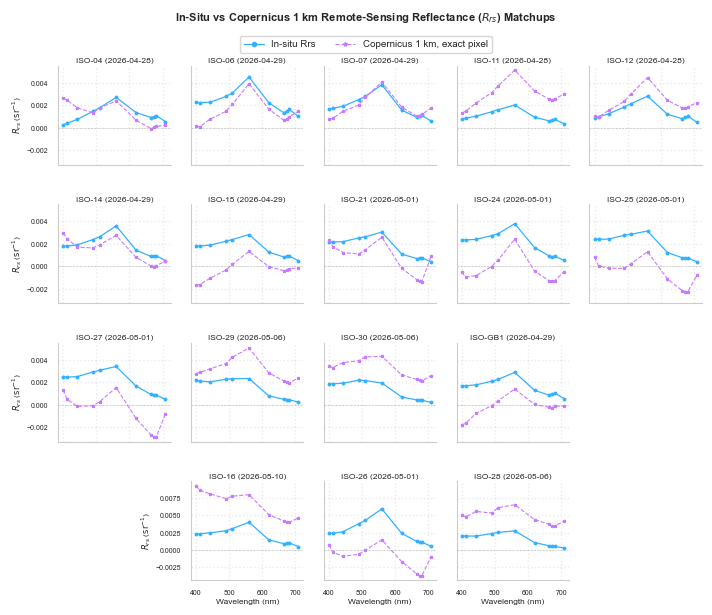

Saved figure to: C:/Users/25298423/PycharmProjects/FinalFigures/Insitu_Copernicus_1km_Exact_Rrs_Spectra_Comparison.png


In [220]:
import math
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_insitu_copernicus_matchups(
        results_df,
        satellite_suffix="_copernicus",
        satellite_label="Copernicus 1 km, exact pixel",
        station_id_col="Site",
        date_col="Date",
        output_filename=(
            "Insitu_Copernicus_1km_Exact_Rrs_Spectra_Comparison.png"
        )
):
    """
    Plot in-situ Rrs and Copernicus Rrs spectra for each site.
    Regular sites share a common y-axis, while ISO-16, ISO-26, and ISO-28
    are placed on the bottom row with their own independent y-axis.
    """

    df = results_df.copy()

    bands = [
        400, 412, 443, 490, 510,
        560, 620, 665, 674, 681, 709
    ]

    # ---------------------------------------------------------
    # Identify available in-situ and satellite columns
    # ---------------------------------------------------------
    insitu_columns = [
        str(band)
        for band in bands
        if str(band) in df.columns
    ]

    satellite_columns = {
        band: f"RRS{band}{satellite_suffix}"
        for band in bands
        if f"RRS{band}{satellite_suffix}" in df.columns
    }

    if len(insitu_columns) == 0:
        raise ValueError(
            "No in-situ Rrs columns named 400, 412, 443, etc. "
            "were found."
        )

    if len(satellite_columns) == 0:
        raise ValueError(
            f"No Copernicus columns ending with "
            f"'{satellite_suffix}' were found."
        )

    # ---------------------------------------------------------
    # Keep only sites with valid in-situ and satellite Rrs values
    # ---------------------------------------------------------
    valid_indices = []

    for idx, row in df.iterrows():
        insitu_values = pd.to_numeric(
            row[insitu_columns],
            errors="coerce"
        ).to_numpy(dtype=float)

        satellite_values = pd.to_numeric(
            row[list(satellite_columns.values())],
            errors="coerce"
        ).to_numpy(dtype=float)

        if np.isfinite(insitu_values).any() and np.isfinite(satellite_values).any():
            valid_indices.append(idx)

    if len(valid_indices) == 0:
        raise ValueError(
            "No sites contained valid in-situ and Copernicus Rrs values."
        )

    # ---------------------------------------------------------
    # Sort sites alphanumerically and separate special bottom sites
    # ---------------------------------------------------------
    def alphanumeric_key(idx):
        site_name = str(df.loc[idx, station_id_col])
        return [
            int(value) if value.isdigit() else value.lower()
            for value in re.split(r"(\d+)", site_name)
        ]

    valid_indices = sorted(valid_indices, key=alphanumeric_key)

    special_names = ["ISO-16", "ISO-26", "ISO-28"]
    regular_indices = []
    special_indices_dict = {}

    for idx in valid_indices:
        site_name = str(df.loc[idx, station_id_col])
        if site_name in special_names:
            special_indices_dict[site_name] = idx
        else:
            regular_indices.append(idx)

    ordered_special_indices = [
        special_indices_dict[name]
        for name in special_names
        if name in special_indices_dict
    ]

    # ---------------------------------------------------------
    # Build layout grid with special sites centered on bottom row
    # ---------------------------------------------------------
    columns_per_page = 5
    reg_rows = math.ceil(len(regular_indices) / columns_per_page)
    total_rows = reg_rows + 1

    grid_indices = []
    reg_iter = iter(regular_indices)

    for r in range(reg_rows):
        row_slots = []
        for c in range(columns_per_page):
            try:
                row_slots.append(next(reg_iter))
            except StopIteration:
                row_slots.append(None)
        grid_indices.append(row_slots)

    # Bottom row: center ISO-16, ISO-26, ISO-28 at columns 1, 2, 3
    bottom_row = [None, None, None, None, None]
    special_iter = iter(ordered_special_indices)
    for c in [1, 2, 3]:
        try:
            bottom_row[c] = next(special_iter)
        except StopIteration:
            break
    grid_indices.append(bottom_row)

    # ---------------------------------------------------------
    # Determine common y-axis range for regular sites
    # ---------------------------------------------------------
    reg_values = []
    for idx in regular_indices:
        row = df.loc[idx]
        insitu_vals = pd.to_numeric(row[insitu_columns], errors="coerce").to_numpy(dtype=float)
        sat_vals = pd.to_numeric(row[list(satellite_columns.values())], errors="coerce").to_numpy(dtype=float)
        reg_values.extend(insitu_vals[np.isfinite(insitu_vals)])
        reg_values.extend(sat_vals[np.isfinite(sat_vals)])

    reg_values = np.asarray(reg_values, dtype=float)
    if len(reg_values) > 0:
        y_min = np.nanmin(reg_values)
        y_max = np.nanmax(reg_values)
        y_range = y_max - y_min
        y_padding = max(abs(y_max) * 0.1, 0.001) if y_range == 0 else 0.05 * y_range
        common_ylim = (y_min - y_padding, y_max + y_padding)
    else:
        common_ylim = (0, 0.01)

    # ---------------------------------------------------------
    # Determine independent y-axis range for special bottom row sites
    # ---------------------------------------------------------
    spec_values = []
    for idx in ordered_special_indices:
        row = df.loc[idx]
        insitu_vals = pd.to_numeric(row[insitu_columns], errors="coerce").to_numpy(dtype=float)
        sat_vals = pd.to_numeric(row[list(satellite_columns.values())], errors="coerce").to_numpy(dtype=float)
        spec_values.extend(insitu_vals[np.isfinite(insitu_vals)])
        spec_values.extend(sat_vals[np.isfinite(sat_vals)])

    spec_values = np.asarray(spec_values, dtype=float)
    if len(spec_values) > 0:
        s_min = np.nanmin(spec_values)
        s_max = np.nanmax(spec_values)
        s_range = s_max - s_min
        s_padding = max(abs(s_max) * 0.1, 0.001) if s_range == 0 else 0.05 * s_range
        special_ylim = (s_min - s_padding, s_max + s_padding)
    else:
        special_ylim = (0, 0.01)

    # ---------------------------------------------------------
    # Create figure and subplots (sharey=False to allow different row scales)
    # ---------------------------------------------------------
    fig_width = 7.0
    fig_height = max(4.5, 1.55 * total_rows)

    fig, axes = plt.subplots(
        total_rows,
        columns_per_page,
        figsize=(fig_width, fig_height),
        sharex=True,
        sharey=False,
        squeeze=False
    )

    axes_flat = axes.flatten()

    c_insitu = "#33B1FF"
    c_copernicus = "#C77CFF"

    # ---------------------------------------------------------
    # Plot each station according to grid layout
    # ---------------------------------------------------------
    for r_idx, row_slots in enumerate(grid_indices):
        # Find the first active (non-None) column index in this row
        first_active_col = None
        for c_idx, idx in enumerate(row_slots):
            if idx is not None:
                first_active_col = c_idx
                break

        for c_idx, idx in enumerate(row_slots):
            slot_idx = r_idx * columns_per_page + c_idx
            ax = axes_flat[slot_idx]

            if idx is None:
                fig.delaxes(ax)
                continue

            row = df.loc[idx]
            site_name = str(row.get(station_id_col, f"Site {idx}"))

            # Date without time
            date_value = str(row.get(date_col, ""))
            if " " in date_value:
                date_value = date_value.split(" ")[0]

            # In-situ values
            insitu_x, insitu_y = [], []
            for band in bands:
                col = str(band)
                if col not in df.columns:
                    continue
                value = pd.to_numeric(row[col], errors="coerce")
                if pd.notna(value):
                    insitu_x.append(band)
                    insitu_y.append(float(value))

            # Copernicus values
            satellite_x, satellite_y = [], []
            for band in bands:
                col = satellite_columns.get(band)
                if col is None:
                    continue
                value = pd.to_numeric(row[col], errors="coerce")
                if pd.notna(value):
                    satellite_x.append(band)
                    satellite_y.append(float(value))

            if len(insitu_x) > 0:
                ax.plot(
                    insitu_x, insitu_y, "o-",
                    color=c_insitu, linewidth=0.9, markersize=1.8
                )

            if len(satellite_x) > 0:
                ax.plot(
                    satellite_x, satellite_y, "*--",
                    color=c_copernicus, linewidth=0.8, markersize=2.2
                )

            # Assign appropriate y-axis limits depending on whether it's a special site
            if site_name in special_names:
                ax.set_ylim(special_ylim)
            else:
                ax.set_ylim(common_ylim)

            ax.axhline(0, color="gray", linestyle="--", linewidth=0.4, alpha=0.5)
            ax.grid(True, linestyle=":", alpha=0.4)
            ax.tick_params(axis="both", which="major", labelsize=5.0, pad=1)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            title_str = f"{site_name} ({date_value})" if date_value else site_name
            ax.set_title(title_str, fontsize=6.0, fontweight="normal", pad=2)

            # Show y-axis label and tick numbers on the first active column of each row
            if c_idx == first_active_col:
                ax.set_ylabel(
                    r"$R_{rs}$ ($\mathrm{sr^{-1}}$)",
                    fontsize=6.0,
                    labelpad=2
                )
                ax.tick_params(labelleft=True)
            else:
                ax.tick_params(labelleft=False)

            # Show x-axis label only on the bottom row
            if r_idx == total_rows - 1:
                ax.set_xlabel(
                    "Wavelength (nm)",
                    fontsize=6.0,
                    labelpad=2
                )
            else:
                ax.set_xlabel("")

    # ---------------------------------------------------------
    # Legend and figure title
    # ---------------------------------------------------------
    legend_elements = [
        Line2D(
            [0], [0], marker="o", color=c_insitu,
            label="In-situ Rrs", linewidth=0.9, markersize=3
        ),
        Line2D(
            [0], [0], marker="*", color=c_copernicus, linestyle="--",
            label=satellite_label, linewidth=0.8, markersize=3
        )
    ]

    fig.suptitle(
        "In-Situ vs Copernicus 1 km Remote-Sensing "
        "Reflectance ($R_{rs}$) Matchups",
        fontsize=8.0,
        fontweight="bold"
    )

    fig.legend(
        handles=legend_elements,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.945),
        ncol=2,
        fontsize=7.0,
        frameon=True
    )

    plt.subplots_adjust(
        left=0.06,
        right=0.98,
        top=0.89,
        bottom=0.06,
        hspace=0.40,
        wspace=0.18
    )

    output_path = (
        "C:/Users/25298423/PycharmProjects/"
        "FinalFigures/"
        + output_filename
    )

    plt.savefig(
        output_path,
        dpi=1200,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"Saved figure to: {output_path}"
    )


# Primary figure using the 17 exact-pixel matchups
plot_insitu_copernicus_matchups(
    results_df=results_df,
    satellite_suffix="_copernicus",
    satellite_label="Copernicus 1 km, exact pixel",
    output_filename=(
        "Insitu_Copernicus_1km_Exact_Rrs_Spectra_Comparison.png"
    )
)

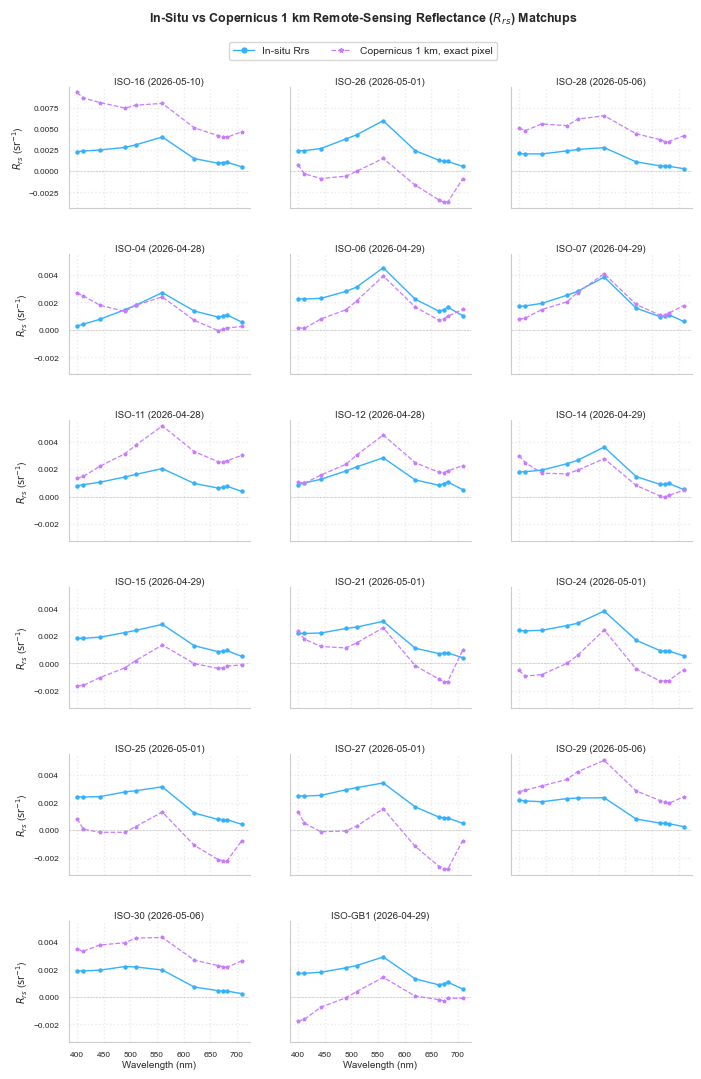

Saved figure to: C:/Users/25298423/PycharmProjects/FinalFigures/Insitu_Copernicus_1km_Exact_Rrs_Spectra_Comparison.png


In [222]:
import math
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_insitu_copernicus_matchups(
        results_df,
        satellite_suffix="_copernicus",
        satellite_label="Copernicus 1 km, exact pixel",
        station_id_col="Site",
        date_col="Date",
        output_filename=(
            "Insitu_Copernicus_1km_Exact_Rrs_Spectra_Comparison.png"
        )
):
    """
    Plot in-situ Rrs and Copernicus Rrs spectra for each site in a 3-column layout.
    Outlier stations (ISO-16, ISO-26, ISO-28) are placed on the top row with
    their own independent y-axis, while regular sites follow in subsequent rows
    sharing a common y-axis.
    """

    df = results_df.copy()

    bands = [
        400, 412, 443, 490, 510,
        560, 620, 665, 674, 681, 709
    ]

    # ---------------------------------------------------------
    # Identify available in-situ and satellite columns
    # ---------------------------------------------------------
    insitu_columns = [
        str(band)
        for band in bands
        if str(band) in df.columns
    ]

    satellite_columns = {
        band: f"RRS{band}{satellite_suffix}"
        for band in bands
        if f"RRS{band}{satellite_suffix}" in df.columns
    }

    if len(insitu_columns) == 0:
        raise ValueError(
            "No in-situ Rrs columns named 400, 412, 443, etc. "
            "were found."
        )

    if len(satellite_columns) == 0:
        raise ValueError(
            f"No Copernicus columns ending with "
            f"'{satellite_suffix}' were found."
        )

    # ---------------------------------------------------------
    # Keep only sites with valid in-situ and satellite Rrs values
    # ---------------------------------------------------------
    valid_indices = []

    for idx, row in df.iterrows():
        insitu_values = pd.to_numeric(
            row[insitu_columns],
            errors="coerce"
        ).to_numpy(dtype=float)

        satellite_values = pd.to_numeric(
            row[list(satellite_columns.values())],
            errors="coerce"
        ).to_numpy(dtype=float)

        if np.isfinite(insitu_values).any() and np.isfinite(satellite_values).any():
            valid_indices.append(idx)

    if len(valid_indices) == 0:
        raise ValueError(
            "No sites contained valid in-situ and Copernicus Rrs values."
        )

    # ---------------------------------------------------------
    # Sort sites alphanumerically and separate outlier/special sites
    # ---------------------------------------------------------
    def alphanumeric_key(idx):
        site_name = str(df.loc[idx, station_id_col])
        return [
            int(value) if value.isdigit() else value.lower()
            for value in re.split(r"(\d+)", site_name)
        ]

    valid_indices = sorted(valid_indices, key=alphanumeric_key)

    special_names = ["ISO-16", "ISO-26", "ISO-28"]
    regular_indices = []
    special_indices_dict = {}

    for idx in valid_indices:
        site_name = str(df.loc[idx, station_id_col])
        if site_name in special_names:
            special_indices_dict[site_name] = idx
        else:
            regular_indices.append(idx)

    ordered_special_indices = [
        special_indices_dict[name]
        for name in special_names
        if name in special_indices_dict
    ]

    # ---------------------------------------------------------
    # Build 3-column layout grid: outliers at top, regular rows below
    # ---------------------------------------------------------
    columns_per_page = 3
    grid_indices = []

    # Top row: outlier stations
    top_row = [None] * columns_per_page
    for i, idx in enumerate(ordered_special_indices):
        if i < columns_per_page:
            top_row[i] = idx
    grid_indices.append(top_row)

    # Subsequent rows: regular stations (3 per row, last row centered if incomplete)
    reg_iter = iter(regular_indices)
    reg_rows_count = math.ceil(len(regular_indices) / columns_per_page)

    for r in range(reg_rows_count):
        row_items = []
        while len(row_items) < columns_per_page:
            try:
                row_items.append(next(reg_iter))
            except StopIteration:
                break

        row_slots = [None] * columns_per_page
        n_items = len(row_items)
        if n_items == columns_per_page:
            row_slots = row_items
        else:
            # Center the remaining items on the final row
            start_col = (columns_per_page - n_items) // 2
            for i, item in enumerate(row_items):
                row_slots[start_col + i] = item
        grid_indices.append(row_slots)

    total_rows = len(grid_indices)

    # ---------------------------------------------------------
    # Determine common y-axis range for regular sites
    # ---------------------------------------------------------
    reg_values = []
    for idx in regular_indices:
        row = df.loc[idx]
        insitu_vals = pd.to_numeric(row[insitu_columns], errors="coerce").to_numpy(dtype=float)
        sat_vals = pd.to_numeric(row[list(satellite_columns.values())], errors="coerce").to_numpy(dtype=float)
        reg_values.extend(insitu_vals[np.isfinite(insitu_vals)])
        reg_values.extend(sat_vals[np.isfinite(sat_vals)])

    reg_values = np.asarray(reg_values, dtype=float)
    if len(reg_values) > 0:
        y_min = np.nanmin(reg_values)
        y_max = np.nanmax(reg_values)
        y_range = y_max - y_min
        y_padding = max(abs(y_max) * 0.1, 0.001) if y_range == 0 else 0.05 * y_range
        common_ylim = (y_min - y_padding, y_max + y_padding)
    else:
        common_ylim = (0, 0.01)

    # ---------------------------------------------------------
    # Determine independent y-axis range for top row outlier sites
    # ---------------------------------------------------------
    spec_values = []
    for idx in ordered_special_indices:
        row = df.loc[idx]
        insitu_vals = pd.to_numeric(row[insitu_columns], errors="coerce").to_numpy(dtype=float)
        sat_vals = pd.to_numeric(row[list(satellite_columns.values())], errors="coerce").to_numpy(dtype=float)
        spec_values.extend(insitu_vals[np.isfinite(insitu_vals)])
        spec_values.extend(sat_vals[np.isfinite(sat_vals)])

    spec_values = np.asarray(spec_values, dtype=float)
    if len(spec_values) > 0:
        s_min = np.nanmin(spec_values)
        s_max = np.nanmax(spec_values)
        s_range = s_max - s_min
        s_padding = max(abs(s_max) * 0.1, 0.001) if s_range == 0 else 0.05 * s_range
        special_ylim = (s_min - s_padding, s_max + s_padding)
    else:
        special_ylim = (0, 0.01)

    # ---------------------------------------------------------
    # Create figure and subplots
    # ---------------------------------------------------------
    fig_width = 7.0
    fig_height = max(6.0, 1.85 * total_rows)

    fig, axes = plt.subplots(
        total_rows,
        columns_per_page,
        figsize=(fig_width, fig_height),
        sharex=True,
        sharey=False,
        squeeze=False
    )

    axes_flat = axes.flatten()

    c_insitu = "#33B1FF"
    c_copernicus = "#C77CFF"

    # ---------------------------------------------------------
    # Plot each station according to grid layout
    # ---------------------------------------------------------
    for r_idx, row_slots in enumerate(grid_indices):
        first_active_col = None
        for c_idx, idx in enumerate(row_slots):
            if idx is not None:
                first_active_col = c_idx
                break

        for c_idx, idx in enumerate(row_slots):
            slot_idx = r_idx * columns_per_page + c_idx
            ax = axes_flat[slot_idx]

            if idx is None:
                fig.delaxes(ax)
                continue

            row = df.loc[idx]
            site_name = str(row.get(station_id_col, f"Site {idx}"))

            date_value = str(row.get(date_col, ""))
            if " " in date_value:
                date_value = date_value.split(" ")[0]

            insitu_x, insitu_y = [], []
            for band in bands:
                col = str(band)
                if col not in df.columns:
                    continue
                value = pd.to_numeric(row[col], errors="coerce")
                if pd.notna(value):
                    insitu_x.append(band)
                    insitu_y.append(float(value))

            satellite_x, satellite_y = [], []
            for band in bands:
                col = satellite_columns.get(band)
                if col is None:
                    continue
                value = pd.to_numeric(row[col], errors="coerce")
                if pd.notna(value):
                    satellite_x.append(band)
                    satellite_y.append(float(value))

            if len(insitu_x) > 0:
                ax.plot(
                    insitu_x, insitu_y, "o-",
                    color=c_insitu, linewidth=1.0, markersize=2.2
                )

            if len(satellite_x) > 0:
                ax.plot(
                    satellite_x, satellite_y, "*--",
                    color=c_copernicus, linewidth=0.9, markersize=2.6
                )

            # Assign y-axis limits (top row outliers get independent scale)
            if r_idx == 0:
                ax.set_ylim(special_ylim)
            else:
                ax.set_ylim(common_ylim)

            ax.axhline(0, color="gray", linestyle="--", linewidth=0.4, alpha=0.5)
            ax.grid(True, linestyle=":", alpha=0.4)
            ax.tick_params(axis="both", which="major", labelsize=6.0, pad=1)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            title_str = f"{site_name} ({date_value})" if date_value else site_name
            ax.set_title(title_str, fontsize=7.0, fontweight="normal", pad=2)

            if c_idx == first_active_col:
                ax.set_ylabel(
                    r"$R_{rs}$ ($\mathrm{sr^{-1}}$)",
                    fontsize=7.0,
                    labelpad=2
                )
                ax.tick_params(labelleft=True)
            else:
                ax.tick_params(labelleft=False)

            if r_idx == total_rows - 1:
                ax.set_xlabel(
                    "Wavelength (nm)",
                    fontsize=7.0,
                    labelpad=2
                )
            else:
                ax.set_xlabel("")

    # ---------------------------------------------------------
    # Legend and figure title
    # ---------------------------------------------------------
    legend_elements = [
        Line2D(
            [0], [0], marker="o", color=c_insitu,
            label="In-situ Rrs", linewidth=1.0, markersize=3.5
        ),
        Line2D(
            [0], [0], marker="*", color=c_copernicus, linestyle="--",
            label=satellite_label, linewidth=0.9, markersize=3.5
        )
    ]

    fig.suptitle(
        "In-Situ vs Copernicus 1 km Remote-Sensing "
        "Reflectance ($R_{rs}$) Matchups",
        fontsize=9.0,
        fontweight="bold"
    )

    fig.legend(
        handles=legend_elements,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.955),
        ncol=2,
        fontsize=7.5,
        frameon=True
    )

    plt.subplots_adjust(
        left=0.08,
        right=0.97,
        top=0.91,
        bottom=0.05,
        hspace=0.38,
        wspace=0.22
    )

    output_path = (
        "C:/Users/25298423/PycharmProjects/"
        "FinalFigures/"
        + output_filename
    )

    plt.savefig(
        output_path,
        dpi=1200,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"Saved figure to: {output_path}"
    )


# Primary figure using the 17 exact-pixel matchups
plot_insitu_copernicus_matchups(
    results_df=results_df,
    satellite_suffix="_copernicus",
    satellite_label="Copernicus 1 km, exact pixel",
    output_filename=(
        "Insitu_Copernicus_1km_Exact_Rrs_Spectra_Comparison.png"
    )
)

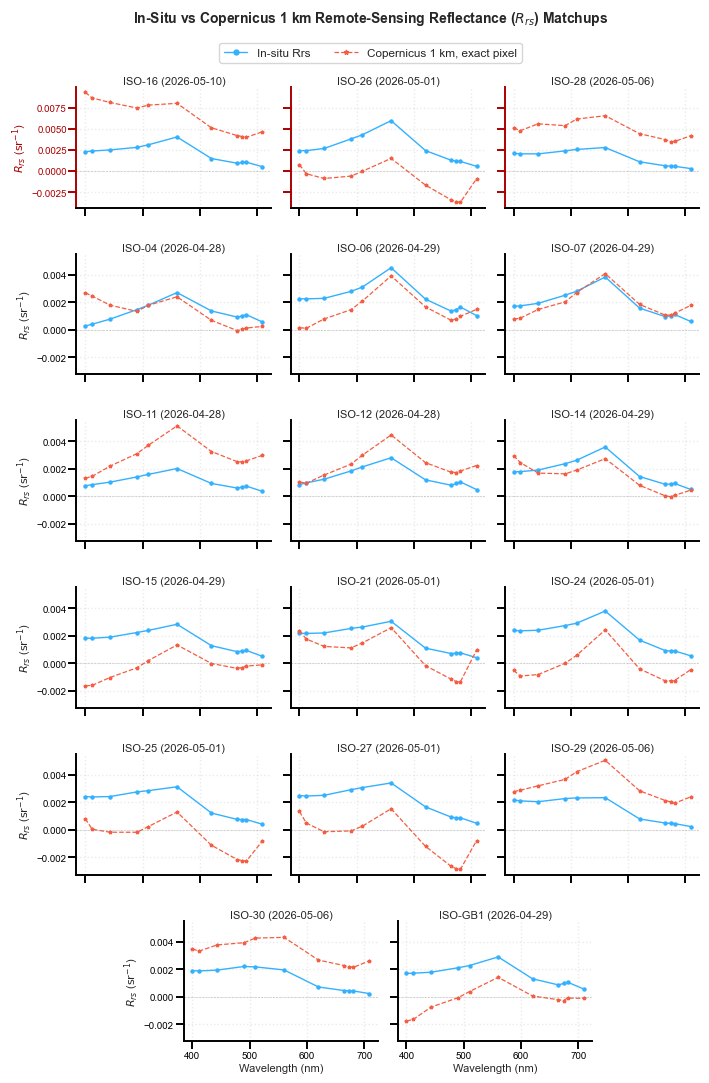

Saved figure to: C:/Users/25298423/PycharmProjects/FinalFigures/Insitu_Copernicus_1km_Exact_Rrs_Spectra_Comparison.png


In [238]:
import math
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_insitu_copernicus_matchups(
        results_df,
        satellite_suffix="_copernicus",
        satellite_label="Copernicus 1 km, exact pixel",
        station_id_col="Site",
        date_col="Date",
        output_filename=(
            "Insitu_Copernicus_1km_Exact_Rrs_Spectra_Comparison.png"
        )
):
    """
    Plot in-situ Rrs and Copernicus Rrs spectra for each site in a flexible grid layout.
    First row has an independent y-axis with red spines, ticks, and labels for its range,
    with standard titles. All axes are thickened (black x-axis), and rows with fewer
    than 3 items (such as the final row) are automatically centered using GridSpec.
    """

    df = results_df.copy()

    bands = [
        400, 412, 443, 490, 510,
        560, 620, 665, 674, 681, 709
    ]

    # ---------------------------------------------------------
    # Identify available in-situ and satellite columns
    # ---------------------------------------------------------
    insitu_columns = [
        str(band)
        for band in bands
        if str(band) in df.columns
    ]

    satellite_columns = {
        band: f"RRS{band}{satellite_suffix}"
        for band in bands
        if f"RRS{band}{satellite_suffix}" in df.columns
    }

    if len(insitu_columns) == 0:
        raise ValueError(
            "No in-situ Rrs columns named 400, 412, 443, etc. "
            "were found."
        )

    if len(satellite_columns) == 0:
        raise ValueError(
            f"No Copernicus columns ending with "
            f"'{satellite_suffix}' were found."
        )

    # ---------------------------------------------------------
    # Keep only sites with valid in-situ and satellite Rrs values
    # ---------------------------------------------------------
    valid_indices = []

    for idx, row in df.iterrows():
        insitu_values = pd.to_numeric(
            row[insitu_columns],
            errors="coerce"
        ).to_numpy(dtype=float)

        satellite_values = pd.to_numeric(
            row[list(satellite_columns.values())],
            errors="coerce"
        ).to_numpy(dtype=float)

        if np.isfinite(insitu_values).any() and np.isfinite(satellite_values).any():
            valid_indices.append(idx)

    if len(valid_indices) == 0:
        raise ValueError(
            "No sites contained valid in-situ and Copernicus Rrs values."
        )

    # ---------------------------------------------------------
    # Sort sites alphanumerically and separate special/first-row sites
    # ---------------------------------------------------------
    def alphanumeric_key(idx):
        site_name = str(df.loc[idx, station_id_col])
        return [
            int(value) if value.isdigit() else value.lower()
            for value in re.split(r"(\d+)", site_name)
        ]

    valid_indices = sorted(valid_indices, key=alphanumeric_key)

    special_names = ["ISO-16", "ISO-26", "ISO-28"]
    regular_indices = []
    special_indices_dict = {}

    for idx in valid_indices:
        site_name = str(df.loc[idx, station_id_col])
        if site_name in special_names:
            special_indices_dict[site_name] = idx
        else:
            regular_indices.append(idx)

    ordered_special_indices = [
        special_indices_dict[name]
        for name in special_names
        if name in special_indices_dict
    ]

    # ---------------------------------------------------------
    # Build layout rows (special stations on row 0, regular stations following)
    # ---------------------------------------------------------
    columns_per_page = 3
    grid_rows_indices = []

    # Top row: special stations
    top_row = [idx for idx in ordered_special_indices]
    if top_row:
        grid_rows_indices.append(top_row)

    # Subsequent rows: regular stations packed into groups of 3
    for i in range(0, len(regular_indices), columns_per_page):
        chunk = regular_indices[i:i + columns_per_page]
        grid_rows_indices.append(chunk)

    total_rows = len(grid_rows_indices)

    # ---------------------------------------------------------
    # Determine common y-axis range for regular sites
    # ---------------------------------------------------------
    reg_values = []
    for idx in regular_indices:
        row = df.loc[idx]
        insitu_vals = pd.to_numeric(row[insitu_columns], errors="coerce").to_numpy(dtype=float)
        sat_vals = pd.to_numeric(row[list(satellite_columns.values())], errors="coerce").to_numpy(dtype=float)
        reg_values.extend(insitu_vals[np.isfinite(insitu_vals)])
        reg_values.extend(sat_vals[np.isfinite(sat_vals)])

    reg_values = np.asarray(reg_values, dtype=float)
    if len(reg_values) > 0:
        y_min = np.nanmin(reg_values)
        y_max = np.nanmax(reg_values)
        y_range = y_max - y_min
        y_padding = max(abs(y_max) * 0.1, 0.001) if y_range == 0 else 0.05 * y_range
        common_ylim = (y_min - y_padding, y_max + y_padding)
    else:
        common_ylim = (0, 0.01)

    # ---------------------------------------------------------
    # Determine independent y-axis range for top row special sites
    # ---------------------------------------------------------
    spec_values = []
    for idx in ordered_special_indices:
        row = df.loc[idx]
        insitu_vals = pd.to_numeric(row[insitu_columns], errors="coerce").to_numpy(dtype=float)
        sat_vals = pd.to_numeric(row[list(satellite_columns.values())], errors="coerce").to_numpy(dtype=float)
        spec_values.extend(insitu_vals[np.isfinite(insitu_vals)])
        spec_values.extend(sat_vals[np.isfinite(sat_vals)])

    spec_values = np.asarray(spec_values, dtype=float)
    if len(spec_values) > 0:
        s_min = np.nanmin(spec_values)
        s_max = np.nanmax(spec_values)
        s_range = s_max - s_min
        s_padding = max(abs(s_max) * 0.1, 0.001) if s_range == 0 else 0.05 * s_range
        special_ylim = (s_min - s_padding, s_max + s_padding)
    else:
        special_ylim = (0, 0.01)

    # ---------------------------------------------------------
    # Create figure and 6-column GridSpec for perfect centering
    # ---------------------------------------------------------
    fig_width = 7.0
    fig_height = max(6.0, 1.85 * total_rows)

    fig = plt.figure(figsize=(fig_width, fig_height))
    gs = fig.add_gridspec(total_rows, 6)

    c_insitu = "#33B1FF"
    c_copernicus = "#f55d42"
    axis_linewidth = 1.4  # Thicker axes as requested

    # ---------------------------------------------------------
    # Plot each station using dynamic GridSpec column spans
    # ---------------------------------------------------------
    for r_idx, row_indices in enumerate(grid_rows_indices):
        n_items = len(row_indices)

        # Determine 6-column grid slice based on how many items are in this row
        if n_items == 3:
            col_spans = [slice(0, 2), slice(2, 4), slice(4, 6)]
        elif n_items == 2:
            col_spans = [slice(1, 3), slice(3, 5)]
        elif n_items == 1:
            col_spans = [slice(2, 4)]
        else:
            col_spans = [slice(0, 2)]

        for c_idx, idx in enumerate(row_indices):
            ax = fig.add_subplot(gs[r_idx, col_spans[c_idx]])

            row = df.loc[idx]
            site_name = str(row.get(station_id_col, f"Site {idx}"))

            date_value = str(row.get(date_col, ""))
            if " " in date_value:
                date_value = date_value.split(" ")[0]

            insitu_x, insitu_y = [], []
            for band in bands:
                col = str(band)
                if col not in df.columns:
                    continue
                value = pd.to_numeric(row[col], errors="coerce")
                if pd.notna(value):
                    insitu_x.append(band)
                    insitu_y.append(float(value))

            satellite_x, satellite_y = [], []
            for band in bands:
                col = satellite_columns.get(band)
                if col is None:
                    continue
                value = pd.to_numeric(row[col], errors="coerce")
                if pd.notna(value):
                    satellite_x.append(band)
                    satellite_y.append(float(value))

            if len(insitu_x) > 0:
                ax.plot(
                    insitu_x, insitu_y, "o-",
                    color=c_insitu, linewidth=1.0, markersize=2.2
                )

            if len(satellite_x) > 0:
                ax.plot(
                    satellite_x, satellite_y, "*--",
                    color=c_copernicus, linewidth=0.9, markersize=2.6
                )

            ax.axhline(0, color="gray", linestyle="--", linewidth=0.4, alpha=0.5)
            ax.grid(True, linestyle=":", alpha=0.4)

            # Clean top/right visibility and apply thick black bottom spine
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["left"].set_visible(True)
            ax.spines["bottom"].set_visible(True)

            ax.spines["bottom"].set_color("black")
            ax.spines["bottom"].set_linewidth(axis_linewidth)

            title_str = f"{site_name} ({date_value})" if date_value else site_name
            ax.set_title(title_str, fontsize=8.0, fontweight="normal", pad=2)

            # Configure top row y-axis with red scale styling
            if r_idx == 0:
                ax.set_ylim(special_ylim)
                ax.spines["left"].set_color("#AA0000")
                ax.spines["left"].set_linewidth(axis_linewidth)
                y_tick_color = "#AA0000"
            else:
                ax.set_ylim(common_ylim)
                ax.spines["left"].set_color("black")
                ax.spines["left"].set_linewidth(axis_linewidth)
                y_tick_color = "black"

            # Show y-axis label and ticks on the first column of each row
            if c_idx == 0:
                ylabel = ax.set_ylabel(
                    r"$R_{rs}$ ($\mathrm{sr^{-1}}$)",
                    fontsize=8.0,
                    labelpad=2
                )
                if r_idx == 0:
                    ylabel.set_color("#AA0000")

                ax.tick_params(
                    axis="y",
                    colors=y_tick_color,
                    labelcolor=y_tick_color,
                    left=True,
                    right=False,
                    labelleft=True,
                    labelright=False,
                    labelsize=7.0,
                    pad=1,
                    direction="out",
                    width=axis_linewidth
                )
            else:
                ax.tick_params(
                    axis="y",
                    colors=y_tick_color,
                    labelcolor=y_tick_color,
                    left=True,
                    right=False,
                    labelleft=False,
                    labelright=False,
                    labelsize=7.0,
                    pad=1,
                    direction="out",
                    width=axis_linewidth
                )
                ax.set_ylabel("")

            # Thicken pitch-black x-axis ticks and ensure visibility across all subplots
            ax.tick_params(
                axis="x",
                colors="black",
                labelcolor="black",
                labelsize=7.0,
                pad=1,
                direction="out",
                bottom=True,
                top=False,
                width=axis_linewidth
            )

            if r_idx == total_rows - 1:
                ax.set_xlabel(
                    "Wavelength (nm)",
                    fontsize=8.0,
                    labelpad=2
                )
                ax.tick_params(axis="x", which="both", labelbottom=True)
            else:
                ax.set_xlabel("")
                ax.tick_params(axis="x", which="both", labelbottom=False)

    # ---------------------------------------------------------
    # Legend and figure title
    # ---------------------------------------------------------
    legend_elements = [
        Line2D(
            [0], [0], marker="o", color=c_insitu,
            label="In-situ Rrs", linewidth=1.0, markersize=3.5
        ),
        Line2D(
            [0], [0], marker="*", color=c_copernicus, linestyle="--",
            label=satellite_label, linewidth=0.9, markersize=3.5
        )
    ]

    fig.suptitle(
        "In-Situ vs Copernicus 1 km Remote-Sensing "
        "Reflectance ($R_{rs}$) Matchups",
        fontsize=10.0,
        fontweight="bold"
    )

    fig.legend(
        handles=legend_elements,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.955),
        ncol=2,
        fontsize=8.5,
        frameon=True
    )

    plt.subplots_adjust(
        left=0.08,
        right=0.97,
        top=0.91,
        bottom=0.05,
        hspace=0.38,
        wspace=0.22
    )

    output_path = (
        "C:/Users/25298423/PycharmProjects/"
        "FinalFigures/"
        + output_filename
    )

    plt.savefig(
        output_path,
        dpi=1200,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"Saved figure to: {output_path}"
    )


# Primary figure using the 17 exact-pixel matchups
plot_insitu_copernicus_matchups(
    results_df=results_df,
    satellite_suffix="_copernicus",
    satellite_label="Copernicus 1 km, exact pixel",
    output_filename=(
        "Insitu_Copernicus_1km_Exact_Rrs_Spectra_Comparison.png"
    )
)

Valid plotted wavelengths: [400.0, 412.0, 443.0, 490.0, 510.0, 560.0, 620.0, 665.0, 674.0, 681.0, 709.0]


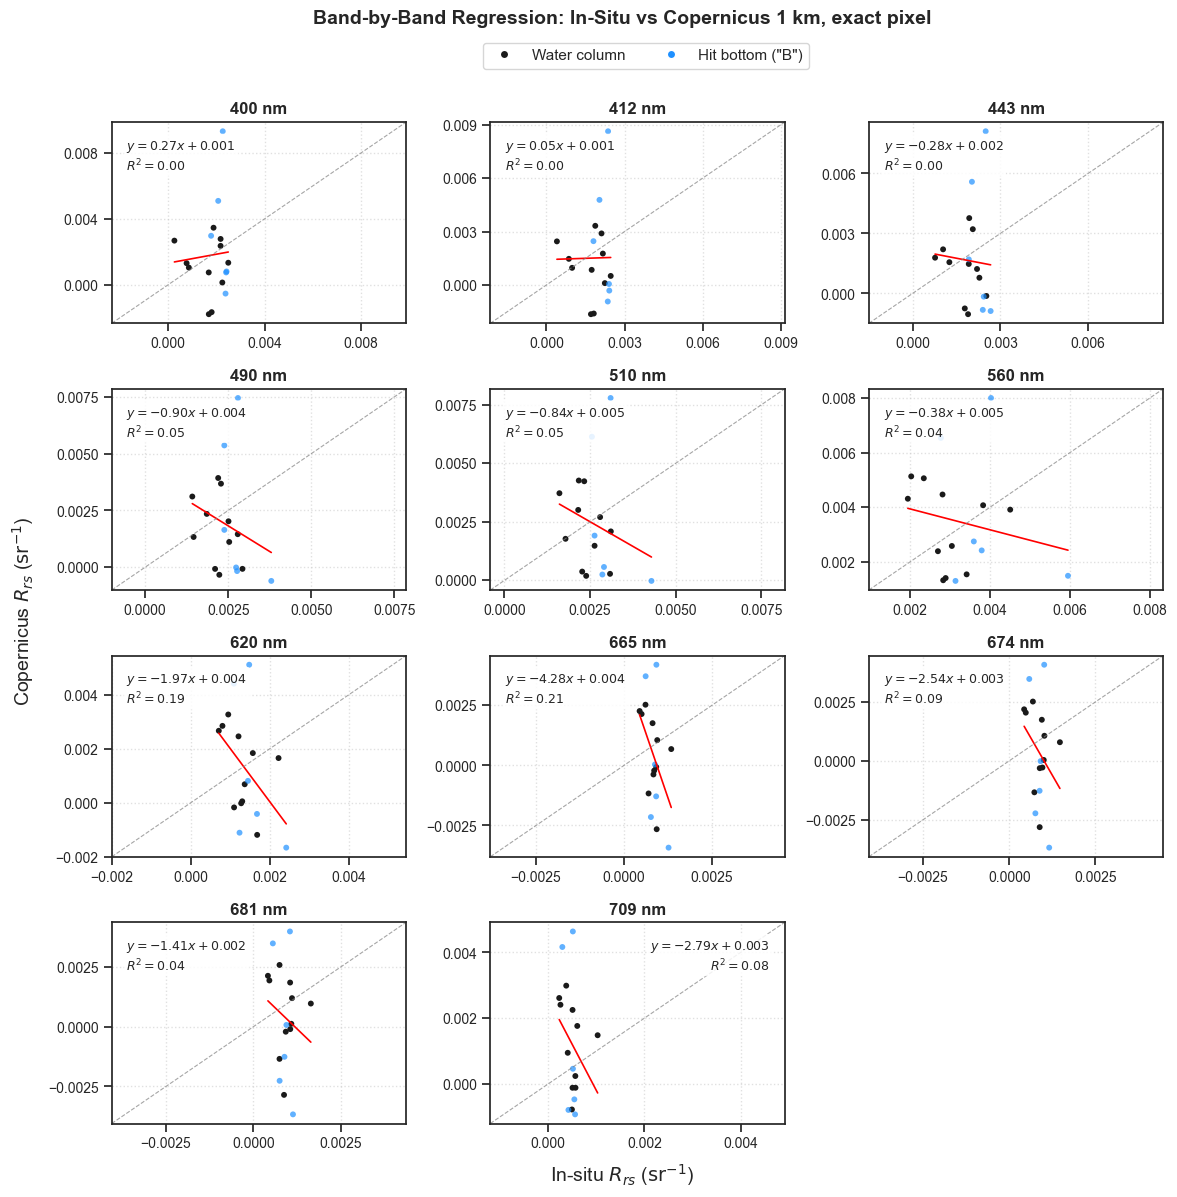

Saved figure to: C:/Users/25298423/PycharmProjects/FinalFigures/Bandwise_Scatter_Regression_Copernicus_1km_Exact.png


In [239]:
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

# Choose the Copernicus dataset
# Exact-pixel analysis:
satellite_suffix = "_copernicus"
satellite_label = "Copernicus 1 km, exact pixel"

# For the expanded analysis, use instead:
# satellite_suffix = "_copernicus_adj"
# satellite_label = "Copernicus 1 km, exact + local fallback"


# Work on a copy
df_copernicus = results_df.copy()

# Ensure Notes is available
if "Notes" not in df_copernicus.columns:

    if "secchi" in globals():

        df_copernicus = df_copernicus.merge(
            secchi[
                ["Site", "Notes"]
            ],
            on="Site",
            how="left"
        )

    else:
        df_copernicus["Notes"] = ""

# 1. Identify matching in-situ and Copernicus Rrs columns

# In-situ columns are named:
# "400", "412", "443", etc.
insitu_columns = {}

for column in df_copernicus.columns:

    column_string = str(column)

    match = re.match(
        r"^(\d+(?:\.\d+)?)$",
        column_string
    )

    if match:

        wavelength = float(
            match.group(1)
        )

        if wavelength < 1000:
            insitu_columns[wavelength] = column

# Copernicus columns are named:
# RRS400_copernicus
# RRS412_copernicus
# etc.
satellite_columns = {}

satellite_pattern = re.compile(
    rf"^RRS(\d+(?:\.\d+)?)"
    rf"{re.escape(satellite_suffix)}$"
)

for column in df_copernicus.columns:

    column_string = str(column)

    match = satellite_pattern.match(
        column_string
    )

    if match:
        wavelength = float(
            match.group(1)
        )

        satellite_columns[wavelength] = column

# Keep only bands available in both datasets
valid_wavelengths = sorted(
    set(insitu_columns)
    .intersection(
        satellite_columns
    )
)

valid_wavelengths = [
    (
        wavelength,
        insitu_columns[wavelength],
        satellite_columns[wavelength]
    )
    for wavelength in valid_wavelengths
]

print(
    "Valid plotted wavelengths:",
    [
        item[0]
        for item in valid_wavelengths
    ]
)

# 2. Set up the plotting grid

n_bands = len(
    valid_wavelengths
)

n_cols = 3
n_rows = (
                 n_bands
                 + n_cols
                 - 1
         ) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 3.2 * n_rows)
)

axes = np.asarray(
    axes
).flatten()

# 3. Plot one regression panel per wavelength

for i, (
        wavelength,
        insitu_col,
        satellite_col
) in enumerate(valid_wavelengths):

    ax = axes[i]

    # Convert values to numeric
    x = pd.to_numeric(
        df_copernicus[insitu_col],
        errors="coerce"
    )

    y = pd.to_numeric(
        df_copernicus[satellite_col],
        errors="coerce"
    )

    valid_mask = (
            np.isfinite(x)
            & np.isfinite(y)
    )

    x_valid = x[valid_mask]
    y_valid = y[valid_mask]

    notes_valid = (
        df_copernicus.loc[
            valid_mask,
            "Notes"
        ]
        .fillna("")
        .astype(str)
    )

    # Identify bottom-hit observations
    bottom_mask = (
        notes_valid.str.contains(
            "B",
            na=False
        )
    )

    water_mask = ~bottom_mask

    # Plot water-column observations
    ax.scatter(
        x_valid[water_mask],
        y_valid[water_mask],
        color="k",
        marker="o",
        s=18,
        edgecolor="none",
        label="Water column"
    )

    # Plot bottom-hit observations
    ax.scatter(
        x_valid[bottom_mask],
        y_valid[bottom_mask],
        color="dodgerblue",
        marker="o",
        s=18,
        alpha=0.7,
        edgecolor="none",
        label='Hit bottom ("B")'
    )

    # Linear regression using all valid observations
    if (
            len(x_valid) >= 2
            and x_valid.nunique() >= 2
    ):

        slope, intercept, r_value, _, _ = (
            linregress(
                x_valid,
                y_valid
            )
        )

        r_squared = r_value ** 2

        x_line = np.linspace(
            x_valid.min(),
            x_valid.max(),
            100
        )

        y_line = (
                slope * x_line
                + intercept
        )

        ax.plot(
            x_line,
            y_line,
            color="red",
            linewidth=1.2
        )

        equation_text = (
            f"$y = {slope:.2f}x "
            f"+ {intercept:.3f}$\n"
            f"$R^2 = {r_squared:.2f}$"
        )

    else:

        equation_text = (
            "Insufficient data\n"
            "for regression"
        )

    # 1:1 reference line and equal panel limits
    data_min = min(
        x_valid.min(),
        y_valid.min()
    )

    data_max = max(
        x_valid.max(),
        y_valid.max()
    )

    data_range = data_max - data_min

    if data_range == 0:
        padding = 0.001
    else:
        padding = 0.05 * data_range

    limits = [
        data_min - padding,
        data_max + padding
    ]

    ax.plot(
        limits,
        limits,
        color="gray",
        linestyle="--",
        linewidth=0.8,
        alpha=0.7
    )

    ax.set_xlim(
        limits
    )

    ax.set_ylim(
        limits
    )

    ax.xaxis.set_major_locator(
        MaxNLocator(nbins=4)
    )

    ax.yaxis.set_major_locator(
        MaxNLocator(nbins=4)
    )

    # Position equation text
    if wavelength >= 708.8:

        equation_location = (
            0.95,
            0.92
        )

        equation_horizontal_alignment = "right"

    else:

        equation_location = (
            0.05,
            0.92
        )

        equation_horizontal_alignment = "left"

    ax.text(
        equation_location[0],
        equation_location[1],
        equation_text,
        transform=ax.transAxes,
        fontsize=9,
        ha=equation_horizontal_alignment,
        va="top",
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            edgecolor="none",
            alpha=0.85
        )
    )

    ax.set_title(
        f"{wavelength:g} nm",
        fontsize=12,
        fontweight="bold"
    )

    ax.grid(
        True,
        linestyle=":",
        alpha=0.6
    )

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=10
    )

# Remove unused panels
for j in range(
        len(valid_wavelengths),
        len(axes)
):
    fig.delaxes(
        axes[j]
    )

# 4. Add common labels, legend and save the figure

legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="k",
        markersize=6,
        label="Water column"
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="dodgerblue",
        markersize=6,
        label='Hit bottom ("B")'
    )
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(
        0.55,
        0.95
    ),
    ncol=2,
    frameon=True,
    fontsize=11
)

fig.supxlabel(
    r"In-situ $R_{rs}$ ($\mathrm{sr^{-1}}$)",
    fontsize=14,
    y=0.05,
    x=0.53
)

fig.supylabel(
    r"Copernicus $R_{rs}$ ($\mathrm{sr^{-1}}$)",
    fontsize=14,
    x=0.02
)

fig.suptitle(
    f"Band-by-Band Regression: In-Situ vs "
    f"{satellite_label}",
    fontsize=14,
    fontweight="bold",
    y=0.97,
    x=0.53
)

plt.tight_layout(
    rect=[
        0,
        0.03,
        1,
        0.94
    ]
)

output_path = (
    "C:/Users/25298423/PycharmProjects/"
    "FinalFigures/"
    "Bandwise_Scatter_Regression_"
    "Copernicus_1km_Exact.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved figure to: {output_path}"
)


In [245]:
## Stats for band by band copernicus regression
import re
import numpy as np
import pandas as pd
from scipy.stats import linregress

# Select the Copernicus matchup dataset
# Strict exact-pixel values:
satellite_suffix = "_copernicus"

# For exact-plus-local-fallback values, use:
# satellite_suffix = "_copernicus_adj"


df_copernicus = results_df.copy()

# Identify in-situ wavelength columns named:
# "400", "412", "443", etc.
insitu_columns = {}

for column in df_copernicus.columns:

    column_string = str(column)

    match = re.match(
        r"^(\d+(?:\.\d+)?)$",
        column_string
    )

    if match:

        wavelength = float(
            match.group(1)
        )

        if wavelength < 1000:
            insitu_columns[wavelength] = column

# Identify Copernicus columns named:
# RRS400_copernicus
# RRS412_copernicus
# etc.
satellite_columns = {}

satellite_pattern = re.compile(
    rf"^RRS(\d+(?:\.\d+)?)"
    rf"{re.escape(satellite_suffix)}$"
)

for column in df_copernicus.columns:

    column_string = str(column)

    match = satellite_pattern.match(
        column_string
    )

    if match:
        wavelength = float(
            match.group(1)
        )

        satellite_columns[wavelength] = column

# Use only wavelengths available in both datasets
valid_wavelengths = sorted(
    set(insitu_columns)
    .intersection(
        satellite_columns
    )
)

# Calculate the regression statistics
regression_results = []

for wavelength in valid_wavelengths:

    insitu_col = insitu_columns[
        wavelength
    ]

    satellite_col = satellite_columns[
        wavelength
    ]

    paired = df_copernicus[
        [
            insitu_col,
            satellite_col
        ]
    ].copy()

    paired[insitu_col] = pd.to_numeric(
        paired[insitu_col],
        errors="coerce"
    )

    paired[satellite_col] = pd.to_numeric(
        paired[satellite_col],
        errors="coerce"
    )

    paired = paired.replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna()

    x = paired[
        insitu_col
    ].to_numpy(dtype=float)

    y = paired[
        satellite_col
    ].to_numpy(dtype=float)

    n_valid = len(paired)

    # Regression requires at least two observations and
    # more than one unique in-situ value.
    if (
            n_valid >= 2
            and np.unique(x).size >= 2
    ):

        slope, intercept, r_value, _, _ = (
            linregress(x, y)
        )

        r_squared = r_value ** 2

    else:

        slope = np.nan
        intercept = np.nan
        r_squared = np.nan

    regression_results.append({
        "Wavelength": wavelength,
        "Slope": slope,
        "Intercept": intercept,
        "R2": r_squared,
        "N": n_valid
    })

# Create the dataframe
copernicus_regression_df = (
    pd.DataFrame(regression_results)
    .sort_values("Wavelength")
    .reset_index(drop=True)
)

# Create a rounded version for copying into Word
copernicus_regression_table = (
    copernicus_regression_df.copy()
)

copernicus_regression_table["Wavelength"] = (
    copernicus_regression_table["Wavelength"]
    .astype(int)
)

copernicus_regression_table["Slope"] = (
    copernicus_regression_table["Slope"]
    .round(4)
)

copernicus_regression_table["Intercept"] = (
    copernicus_regression_table["Intercept"]
    .round(6)
)

copernicus_regression_table["R2"] = (
    copernicus_regression_table["R2"]
    .round(4)
)

print(
    copernicus_regression_table.to_string(
        index=False
    )
)


 Wavelength   Slope  Intercept     R2  N
        400  0.2691   0.001322 0.0044 17
        412  0.0484   0.001424 0.0001 17
        443 -0.2824   0.002182 0.0037 17
        490 -0.9049   0.004087 0.0524 17
        510 -0.8412   0.004608 0.0530 17
        560 -0.3823   0.004710 0.0360 17
        620 -1.9675   0.003972 0.1948 17
        665 -4.2841   0.004022 0.2124 17
        674 -2.5427   0.002564 0.0854 17
        681 -1.4073   0.001679 0.0355 17
        709 -2.7941   0.002592 0.0814 17


In [246]:
copernicus_regression_table

,Wavelength,Slope,Intercept,R2,N
0,400,0.2691,0.001322,0.0044,17
1,412,0.0484,0.001424,0.0001,17
2,443,-0.2824,0.002182,0.0037,17
3,490,-0.9049,0.004087,0.0524,17
4,510,-0.8412,0.004608,0.0530,17
5,560,-0.3823,0.004710,0.0360,17
6,620,-1.9675,0.003972,0.1948,17
7,665,-4.2841,0.004022,0.2124,17
8,674,-2.5427,0.002564,0.0854,17
9,681,-1.4073,0.001679,0.0355,17


## LOSO For Copernicus Data

In [287]:
cdom_cols = [
    "CDOM_a412_m-1",
    "CDOM_a434_m-1",
    "CDOM_a443_m-1",
    "CDOM_a490_m-1"
]

# Ensure both dataframes use the capitalized 'Site' column name
results_df= pd.merge(
    results_df.rename(columns={"site": "Site"}),
    water_samples[["Site"] + cdom_cols],
    on="Site",
    how="left"
)

In [289]:
list(results_df.columns)

['Site',
 'Date',
 'latitude_dec',
 'longitude_dec',
 '400',
 '412',
 '443',
 '490',
 '510',
 '560',
 '620',
 '665',
 '674',
 '681',
 '709',
 'RRS400_copernicus',
 'RRS400_copernicus_adj',
 'RRS412_copernicus',
 'RRS412_copernicus_adj',
 'RRS443_copernicus',
 'RRS443_copernicus_adj',
 'RRS490_copernicus',
 'RRS490_copernicus_adj',
 'RRS510_copernicus',
 'RRS510_copernicus_adj',
 'RRS560_copernicus',
 'RRS560_copernicus_adj',
 'RRS620_copernicus',
 'RRS620_copernicus_adj',
 'RRS665_copernicus',
 'RRS665_copernicus_adj',
 'RRS674_copernicus',
 'RRS674_copernicus_adj',
 'RRS681_copernicus',
 'RRS681_copernicus_adj',
 'RRS709_copernicus',
 'RRS709_copernicus_adj',
 'RRS_selected_pixel_lat',
 'RRS_selected_pixel_lon',
 'RRS_distance_to_selected_pixel_m',
 'RRS_matchup_source',
 'Notes',
 'CDOM_a412_m-1',
 'CDOM_a434_m-1',
 'CDOM_a443_m-1',
 'CDOM_a490_m-1']

In [339]:
## FIT BASE-10 IN-SITU CDOM MODEL USING ALL VALID OBSERVATIONS - KEEP FOR FINAL

import numpy as np
import pandas as pd
import statsmodels.api as sm

# Model configuration
site_col = "Site"
target_col = "CDOM_a443_m-1"

# In-situ Rrs predictors
in_situ_bands = [
    "443",
    "490",
    "510",
    "560"
]

# CDOM columns that must be positive and non-missing
cdom_check_cols = [
    "CDOM_a412_m-1",
    "CDOM_a434_m-1",
    "CDOM_a443_m-1",
    "CDOM_a490_m-1"
]

# Keep only CDOM columns that are present
cdom_check_cols = [
    column
    for column in cdom_check_cols
    if column in results_df.columns
]

if not cdom_check_cols:
    raise ValueError(
        "No CDOM absorbance columns were found in results_df."
    )

# Build the required-column list without duplicates.
# CDOM_a443_m-1 appears in cdom_check_cols and is also
# the target column, so duplicate removal is important.
required_columns = list(
    dict.fromkeys(
        in_situ_bands
        + cdom_check_cols
        + [target_col]
    )
)

missing_columns = [
    column
    for column in required_columns
                  + [site_col]
    if column not in results_df.columns
]

if missing_columns:
    raise KeyError(
        "The following required columns are missing: "
        f"{missing_columns}"
    )

# Filter missing values
clean_model_df = (
    results_df[
        required_columns
        + [site_col]
        ]
    .dropna(
        subset=required_columns
    )
    .copy()
)

# Require all model inputs and CDOM absorbances
# to be strictly positive
positive_mask = (
        clean_model_df[
            required_columns
        ] > 0
).all(axis=1)

clean_model_df = clean_model_df[
    positive_mask
].copy()

print(
    "Valid in-situ model observations:",
    len(clean_model_df)
)

print(
    "Valid in-situ model sites:",
    clean_model_df[
        site_col
    ].nunique()
)

print(
    "CDOM columns included in filtering:",
    cdom_check_cols
)

# Leave-one-site-out model fitting

loso_in_situ_predictions_base10 = []
in_situ_coefficients_base10 = []

for site in clean_model_df[
    site_col
].unique():

    train_df = clean_model_df[
        clean_model_df[site_col] != site
        ].copy()

    test_df = clean_model_df[
        clean_model_df[site_col] == site
        ].copy()

    if train_df.empty:
        continue

    # Training predictors and target
    X_train = train_df[
        in_situ_bands
    ]

    y_train = train_df.loc[
        :,
        target_col
    ]

    # Force the target to be one-dimensional
    if isinstance(y_train, pd.DataFrame):

        if y_train.shape[1] != 1:
            raise ValueError(
                f"{target_col} contains multiple columns."
            )

        y_train = y_train.iloc[:, 0]

    # Base-10 log transformation
    X_train_log10 = np.log10(
        X_train
    )

    X_train_log10 = sm.add_constant(
        X_train_log10,
        has_constant="add"
    )

    y_train_log10 = np.log10(
        y_train
    )

    # Fit the OLS model
    model = sm.OLS(
        y_train_log10,
        X_train_log10
    ).fit()

    # Model parameters should be a one-dimensional Series
    params = model.params

    if isinstance(params, pd.DataFrame):

        if params.shape[1] != 1:
            raise ValueError(
                "The model coefficients contain multiple "
                "columns. Check the target column structure."
            )

        params = params.iloc[:, 0]

    # Store one flat coefficient dictionary per left-out site
    in_situ_coefficients_base10.append({
        "site_left_out": site,
        **params.to_dict()
    })

    # Predict the left-out site using in-situ Rrs
    if not test_df.empty:

        X_test_log10 = np.log10(
            test_df[in_situ_bands]
        )

        X_test_log10 = sm.add_constant(
            X_test_log10,
            has_constant="add"
        )

        X_test_log10 = (
            X_test_log10.reindex(
                columns=X_train_log10.columns,
                fill_value=0
            )
        )

        predicted_log10 = model.predict(
            X_test_log10
        )

        # Back-transform from base-10 log space
        predicted_values = (
                10 ** np.asarray(
            predicted_log10,
            dtype=float
        )
        ).ravel()

        # Extract observed values as a one-dimensional array
        observed_values = test_df.loc[
            :,
            target_col
        ]

        if isinstance(observed_values, pd.DataFrame):

            if observed_values.shape[1] != 1:
                raise ValueError(
                    f"{target_col} contains multiple columns "
                    "in the test dataframe."
                )

            observed_values = (
                observed_values.iloc[:, 0]
            )

        observed_values = (
            observed_values
            .to_numpy(dtype=float)
            .ravel()
        )

        # Store scalar values, not arrays
        loso_in_situ_predictions_base10.extend([
            {
                "site": site,
                "observed": float(observed),
                "predicted_insitu_model": float(predicted)
            }
            for observed, predicted
            in zip(
                observed_values,
                predicted_values
            )
        ])

# Create final output dataframes

loso_in_situ_results_base10 = pd.DataFrame(
    loso_in_situ_predictions_base10
)

coeffs_in_situ_base10 = pd.DataFrame(
    in_situ_coefficients_base10
)

print(
    "\nLOSO in-situ prediction results:"
)

print(
    loso_in_situ_results_base10
)

print(
    "\nBase-10 in-situ model coefficients:"
)

print(
    coeffs_in_situ_base10
)

print(
    "\nCoefficient dataframe columns:"
)

print(
    coeffs_in_situ_base10.columns.tolist()
)


Valid in-situ model observations: 25
Valid in-situ model sites: 25
CDOM columns included in filtering: ['CDOM_a412_m-1', 'CDOM_a434_m-1', 'CDOM_a443_m-1', 'CDOM_a490_m-1']

LOSO in-situ prediction results:
       site  observed  predicted_insitu_model
0    ISO-01    3.2217                2.273650
1    ISO-02    3.1513                1.835101
2    ISO-03    1.7883                2.594923
3    ISO-04    2.1257                2.263226
4   ISO-08A    5.4946                4.198881
5   ISO-08B    2.7564                3.487838
6    ISO-09    1.4804                1.902935
7    ISO-10    0.8076                1.250226
8    ISO-11    1.4782                1.626374
9    ISO-12    1.7371                1.104434
10   ISO-05    0.4474                0.848113
11   ISO-06    0.4885                0.656961
12   ISO-07    0.6069                0.757553
13   ISO-14    0.9243                0.757280
14  ISO-GB1    0.8407                0.850855
15   ISO-20    0.7922                0.641192
16   ISO-22 

In [340]:
metrics_in_situ_model_base10 = (
    calculate_validation_metrics_base10(
        loso_in_situ_results_base10[
            "observed"
        ],
        loso_in_situ_results_base10[
            "predicted_insitu_model"
        ]
    )
)

print(
    metrics_in_situ_model_base10
)



{'N': 25, 'R2_original': np.float64(0.7960707147831624), 'R2_log10': np.float64(0.7721290926358998), 'Spearman_Rho': np.float64(0.7876923076923077), 'Spearman_p': np.float64(2.960639883355387e-06), 'Slope_log10': np.float64(0.8033008890618304), 'Intercept_log10': np.float64(0.0012844152352811736), 'Slope_original': np.float64(0.745107287253225), 'Intercept_original': np.float64(0.2788563719802031), 'RMSD': np.float64(0.5325432245381191), 'Log10_RMSE': np.float64(0.14731973421800407), 'MdPD_percent': np.float64(6.469672771313836), 'MdAPD_percent': np.float64(24.823409098785536), 'Median_Log10_Bias': np.float64(0.02722591928909135), 'Mean_Log10_Bias': np.float64(-0.0013061699839247954)}


In [341]:
rounded_metrics_in_situ_model = {k: round(v, 4) for k, v in metrics_in_situ_model_base10.items()}
df = pd.DataFrame(list(rounded_metrics_in_situ_model.items()), columns=["Metric", "Value"])

# Copy to clipboard
df.to_clipboard(excel=True, index=False)

In [342]:
coeffs_in_situ_base10.describe()


,const,443,490,510,560
count,25.000000,25.000000,25.000000,25.000000,25.000000
mean,-4.013144,-0.931929,0.691592,-2.042445,0.854191
std,0.150603,0.208561,1.090641,1.127127,0.235354
min,-4.510436,-1.373793,-2.093646,-4.592231,0.322563
25%,-4.058826,-0.976978,0.173850,-2.339427,0.731035
50%,-4.021898,-0.932946,0.697704,-2.055821,0.859496
75%,-3.989198,-0.858397,1.009145,-1.557419,0.938010
max,-3.670687,-0.449713,3.053763,0.797845,1.372055


In [348]:
# Copernicus satellite transfer using the fixed
# base-10 in-situ model coefficients

# Primary analysis: exact Copernicus pixels
copernicus_suffix = "_copernicus"

# For the sensitivity analysis, use:
# copernicus_suffix = "_copernicus_adj"


# Copernicus Rrs columns corresponding to the
# in-situ model predictor bands
satellite_bands = [
    f"RRS443{copernicus_suffix}",
    f"RRS490{copernicus_suffix}",
    f"RRS510{copernicus_suffix}",
    f"RRS560{copernicus_suffix}"
]

# Check satellite columns against results_df.
# clean_model_df does not contain satellite columns.
missing_satellite_columns = [
    column
    for column in satellite_bands
    if column not in results_df.columns
]

if missing_satellite_columns:
    raise ValueError(
        "Missing Copernicus columns: "
        f"{missing_satellite_columns}"
    )

# Coefficient columns expected from the
# base-10 in-situ model
model_columns = [
                    "const"
                ] + in_situ_bands

satellite_transfer_predictions = []

# Use the sites for which the in-situ model
# coefficients were generated
for site in clean_model_df[
    site_col
].unique():

    coefficient_rows = (
        coeffs_in_situ_base10[
            coeffs_in_situ_base10[
                "site_left_out"
            ] == site
            ]
    )

    if coefficient_rows.empty:
        continue

    coefficient_row = (
        coefficient_rows.iloc[0]
    )

    # Select the site from the original dataframe
    site_df = results_df[
        results_df[site_col] == site
        ].copy()

    # For the primary analysis, keep only exact
    # Copernicus pixel matchups.
    if copernicus_suffix == "_copernicus":

        if "RRS_matchup_source" not in site_df.columns:
            raise KeyError(
                "RRS_matchup_source is missing from "
                "results_df."
            )

        site_df = site_df[
            site_df[
                "RRS_matchup_source"
            ] == "exact"
            ].copy()

    # Require valid satellite Rrs and observed
    # in-situ CDOM443
    transfer_required_columns = (
            satellite_bands
            + [target_col]
    )

    site_df = site_df.dropna(
        subset=transfer_required_columns
    ).copy()

    positive_mask = (
            site_df[
                transfer_required_columns
            ] > 0
    ).all(axis=1)

    site_df = site_df[
        positive_mask
    ].copy()

    if site_df.empty:
        continue

    # Base-10 transform the Copernicus Rrs values
    X_satellite_log10 = np.log10(
        site_df[satellite_bands]
    )

    X_satellite_log10 = sm.add_constant(
        X_satellite_log10,
        has_constant="add"
    )

    # Rename Copernicus columns to match the
    # in-situ model predictor names
    rename_map = {
        satellite_band: in_situ_band
        for satellite_band, in_situ_band
        in zip(
            satellite_bands,
            in_situ_bands
        )
    }

    X_satellite_log10 = (
        X_satellite_log10.rename(
            columns=rename_map
        )
    )

    # Align precisely with the coefficient columns
    X_satellite_log10 = (
        X_satellite_log10.reindex(
            columns=model_columns,
            fill_value=0
        )
    )

    # Extract the left-out site's coefficients
    coefficients = coefficient_row[
        model_columns
    ].to_numpy(
        dtype=float
    )

    # Predict in base-10 log space
    predicted_log10 = (
            X_satellite_log10.to_numpy()
            @ coefficients
    )

    # Back-transform to original CDOM units
    predicted_values = (
            10 ** predicted_log10
    )

    # Store scalar values and metadata
    for row_index, predicted in zip(
            site_df.index,
            predicted_values
    ):

        result_row = {
            "site": site,
            "observed": float(
                site_df.loc[
                    row_index,
                    target_col
                ]
            ),
            "predicted_sat": float(
                predicted
            )
        }

        if "RRS_matchup_source" in site_df.columns:
            result_row[
                "RRS_matchup_source"
            ] = site_df.loc[
                row_index,
                "RRS_matchup_source"
            ]

        if (
                "RRS_distance_to_selected_pixel_m"
                in site_df.columns
        ):
            result_row[
                "RRS_distance_to_selected_pixel_m"
            ] = site_df.loc[
                row_index,
                "RRS_distance_to_selected_pixel_m"
            ]

        satellite_transfer_predictions.append(
            result_row
        )

# Final satellite-transfer dataframe
copernicus_cdom_transfer_base10 = (
    pd.DataFrame(
        satellite_transfer_predictions
    )
)

print(
    "Copernicus satellite-transfer results:"
)

print(
    copernicus_cdom_transfer_base10
)

print(
    "Number of Copernicus transfer predictions:",
    len(
        copernicus_cdom_transfer_base10
    )
)


Copernicus satellite-transfer results:
     site  observed  predicted_sat RRS_matchup_source  RRS_distance_to_selected_pixel_m
0  ISO-04    2.1257       0.799424              exact                        255.912263
1  ISO-11    1.4782       0.547946              exact                         73.733309
2  ISO-12    1.7371       0.693139              exact                        155.176461
3  ISO-06    0.4885       2.175462              exact                        222.523468
4  ISO-07    0.6069       0.909148              exact                        137.219832
5  ISO-14    0.9243       0.999512              exact                        257.708654
6  ISO-28    0.6212       0.147834              exact                        134.513677
7  ISO-29    1.1906       0.265277              exact                        316.755028
Number of Copernicus transfer predictions: 8


In [349]:

metrics_copernicus_cdom_transfer_base10 = calculate_validation_metrics_sat_base10(copernicus_cdom_transfer_base10["observed"],
        copernicus_cdom_transfer_base10["predicted_sat"])


print(
    metrics_copernicus_cdom_transfer_base10
)


{'N': 8, 'R2_original': np.float64(-2.1337417361301316), 'R2_log10': np.float64(-3.6322953733254906), 'Spearman_Rho': np.float64(-0.3571428571428572), 'Spearman_p': np.float64(0.3851206435562562), 'Slope_log10': np.float64(-0.18994705892134808), 'Intercept_log10': np.float64(-0.20248570452586895), 'Slope_original': np.float64(-0.33882234583935406), 'Intercept_original': np.float64(1.2056988963429334), 'RMSD': np.float64(0.9834494826900951), 'Log10_RMSE': np.float64(0.4732858373269779), 'MdPD_percent': np.float64(-61.24516657038767), 'MdAPD_percent': np.float64(62.661980194106064), 'Median_Log10_Bias': np.float64(-0.4118645035270288), 'Mean_Log10_Bias': np.float64(-0.20900839555498102)}


In [350]:
metrics_copernicus_cdom_transfer_base10

{'N': 8,
 'R2_original': np.float64(-2.1337417361301316),
 'R2_log10': np.float64(-3.6322953733254906),
 'Spearman_Rho': np.float64(-0.3571428571428572),
 'Spearman_p': np.float64(0.3851206435562562),
 'Slope_log10': np.float64(-0.18994705892134808),
 'Intercept_log10': np.float64(-0.20248570452586895),
 'Slope_original': np.float64(-0.33882234583935406),
 'Intercept_original': np.float64(1.2056988963429334),
 'RMSD': np.float64(0.9834494826900951),
 'Log10_RMSE': np.float64(0.4732858373269779),
 'MdPD_percent': np.float64(-61.24516657038767),
 'MdAPD_percent': np.float64(62.661980194106064),
 'Median_Log10_Bias': np.float64(-0.4118645035270288),
 'Mean_Log10_Bias': np.float64(-0.20900839555498102)}

In [351]:
rounded_base10_metrics_copernicus = {k: round(v, 4) for k,v in metrics_copernicus_cdom_transfer_base10.items()}

In [352]:
df = pd.DataFrame(list(rounded_base10_metrics_copernicus.items()), columns=["Metric", "Value"])

# Copy to clipboard
df.to_clipboard(excel=True, index=False)

{'N': 8, 'R2_original': np.float64(-2.1337417361301316), 'R2_log10': np.float64(-3.6322953733254906), 'Spearman_Rho': np.float64(-0.3571428571428572), 'Spearman_p': np.float64(0.3851206435562562), 'Slope_log10': np.float64(-0.18994705892134808), 'Intercept_log10': np.float64(-0.20248570452586895), 'Slope_original': np.float64(-0.33882234583935406), 'Intercept_original': np.float64(1.2056988963429334), 'RMSD': np.float64(0.9834494826900951), 'Log10_RMSE': np.float64(0.4732858373269779), 'MdPD_percent': np.float64(-61.24516657038767), 'MdAPD_percent': np.float64(62.661980194106064), 'Median_Log10_Bias': np.float64(-0.4118645035270288), 'Mean_Log10_Bias': np.float64(-0.20900839555498102)}


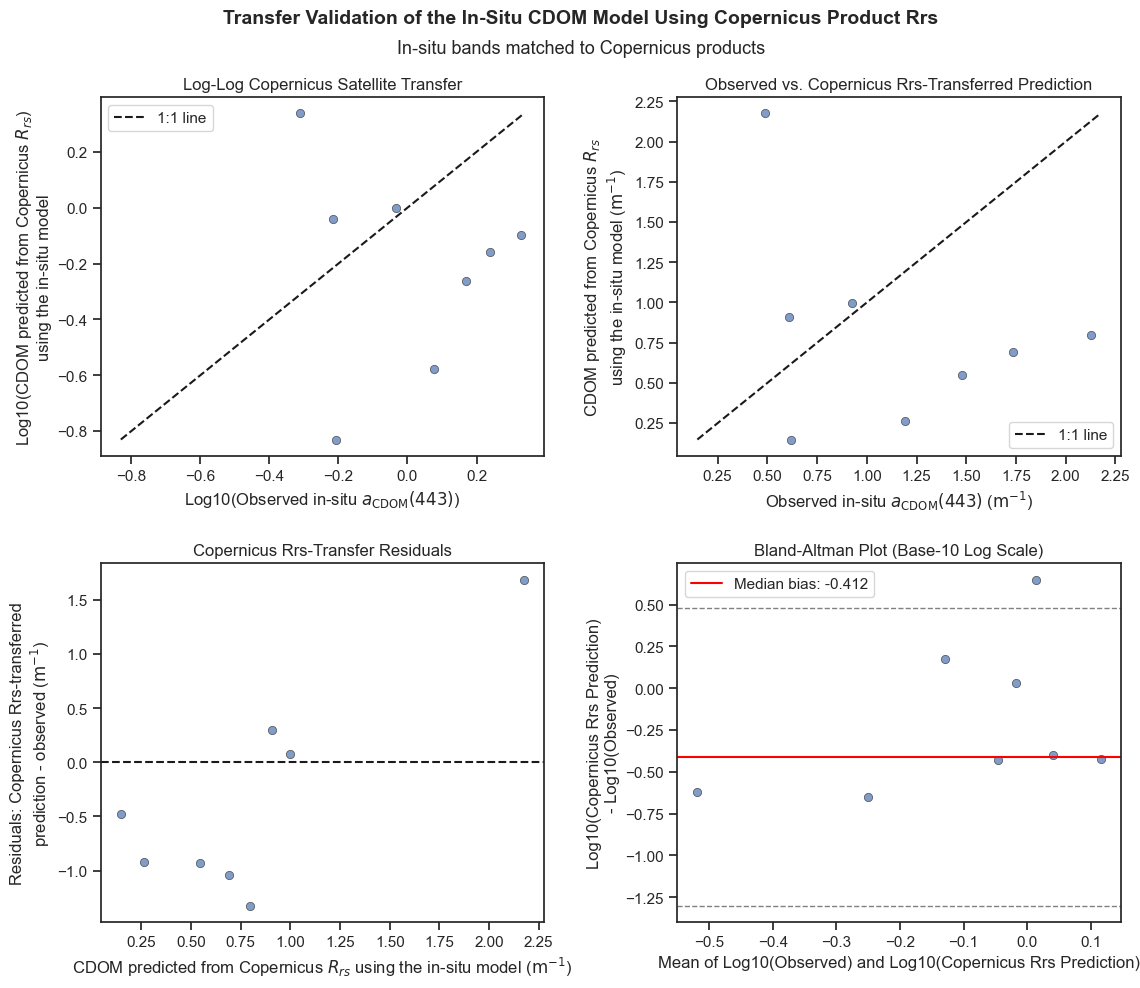

Saved figure to: C:/Users/25298423/PycharmProjects/FinalFigures/loso_Copernicus_satellite_validation_plot.png


In [385]:
import numpy as np
import matplotlib.pyplot as plt


def plot_copernicus_transfer_validation_base10(
        results_df,
        obs_col="observed",
        pred_col="predicted_sat"
):
    """
    Plot Copernicus satellite-transfer validation results
    using base-10 logarithms.
    """

    y_true = results_df[
        obs_col
    ].to_numpy(
        dtype=float
    )

    y_pred = results_df[
        pred_col
    ].to_numpy(
        dtype=float
    )

    valid = (
            np.isfinite(y_true)
            & np.isfinite(y_pred)
            & (y_true > 0)
            & (y_pred > 0)
    )

    y_true = y_true[
        valid
    ]

    y_pred = y_pred[
        valid
    ]

    log10_true = np.log10(
        y_true
    )

    log10_pred = np.log10(
        y_pred
    )

    residuals = (
            y_pred - y_true
    )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(12, 11)
    )

    fig.subplots_adjust(
        top=0.85,
        bottom=0.1,
        left=0.1,
        right=0.95,
        hspace=0.3,
        wspace=0.3
    )

    # ---------------------------------------------------------
    # 1. Log-log scatterplot
    # ---------------------------------------------------------
    ax = axes[0, 0]

    ax.scatter(
        log10_true,
        log10_pred,
        alpha=0.7,
        edgecolor="k",
        linewidth=0.5
    )

    min_val = min(
        log10_true.min(),
        log10_pred.min()
    )

    max_val = max(
        log10_true.max(),
        log10_pred.max()
    )

    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        "k--",
        linewidth=1.5,
        label="1:1 line"
    )

    ax.set_xlabel(
        r"Log10(Observed in-situ "
        r"$a_{\mathrm{CDOM}}(443)$)"
    )

    ax.set_ylabel(
        r"Log10(CDOM predicted from Copernicus "
        r"$R_{rs}$)" + "\n" + r"using the in-situ model"
    )

    ax.set_title(
        "Log-Log Copernicus Satellite Transfer"
    )

    ax.legend(
        loc="best"
    )

    # ---------------------------------------------------------
    # 2. Original-scale comparison
    # ---------------------------------------------------------
    ax = axes[0, 1]

    ax.scatter(
        y_true,
        y_pred,
        alpha=0.7,
        edgecolor="k",
        linewidth=0.5
    )

    min_original = min(
        y_true.min(),
        y_pred.min()
    )

    max_original = max(
        y_true.max(),
        y_pred.max()
    )

    ax.plot(
        [
            min_original,
            max_original
        ],
        [
            min_original,
            max_original
        ],
        "k--",
        linewidth=1.5,
        label="1:1 line"
    )

    ax.set_xlabel(
        r"Observed in-situ "
        r"$a_{\mathrm{CDOM}}(443)$ "
        r"($\mathrm{m^{-1}}$)"
    )

    ax.set_ylabel(
        r"CDOM predicted from Copernicus "
        r"$R_{rs}$" + "\n" + r"using the in-situ model "
                             r"($\mathrm{m^{-1}}$)"
    )

    ax.set_title(
        "Observed vs. Copernicus Rrs-Transferred Prediction"
    )

    ax.legend(
        loc="best"
    )

    # ---------------------------------------------------------
    # 3. Residual plot
    # ---------------------------------------------------------
    ax = axes[1, 0]

    ax.scatter(
        y_pred,
        residuals,
        alpha=0.7,
        edgecolor="k",
        linewidth=0.5
    )

    ax.axhline(
        0,
        color="k",
        linestyle="--",
        linewidth=1.5
    )

    ax.set_xlabel(
        r"CDOM predicted from Copernicus "
        r"$R_{rs}$ using the in-situ model "
        r"($\mathrm{m^{-1}}$)"
    )

    ax.set_ylabel(
        r"Residuals: Copernicus Rrs-transferred"
        + "\n"
        + r"prediction - observed ($\mathrm{m^{-1}}$)"
    )

    ax.set_title(
        "Copernicus Rrs-Transfer Residuals"
    )

    # ---------------------------------------------------------
    # 4. Bland-Altman plot in base-10 log space
    # ---------------------------------------------------------
    ax = axes[1, 1]

    mean_log10 = (
                         log10_true
                         + log10_pred
                 ) / 2

    difference_log10 = (
            log10_pred
            - log10_true
    )

    median_bias = np.median(
        difference_log10
    )

    sd_difference = np.std(
        difference_log10,
        ddof=1
    )

    ax.scatter(
        mean_log10,
        difference_log10,
        alpha=0.7,
        edgecolor="k",
        linewidth=0.5
    )

    ax.axhline(
        median_bias,
        color="red",
        linestyle="-",
        linewidth=1.5,
        label=(
            f"Median bias: "
            f"{median_bias:.3f}"
        )
    )

    ax.axhline(
        median_bias
        + 1.96 * sd_difference,
        color="gray",
        linestyle="--",
        linewidth=1
    )

    ax.axhline(
        median_bias
        - 1.96 * sd_difference,
        color="gray",
        linestyle="--",
        linewidth=1
    )

    ax.set_xlabel(
        "Mean of Log10(Observed) and "
        "Log10(Copernicus Rrs Prediction)"
    )

    ax.set_ylabel(
        "Log10(Copernicus Rrs Prediction)"
        + "\n"
        + "- Log10(Observed)"
    )

    ax.set_title(
        "Bland-Altman Plot "
        "(Base-10 Log Scale)"
    )

    ax.legend(
        loc="best"
    )

    # Main title and subtitle
    fig.suptitle(
        "Transfer Validation of the In-Situ CDOM Model Using Copernicus Product Rrs",
        fontsize=14,
        fontweight="bold",
        y=0.93
    )

    fig.text(
        0.5,
        0.89,
        "In-situ bands matched to Copernicus products",
        ha="center",
        fontsize=13,
        fontweight="normal"
    )
    fig.subplots_adjust(top = 0.85, bottom = 0.1, left = 0.1, right = 0.95, hspace= 0.30, wspace= 0.3)
    output_path = (
        "C:/Users/25298423/PycharmProjects/"
        "FinalFigures/"
        "loso_Copernicus_satellite_validation_plot.png"
    )

    plt.savefig(
        output_path,
        dpi=1200,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"Saved figure to: {output_path}"
    )


# Calculate and print the Copernicus transfer metrics
metrics_copernicus_transfer_base10 = (
    calculate_validation_metrics_sat_base10(
        copernicus_cdom_transfer_base10[
            "observed"
        ],
        copernicus_cdom_transfer_base10[
            "predicted_sat"
        ]
    )
)

print(
    metrics_copernicus_transfer_base10
)

# Plot the Copernicus exact-pixel satellite transfer
plot_copernicus_transfer_validation_base10(
    copernicus_cdom_transfer_base10
)

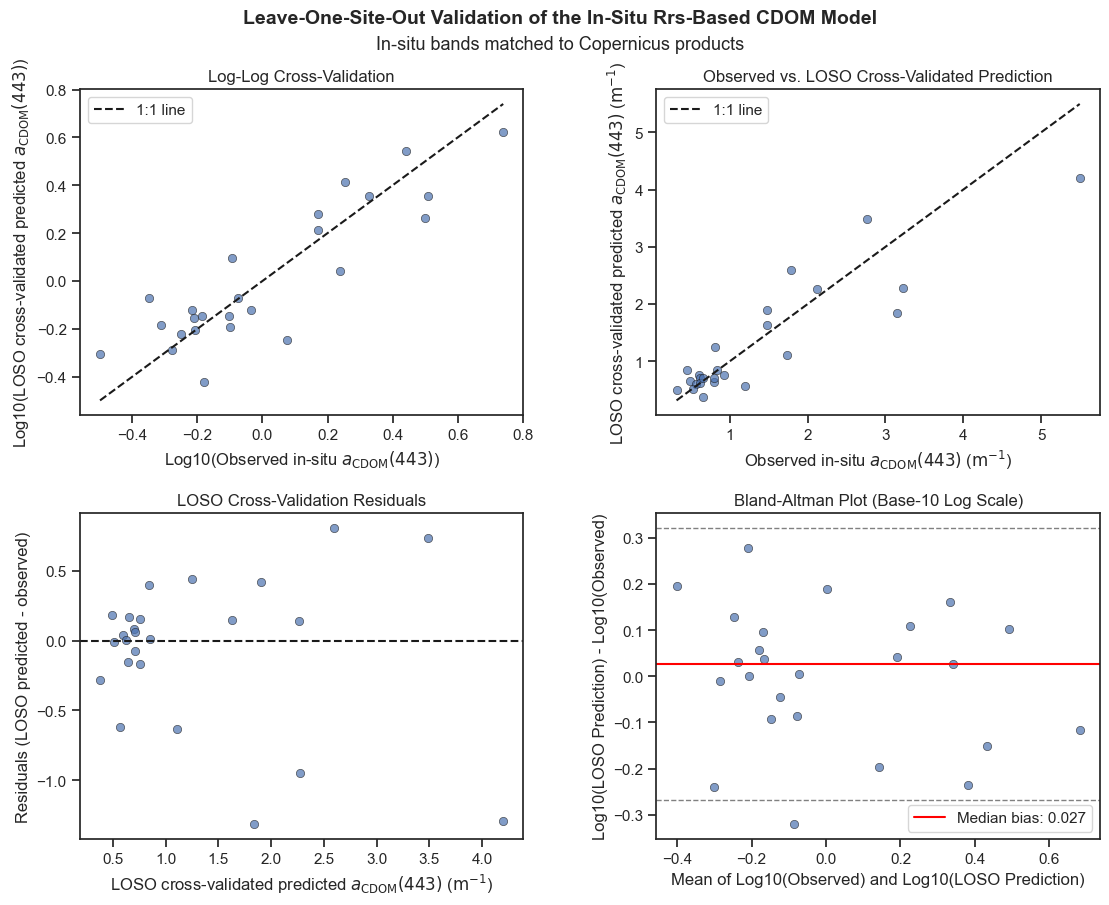

Saved figure to: C:/Users/25298423/PycharmProjects/FinalFigures/loso_Copernicus_matchup_insitu_model_plot.png


In [387]:
import numpy as np
import matplotlib.pyplot as plt


def plot_copernicus_in_situ_model_base10(
        results_df,
        obs_col="observed",
        pred_col="predicted_insitu_model"
):
    """
    Plot the base-10 LOSO validation results for the
    in-situ Rrs-based CDOM model fitted using the
    Copernicus matchup dataframe.
    """

    y_true = results_df[
        obs_col
    ].to_numpy(
        dtype=float
    )

    y_pred = results_df[
        pred_col
    ].to_numpy(
        dtype=float
    )

    valid = (
            np.isfinite(y_true)
            & np.isfinite(y_pred)
            & (y_true > 0)
            & (y_pred > 0)
    )

    y_true = y_true[
        valid
    ]

    y_pred = y_pred[
        valid
    ]

    # Base-10 logarithms
    log_true = np.log10(
        y_true
    )

    log_pred = np.log10(
        y_pred
    )

    residuals = (
            y_pred - y_true
    )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(12, 10)
    )

    # ---------------------------------------------------------
    # 1. Log-log scatterplot
    # ---------------------------------------------------------
    ax = axes[0, 0]

    ax.scatter(
        log_true,
        log_pred,
        alpha=0.7,
        edgecolor="k",
        linewidth=0.5
    )

    min_val = min(
        log_true.min(),
        log_pred.min()
    )

    max_val = max(
        log_true.max(),
        log_pred.max()
    )

    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        "k--",
        linewidth=1.5,
        label="1:1 line"
    )

    ax.set_xlabel(
        r"Log10(Observed in-situ "
        r"$a_{\mathrm{CDOM}}(443)$)"
    )

    ax.set_ylabel(
        r"Log10(LOSO cross-validated "
        r"predicted $a_{\mathrm{CDOM}}(443)$)"
    )

    ax.set_title(
        "Log-Log Cross-Validation"
    )

    ax.legend(
        loc="best"
    )

    # ---------------------------------------------------------
    # 2. Original-scale observed versus predicted
    # ---------------------------------------------------------
    ax = axes[0, 1]

    ax.scatter(
        y_true,
        y_pred,
        alpha=0.7,
        edgecolor="k",
        linewidth=0.5
    )

    min_val_original = min(
        y_true.min(),
        y_pred.min()
    )

    max_val_original = max(
        y_true.max(),
        y_pred.max()
    )

    ax.plot(
        [
            min_val_original,
            max_val_original
        ],
        [
            min_val_original,
            max_val_original
        ],
        "k--",
        linewidth=1.5,
        label="1:1 line"
    )

    ax.set_xlabel(
        r"Observed in-situ "
        r"$a_{\mathrm{CDOM}}(443)$ "
        r"($\mathrm{m^{-1}}$)"
    )

    ax.set_ylabel(
        r"LOSO cross-validated predicted "
        r"$a_{\mathrm{CDOM}}(443)$ "
        r"($\mathrm{m^{-1}}$)"
    )

    ax.set_title(
        "Observed vs. LOSO Cross-Validated Prediction"
    )

    ax.legend(
        loc="best"
    )

    # ---------------------------------------------------------
    # 3. Residual plot
    # ---------------------------------------------------------
    ax = axes[1, 0]

    ax.scatter(
        y_pred,
        residuals,
        alpha=0.7,
        edgecolor="k",
        linewidth=0.5
    )

    ax.axhline(
        0,
        color="k",
        linestyle="--",
        linewidth=1.5
    )

    ax.set_xlabel(
        r"LOSO cross-validated predicted "
        r"$a_{\mathrm{CDOM}}(443)$ "
        r"($\mathrm{m^{-1}}$)"
    )

    ax.set_ylabel(
        "Residuals (LOSO predicted - observed)"
    )

    ax.set_title(
        "LOSO Cross-Validation Residuals"
    )

    # ---------------------------------------------------------
    # 4. Bland-Altman plot in base-10 log space
    # ---------------------------------------------------------
    ax = axes[1, 1]

    mean_log = (
                       log_true
                       + log_pred
               ) / 2

    difference_log = (
            log_pred
            - log_true
    )

    median_bias = np.median(
        difference_log
    )

    sd_difference = np.std(
        difference_log,
        ddof=1
    )

    ax.scatter(
        mean_log,
        difference_log,
        alpha=0.7,
        edgecolor="k",
        linewidth=0.5
    )

    ax.axhline(
        median_bias,
        color="red",
        linestyle="-",
        linewidth=1.5,
        label=(
            f"Median bias: "
            f"{median_bias:.3f}"
        )
    )

    ax.axhline(
        median_bias
        + 1.96 * sd_difference,
        color="gray",
        linestyle="--",
        linewidth=1
    )

    ax.axhline(
        median_bias
        - 1.96 * sd_difference,
        color="gray",
        linestyle="--",
        linewidth=1
    )

    ax.set_xlabel(
        "Mean of Log10(Observed) and "
        "Log10(LOSO Prediction)"
    )

    ax.set_ylabel(
        "Log10(LOSO Prediction) "
        "- Log10(Observed)"
    )

    ax.set_title(
        "Bland-Altman Plot "
        "(Base-10 Log Scale)"
    )

    ax.legend(
        loc="best"
    )

    fig.suptitle(
        "Leave-One-Site-Out Validation of the In-Situ Rrs-Based CDOM Model",
        fontsize=14,
        fontweight="bold",
        y=0.93
    )
    fig.text(0.5, 0.89, "In-situ bands matched to Copernicus products", ha='center', fontsize=13, fontweight= 'normal')
    fig.subplots_adjust(top=0.85, bottom = 0.1, left = 0.1, right = 0.95, hspace=0.3, wspace= 0.3)

    output_path = (
        "C:/Users/25298423/PycharmProjects/"
        "FinalFigures/"
        "loso_Copernicus_matchup_"
        "insitu_model_plot.png"
    )

    plt.savefig(
        output_path,
        dpi=1200,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"Saved figure to: {output_path}"
    )


# Plot the 25-observation Copernicus-data in-situ model
plot_copernicus_in_situ_model_base10(
    loso_in_situ_results_base10,
    obs_col="observed",
    pred_col="predicted_insitu_model"
)


In [389]:
water_samples[(water_samples['CDOM_a412_m-1']>0)&(water_samples['CDOM_a434_m-1']>0)&(water_samples['CDOM_a443_m-1']>0)&(water_samples['CDOM_a490_m-1']>0)]

,Site,Chl_a_[ug/L],Chl_b_[ug/L],Chl_c_[ug/L],CDOM_a412_m-1,CDOM_a434_m-1,CDOM_a443_m-1,CDOM_a490_m-1,SS275_295,SS_err,Part_ap412_m-1,Part_ap434_m-1,Part_ap443_m-1,Part_ap490_m-1,Part_ap678m-1
0,ISO-01,3.041240,-0.023840,0.732600,5.6681,3.7328,3.2217,1.6826,NaN,NaN,0.2327,0.1929,0.4859,0.0168,0.0394
1,ISO-02,3.248234,0.019364,0.684792,5.2462,3.6482,3.1513,1.4342,-0.0161,0.0002,0.2540,0.2052,0.5143,-0.0029,0.0344
2,ISO-03,2.660049,0.053825,0.475276,3.5467,2.1829,1.7883,0.6034,-0.0167,0.0003,0.2005,0.1646,0.4124,-0.0061,0.0275
3,ISO-04,3.216769,0.003157,0.589285,3.8306,2.5170,2.1257,0.8536,-0.0170,0.0003,0.1850,0.1708,0.3570,0.0083,0.0301
4,ISO-05,14.443843,-0.190331,5.316073,1.3899,0.7341,0.4474,0.0350,-0.0265,0.0005,0.6362,0.7100,0.7275,0.4987,0.3079
5,ISO-06,13.028986,-0.226679,4.731097,1.4635,0.7004,0.4885,0.0217,-0.0232,0.0005,0.6019,0.6822,0.7837,0.5280,0.3047
6,ISO-07,7.048044,-1.133704,0.551598,1.3605,0.7114,0.6069,0.0887,-0.0302,0.0009,0.3279,0.3713,0.3215,0.2206,0.1400
7,ISO-08A,3.327007,-0.048250,0.357905,9.4658,6.3757,5.4946,2.8589,-0.0149,0.0002,0.3942,0.3317,0.2609,0.0374,0.0541
8,ISO-08B,4.086672,0.245169,0.498590,4.7905,3.0862,2.7564,1.4988,-0.0169,0.0003,0.4557,0.4235,0.2959,-0.0012,0.0736
9,ISO-09,4.624154,0.203794,0.639475,2.5603,1.7749,1.4804,0.9081,-0.0200,0.0004,0.2655,0.2783,0.2327,-0.0103,0.0576
